In [1]:
from datetime import timezone
import pandas as pd

from engine.technical import bullish_engulf
from engine.candles_loader import CandlesLoader
from engine.pattern_engine import PatternEngine
from engine.pattern_evaluator import PatternEvaluator

In [2]:
def date_to_epoch(date_time_str, t_zone=timezone.utc):

    dt = pd.to_datetime(date_time_str, format="%d/%m/%Y %H:%M:%S")

    dt_utc = dt.tz_localize(t_zone)

    return int(dt_utc.timestamp())

def p_func(candles):
    return bullish_engulf(candles)

def inv_val(candles, current_candle):
    return candles.at[current_candle - 1, 'LOW']

def inv_cond(pattern, candles, current_candle):
    return candles.at[current_candle, 'LOW'] <= pattern.invalidation_price

def is_suc(pattern, price_change):
    return price_change > 0

In [3]:
loader = CandlesLoader("../data/BTCUSD_1d_coinbase_of.csv")

In [4]:
evaluator = PatternEvaluator(
    is_pattern=p_func,
    get_invalidation_val=inv_val,
    is_invalidated=inv_cond,
    is_successful=is_suc
)

In [5]:
epoch_intervals = []
epoch_titles = []

for y in range(2016, 2026):
    start = date_to_epoch(f"01/01/{y} 00:00:00")
    end = date_to_epoch(f"01/01/{y+1} 00:00:00")
    epoch_intervals.append((start, end))
    epoch_titles.append(str(y))

sessions_open_list = [i for i in range(1, 25)]

In [6]:
engine = PatternEngine(
    loader=loader,
    evaluator=evaluator,
    intervals=epoch_intervals,
    interval_labels=epoch_titles,
    sessions_open_list=sessions_open_list
)

In [7]:
engine.run_by_regime()

Sessions 1
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  9   │  3   │  1  │  69  │  23  │  7   │ 0.69 │ 1.0  │ -0.… │ 0.4… │ -0.… │ 3.85 │ 3.68 │ -2.1… │ 0.3… │
│ 2017 │  9   │  7   │  2   │  0  │  77  │  22  │  0   │ 3.07 │ 3.55 │ -1.… │ 0.5… │ -0.… │ 11.… │ 26.… │ -1.8… │ 0.0… │
│ 2018 │  13  │  9   │  1   │  3  │  69  │  7   │  23  │ 2.04 │ 2.84 │ -3.3 │ 0.4… │ -0.… │ -2.… │ -1.… │ -27.… │ 0.5… │
│ 2019 │  14  │  5   │  7   │  2  │  35  │  50  │  14  │ 1.05 │ 1.31 │ -2.… │ 0.2… │ -0.… │ -6.… │ -5.… │ -7.6… │ 0.1… │
│ 2020 │  19  │  7   │  6   │  6  │  36  │  31  │  31  │ 2.1  │ 1.15 │ -2.… │ 0.2… │ -0.… │ -2.… │ -2.… │ -15.… │ 0.4… │
│ 2021 │  21  │  8   │  7   │  6  │  38  │  33  │  28  │ 2.99 │ 2.5  │ -4.… │ 0.3… │ -0.… │ -3.… │ -2.… │ -20.… │ 0.3… │
│ 2022 │  23  │  13  │  6   │  4  │  56  │  26  │  17  │ 2.93 │ 2.91 │ -2.… │ 0.5… │ -0.… │ 2.09 │ 1.84 │ -20.… │ 0.5… │
│ 2023 │  26  │  10  │  12  │  4  │  38  │  46  │  15  │ 2.91 │ 2.2  │ -1.… │ 0.6… │ -0.… │ 2.24 │ 4.18 │ -10.… │ 0.4… │
│ 2024 │  26  │  6   │  16  │  4  │  23  │  61  │  15  │ 0.43 │ 0.87 │ -2.… │ 0.2… │ -0.… │ -12… │ -8.… │ -24.… │ 0.0… │
│ 2025 │  14  │  9   │  5   │  0  │  64  │  35  │  0   │ 1.38 │ 1.48 │ -1.… │ 0.5x │ -0.… │ 6.69 │ 9.26 │ -2.2… │ 0.1… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

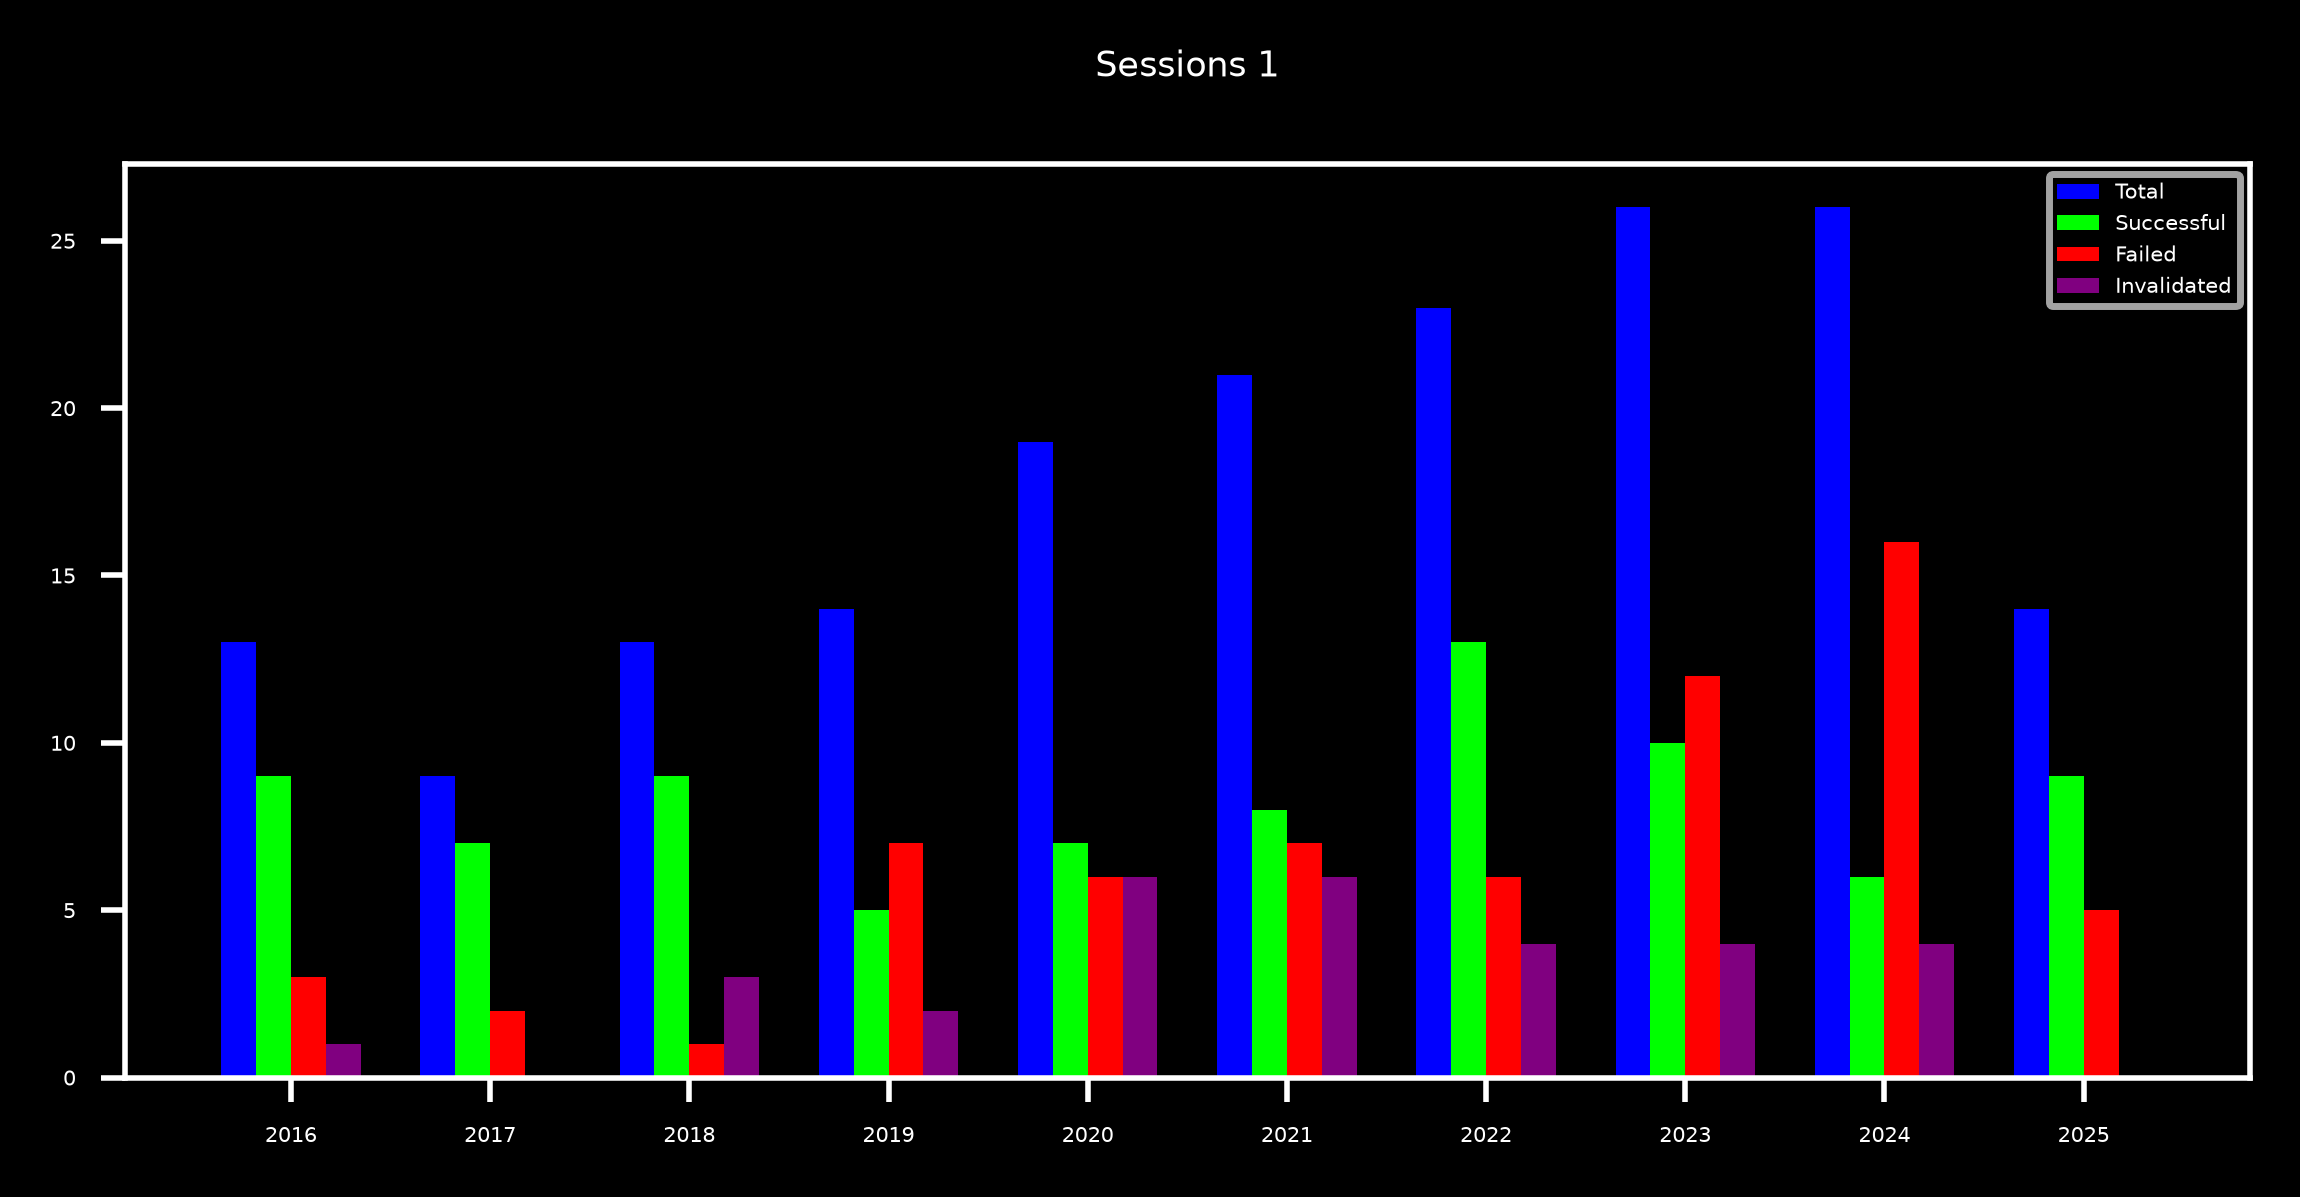

Sessions 2
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  7   │  4   │  2  │  53  │  30  │  15  │ 3.05 │ 2.15 │ -1.… │ 0.9… │ -0.… │ 7.0  │ 14.… │ -2.3% │ 0.1… │
│ 2017 │  9   │  8   │  0   │  1  │  88  │  0   │  11  │ 4.28 │ 5.26 │ -1.… │ 0.8… │ -0.… │ 8.54 │ 6.9  │ -6.9… │ 0.1… │
│ 2018 │  13  │  6   │  3   │  4  │  46  │  23  │  30  │ 2.93 │ 3.38 │ -6.0 │ 0.5… │ -1.… │ -4.… │ -3.… │ -34.… │ 0.2… │
│ 2019 │  14  │  5   │  5   │  4  │  35  │  35  │  28  │ 4.33 │ 2.48 │ -3.… │ 0.3… │ -0.… │ 0.64 │ 0.9  │ -14.… │ 0.8… │
│ 2020 │  19  │  9   │  2   │  8  │  47  │  10  │  42  │ 3.6  │ 2.68 │ -3.… │ 0.5… │ -0.… │ 1.45 │ 1.63 │ -11.… │ 0.6… │
│ 2021 │  21  │  7   │  4   │ 10  │  33  │  19  │  47  │ 3.97 │ 3.8  │ -5.… │ 0.5… │ -0.… │ -1.… │ -1.… │ -26.… │ 0.7… │
│ 2022 │  23  │  13  │  5   │  5  │  56  │  21  │  21  │ 2.03 │ 3.68 │ -2.8 │ 0.7… │ -0.… │ -0.… │ -0.… │ -19.… │ 0.8… │
│ 2023 │  26  │  10  │  8   │  8  │  38  │  30  │  30  │ 3.93 │ 3.16 │ -2.… │ 0.9… │ -0.… │ 1.36 │ 2.26 │ -11.… │ 0.6… │
│ 2024 │  26  │  10  │  10  │  6  │  38  │  38  │  23  │ 1.71 │ 1.54 │ -3.… │ 0.4… │ -0.… │ -5.… │ -4.… │ -29.… │ 0.1… │
│ 2025 │  13  │  5   │  4   │  4  │  38  │  30  │  30  │ 1.06 │ 1.87 │ -2.… │ 0.6… │ -0.… │ -5.… │ -5.… │ -9.0… │ 0.2… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

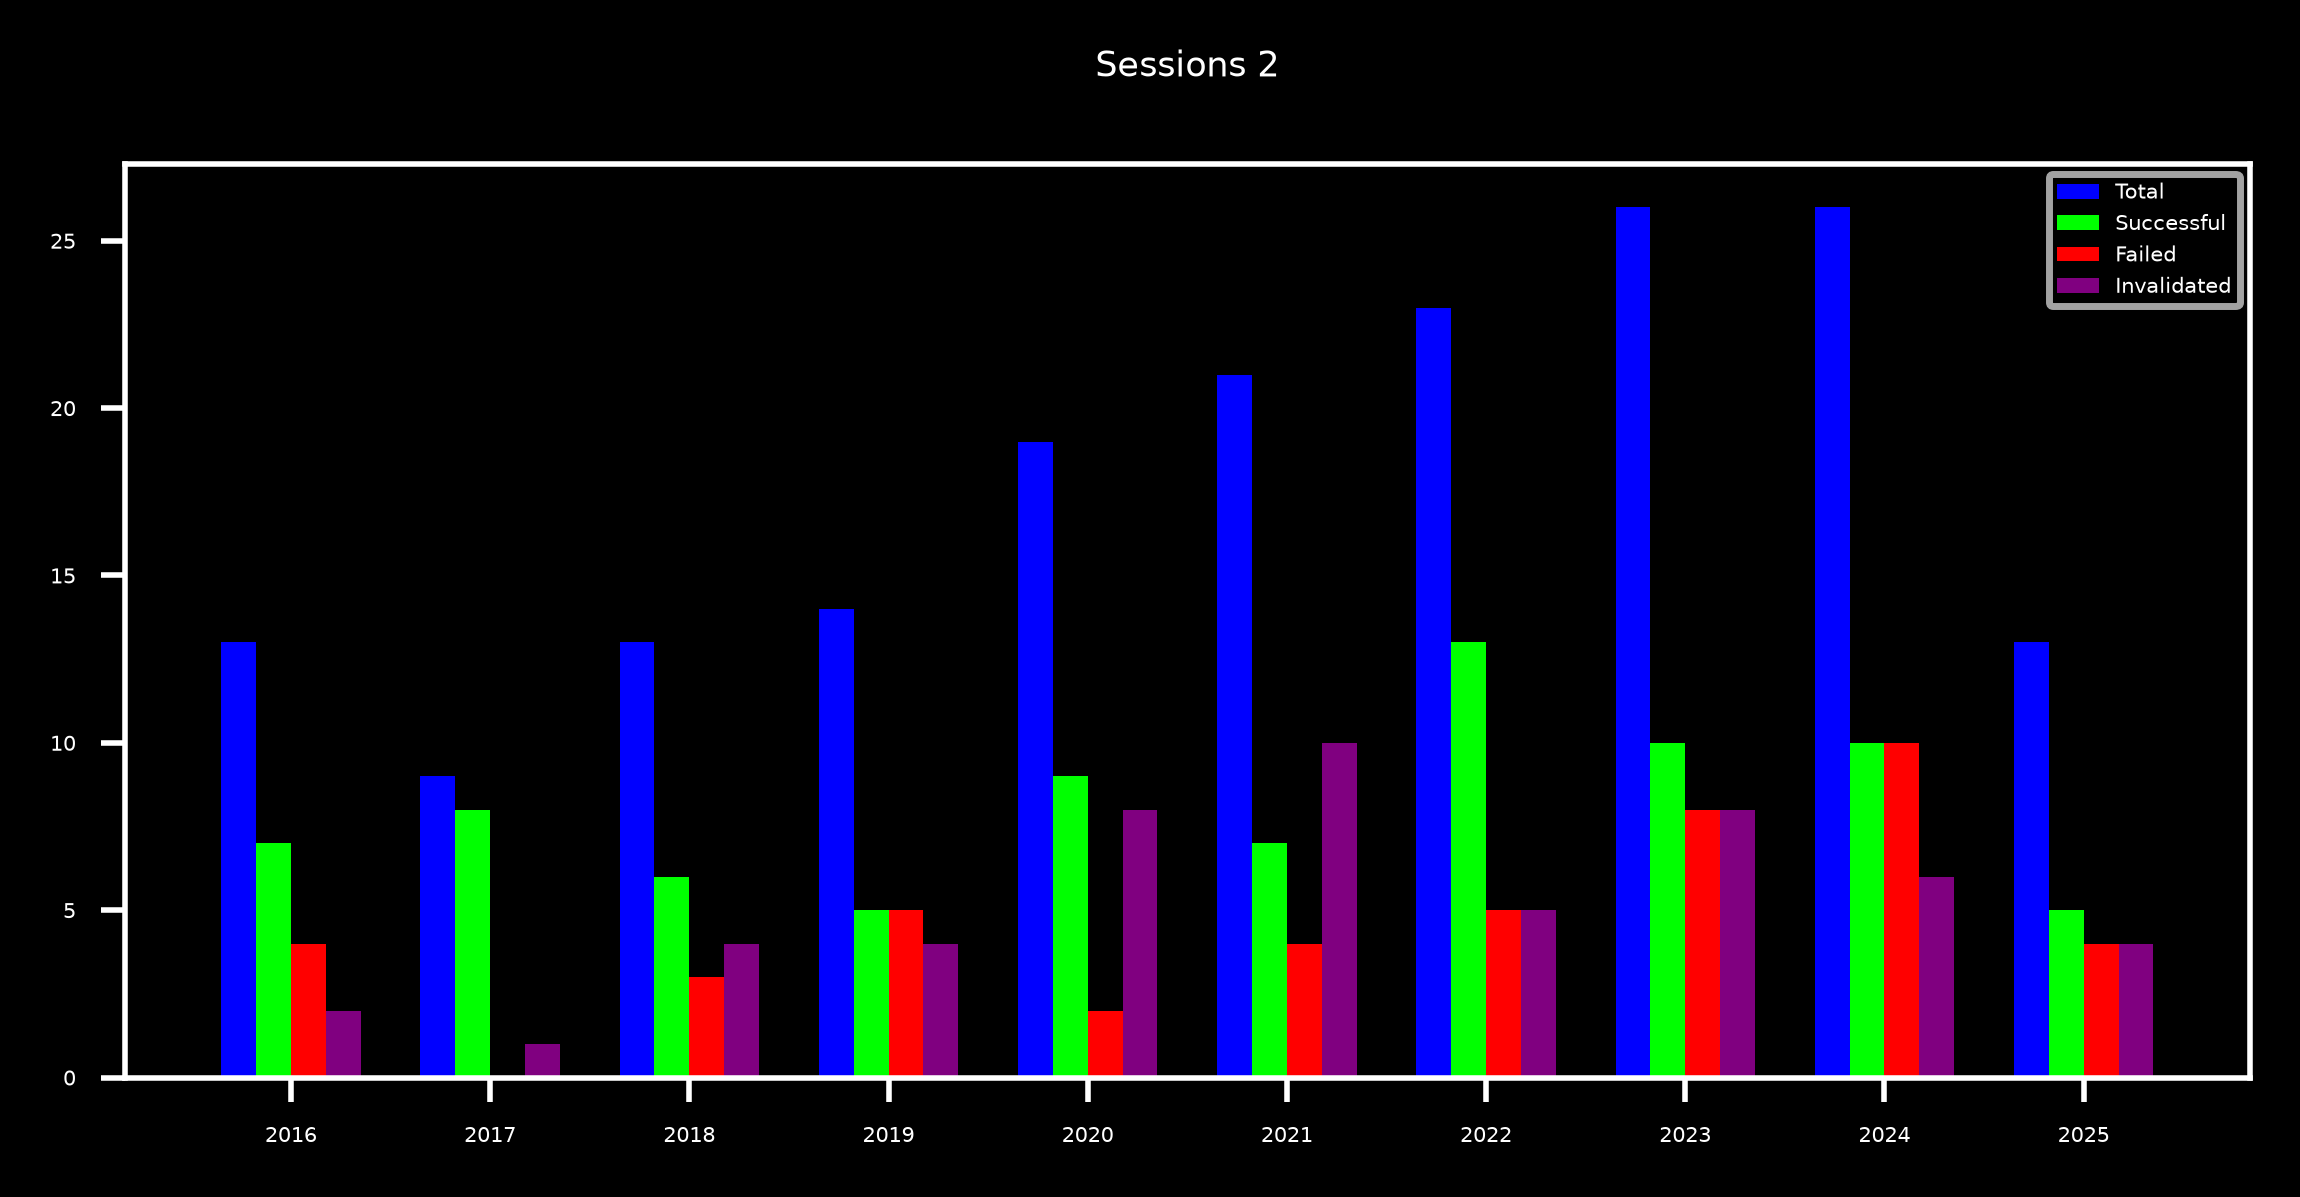

Sessions 3
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  8   │  3   │  2  │  61  │  23  │  15  │ 2.23 │ 2.53 │ -1.… │ 1.0… │ -0.… │ 4.4  │ 7.25 │ -4.3… │ 0.3… │
│ 2017 │  9   │  8   │  0   │  1  │  88  │  0   │  11  │ 4.67 │ 8.11 │ -3.3 │ 1.2… │ -0.… │ 4.43 │ 1.99 │ -17.… │ 0.4… │
│ 2018 │  13  │  6   │  1   │  6  │  46  │  7   │  46  │ 5.29 │ 4.61 │ -7.… │ 0.6… │ -1.… │ -3.… │ -3.… │ -39.… │ 0.4… │
│ 2019 │  14  │  4   │  6   │  4  │  28  │  42  │  28  │ 5.46 │ 3.23 │ -3.… │ 0.5x │ -0.… │ -0.… │ -0.… │ -15.… │ 0.8… │
│ 2020 │  19  │  8   │  2   │  9  │  42  │  10  │  47  │ 4.23 │ 3.18 │ -3.… │ 0.7x │ -0.… │ 2.09 │ 2.78 │ -9.9… │ 0.5… │
│ 2021 │  21  │  5   │  5   │ 11  │  23  │  23  │  52  │ 7.29 │ 5.47 │ -6.… │ 0.8x │ -1.… │ 0.46 │ 0.59 │ -28.… │ 0.8… │
│ 2022 │  23  │  6   │  7   │ 10  │  26  │  30  │  43  │ 2.77 │ 4.0  │ -4.… │ 0.7… │ -0.… │ -6.… │ -5.… │ -40.… │ 0.0… │
│ 2023 │  26  │  11  │  3   │ 12  │  42  │  11  │  46  │ 4.59 │ 3.73 │ -3.… │ 1.1… │ -0.… │ 1.34 │ 2.14 │ -11.… │ 0.6… │
│ 2024 │  26  │  9   │  10  │  7  │  34  │  38  │  26  │ 3.13 │ 2.16 │ -3.… │ 0.6x │ -0.… │ -3.… │ -3.2 │ -31.… │ 0.3… │
│ 2025 │  13  │  6   │  3   │  4  │  46  │  23  │  30  │ 2.59 │ 2.75 │ -2.… │ 0.9… │ -0.… │ 2.3  │ 2.59 │ -7.9% │ 0.6… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

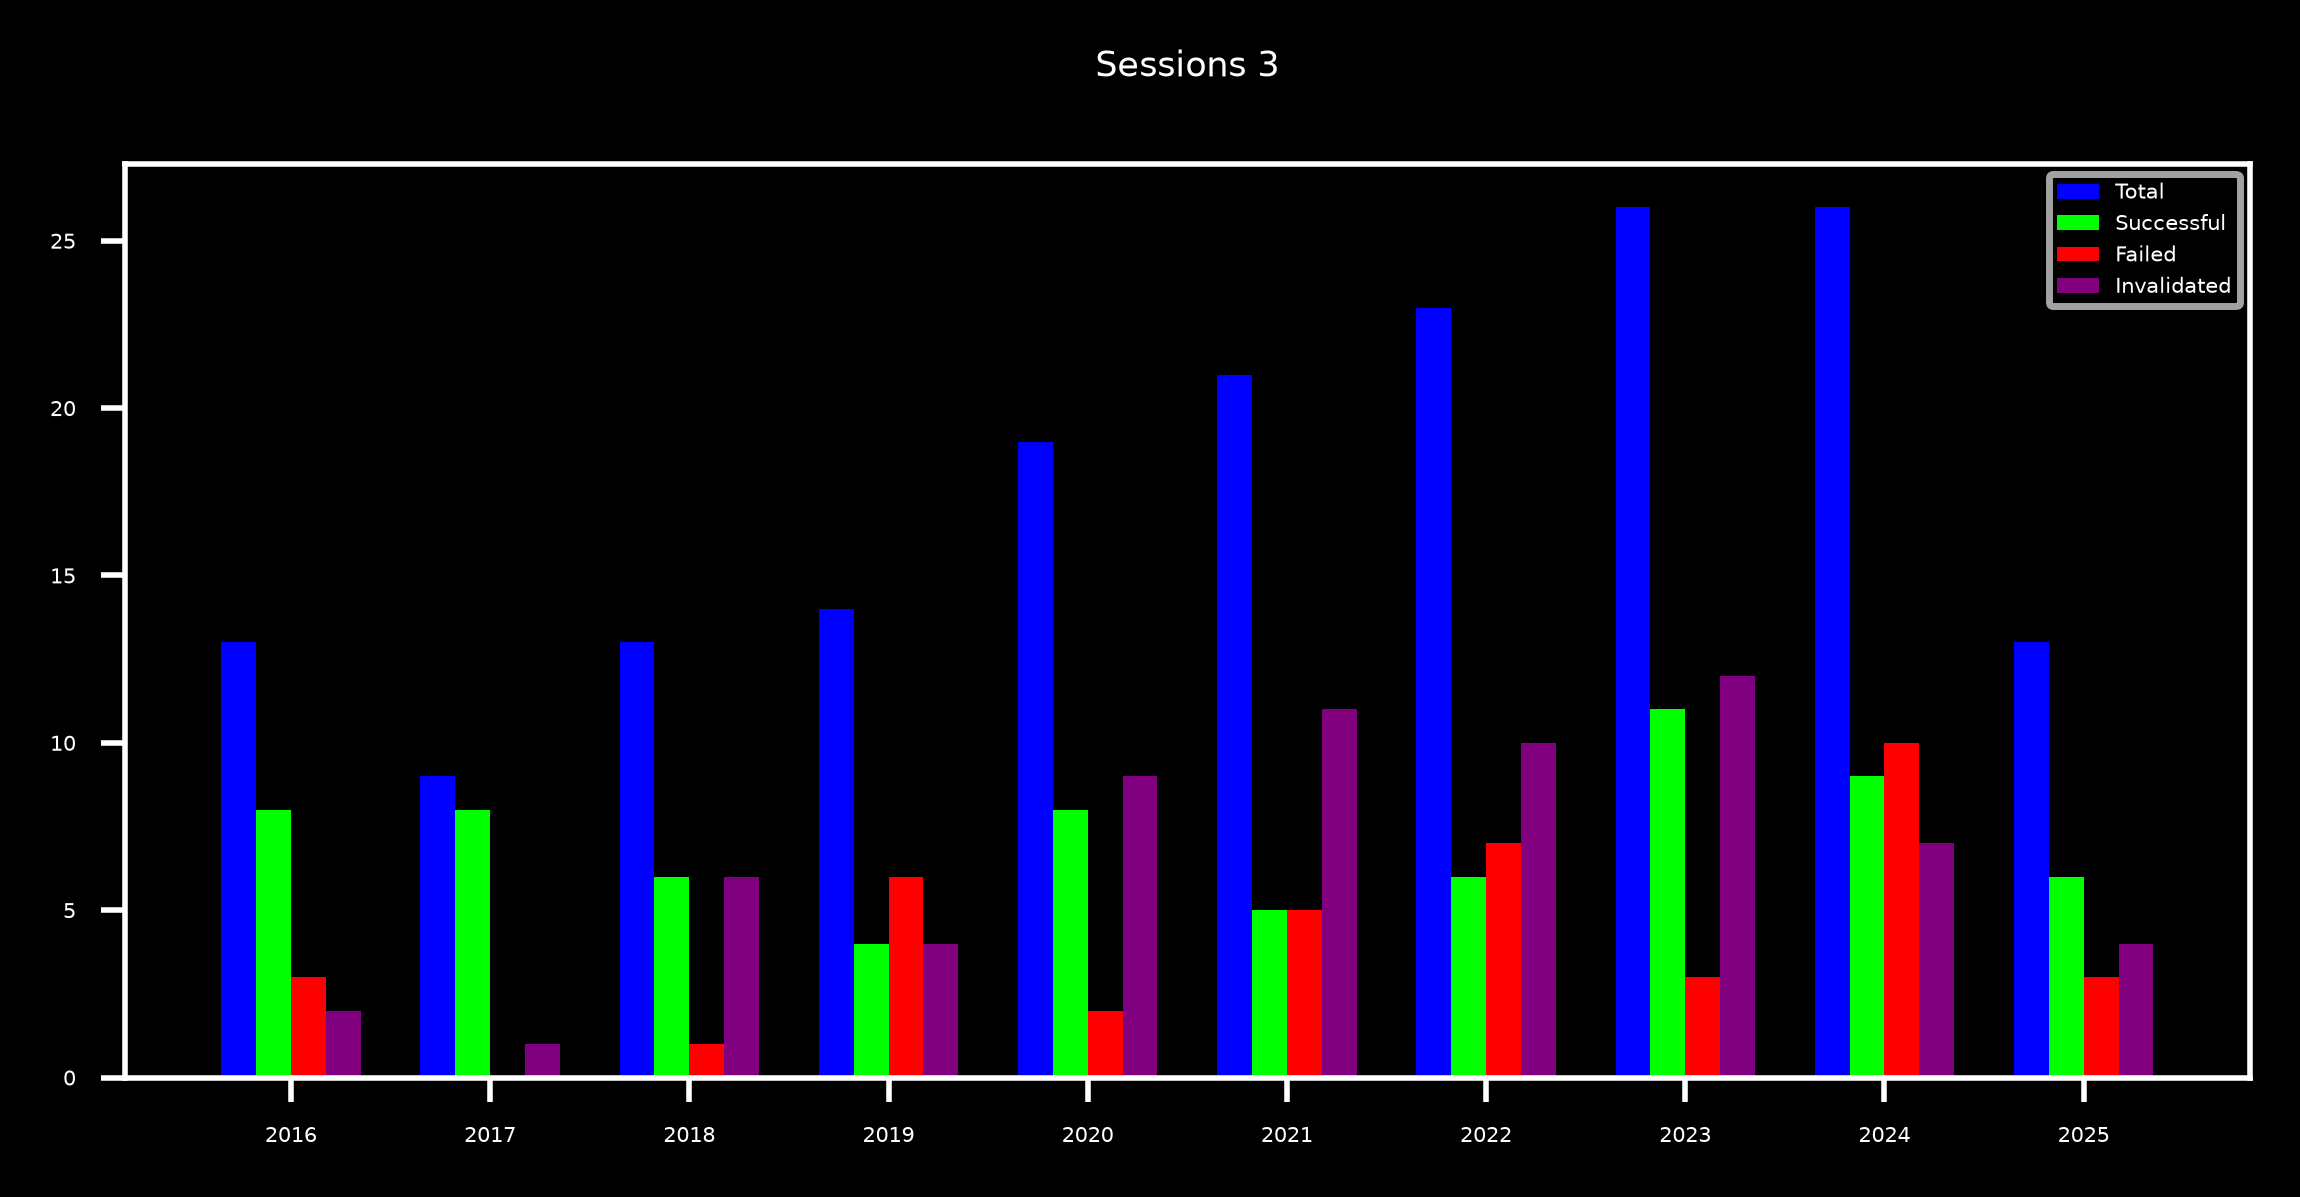

Sessions 4
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  9   │  1   │  3  │  69  │  7   │  23  │ 3.02 │ 3.3  │ -1.… │ 1.6x │ -0.… │ 8.57 │ 18.… │ -2.6… │ 0.0… │
│ 2017 │  9   │  8   │  0   │  1  │  88  │  0   │  11  │ 5.33 │ 9.03 │ -4.… │ 1.3… │ -0.… │ 4.72 │ 2.04 │ -19.… │ 0.3… │
│ 2018 │  13  │  5   │  1   │  7  │  38  │  7   │  53  │ 5.7  │ 4.72 │ -8.4 │ 0.7x │ -1.… │ -5.… │ -4.… │ -48.… │ 0.2… │
│ 2019 │  14  │  3   │  6   │  5  │  21  │  42  │  35  │ 6.44 │ 4.1  │ -5.… │ 0.6… │ -0.… │ -2.… │ -3.… │ -18.… │ 0.5… │
│ 2020 │  19  │  5   │  3   │ 11  │  26  │  15  │  57  │ 5.42 │ 3.64 │ -4.… │ 0.8… │ -1.… │ -2.… │ -2.… │ -31.… │ 0.5… │
│ 2021 │  21  │  5   │  5   │ 11  │  23  │  23  │  52  │ 7.52 │ 6.3  │ -7.… │ 0.9… │ -1.… │ 0.39 │ 0.42 │ -35.… │ 0.9… │
│ 2022 │  23  │  7   │  5   │ 11  │  30  │  21  │  47  │ 2.4  │ 4.56 │ -5.… │ 0.8… │ -1.… │ -3.… │ -3.… │ -36.… │ 0.2… │
│ 2023 │  26  │  10  │  2   │ 14  │  38  │  7   │  53  │ 6.31 │ 4.75 │ -3.… │ 1.5… │ -1.… │ 2.75 │ 4.29 │ -19.… │ 0.3… │
│ 2024 │  26  │  11  │  6   │  9  │  42  │  23  │  34  │ 3.86 │ 3.16 │ -4.… │ 0.8… │ -1.… │ -0.… │ -0.… │ -33.… │ 0.8… │
│ 2025 │  13  │  5   │  4   │  4  │  38  │  30  │  30  │ 3.23 │ 3.11 │ -2.… │ 1.1… │ -0.… │ 2.35 │ 3.52 │ -9.3… │ 0.6… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

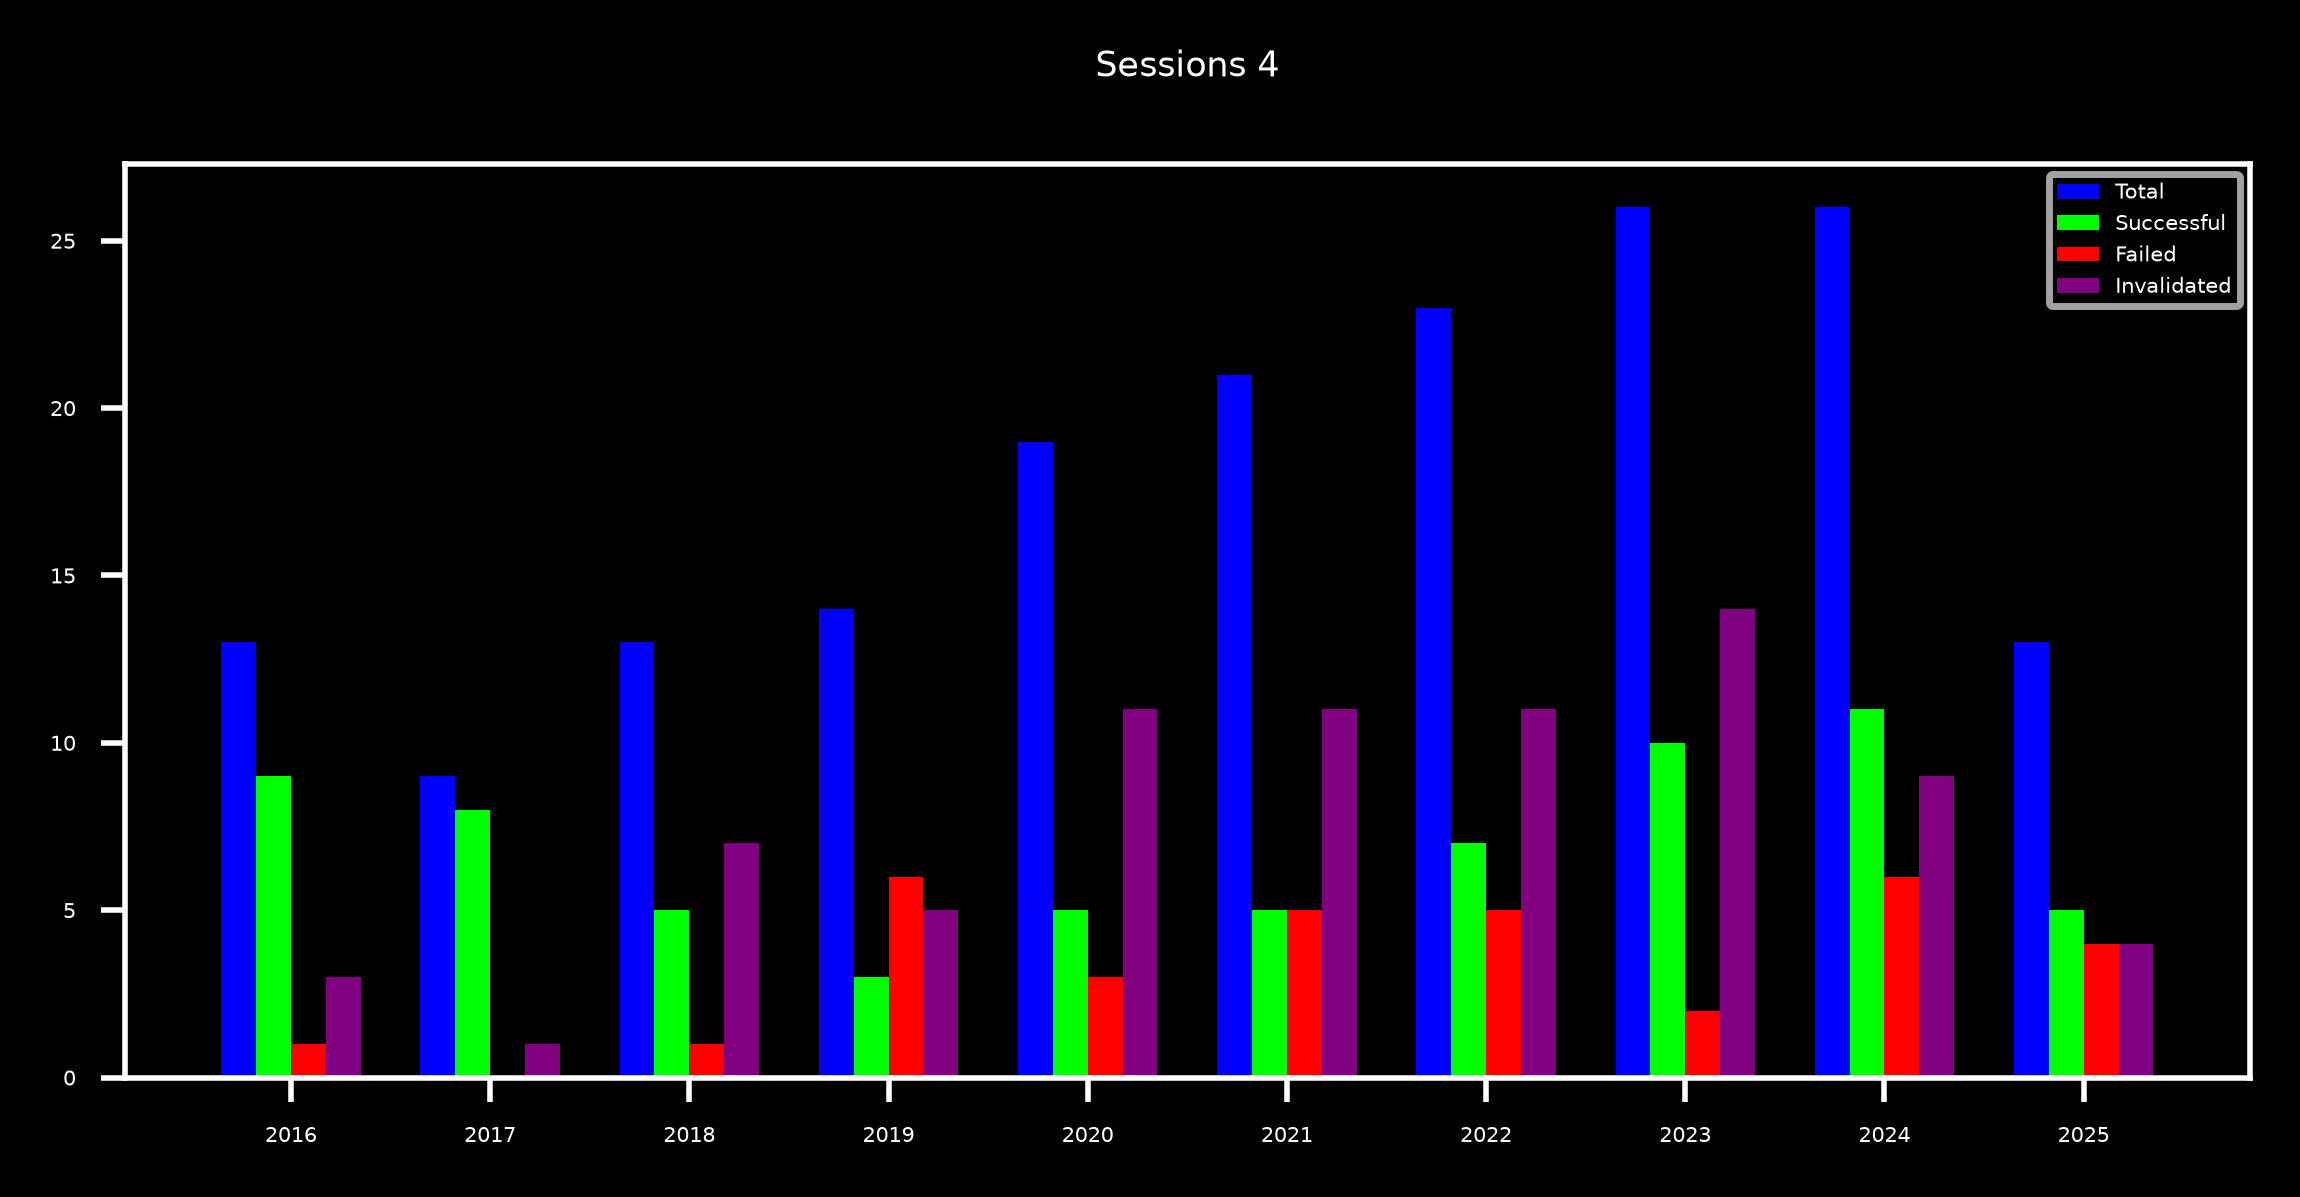

Sessions 5
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  7   │  2   │  4  │  53  │  15  │  30  │ 4.07 │ 3.55 │ -2.… │ 1.7… │ -0.… │ 3.92 │ 5.93 │ -5.3% │ 0.3… │
│ 2017 │  9   │  6   │  1   │  2  │  66  │  11  │  22  │ 4.8  │ 9.56 │ -5.… │ 1.4… │ -0.… │ 7.08 │ 7.96 │ -7.8… │ 0.2… │
│ 2018 │  13  │  3   │  2   │  8  │  23  │  15  │  61  │ 5.78 │ 4.87 │ -9.7 │ 0.7… │ -1.… │ -8.… │ -6.… │ -58.… │ 0.0… │
│ 2019 │  14  │  3   │  4   │  7  │  21  │  28  │  50  │ 5.54 │ 4.23 │ -5.… │ 0.6… │ -0.… │ -3.… │ -4.5 │ -20.… │ 0.3… │
│ 2020 │  19  │  4   │  4   │ 11  │  21  │  21  │  57  │ 10.… │ 5.26 │ -4.… │ 1.1… │ -1.… │ 2.05 │ 3.07 │ -17.… │ 0.5… │
│ 2021 │  21  │  4   │  4   │ 13  │  19  │  19  │  61  │ 11.… │ 7.37 │ -8.… │ 1.1… │ -1.… │ -1.… │ -1.… │ -50.… │ 0.7… │
│ 2022 │  23  │  8   │  4   │ 11  │  34  │  17  │  47  │ 3.25 │ 5.37 │ -6.… │ 1.1x │ -1.… │ -2.… │ -2.0 │ -45.… │ 0.4… │
│ 2023 │  26  │  10  │  2   │ 14  │  38  │  7   │  53  │ 7.13 │ 5.29 │ -3.… │ 1.8x │ -1.… │ 2.92 │ 4.83 │ -20.… │ 0.3… │
│ 2024 │  26  │  9   │  8   │  9  │  34  │  30  │  34  │ 5.96 │ 3.96 │ -4.… │ 1.0… │ -1.… │ 0.8  │ 1.07 │ -23.… │ 0.7… │
│ 2025 │  13  │  4   │  4   │  5  │  30  │  30  │  38  │ 4.6  │ 3.59 │ -3.1 │ 1.2… │ -0.… │ 0.62 │ 0.88 │ -9.8% │ 0.8… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

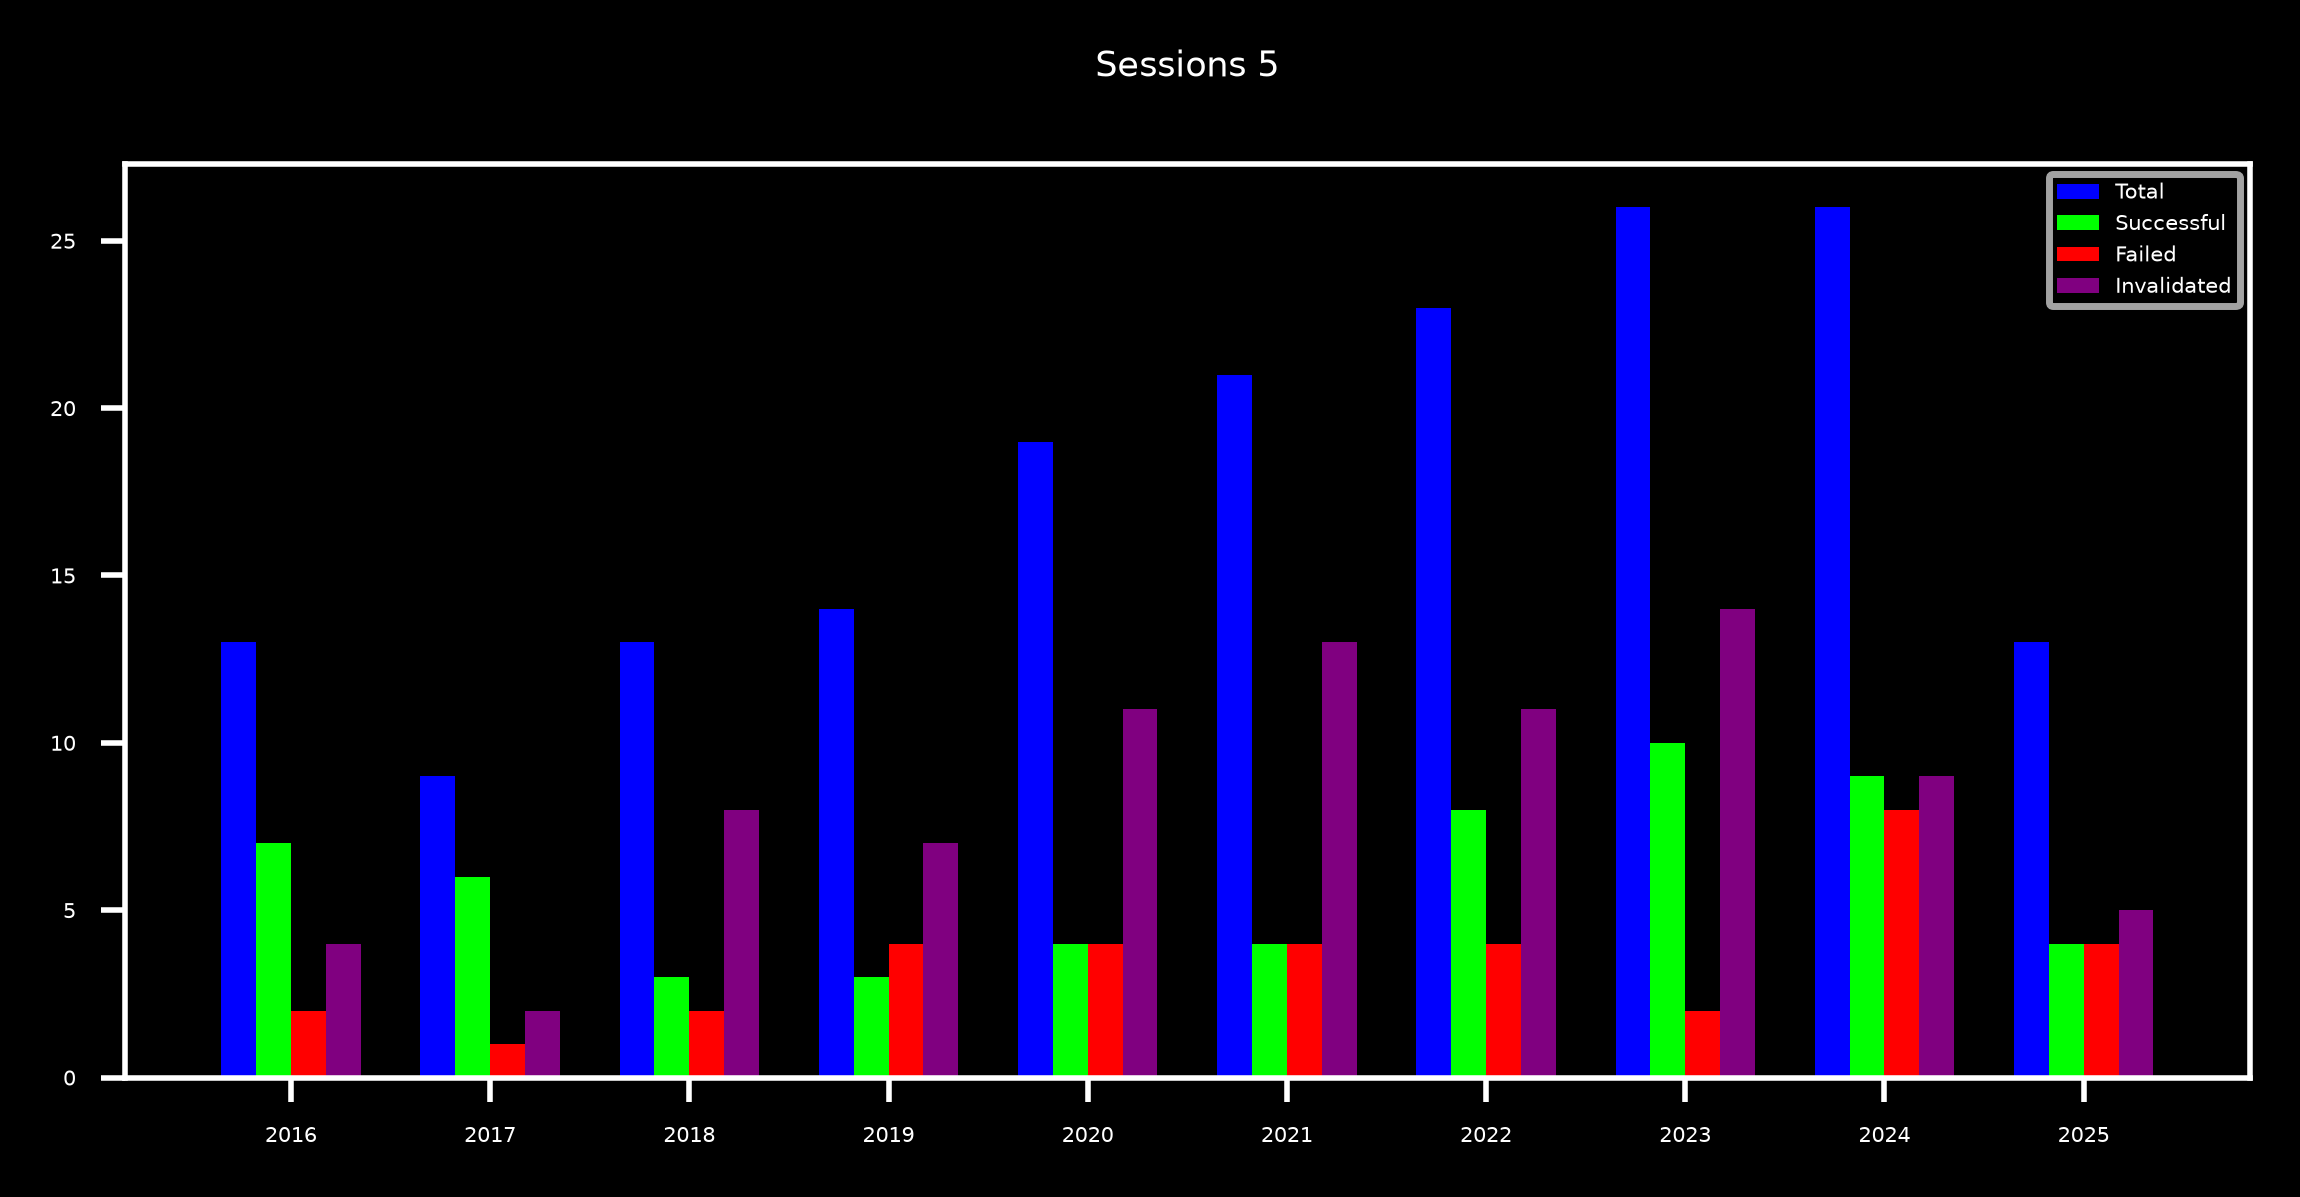

Sessions 6
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  7   │  0   │  6  │  53  │  0   │  46  │ 3.44 │ 4.02 │ -3.… │ 2.2… │ -1.… │ 5.05 │ 6.71 │ -4.3… │ 0.2… │
│ 2017 │  9   │  6   │  0   │  3  │  66  │  0   │  33  │ 5.29 │ 10.… │ -7.… │ 1.4… │ -1.… │ 14.… │ 19.… │ -3.1… │ 0.0… │
│ 2018 │  13  │  4   │  0   │  9  │  30  │  0   │  69  │ 3.08 │ 4.87 │ -11… │ 0.7… │ -2.… │ -9.… │ -6.… │ -64.… │ 0.0… │
│ 2019 │  14  │  3   │  4   │  7  │  21  │  28  │  50  │ 5.4  │ 4.23 │ -6.… │ 0.6… │ -1.… │ -0.… │ -0.… │ -16.… │ 0.9… │
│ 2020 │  19  │  5   │  2   │ 12  │  26  │  10  │  63  │ 8.22 │ 5.83 │ -5.… │ 1.2… │ -1.… │ 0.48 │ 0.52 │ -30.… │ 0.8… │
│ 2021 │  21  │  5   │  3   │ 13  │  23  │  14  │  61  │ 9.31 │ 7.64 │ -9.… │ 1.1… │ -1.… │ -1.… │ -1.… │ -47.… │ 0.7… │
│ 2022 │  23  │  8   │  4   │ 11  │  34  │  17  │  47  │ 3.72 │ 5.87 │ -6.… │ 1.2… │ -1.… │ -1.7 │ -1.… │ -40.… │ 0.6… │
│ 2023 │  26  │  10  │  2   │ 14  │  38  │  7   │  53  │ 10.0 │ 6.16 │ -3.… │ 2.1… │ -1.… │ 4.69 │ 10.… │ -18.… │ 0.1… │
│ 2024 │  26  │  9   │  7   │ 10  │  34  │  26  │  38  │ 5.99 │ 4.31 │ -5.1 │ 1.1… │ -1.… │ 0.16 │ 0.19 │ -32.… │ 0.9… │
│ 2025 │  13  │  5   │  2   │  6  │  38  │  15  │  46  │ 3.32 │ 3.65 │ -3.… │ 1.2… │ -1.… │ 1.59 │ 2.5  │ -11.… │ 0.7… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

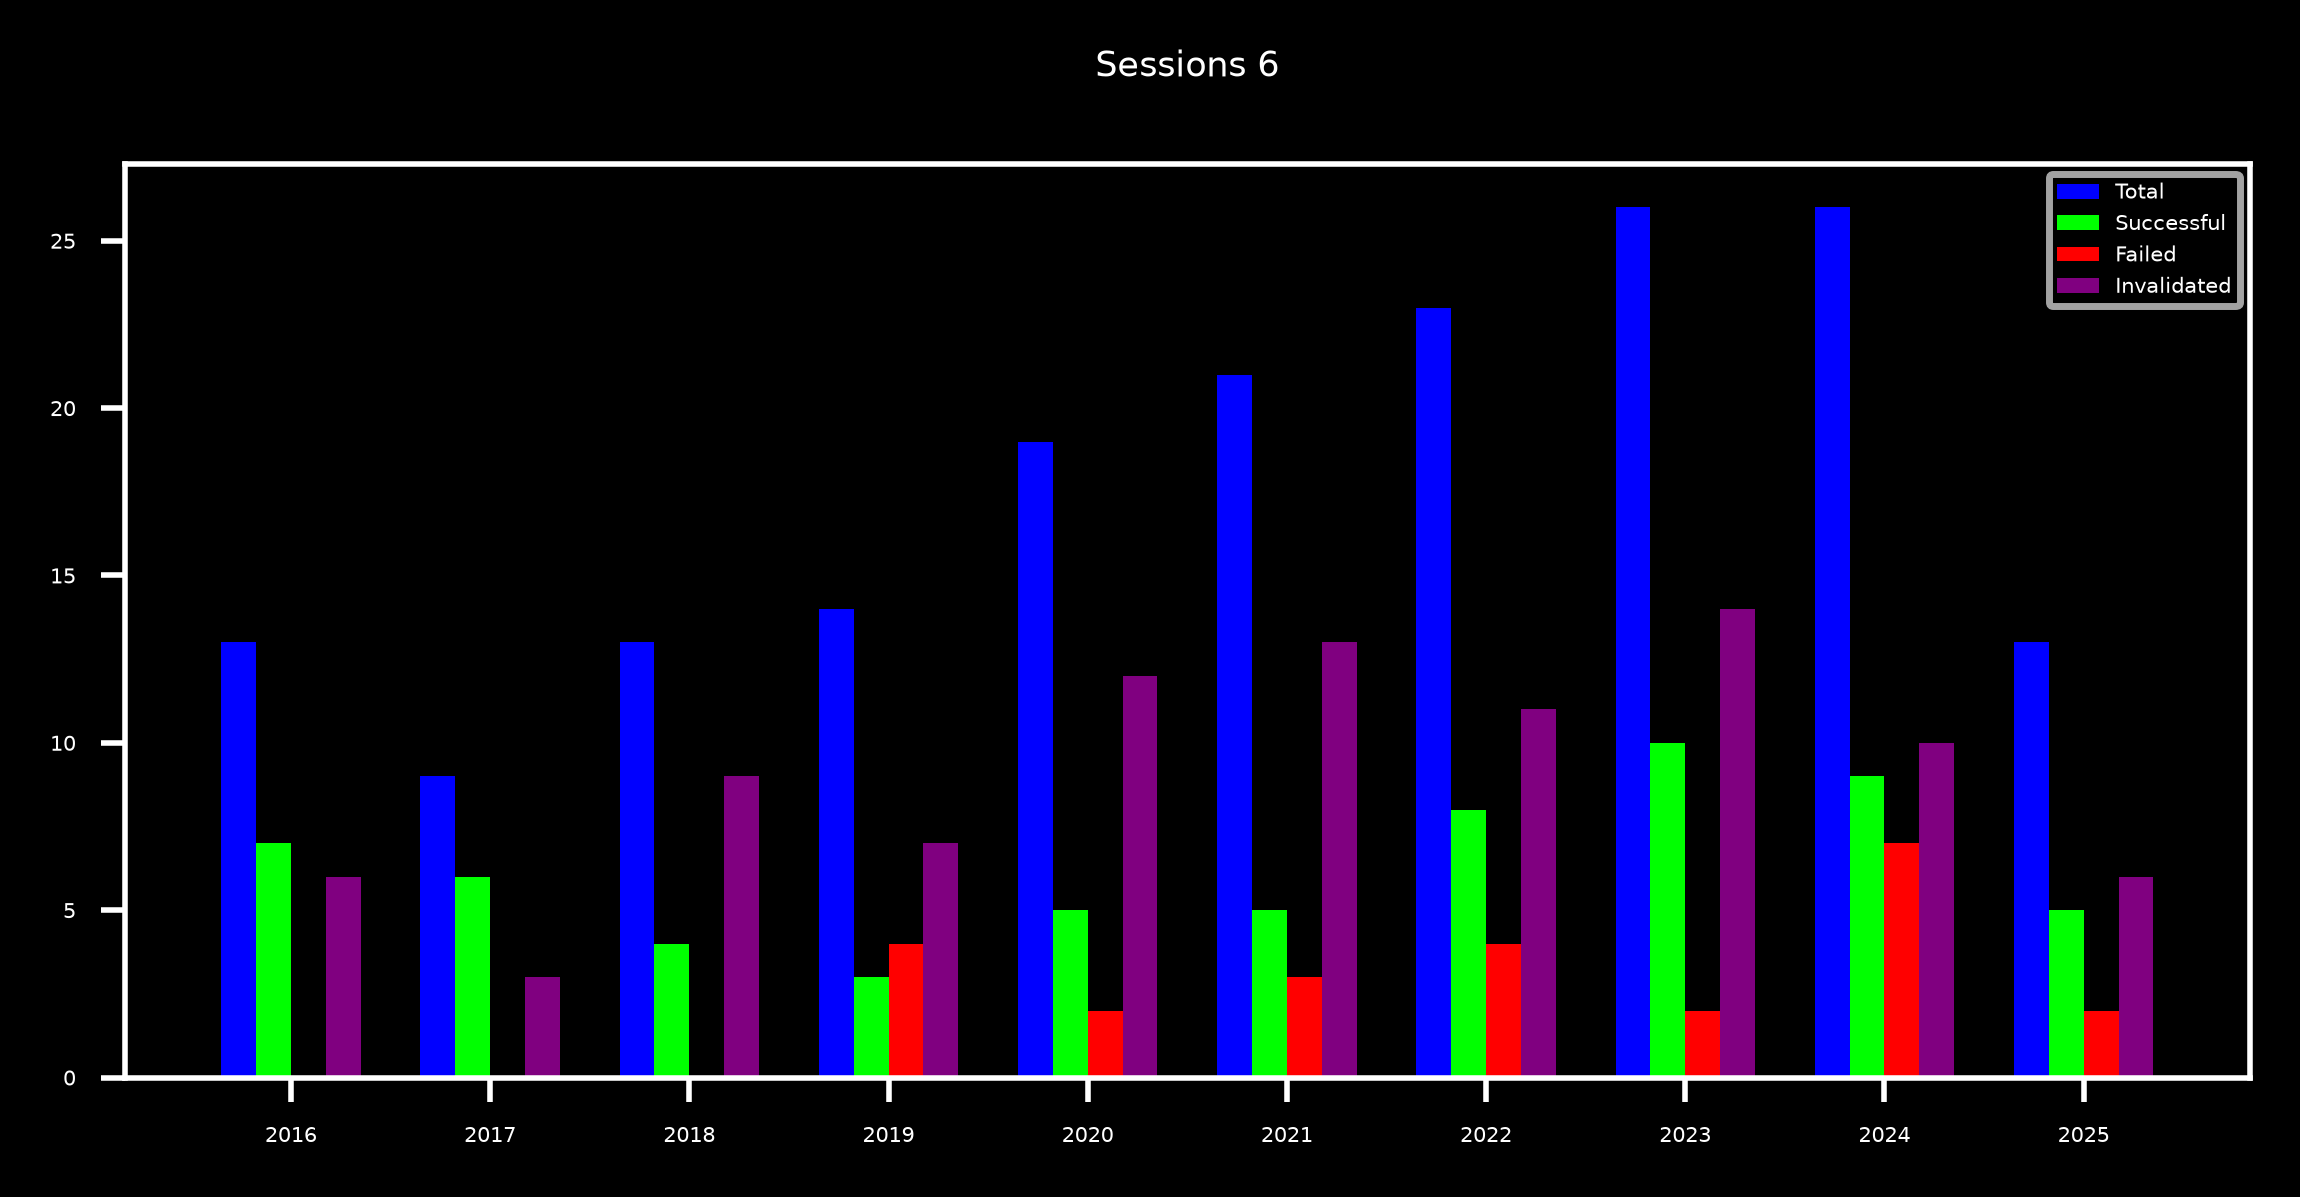

Sessions 7
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  6   │  0   │  7  │  46  │  0   │  53  │ 3.28 │ 4.03 │ -3.… │ 2.2… │ -1.… │ 1.98 │ 2.3  │ -7.8… │ 0.6… │
│ 2017 │  9   │  6   │  0   │  3  │  66  │  0   │  33  │ 6.59 │ 10.… │ -7.… │ 1.5x │ -1.… │ 10.… │ 10.… │ -5.2… │ 0.0… │
│ 2018 │  13  │  3   │  1   │  9  │  23  │  7   │  69  │ 3.51 │ 5.21 │ -12… │ 0.7… │ -2.… │ -10… │ -7.… │ -62.… │ 0.0… │
│ 2019 │  14  │  5   │  2   │  7  │  35  │  14  │  50  │ 4.68 │ 5.15 │ -6.… │ 0.8… │ -1.… │ 0.6  │ 0.59 │ -16.… │ 0.8… │
│ 2020 │  19  │  5   │  2   │ 12  │  26  │  10  │  63  │ 8.75 │ 6.5  │ -5.… │ 1.4… │ -1.… │ 3.12 │ 3.45 │ -18.… │ 0.4… │
│ 2021 │  21  │  4   │  1   │ 16  │  19  │  4   │  76  │ 10.… │ 7.95 │ -10… │ 1.2… │ -1.… │ -1.… │ -1.… │ -47.… │ 0.7… │
│ 2022 │  23  │  6   │  6   │ 11  │  26  │  26  │  47  │ 4.05 │ 6.01 │ -7.… │ 1.2… │ -1.… │ -3.… │ -3.… │ -55.… │ 0.2… │
│ 2023 │  26  │  10  │  1   │ 15  │  38  │  3   │  57  │ 10.… │ 6.55 │ -3.… │ 2.3… │ -1.… │ 5.6  │ 14.… │ -14.… │ 0.0… │
│ 2024 │  26  │  10  │  5   │ 11  │  38  │  19  │  42  │ 5.62 │ 4.75 │ -5.… │ 1.2… │ -1.… │ 1.48 │ 2.08 │ -19.… │ 0.6… │
│ 2025 │  13  │  6   │  1   │  6  │  46  │  7   │  46  │ 3.23 │ 3.99 │ -3.… │ 1.4x │ -1.… │ 1.29 │ 1.42 │ -15.… │ 0.7… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

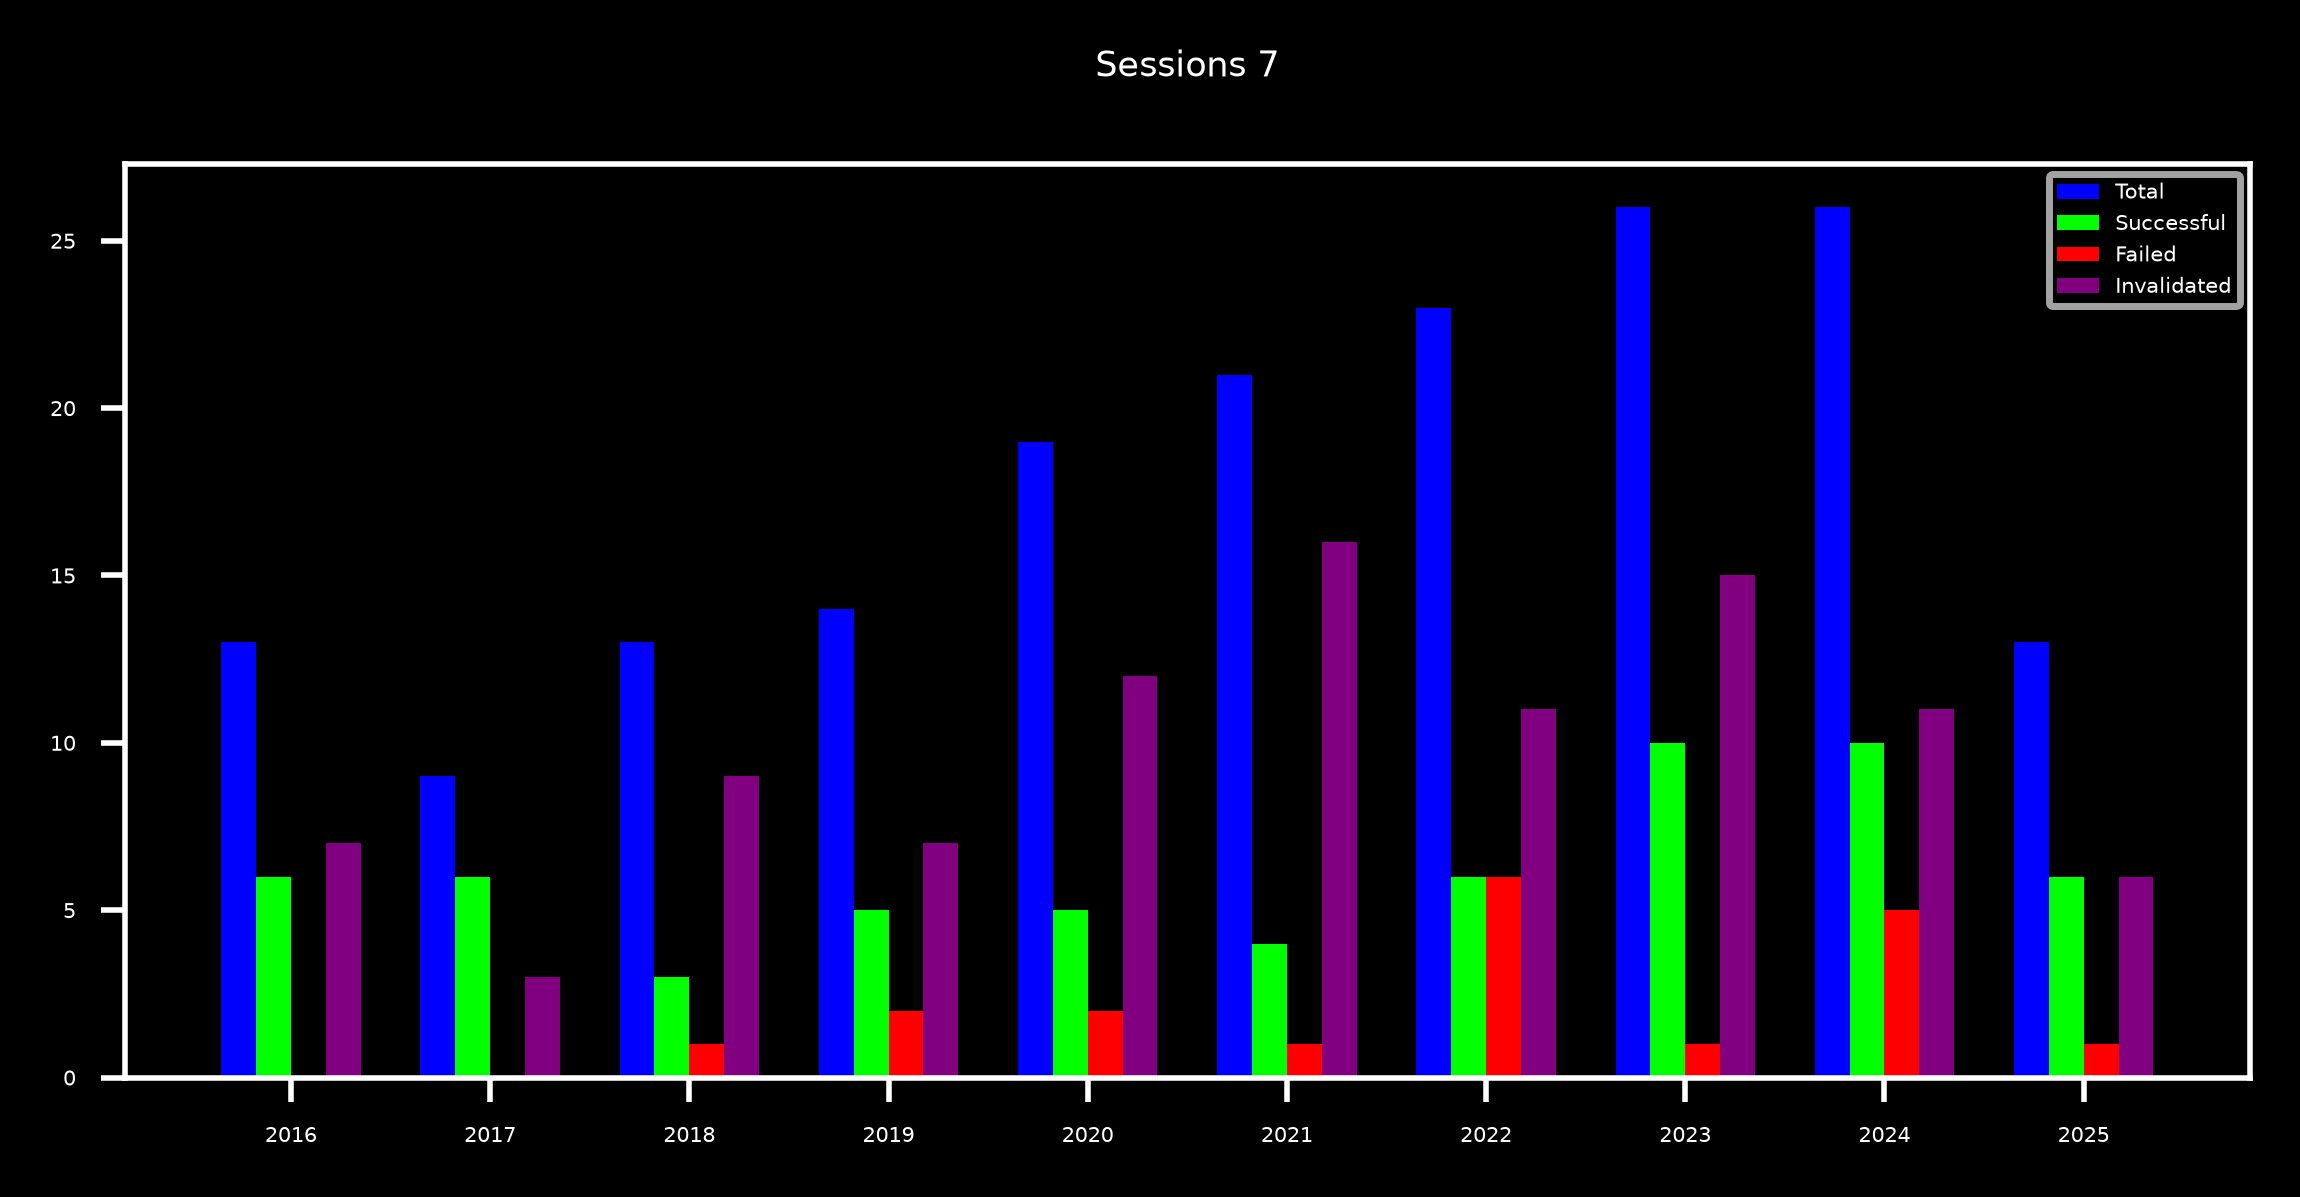

Sessions 8
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  6   │  0   │  7  │  46  │  0   │  53  │ 2.83 │ 4.44 │ -5.… │ 2.5… │ -1.… │ -1.… │ -0.… │ -8.0… │ 0.7… │
│ 2017 │  9   │  6   │  0   │  3  │  66  │  0   │  33  │ 7.66 │ 13.… │ -7.… │ 2.1x │ -1.… │ 17.… │ 44.… │ 0.0%  │ 0.0… │
│ 2018 │  13  │  4   │  0   │  9  │  30  │  0   │  69  │ 3.85 │ 5.27 │ -13… │ 0.7… │ -2.… │ -9.… │ -6.… │ -66.… │ 0.0… │
│ 2019 │  14  │  4   │  2   │  8  │  28  │  14  │  57  │ 6.25 │ 5.63 │ -7.… │ 0.8… │ -1.… │ -0.… │ -0.… │ -24.… │ 0.9… │
│ 2020 │  19  │  5   │  2   │ 12  │  26  │  10  │  63  │ 10.… │ 6.66 │ -5.… │ 1.4… │ -1.… │ 3.74 │ 5.3  │ -16.… │ 0.3… │
│ 2021 │  21  │  4   │  0   │ 17  │  19  │  0   │  80  │ 11.… │ 8.56 │ -11… │ 1.3… │ -1.… │ -1.… │ -1.… │ -48.… │ 0.7… │
│ 2022 │  23  │  5   │  4   │ 14  │  21  │  17  │  60  │ 4.67 │ 6.16 │ -8.3 │ 1.2… │ -1.… │ -5.1 │ -4.… │ -60.… │ 0.1… │
│ 2023 │  26  │  10  │  1   │ 15  │  38  │  3   │  57  │ 10.… │ 7.58 │ -4.… │ 2.7… │ -1.… │ 6.04 │ 11.… │ -19.… │ 0.0… │
│ 2024 │  26  │  10  │  5   │ 11  │  38  │  19  │  42  │ 5.83 │ 5.46 │ -5.… │ 1.4… │ -1.… │ 1.82 │ 2.37 │ -17.… │ 0.5… │
│ 2025 │  12  │  4   │  2   │  6  │  33  │  16  │  50  │ 5.27 │ 4.5  │ -3.6 │ 1.6… │ -1.… │ 2.76 │ 3.34 │ -13.… │ 0.5… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

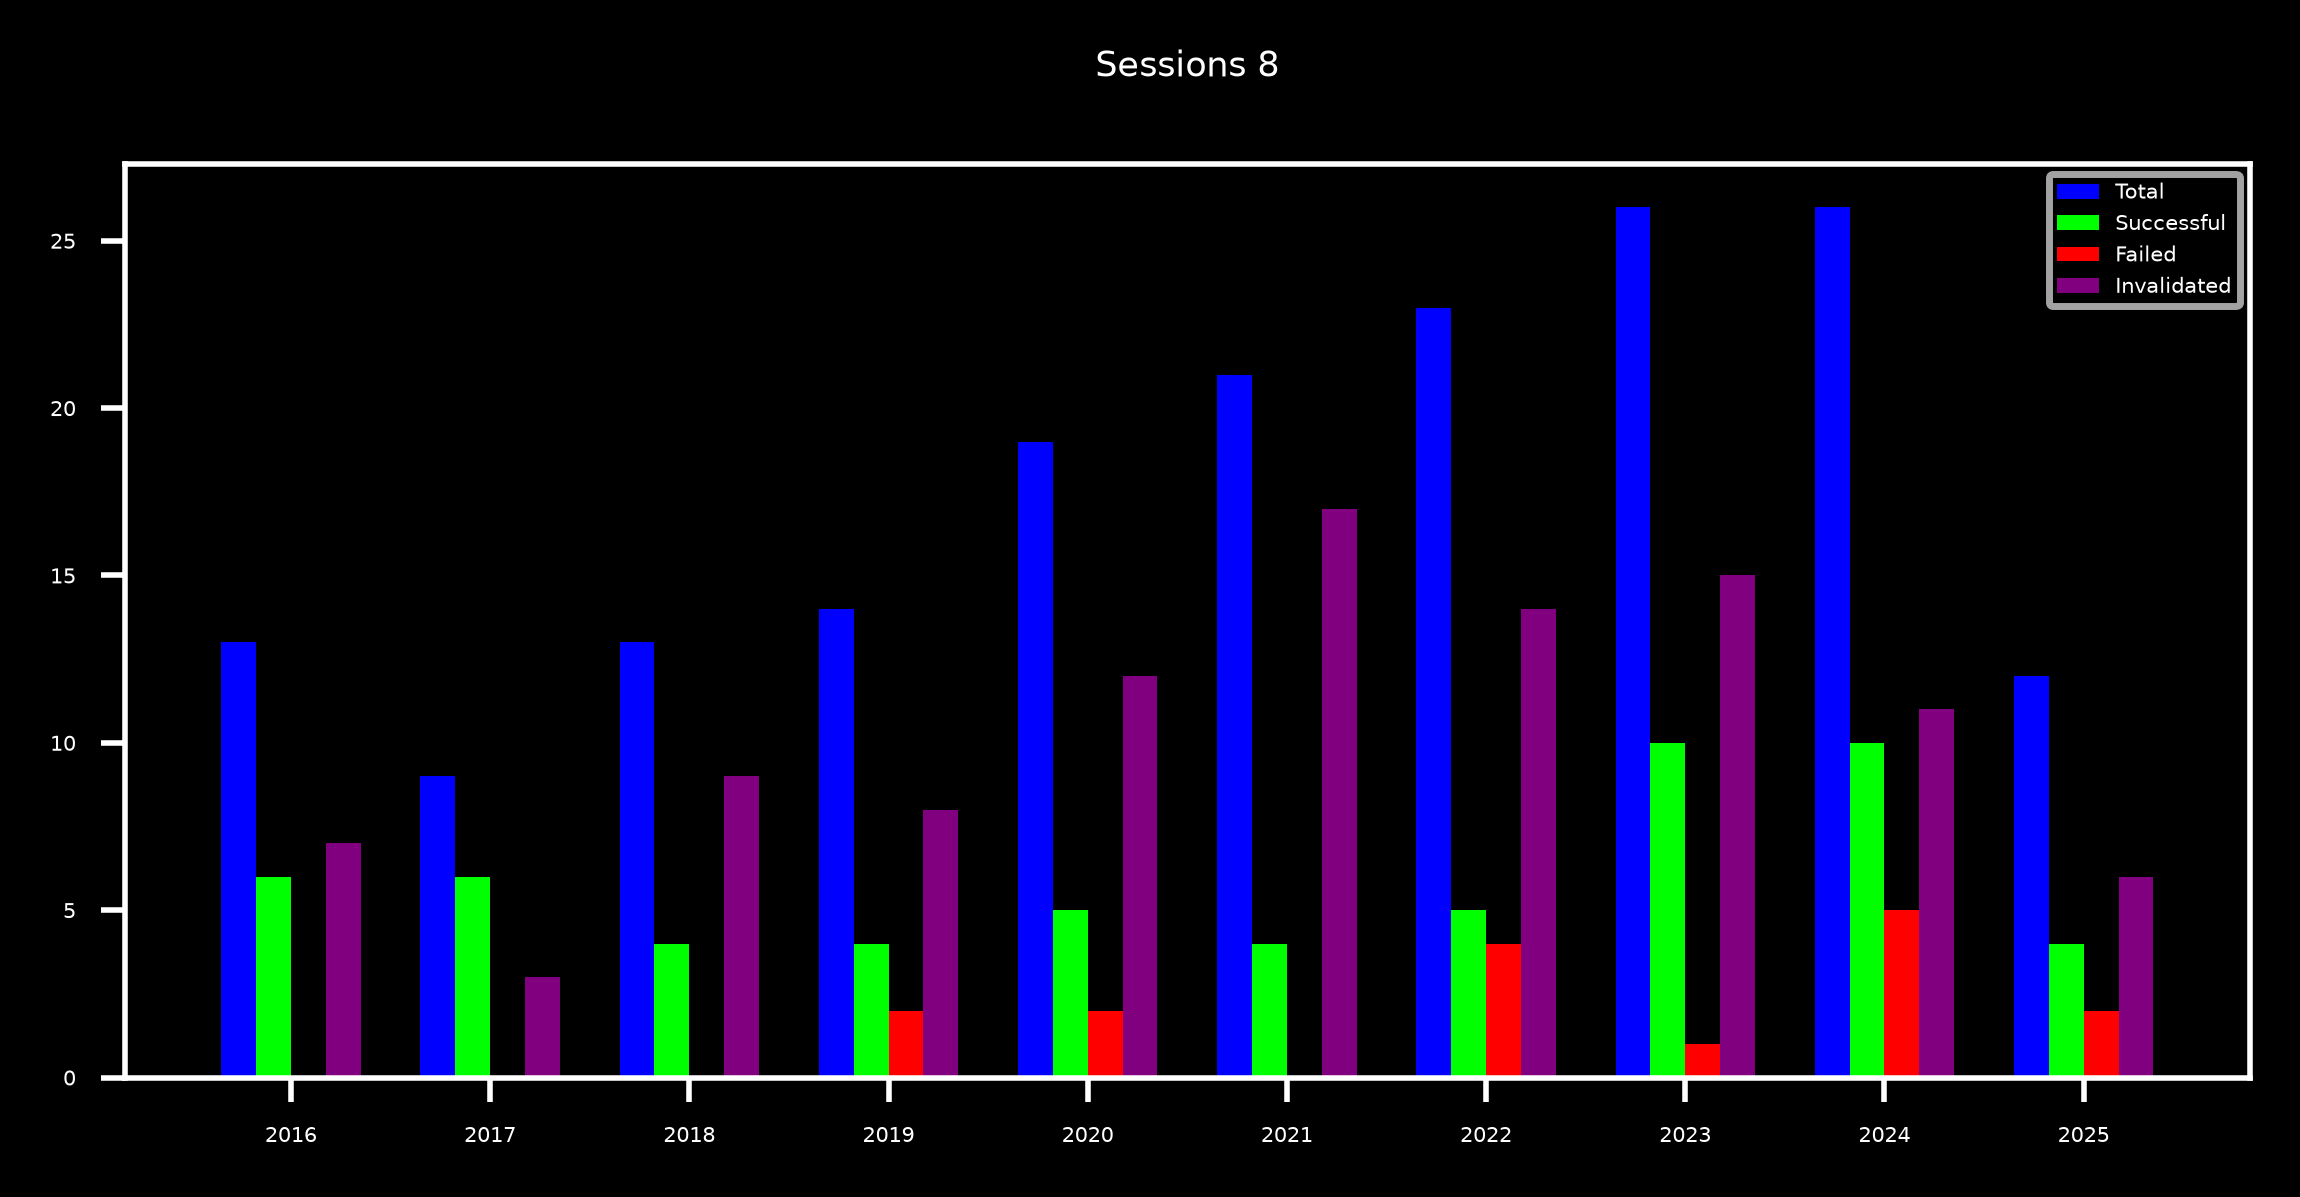

Sessions 9
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  6   │  0   │  7  │  46  │  0   │  53  │ 3.17 │ 4.67 │ -5.… │ 2.6… │ -1.… │ 0.52 │ 0.42 │ -6.4… │ 0.9… │
│ 2017 │  9   │  6   │  0   │  3  │  66  │  0   │  33  │ 11.… │ 16.… │ -8.… │ 2.4… │ -1.… │ 14.… │ 13.… │ 0.0%  │ 0.0… │
│ 2018 │  13  │  3   │  0   │ 10  │  23  │  0   │  76  │ 4.98 │ 5.27 │ -14… │ 0.7… │ -2.… │ -9.… │ -7.… │ -71.… │ 0.0… │
│ 2019 │  14  │  6   │  0   │  8  │  42  │  0   │  57  │ 6.42 │ 7.18 │ -7.… │ 1.2x │ -1.… │ 1.94 │ 2.47 │ -21.… │ 0.6… │
│ 2020 │  19  │  6   │  1   │ 12  │  31  │  5   │  63  │ 10.… │ 7.17 │ -5.… │ 1.5… │ -1.… │ 3.94 │ 5.7  │ -18.… │ 0.2… │
│ 2021 │  21  │  4   │  0   │ 17  │  19  │  0   │  80  │ 13.… │ 9.38 │ -12… │ 1.4… │ -2.… │ -0.… │ -0.… │ -53.… │ 0.8… │
│ 2022 │  23  │  5   │  3   │ 15  │  21  │  13  │  65  │ 4.02 │ 6.42 │ -8.… │ 1.3… │ -1.… │ -5.… │ -4.… │ -56.… │ 0.1… │
│ 2023 │  26  │  10  │  0   │ 16  │  38  │  0   │  61  │ 10.… │ 8.43 │ -4.… │ 3.0… │ -1.… │ 6.61 │ 12.… │ -18.… │ 0.0… │
│ 2024 │  26  │  11  │  3   │ 12  │  42  │  11  │  46  │ 7.24 │ 6.12 │ -5.… │ 1.6… │ -1.… │ 2.2  │ 3.12 │ -18.… │ 0.4… │
│ 2025 │  12  │  5   │  1   │  6  │  41  │  8   │  50  │ 5.08 │ 4.74 │ -3.… │ 1.7… │ -1.… │ 1.49 │ 1.52 │ -17.… │ 0.7… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

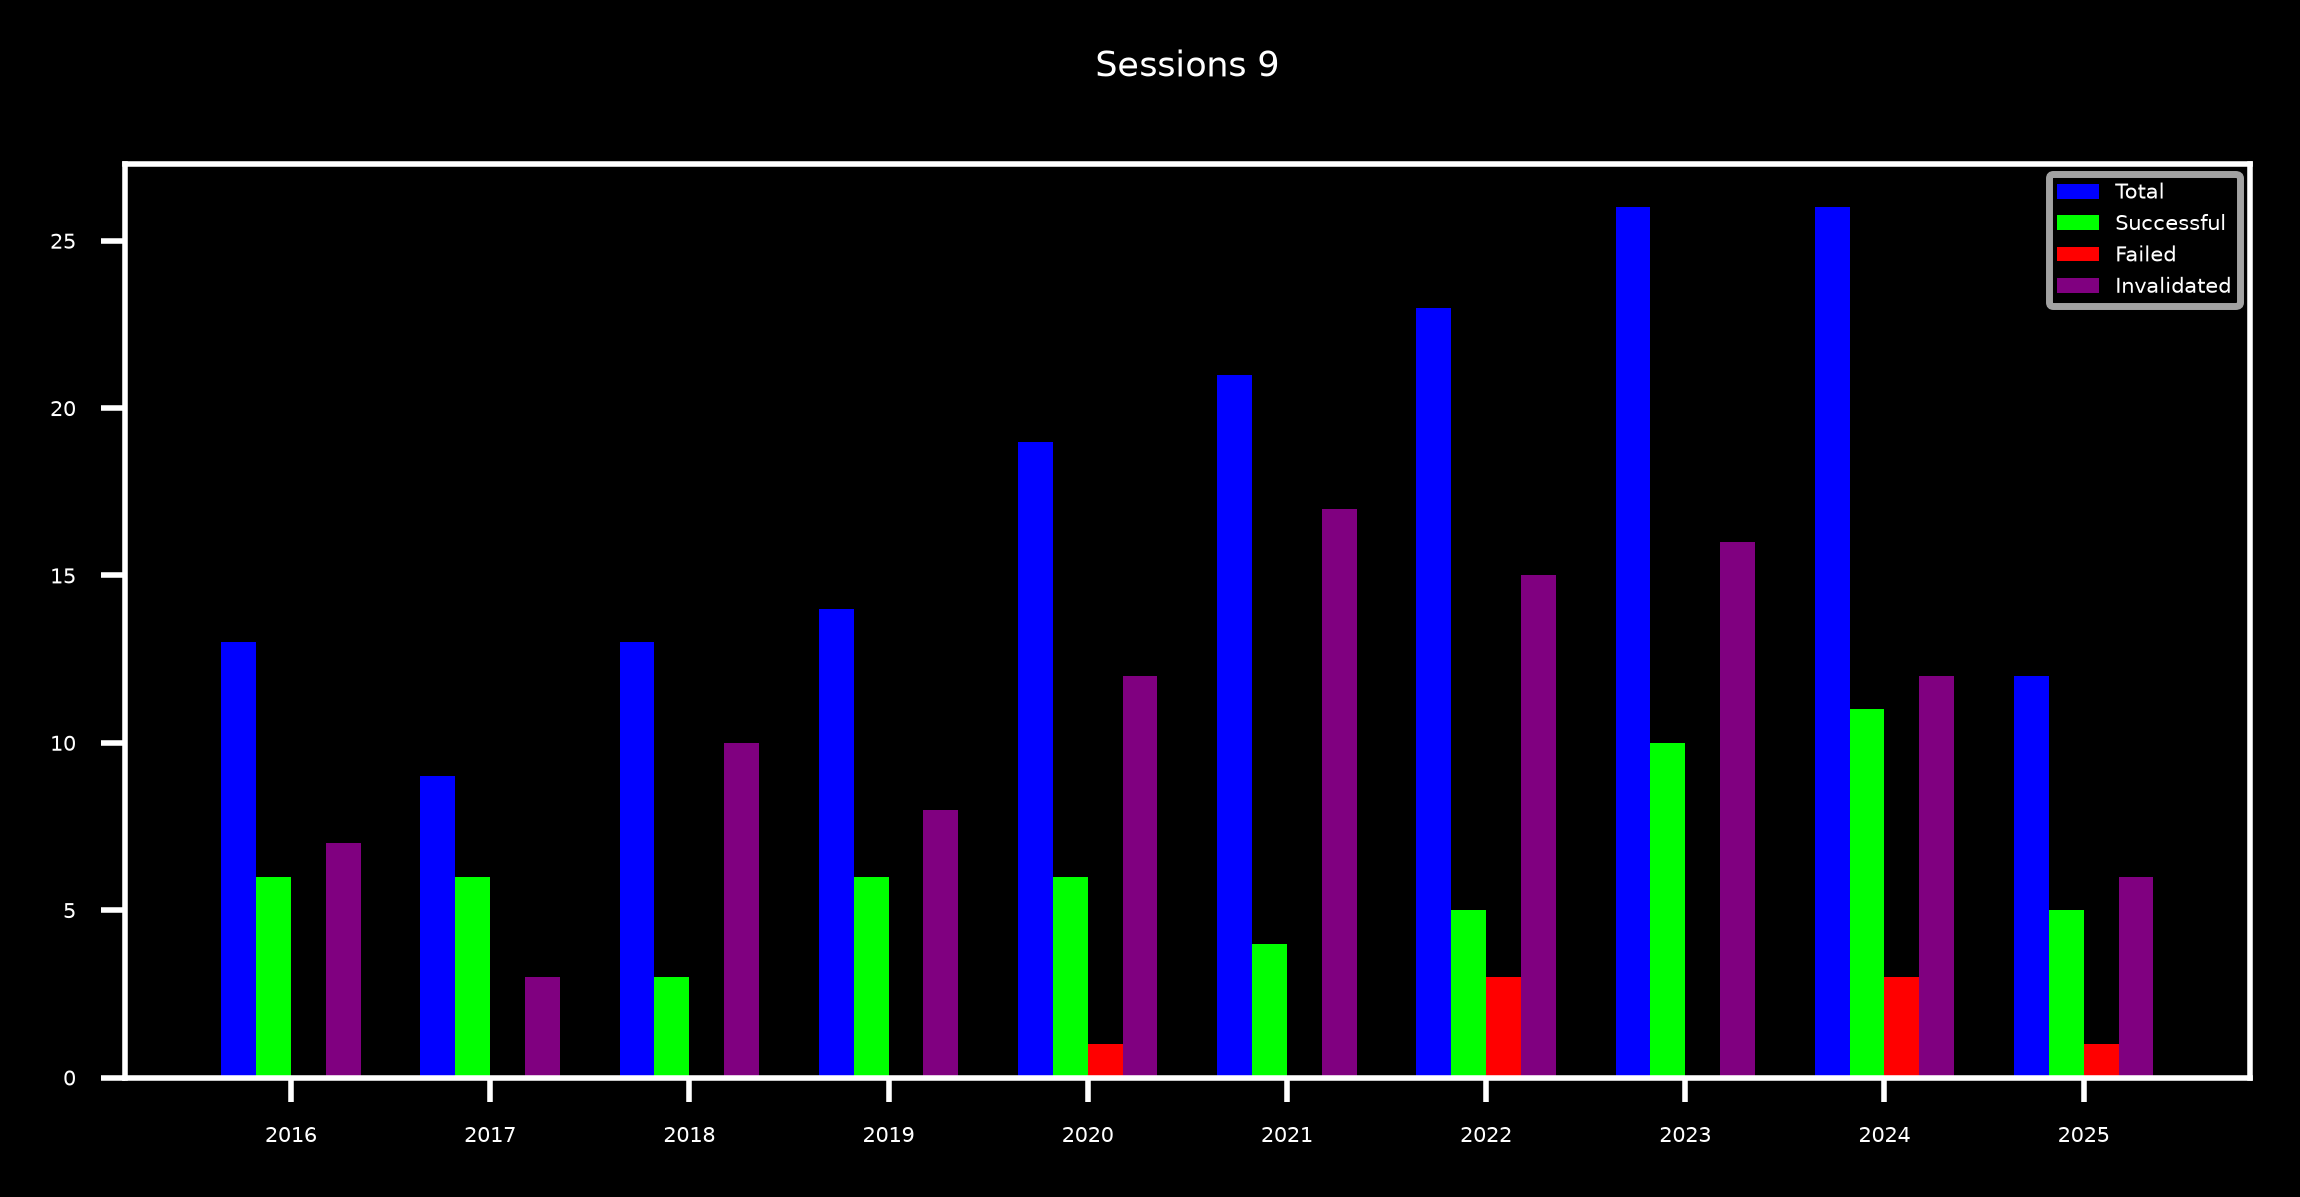

Sessions 10
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  6   │  0   │  7  │  46  │  0   │  53  │ 3.64 │ 4.89 │ -5.… │ 2.7… │ -1.… │ 1.57 │ 1.38 │ -6.3… │ 0.7… │
│ 2017 │  9   │  6   │  0   │  3  │  66  │  0   │  33  │ 14.… │ 17.… │ -8.… │ 2.6… │ -1.… │ 25.… │ 58.… │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 7.46 │ 5.3  │ -15… │ 0.8x │ -2.… │ -9.… │ -7.… │ -64.… │ 0.0… │
│ 2019 │  14  │  6   │  0   │  8  │  42  │  0   │  57  │ 8.66 │ 8.62 │ -7.… │ 1.5… │ -1.… │ 2.69 │ 2.99 │ -26.… │ 0.5… │
│ 2020 │  19  │  6   │  1   │ 12  │  31  │  5   │  63  │ 13.… │ 8.37 │ -7.9 │ 1.7… │ -1.… │ 1.5  │ 1.44 │ -46.… │ 0.6… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 17.… │ 9.84 │ -13… │ 1.5… │ -2.… │ -1.… │ -1.… │ -48.… │ 0.7… │
│ 2022 │  23  │  4   │  3   │ 16  │  17  │  13  │  69  │ 5.33 │ 6.56 │ -9.… │ 1.3… │ -1.… │ -6.… │ -5.… │ -56.… │ 0.0… │
│ 2023 │  26  │  10  │  0   │ 16  │  38  │  0   │  61  │ 11.… │ 8.88 │ -4.… │ 3.1… │ -1.… │ 7.09 │ 13.… │ -17.… │ 0.0… │
│ 2024 │  26  │  11  │  3   │ 12  │  42  │  11  │  46  │ 5.88 │ 6.42 │ -5.… │ 1.7… │ -1.… │ 2.45 │ 3.04 │ -13.… │ 0.4… │
│ 2025 │  12  │  5   │  1   │  6  │  41  │  8   │  50  │ 6.25 │ 5.54 │ -3.… │ 2.0x │ -1.… │ 5.99 │ 8.67 │ -12.… │ 0.2… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

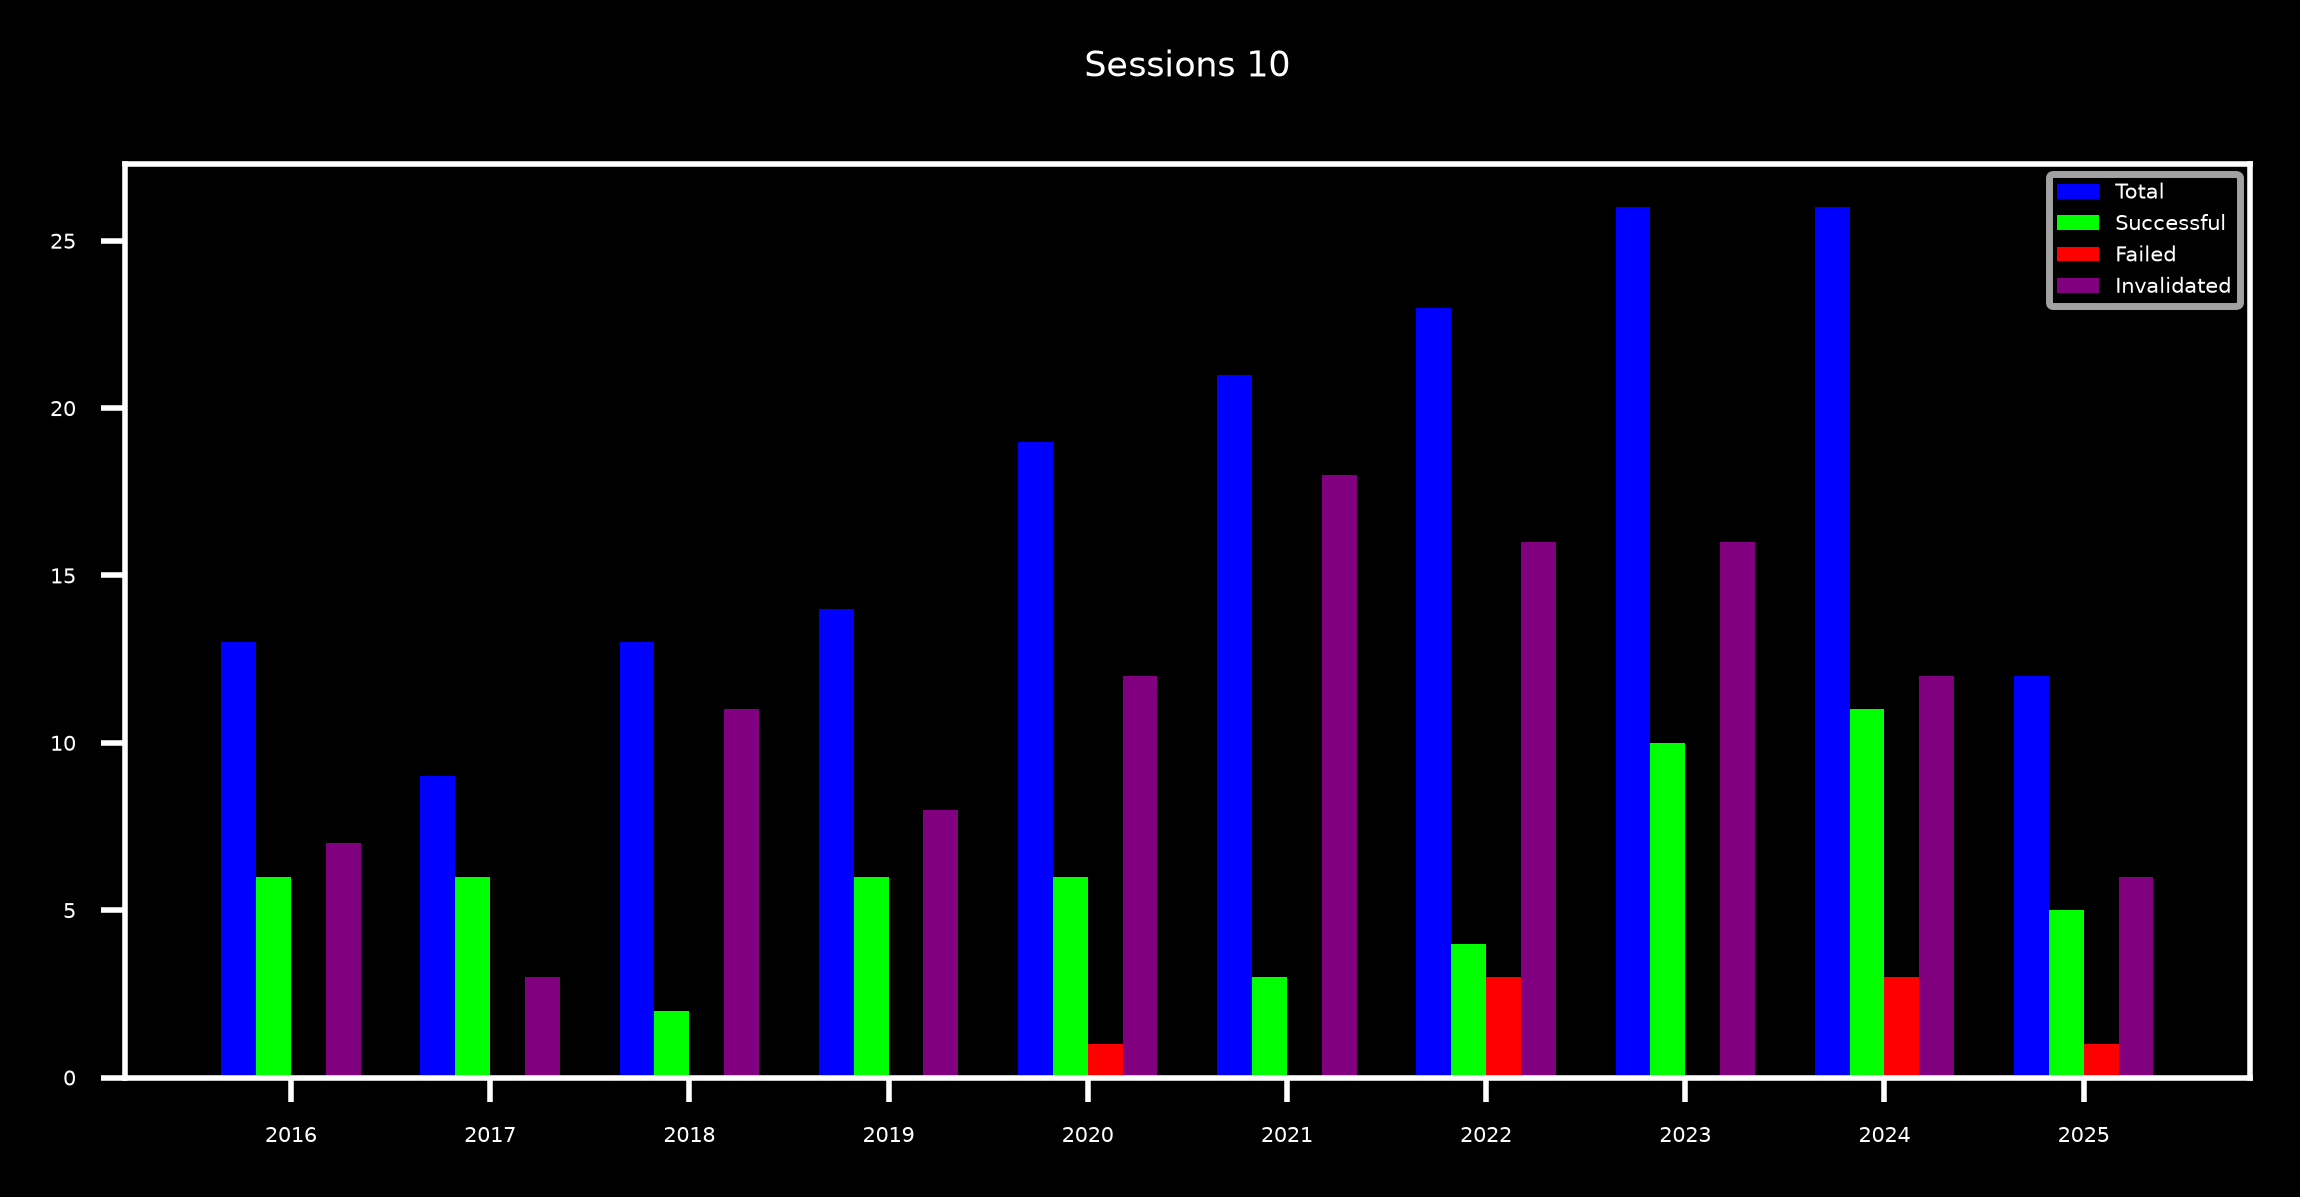

Sessions 11
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  6   │  0   │  7  │  46  │  0   │  53  │ 3.5  │ 6.01 │ -5.… │ 3.0… │ -1.… │ 3.05 │ 3.73 │ -6.5… │ 0.5… │
│ 2017 │  9   │  6   │  0   │  3  │  66  │  0   │  33  │ 16.0 │ 19.… │ -8.… │ 2.8… │ -1.… │ 27.… │ 0.0  │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 4.33 │ 5.32 │ -15… │ 0.8… │ -2.… │ -9.… │ -7.… │ -64.… │ 0.0… │
│ 2019 │  14  │  6   │  0   │  8  │  42  │  0   │  57  │ 8.95 │ 10.… │ -8.… │ 1.8x │ -1.… │ 5.95 │ 8.51 │ -19.… │ 0.1… │
│ 2020 │  19  │  6   │  1   │ 12  │  31  │  5   │  63  │ 15.… │ 9.81 │ -8.… │ 2.0… │ -1.… │ 3.04 │ 3.32 │ -36.… │ 0.4… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 14.9 │ 10.4 │ -13… │ 1.5… │ -2.… │ -1.… │ -1.… │ -47.… │ 0.7… │
│ 2022 │  23  │  5   │  2   │ 16  │  21  │  8   │  69  │ 4.48 │ 6.78 │ -9.… │ 1.4… │ -2.… │ -6.… │ -5.… │ -55.… │ 0.0… │
│ 2023 │  26  │  10  │  0   │ 16  │  38  │  0   │  61  │ 10.… │ 9.35 │ -4.… │ 3.2… │ -1.… │ 8.07 │ 17.… │ -15.… │ 0.0… │
│ 2024 │  26  │  9   │  5   │ 12  │  34  │  19  │  46  │ 7.2  │ 7.11 │ -5.… │ 1.9… │ -1.… │ 3.11 │ 5.0  │ -16.… │ 0.3… │
│ 2025 │  11  │  4   │  1   │  6  │  36  │  9   │  54  │ 5.78 │ 5.63 │ -4.… │ 2.1… │ -1.… │ 4.38 │ 6.18 │ -13.… │ 0.3… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

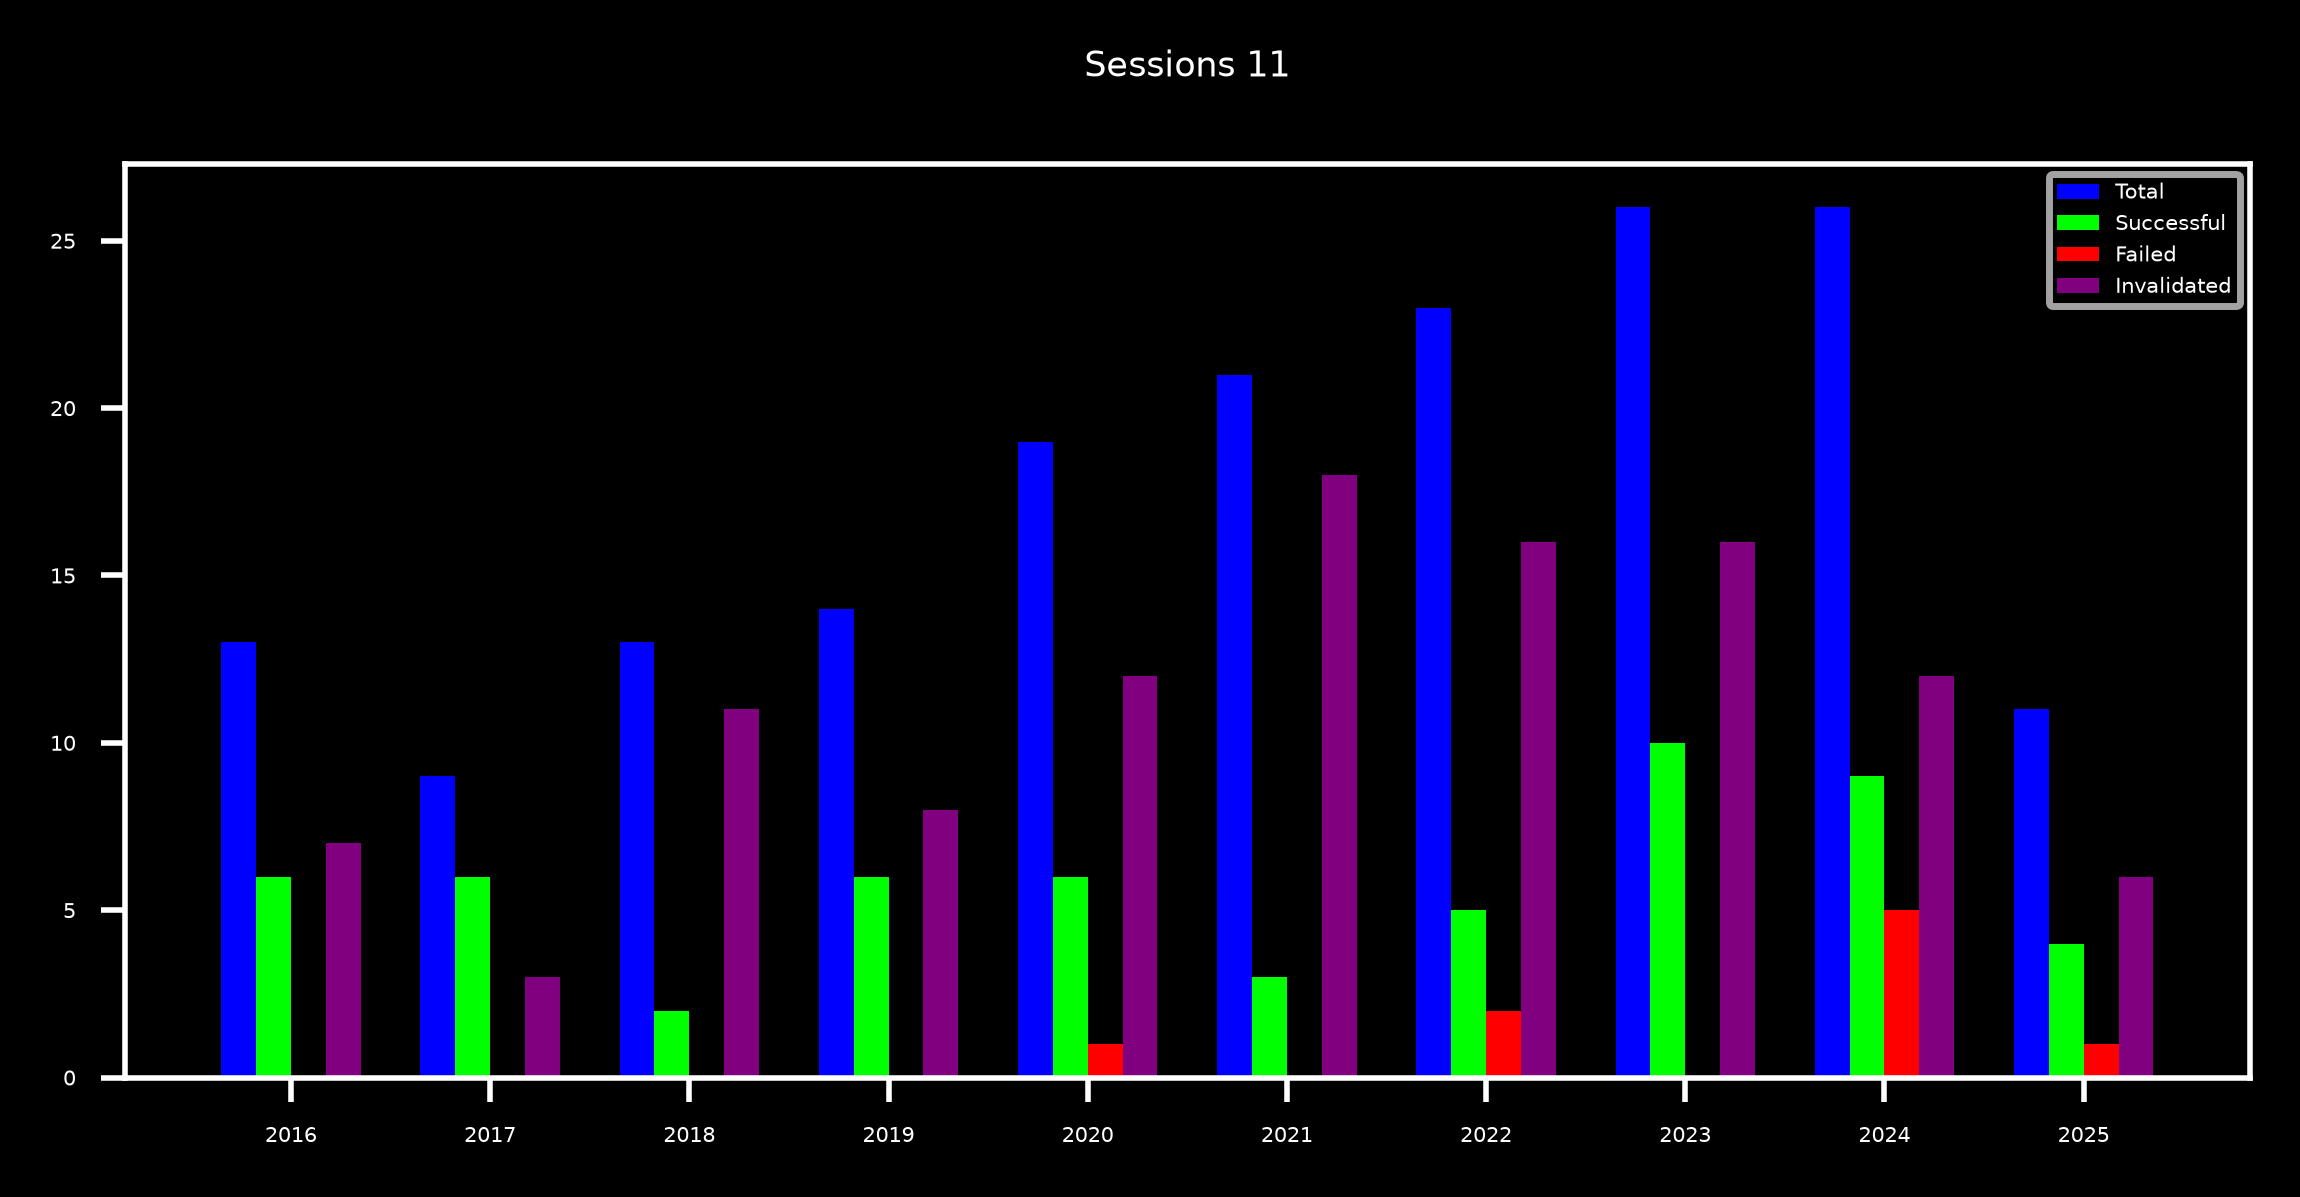

Sessions 12
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  6   │  0   │  7  │  46  │  0   │  53  │ 4.15 │ 6.84 │ -5.… │ 3.5… │ -1.… │ 3.93 │ 5.07 │ -4.3… │ 0.3… │
│ 2017 │  9   │  6   │  0   │  3  │  66  │  0   │  33  │ 17.… │ 20.… │ -8.… │ 2.9… │ -1.… │ 32.… │ 0.0  │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 6.64 │ 5.52 │ -15… │ 0.8… │ -2.… │ -8.… │ -6.… │ -61.… │ 0.0… │
│ 2019 │  14  │  6   │  0   │  8  │  42  │  0   │  57  │ 9.51 │ 11.… │ -8.… │ 2.2… │ -1.… │ 8.28 │ 22.… │ -8.3… │ 0.0… │
│ 2020 │  19  │  6   │  1   │ 12  │  31  │  5   │  63  │ 15.… │ 10.… │ -8.… │ 2.1… │ -1.… │ 2.79 │ 3.16 │ -42.… │ 0.4… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 15.… │ 11.… │ -14… │ 1.6… │ -2.… │ -2.… │ -2.… │ -55.… │ 0.4… │
│ 2022 │  23  │  4   │  3   │ 16  │  17  │  13  │  69  │ 5.94 │ 6.82 │ -9.… │ 1.4… │ -2.… │ -6.… │ -5.… │ -58.… │ 0.0… │
│ 2023 │  26  │  10  │  0   │ 16  │  38  │  0   │  61  │ 10.… │ 9.73 │ -4.… │ 3.3… │ -1.… │ 7.77 │ 19.… │ -17.… │ 0.0… │
│ 2024 │  26  │  11  │  3   │ 12  │  42  │  11  │  46  │ 6.56 │ 7.26 │ -6.… │ 2.0… │ -1.… │ 3.11 │ 5.01 │ -23.… │ 0.3… │
│ 2025 │  11  │  2   │  2   │  7  │  18  │  18  │  63  │ 6.79 │ 6.11 │ -4.… │ 2.3… │ -1.… │ 2.75 │ 4.04 │ -12.… │ 0.5… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

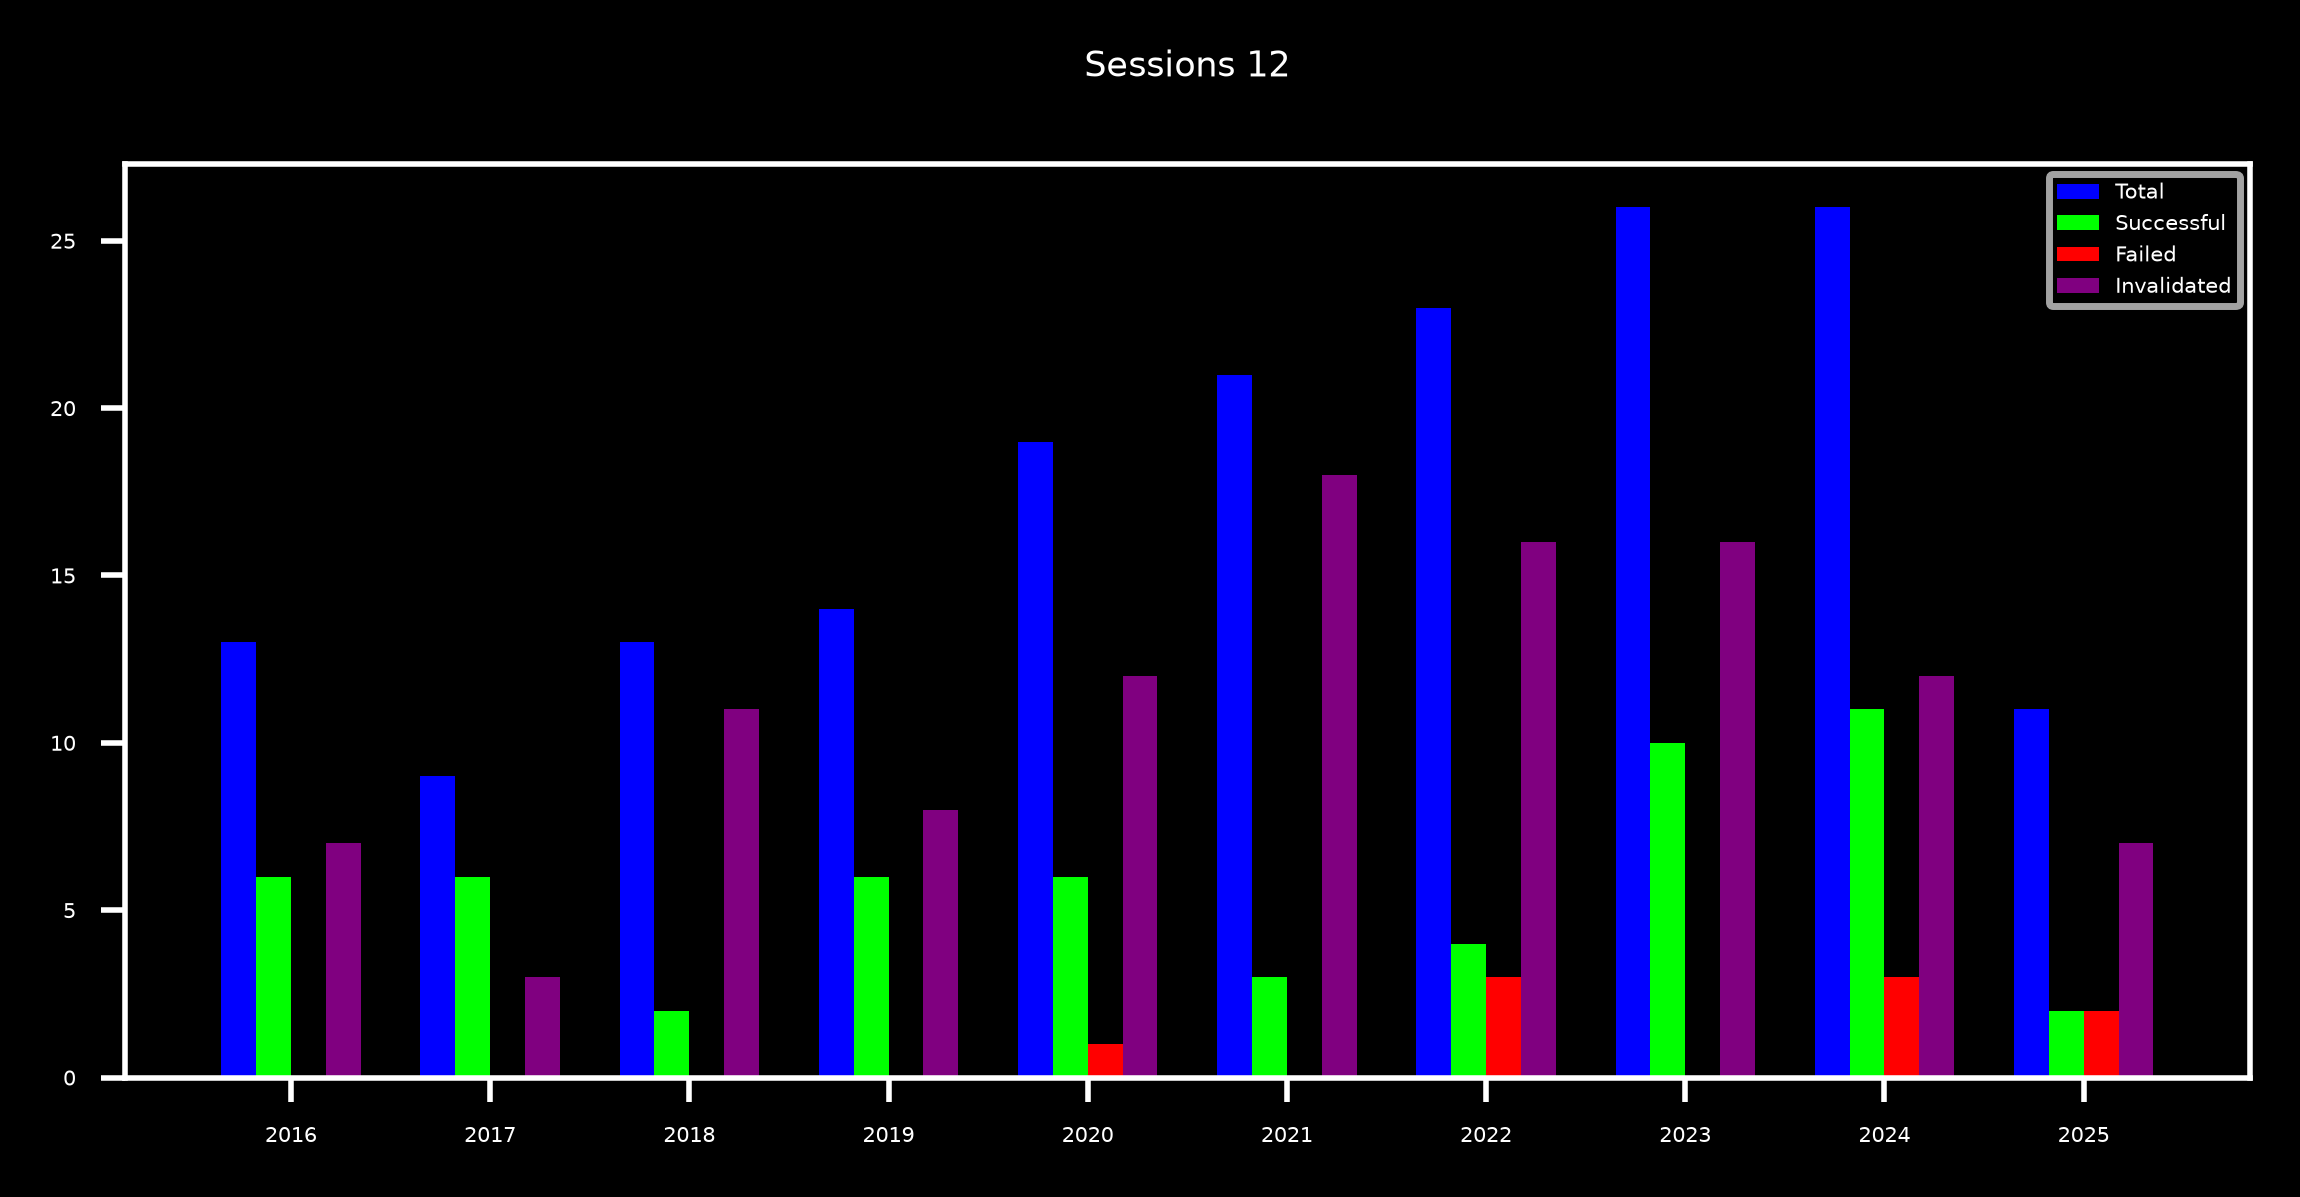

Sessions 13
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  6   │  0   │  7  │  46  │  0   │  53  │ 3.48 │ 7.02 │ -5.… │ 3.6… │ -1.… │ 5.44 │ 9.22 │ -6.1… │ 0.2… │
│ 2017 │  9   │  6   │  0   │  3  │  66  │  0   │  33  │ 18.… │ 21.… │ -8.… │ 3.1… │ -1.… │ 29.… │ 0.0  │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 6.78 │ 5.82 │ -16… │ 0.8… │ -2.… │ -8.… │ -6.… │ -63.… │ 0.0… │
│ 2019 │  14  │  6   │  0   │  8  │  42  │  0   │  57  │ 10.… │ 12.… │ -8.… │ 2.3… │ -1.… │ 8.88 │ 24.… │ -8.2… │ 0.0… │
│ 2020 │  19  │  6   │  1   │ 12  │  31  │  5   │  63  │ 16.2 │ 11.… │ -8.… │ 2.4x │ -1.… │ 3.42 │ 3.44 │ -40.… │ 0.3… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 14.… │ 11.… │ -14… │ 1.7… │ -2.… │ -0.… │ -0.… │ -45.… │ 0.8… │
│ 2022 │  23  │  4   │  3   │ 16  │  17  │  13  │  69  │ 5.34 │ 6.83 │ -10… │ 1.4… │ -2.… │ -5.9 │ -4.9 │ -57.… │ 0.0… │
│ 2023 │  26  │  9   │  1   │ 16  │  34  │  3   │  61  │ 11.… │ 10.… │ -4.… │ 3.5x │ -1.… │ 8.06 │ 21.… │ -17.… │ 0.0… │
│ 2024 │  26  │  10  │  3   │ 13  │  38  │  11  │  50  │ 9.12 │ 7.96 │ -6.4 │ 2.2… │ -1.… │ 3.54 │ 6.02 │ -27.… │ 0.2… │
│ 2025 │  11  │  3   │  1   │  7  │  27  │  9   │  63  │ 4.21 │ 6.11 │ -5.… │ 2.3… │ -1.… │ -1.… │ -1.… │ -18.… │ 0.8… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

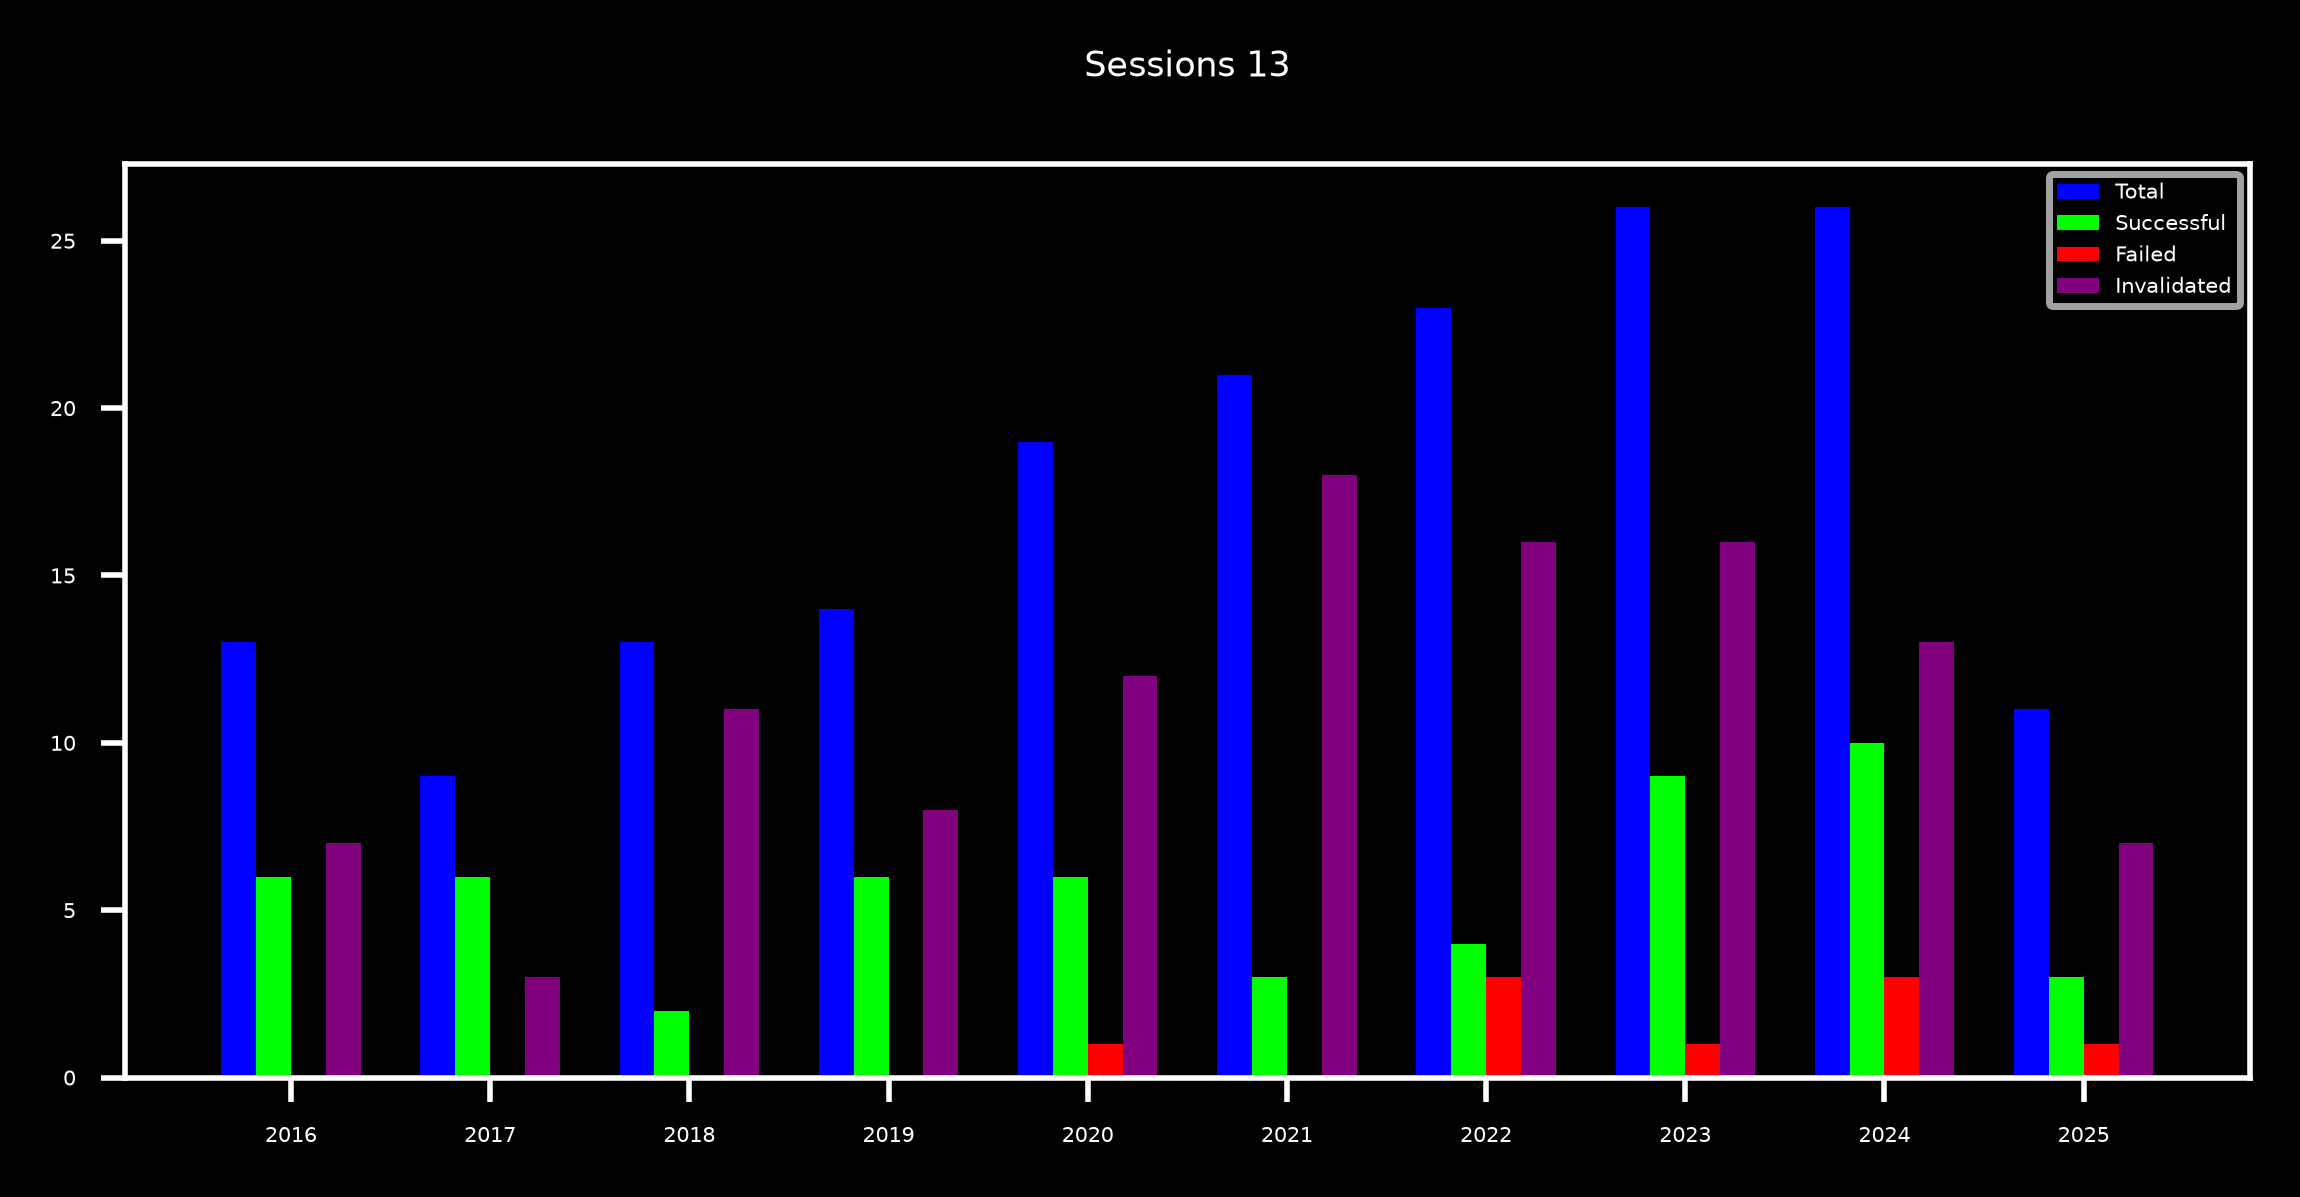

Sessions 14
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  6   │  0   │  7  │  46  │  0   │  53  │ 3.66 │ 7.29 │ -5.… │ 3.7… │ -1.… │ 4.93 │ 7.07 │ -9.4… │ 0.2… │
│ 2017 │  9   │  6   │  0   │  3  │  66  │  0   │  33  │ 20.… │ 23.… │ -8.… │ 3.4… │ -1.… │ 27.… │ 0.0  │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 6.19 │ 5.91 │ -18… │ 0.9… │ -3.… │ -9.… │ -6.… │ -61.… │ 0.0… │
│ 2019 │  14  │  6   │  0   │  8  │  42  │  0   │  57  │ 13.… │ 14.… │ -8.… │ 2.7… │ -1.… │ 8.43 │ 44.… │ -4.2… │ 0.0… │
│ 2020 │  19  │  6   │  1   │ 12  │  31  │  5   │  63  │ 16.… │ 11.… │ -8.… │ 2.5… │ -1.… │ 3.44 │ 3.38 │ -43.… │ 0.3… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 13.… │ 12.… │ -15… │ 1.8… │ -2.… │ -0.… │ -0.… │ -49.… │ 0.8… │
│ 2022 │  23  │  4   │  3   │ 16  │  17  │  13  │  69  │ 7.31 │ 7.21 │ -10… │ 1.5… │ -2.… │ -5.… │ -4.… │ -64.… │ 0.1… │
│ 2023 │  26  │  8   │  2   │ 16  │  30  │  7   │  61  │ 12.9 │ 10.7 │ -4.… │ 3.7… │ -1.… │ 7.65 │ 23.… │ -15.… │ 0.0… │
│ 2024 │  26  │  10  │  3   │ 13  │  38  │  11  │  50  │ 11.… │ 8.7  │ -6.… │ 2.4… │ -1.… │ 3.46 │ 5.69 │ -37.… │ 0.2… │
│ 2025 │  11  │  2   │  2   │  7  │  18  │  18  │  63  │ 4.74 │ 6.18 │ -5.… │ 2.4x │ -2.… │ -2.… │ -2.… │ -16.… │ 0.6… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

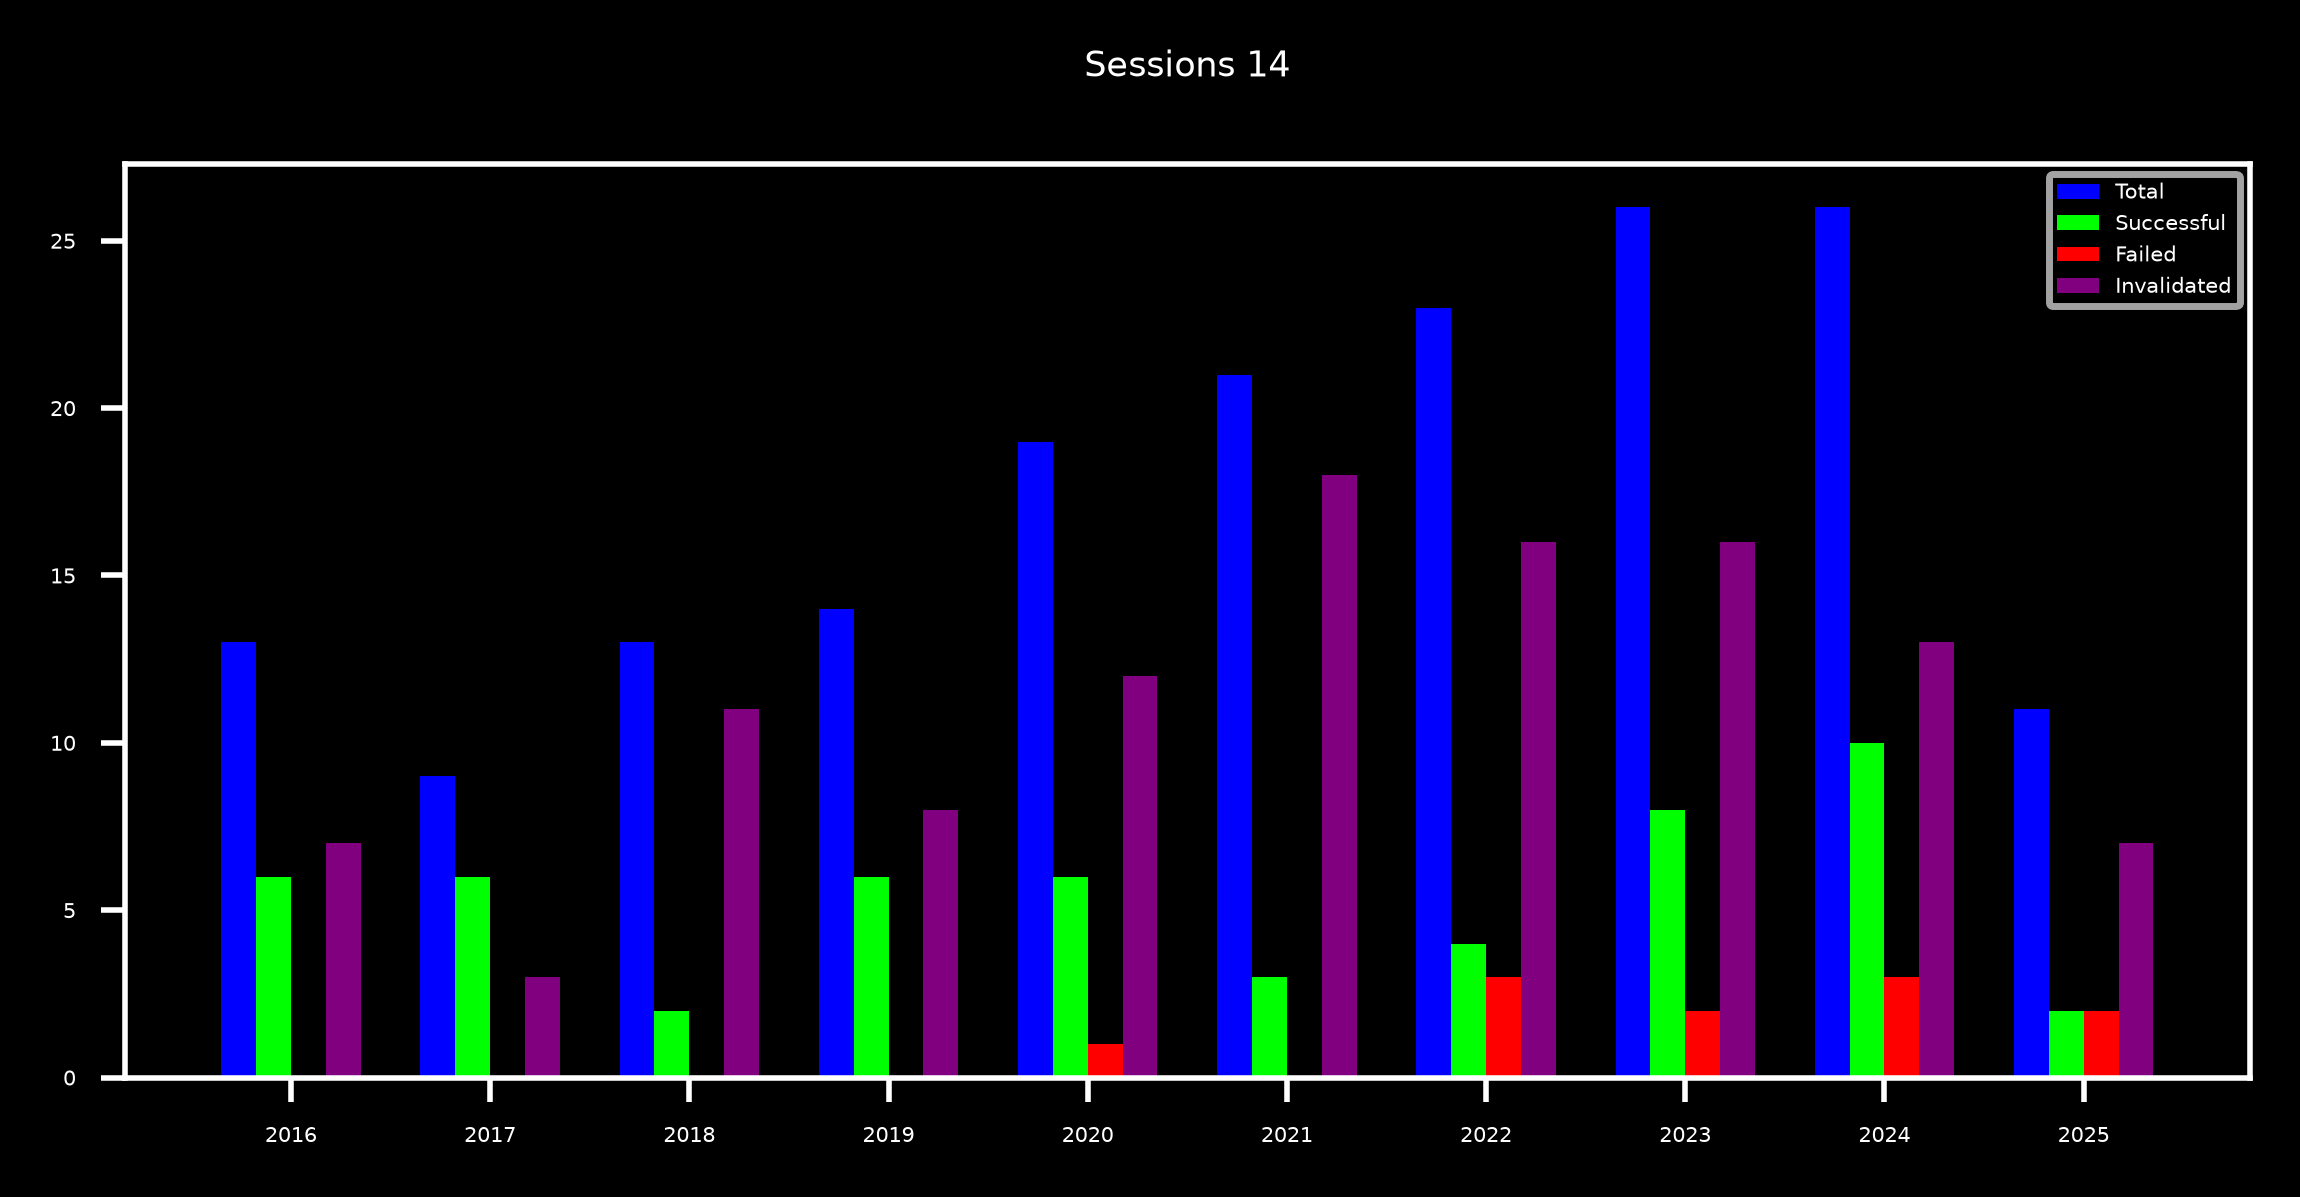

Sessions 15
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  6   │  0   │  7  │  46  │  0   │  53  │ 3.65 │ 8.28 │ -5.… │ 4.1… │ -2.… │ 3.72 │ 5.1  │ -11.… │ 0.4… │
│ 2017 │  9   │  5   │  0   │  4  │  55  │  0   │  44  │ 28.… │ 26.… │ -19… │ 3.7… │ -3.… │ 23.… │ 75.… │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 6.07 │ 5.96 │ -18… │ 0.9… │ -3.… │ -11… │ -8.… │ -70.… │ 0.0… │
│ 2019 │  14  │  5   │  1   │  8  │  35  │  7   │  57  │ 11.… │ 15.… │ -8.… │ 2.8… │ -1.… │ 9.31 │ 25.… │ -5.7… │ 0.0… │
│ 2020 │  19  │  7   │  0   │ 12  │  36  │  0   │  63  │ 12.… │ 12.… │ -8.… │ 2.5… │ -1.… │ 3.66 │ 3.38 │ -40.… │ 0.3… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 16.… │ 12.… │ -15… │ 1.8… │ -2.… │ -0.… │ -0.… │ -45.… │ 0.99 │
│ 2022 │  23  │  4   │  2   │ 17  │  17  │  8   │  73  │ 6.29 │ 7.45 │ -10… │ 1.6x │ -2.… │ -6.0 │ -5.… │ -61.… │ 0.0… │
│ 2023 │  26  │  9   │  0   │ 17  │  34  │  0   │  65  │ 13.… │ 10.… │ -4.… │ 3.8… │ -1.… │ 8.34 │ 23.… │ -14.… │ 0.0… │
│ 2024 │  26  │  12  │  1   │ 13  │  46  │  3   │  50  │ 9.62 │ 9.02 │ -7.… │ 2.5… │ -1.… │ 3.34 │ 4.6  │ -34.… │ 0.2… │
│ 2025 │  11  │  1   │  2   │  8  │  9   │  18  │  72  │ 9.54 │ 6.18 │ -6.… │ 2.4x │ -2.… │ -3.… │ -3.… │ -22.… │ 0.4… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

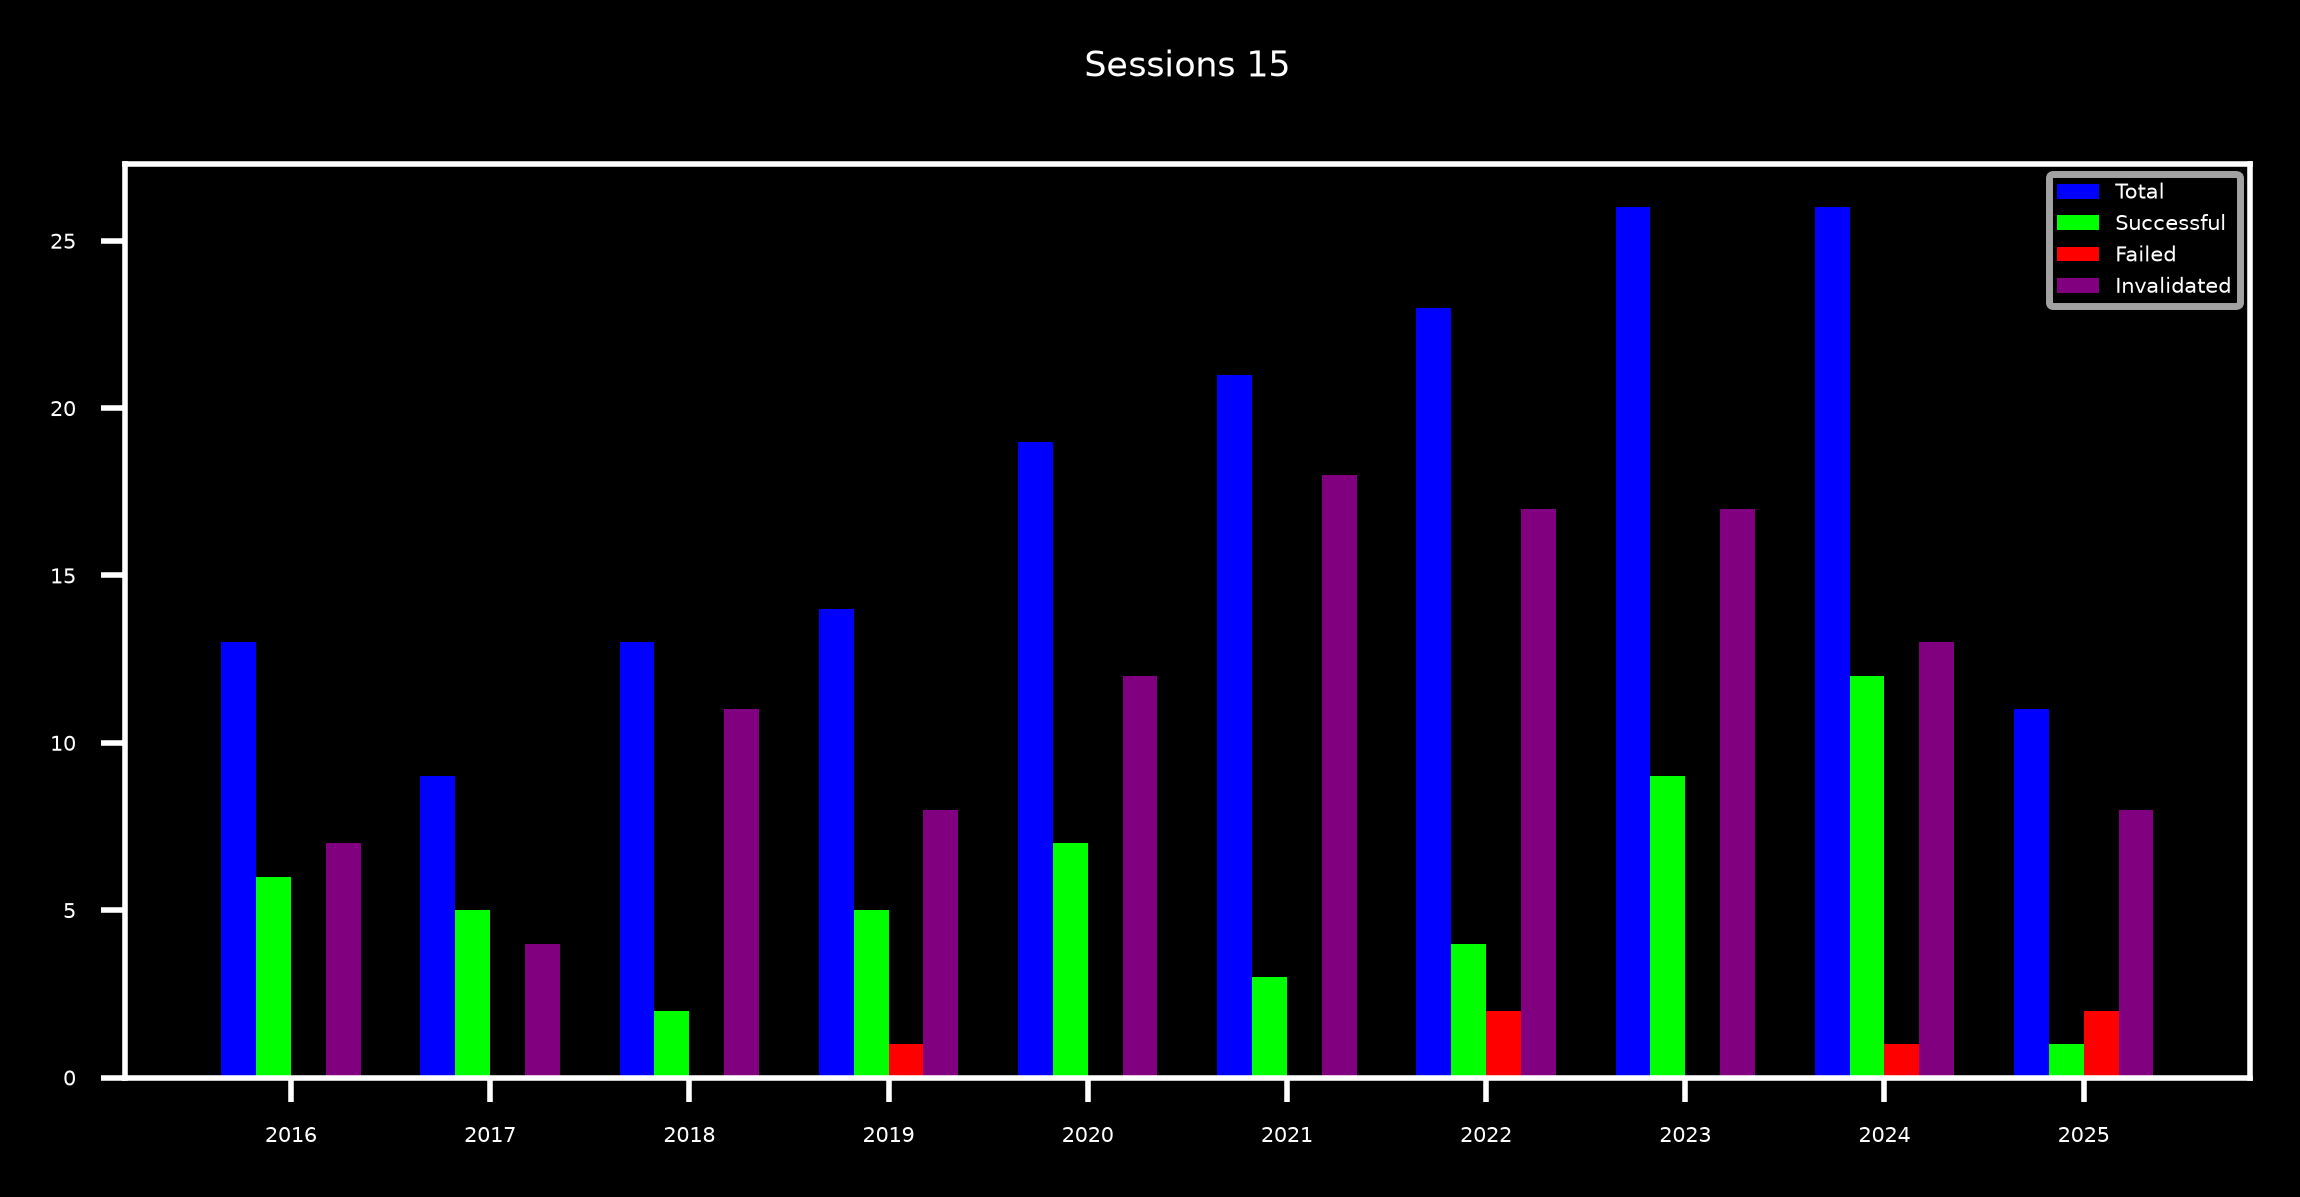

Sessions 16
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  6   │  0   │  7  │  46  │  0   │  53  │ 3.61 │ 8.29 │ -7.… │ 4.1… │ -2.… │ 2.41 │ 2.58 │ -21.… │ 0.5… │
│ 2017 │  9   │  5   │  0   │  4  │  55  │  0   │  44  │ 32.… │ 29.… │ -19… │ 4.0… │ -3.… │ 20.… │ 27.… │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 7.13 │ 5.96 │ -18… │ 0.9… │ -3.… │ -11… │ -8.… │ -69.… │ 0.0… │
│ 2019 │  14  │  4   │  2   │  8  │  28  │  14  │  57  │ 15.… │ 15.… │ -8.… │ 2.9… │ -1.… │ 6.74 │ 18.… │ -8.1… │ 0.1… │
│ 2020 │  19  │  7   │  0   │ 12  │  36  │  0   │  63  │ 16.… │ 12.… │ -8.… │ 2.6… │ -1.… │ 4.63 │ 4.84 │ -39.… │ 0.2… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 20.… │ 12.… │ -16… │ 1.9x │ -2.… │ 0.51 │ 0.7  │ -54.… │ 0.8… │
│ 2022 │  23  │  4   │  2   │ 17  │  17  │  8   │  73  │ 7.01 │ 7.59 │ -10… │ 1.6… │ -2.… │ -4.… │ -4.… │ -61.… │ 0.1… │
│ 2023 │  26  │  9   │  0   │ 17  │  34  │  0   │  65  │ 12.… │ 11.… │ -5.… │ 3.9… │ -1.… │ 7.77 │ 16.… │ -21.… │ 0.0… │
│ 2024 │  26  │  10  │  3   │ 13  │  38  │  11  │  50  │ 12.… │ 9.41 │ -7.… │ 2.6… │ -1.… │ 3.44 │ 5.51 │ -36.… │ 0.2… │
│ 2025 │  11  │  1   │  1   │  9  │  9   │  9   │  81  │ 8.39 │ 6.18 │ -6.8 │ 2.4x │ -2.… │ -4.… │ -4.… │ -19.… │ 0.3… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

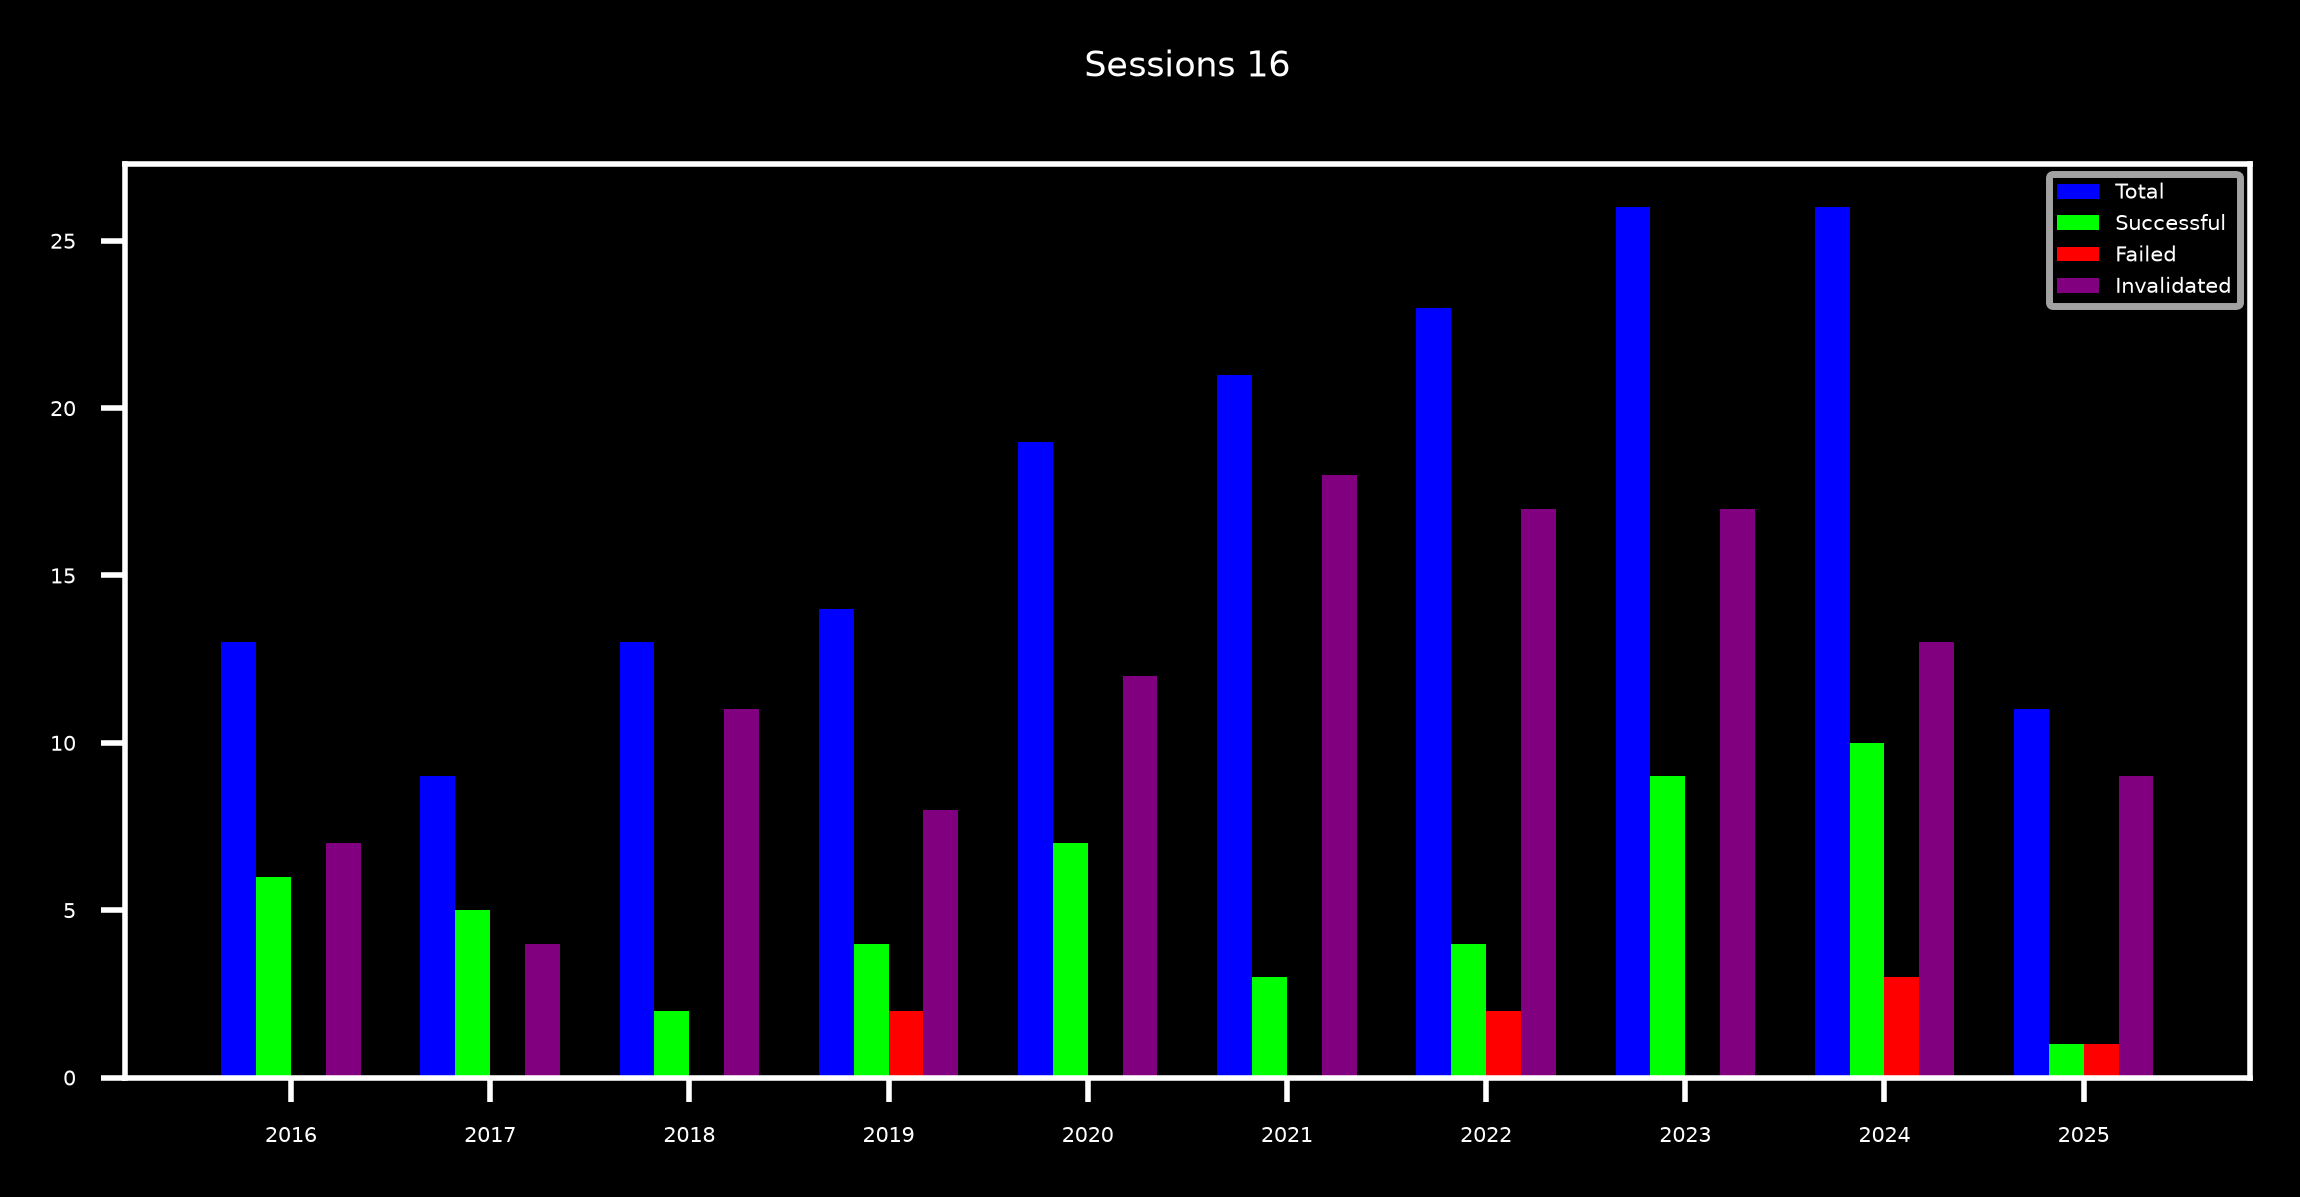

Sessions 17
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  5   │  1   │  7  │  38  │  7   │  53  │ 5.19 │ 8.52 │ -7.… │ 4.3… │ -2.… │ 3.83 │ 5.13 │ -15.… │ 0.4… │
│ 2017 │  9   │  5   │  0   │  4  │  55  │  0   │  44  │ 36.… │ 32.… │ -19… │ 4.3… │ -3.… │ 17.… │ 17.… │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 11.6 │ 6.14 │ -19… │ 0.9… │ -3.… │ -11… │ -8.… │ -73.… │ 0.0… │
│ 2019 │  14  │  5   │  1   │  8  │  35  │  7   │  57  │ 11.7 │ 16.… │ -8.… │ 3.0… │ -1.… │ 7.17 │ 12.… │ -12.… │ 0.1… │
│ 2020 │  19  │  7   │  0   │ 12  │  36  │  0   │  63  │ 18.… │ 13.… │ -8.… │ 2.8… │ -1.… │ 6.06 │ 7.25 │ -30.… │ 0.1… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 21.… │ 13.2 │ -16… │ 1.9… │ -2.… │ 1.21 │ 1.73 │ -52.… │ 0.7… │
│ 2022 │  23  │  3   │  3   │ 17  │  13  │  13  │  73  │ 7.37 │ 7.82 │ -11… │ 1.6… │ -2.… │ -5.… │ -5.… │ -60.… │ 0.0… │
│ 2023 │  26  │  8   │  0   │ 18  │  30  │  0   │  69  │ 12.… │ 11.… │ -5.7 │ 3.9… │ -1.… │ 5.58 │ 10.1 │ -24.… │ 0.0… │
│ 2024 │  26  │  12  │  1   │ 13  │  46  │  3   │  50  │ 10.… │ 9.86 │ -7.9 │ 2.7… │ -1.… │ 3.4  │ 4.79 │ -39.… │ 0.2… │
│ 2025 │  11  │  1   │  1   │  9  │  9   │  9   │  81  │ 8.29 │ 6.18 │ -7.… │ 2.4x │ -2.… │ -4.… │ -4.… │ -23.… │ 0.3… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

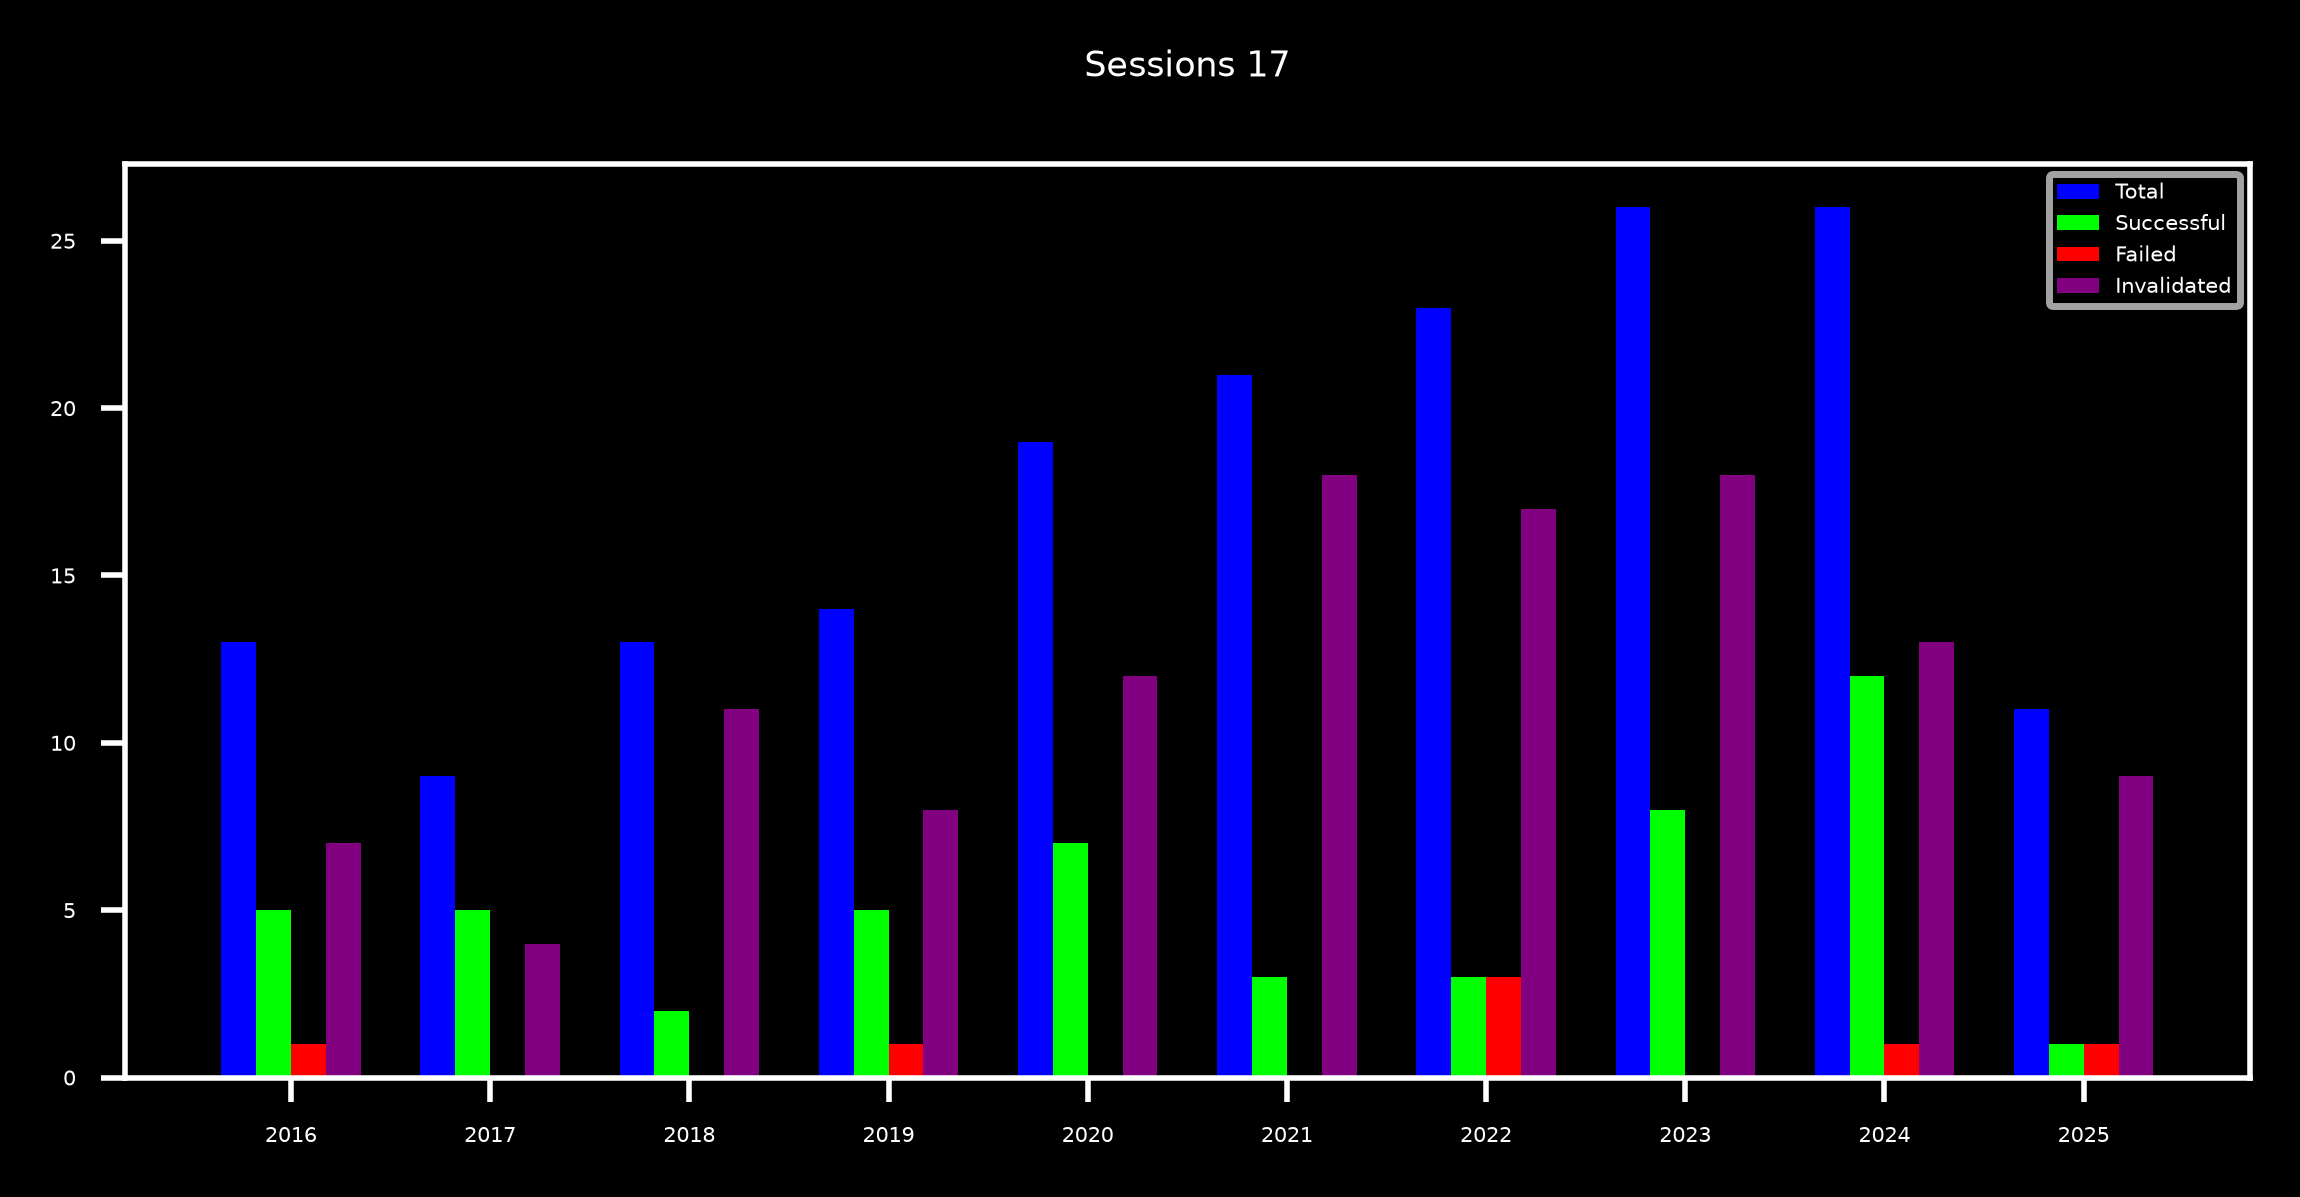

Sessions 18
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  5   │  0   │  8  │  38  │  0   │  61  │ 5.96 │ 8.87 │ -7.… │ 4.5… │ -2.… │ 3.96 │ 5.42 │ -13.… │ 0.3… │
│ 2017 │  9   │  5   │  0   │  4  │  55  │  0   │  44  │ 38.… │ 33.… │ -19… │ 4.5… │ -3.… │ 18.… │ 23.… │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 17.… │ 6.99 │ -19… │ 1.1… │ -3.… │ -9.… │ -8.… │ -68.… │ 0.0… │
│ 2019 │  14  │  5   │  1   │  8  │  35  │  7   │  57  │ 9.68 │ 16.… │ -8.… │ 3.0… │ -1.… │ 8.7  │ 11.0 │ -13.… │ 0.0… │
│ 2020 │  19  │  7   │  0   │ 12  │  36  │  0   │  63  │ 15.… │ 13.… │ -8.… │ 2.8… │ -1.… │ 5.44 │ 6.63 │ -30.… │ 0.1… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 22.… │ 13.… │ -16… │ 2.0… │ -2.… │ 1.06 │ 1.33 │ -57.… │ 0.7… │
│ 2022 │  23  │  5   │  1   │ 17  │  21  │  4   │  73  │ 5.8  │ 7.84 │ -11… │ 1.6… │ -2.… │ -5.… │ -4.… │ -56.… │ 0.1… │
│ 2023 │  26  │  8   │  0   │ 18  │  30  │  0   │  69  │ 14.… │ 11.… │ -5.… │ 4.0… │ -1.… │ 6.68 │ 12.… │ -22.… │ 0.0… │
│ 2024 │  26  │  11  │  2   │ 13  │  42  │  7   │  50  │ 13.… │ 10.… │ -7.… │ 2.9… │ -2.… │ 4.43 │ 7.53 │ -36.… │ 0.1… │
│ 2025 │  11  │  2   │  0   │  9  │  18  │  0   │  81  │ 4.58 │ 6.18 │ -7.… │ 2.4x │ -2.… │ -3.… │ -3.… │ -22.… │ 0.4… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

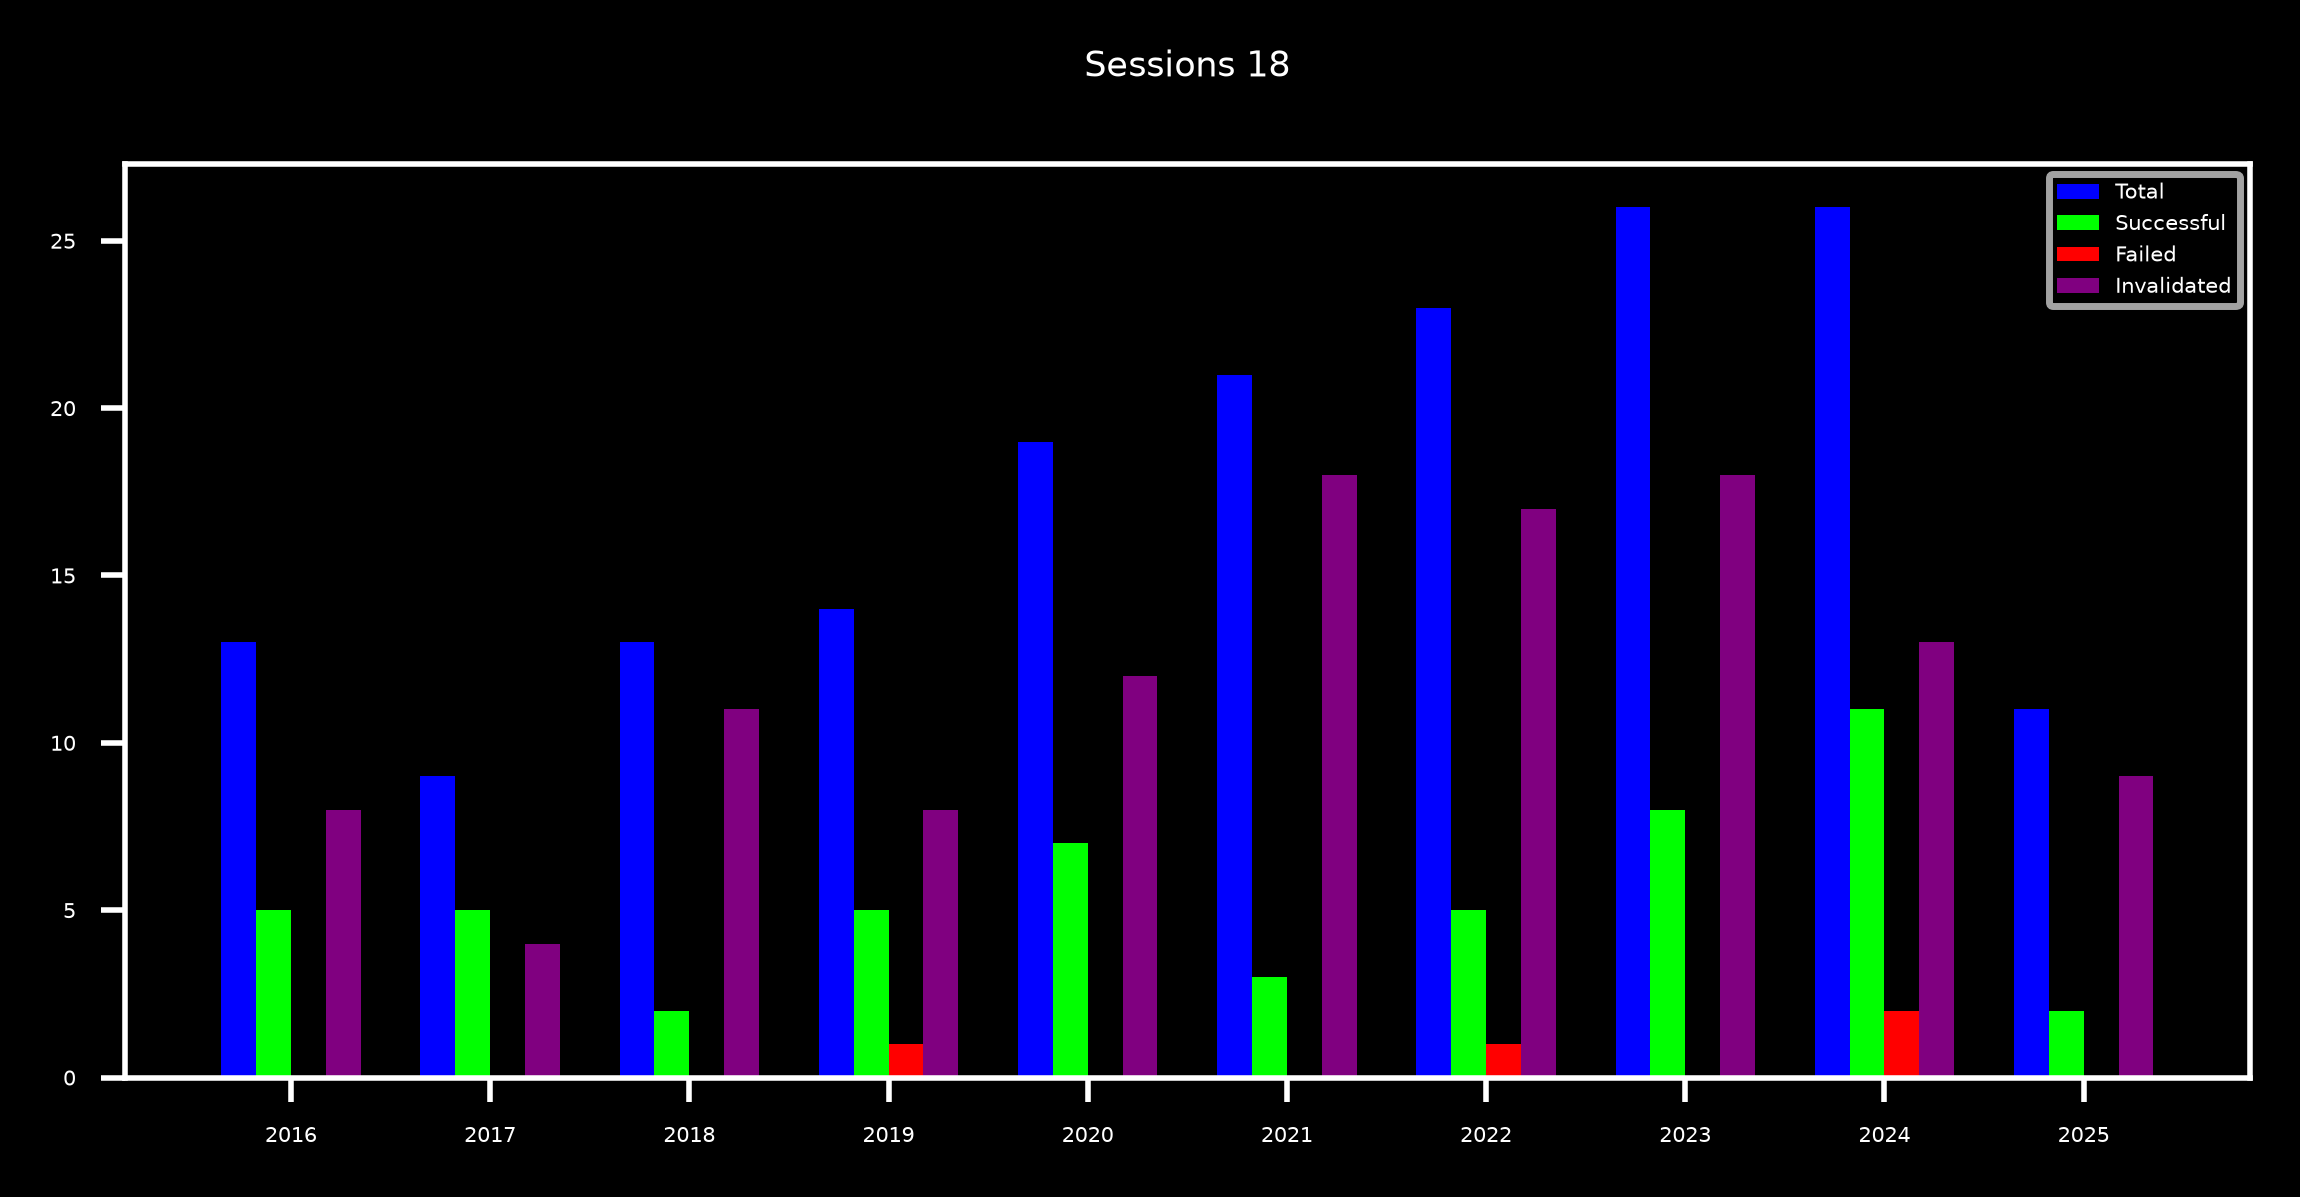

Sessions 19
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  5   │  0   │  8  │  38  │  0   │  61  │ 6.24 │ 9.11 │ -7.… │ 4.8… │ -2.… │ 3.91 │ 4.28 │ -14.… │ 0.3… │
│ 2017 │  9   │  5   │  0   │  4  │  55  │  0   │  44  │ 36.… │ 35.… │ -19… │ 4.7… │ -3.… │ 20.… │ 27.… │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 17.… │ 7.16 │ -20… │ 1.1… │ -3.… │ -8.… │ -7.… │ -66.… │ 0.0… │
│ 2019 │  14  │  5   │  1   │  8  │  35  │  7   │  57  │ 10.… │ 17.… │ -8.… │ 3.1… │ -1.… │ 10.… │ 13.… │ -12.… │ 0.0… │
│ 2020 │  19  │  7   │  0   │ 12  │  36  │  0   │  63  │ 16.… │ 13.… │ -9.… │ 3.0… │ -2.… │ 5.84 │ 7.24 │ -30.… │ 0.1… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 25.… │ 14.… │ -16… │ 2.0… │ -2.… │ 1.37 │ 1.94 │ -59.… │ 0.6… │
│ 2022 │  23  │  4   │  2   │ 17  │  17  │  8   │  73  │ 8.18 │ 8.21 │ -11… │ 1.7x │ -2.… │ -5.… │ -4.… │ -58.… │ 0.1… │
│ 2023 │  26  │  8   │  0   │ 18  │  30  │  0   │  69  │ 15.… │ 12.… │ -5.… │ 4.4… │ -1.… │ 7.68 │ 12.… │ -21.… │ 0.0… │
│ 2024 │  26  │  10  │  2   │ 14  │  38  │  7   │  53  │ 16.… │ 11.… │ -8.… │ 3.2x │ -2.… │ 4.82 │ 8.28 │ -40.… │ 0.1… │
│ 2025 │  11  │  1   │  1   │  9  │  9   │  9   │  81  │ 7.84 │ 6.18 │ -7.… │ 2.4x │ -2.… │ -6.… │ -5.… │ -24.… │ 0.2… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

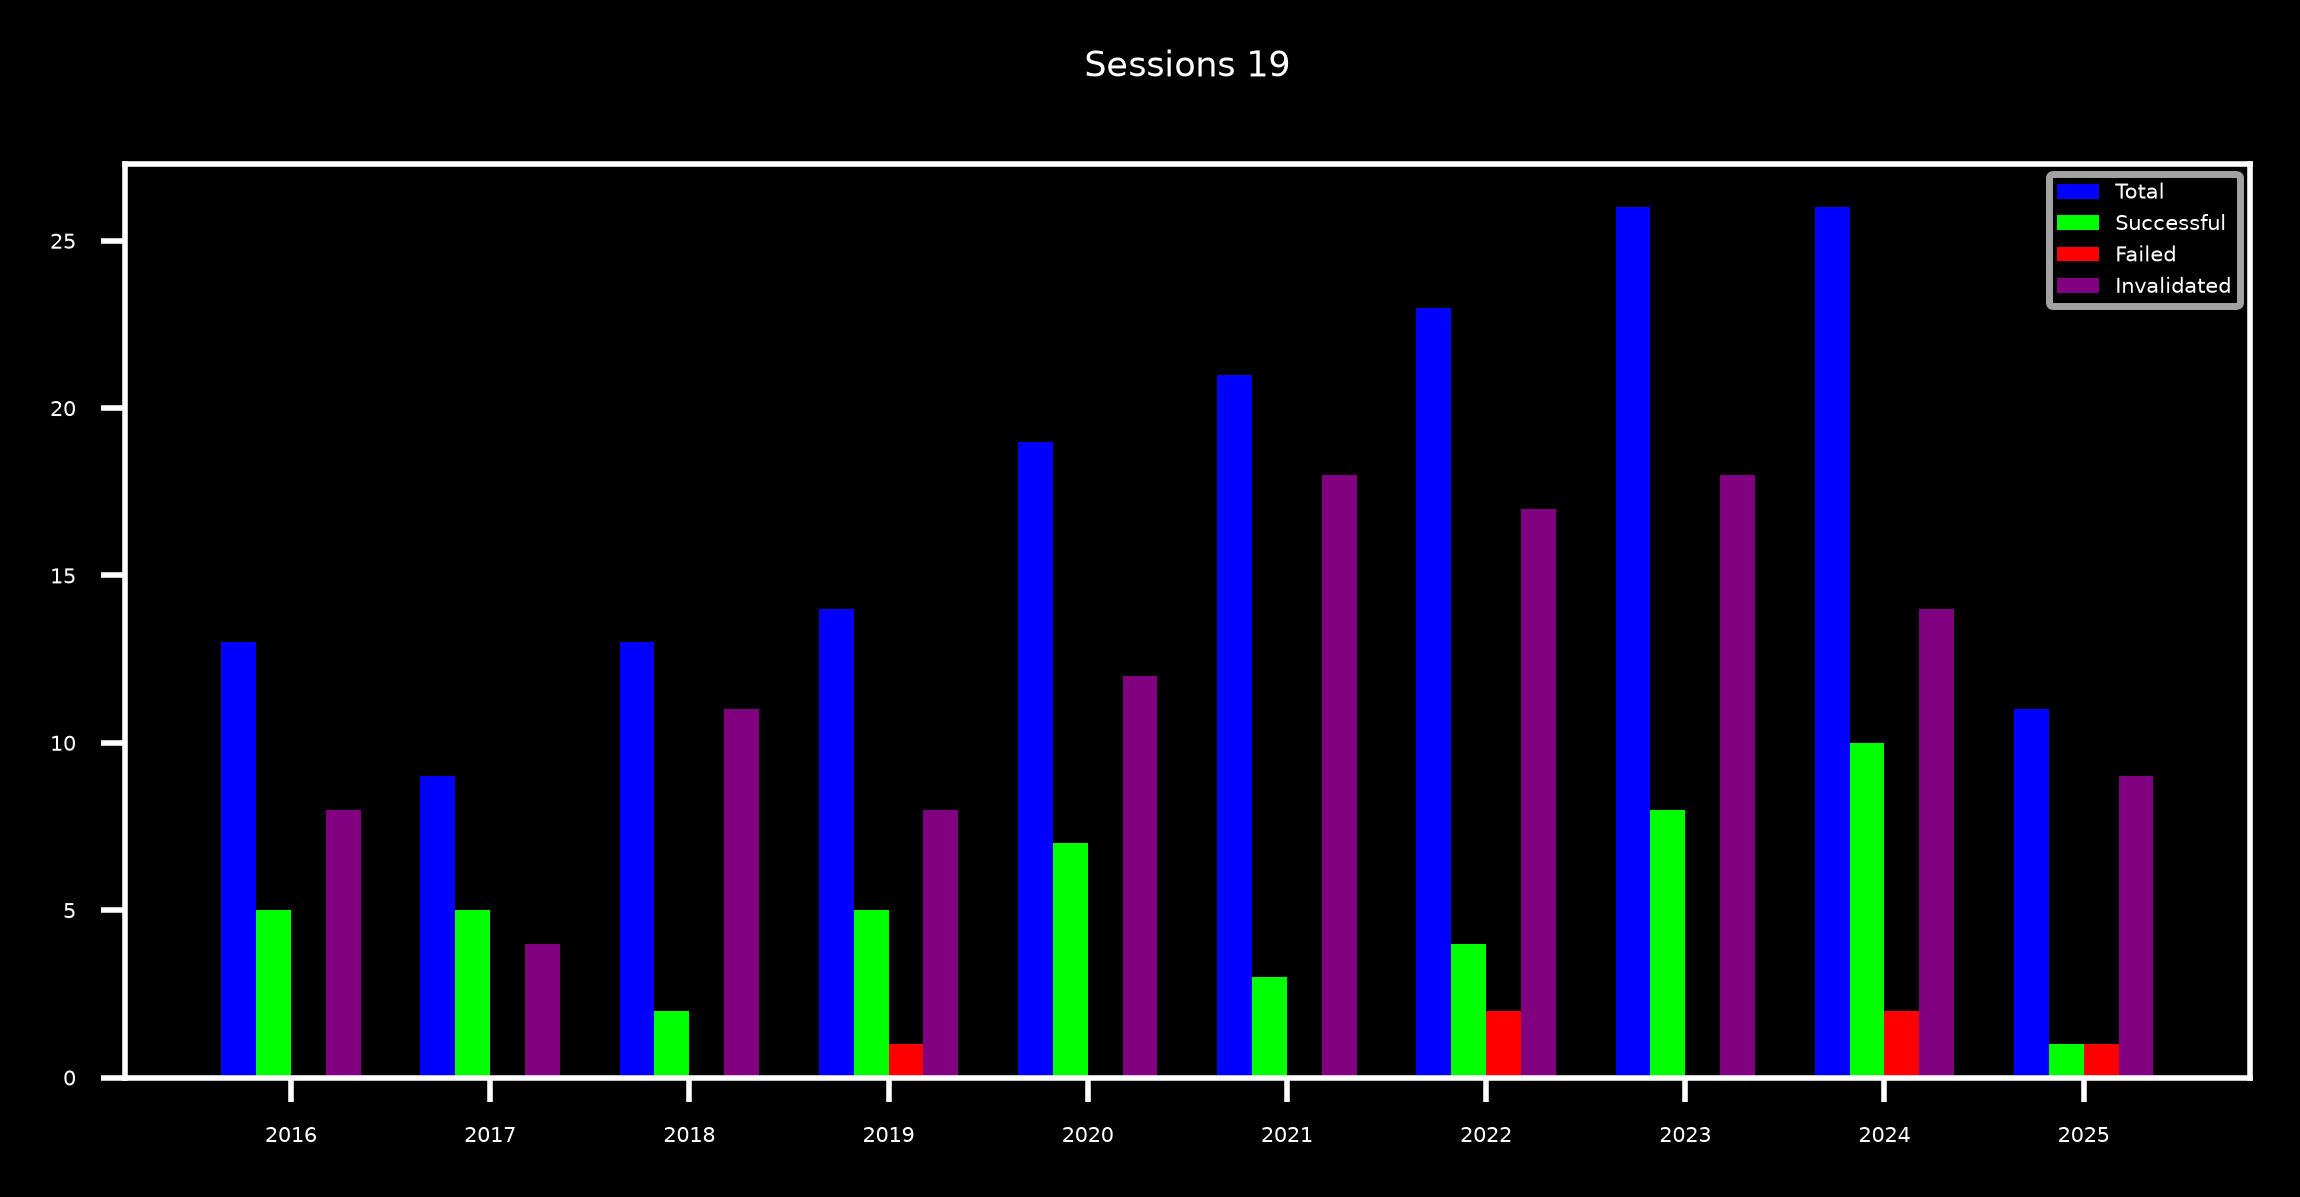

Sessions 20
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  5   │  0   │  8  │  38  │  0   │  61  │ 6.82 │ 9.29 │ -7.… │ 5.0… │ -2.… │ 4.47 │ 4.59 │ -13.… │ 0.3… │
│ 2017 │  9   │  5   │  0   │  4  │  55  │  0   │  44  │ 40.… │ 36.3 │ -19… │ 4.8… │ -3.… │ 22.… │ 49.… │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 18.… │ 7.24 │ -20… │ 1.1… │ -3.… │ -8.… │ -7.… │ -63.… │ 0.0… │
│ 2019 │  14  │  5   │  1   │  8  │  35  │  7   │  57  │ 11.… │ 17.… │ -8.… │ 3.2… │ -1.… │ 9.48 │ 10.… │ -12.… │ 0.0… │
│ 2020 │  19  │  7   │  0   │ 12  │  36  │  0   │  63  │ 16.… │ 14.… │ -9.… │ 3.1… │ -2.… │ 5.65 │ 6.0  │ -34.… │ 0.1… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 24.… │ 14.… │ -16… │ 2.1… │ -2.… │ 1.67 │ 2.09 │ -59.… │ 0.6… │
│ 2022 │  23  │  4   │  1   │ 18  │  17  │  4   │  78  │ 7.65 │ 8.47 │ -11… │ 1.7… │ -2.… │ -6.… │ -5.… │ -65.… │ 0.0… │
│ 2023 │  26  │  8   │  0   │ 18  │  30  │  0   │  69  │ 16.… │ 12.… │ -5.… │ 4.4… │ -1.… │ 8.58 │ 17.… │ -19.… │ 0.0… │
│ 2024 │  26  │  10  │  2   │ 14  │  38  │  7   │  53  │ 15.… │ 11.6 │ -8.… │ 3.3… │ -2.… │ 5.45 │ 9.83 │ -35.… │ 0.0… │
│ 2025 │  11  │  1   │  1   │  9  │  9   │  9   │  81  │ 10.… │ 6.27 │ -7.… │ 2.4… │ -2.… │ -4.… │ -4.… │ -21.… │ 0.4… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

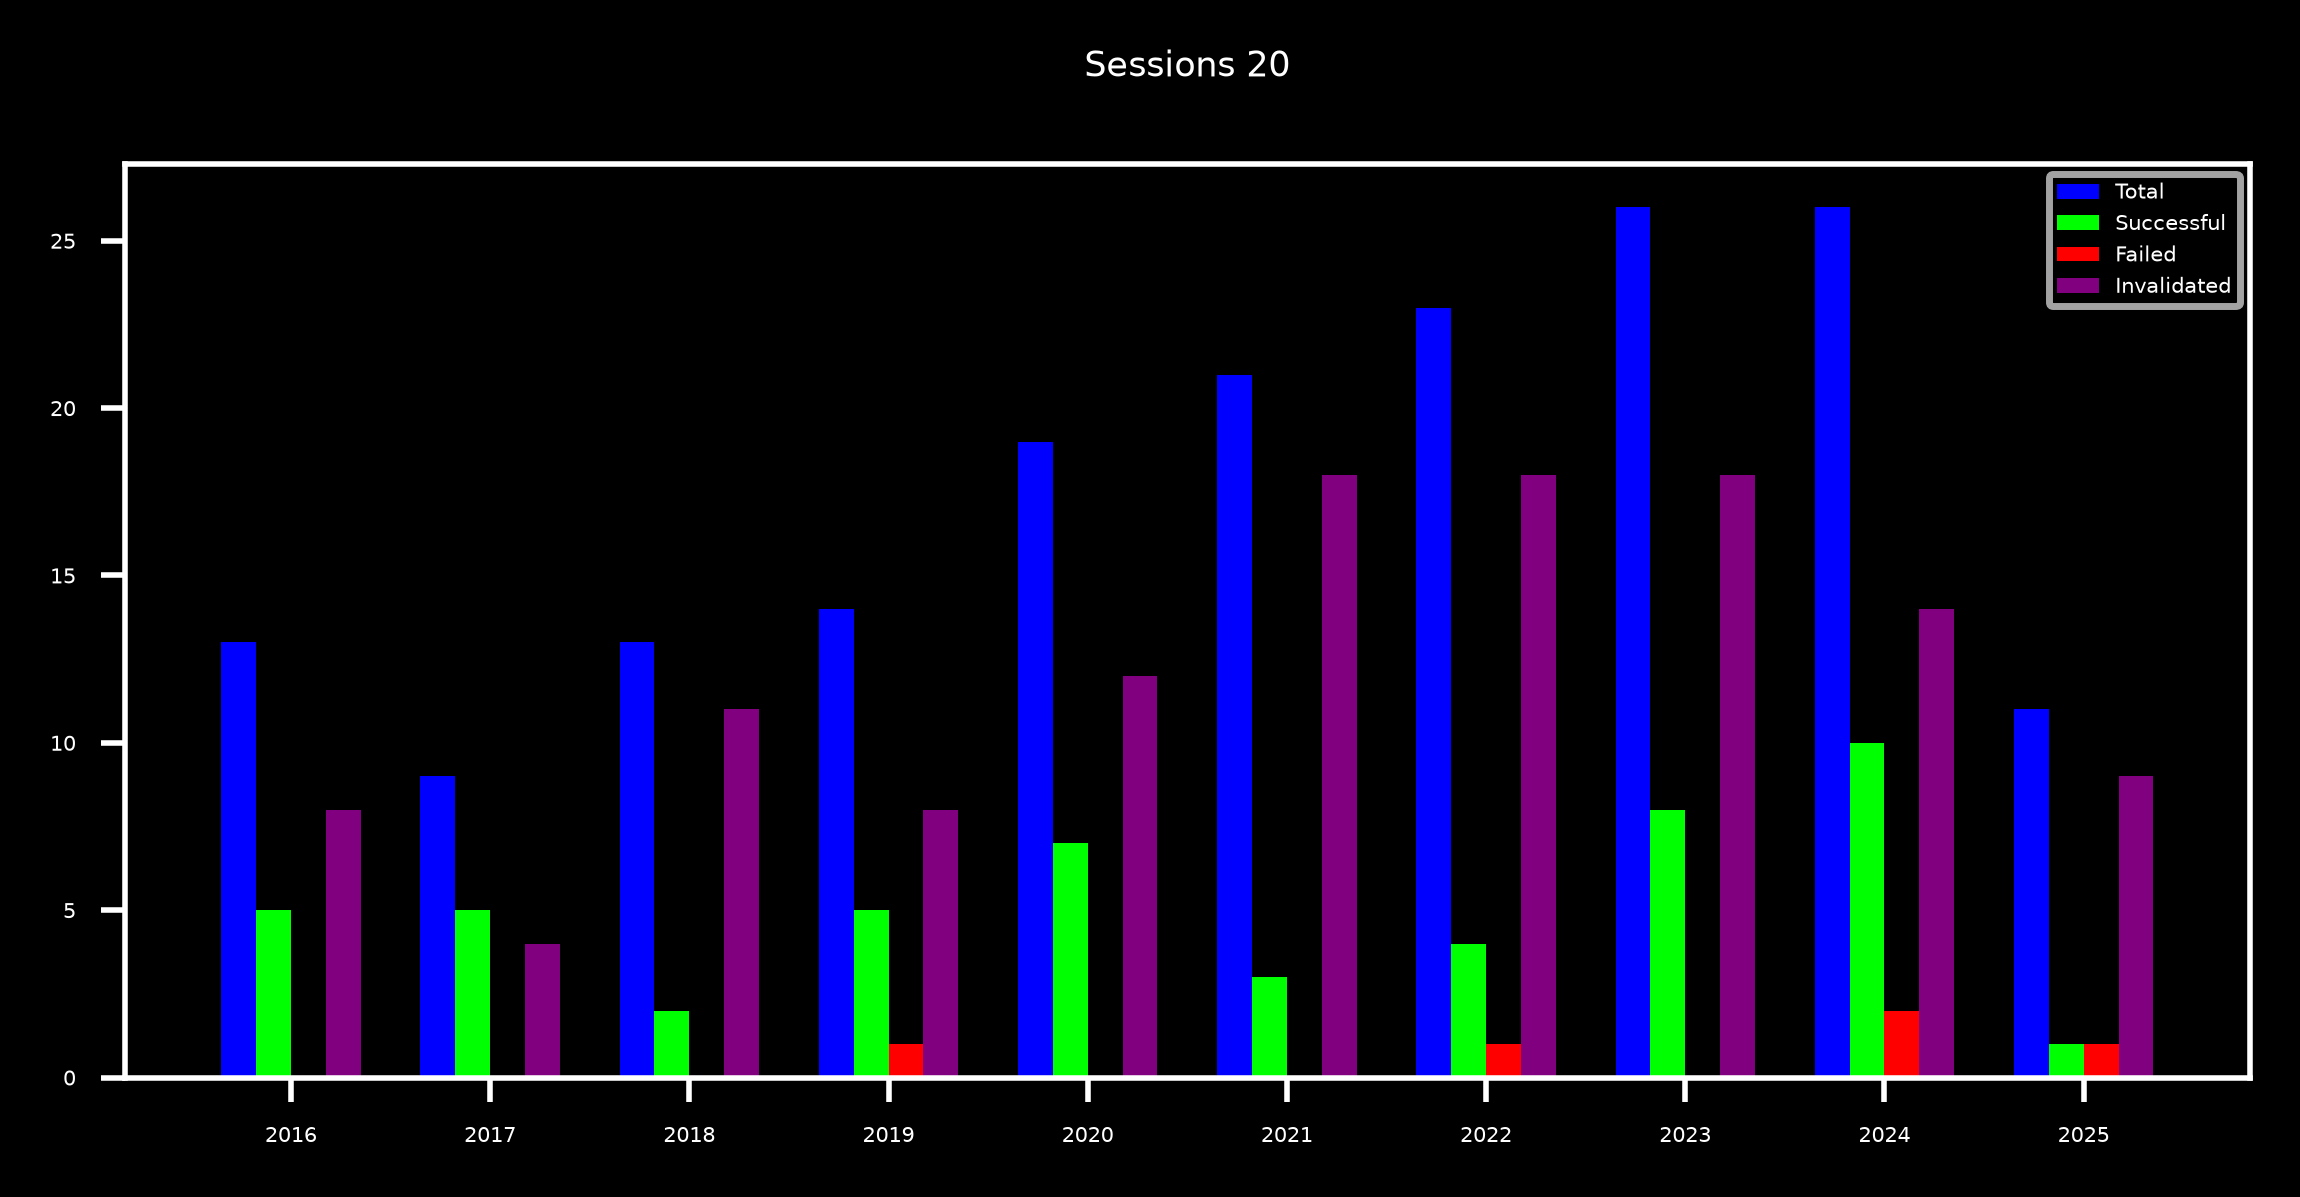

Sessions 21
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  5   │  0   │  8  │  38  │  0   │  61  │ 6.92 │ 9.55 │ -7.… │ 5.3… │ -2.… │ 2.91 │ 2.36 │ -13.… │ 0.5… │
│ 2017 │  9   │  5   │  0   │  4  │  55  │  0   │  44  │ 41.… │ 37.… │ -19… │ 4.9… │ -3.… │ 19.… │ 27.… │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 12.… │ 7.36 │ -21… │ 1.2x │ -3.… │ -10… │ -8.… │ -69.… │ 0.0… │
│ 2019 │  14  │  5   │  1   │  8  │  35  │  7   │  57  │ 14.… │ 17.4 │ -8.… │ 3.2… │ -1.… │ 7.01 │ 9.88 │ -15.… │ 0.1… │
│ 2020 │  19  │  7   │  0   │ 12  │  36  │  0   │  63  │ 20.… │ 15.… │ -9.… │ 3.6… │ -2.… │ 7.19 │ 8.48 │ -27.… │ 0.0… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 20.… │ 14.… │ -17… │ 2.1… │ -2.… │ 1.17 │ 1.4  │ -59.… │ 0.7… │
│ 2022 │  23  │  4   │  1   │ 18  │  17  │  4   │  78  │ 7.09 │ 8.53 │ -12… │ 1.7… │ -2.… │ -7.… │ -6.… │ -73.… │ 0.0… │
│ 2023 │  26  │  7   │  1   │ 18  │  26  │  3   │  69  │ 18.… │ 13.… │ -5.… │ 4.6… │ -1.… │ 8.43 │ 22.… │ -19.… │ 0.0… │
│ 2024 │  26  │  10  │  2   │ 14  │  38  │  7   │  53  │ 14.… │ 11.… │ -8.… │ 3.3… │ -2.… │ 5.6  │ 9.93 │ -33.… │ 0.0… │
│ 2025 │  11  │  1   │  1   │  9  │  9   │  9   │  81  │ 9.11 │ 6.37 │ -7.… │ 2.4… │ -2.… │ -2.… │ -2.… │ -16.… │ 0.6… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

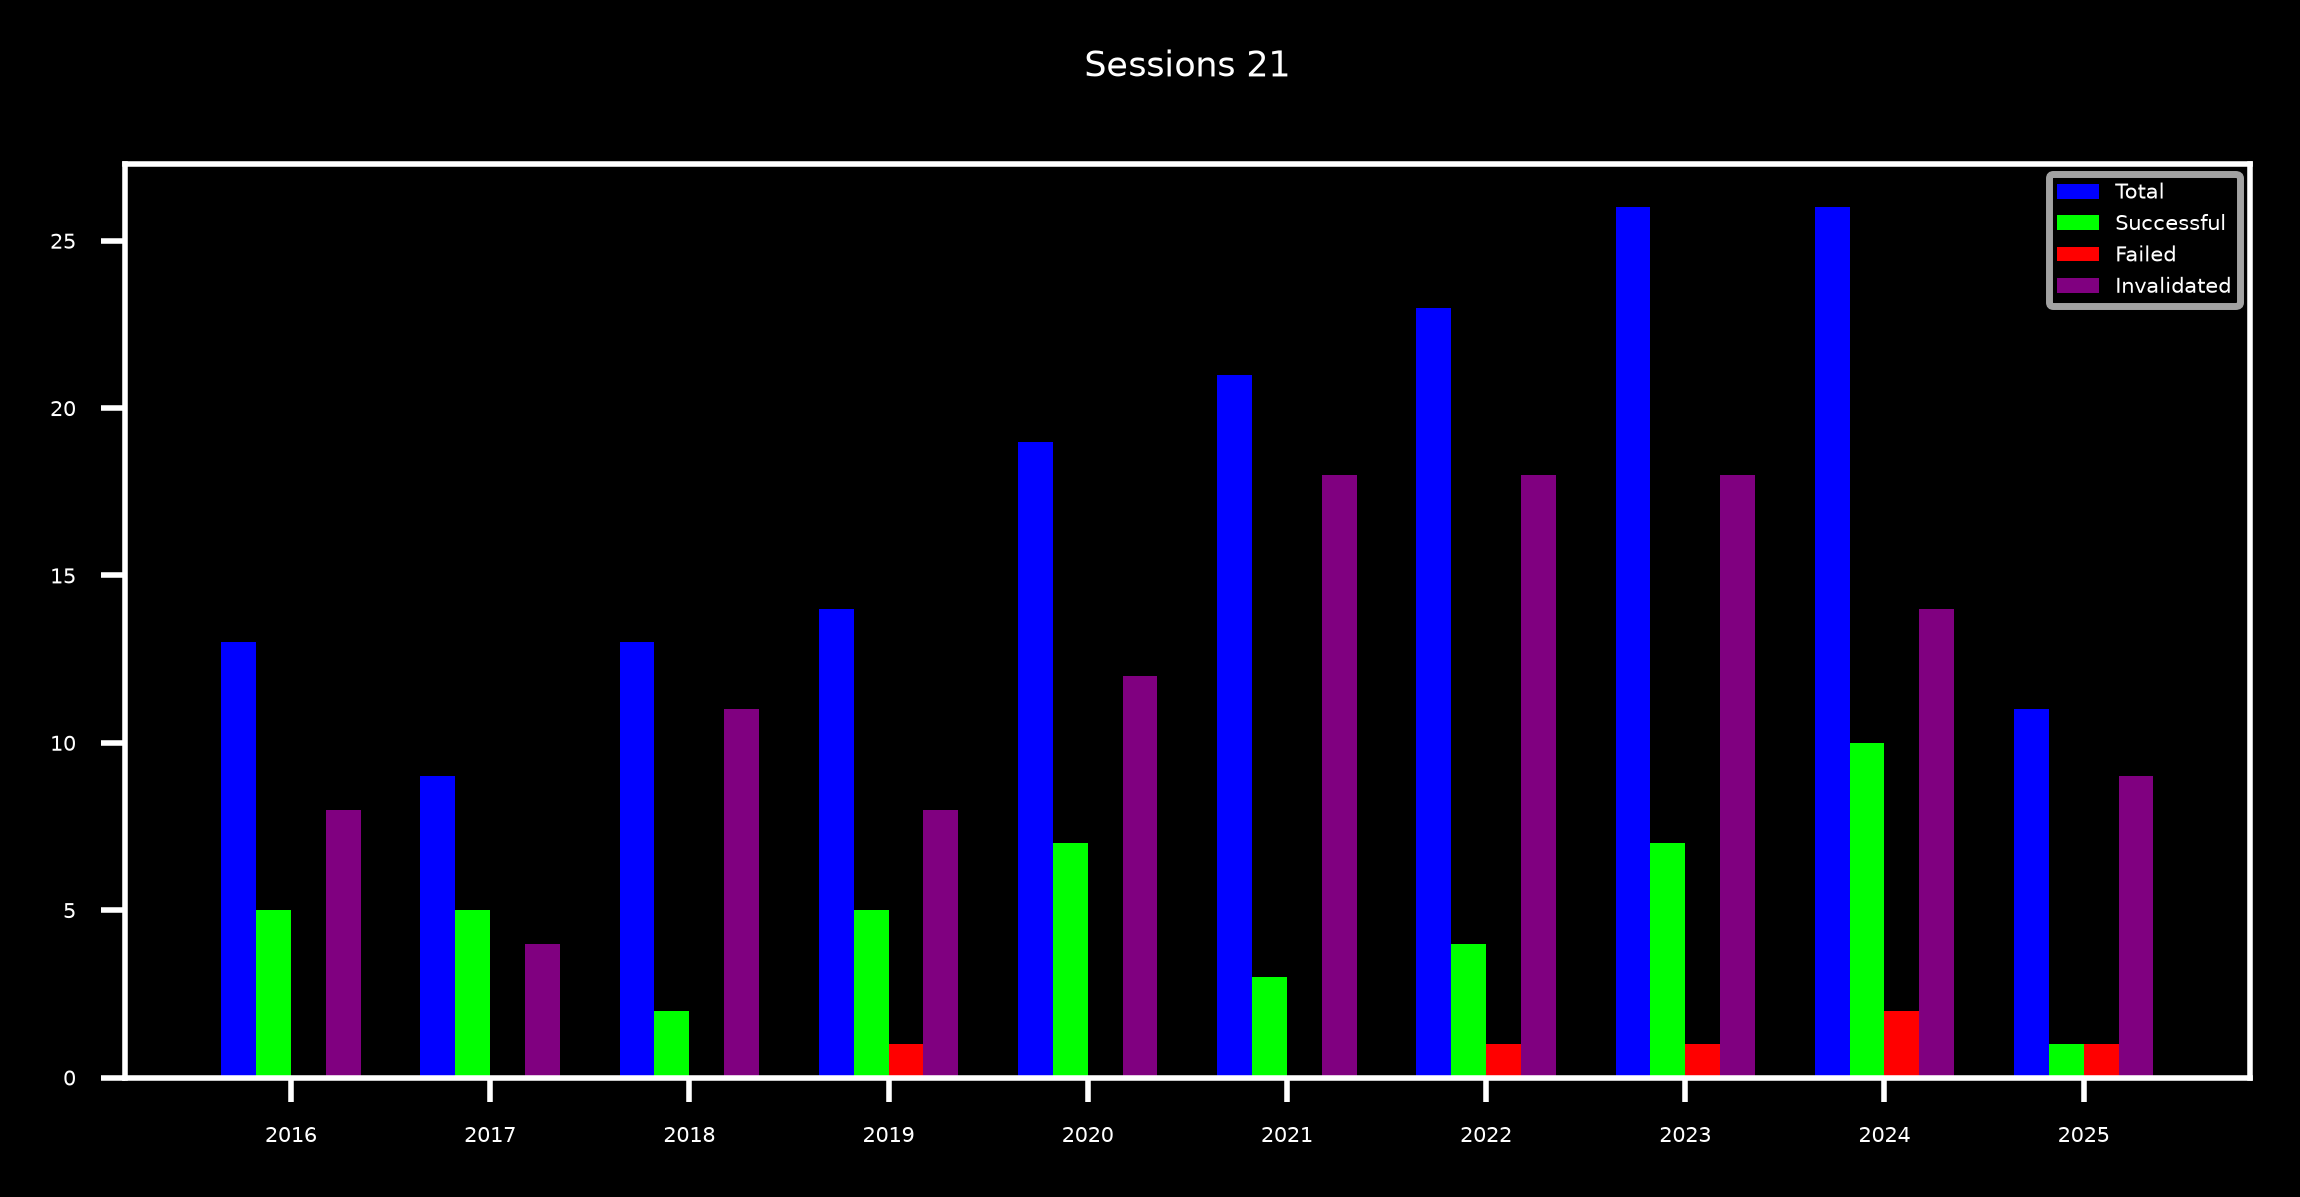

Sessions 22
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  5   │  0   │  8  │  38  │  0   │  61  │ 8.44 │ 10.… │ -7.… │ 5.9… │ -2.… │ 3.81 │ 3.47 │ -15.… │ 0.4… │
│ 2017 │  9   │  5   │  0   │  4  │  55  │  0   │  44  │ 37.… │ 37.… │ -19… │ 5.0… │ -3.… │ 19.4 │ 24.6 │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 11.… │ 7.36 │ -21… │ 1.2x │ -3.… │ -13… │ -10… │ -77.… │ 0.0… │
│ 2019 │  14  │  5   │  1   │  8  │  35  │  7   │  57  │ 12.… │ 17.… │ -8.… │ 3.2… │ -1.… │ 7.77 │ 12.… │ -15.… │ 0.0… │
│ 2020 │  19  │  7   │  0   │ 12  │  36  │  0   │  63  │ 18.7 │ 16.… │ -9.… │ 3.9… │ -2.… │ 7.53 │ 7.68 │ -24.… │ 0.0… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 18.… │ 15.… │ -17… │ 2.2… │ -2.… │ 1.23 │ 1.76 │ -58.… │ 0.7… │
│ 2022 │  23  │  3   │  2   │ 18  │  13  │  8   │  78  │ 8.28 │ 8.53 │ -12… │ 1.7… │ -2.… │ -6.… │ -6.0 │ -70.… │ 0.0… │
│ 2023 │  26  │  7   │  1   │ 18  │  26  │  3   │  69  │ 19.… │ 13.… │ -6.… │ 4.7… │ -1.… │ 9.4  │ 27.3 │ -16.… │ 0.0… │
│ 2024 │  26  │  10  │  2   │ 14  │  38  │  7   │  53  │ 15.… │ 11.… │ -8.… │ 3.4x │ -2.… │ 5.84 │ 11.… │ -33.… │ 0.0… │
│ 2025 │  11  │  1   │  1   │  9  │  9   │  9   │  81  │ 8.73 │ 6.58 │ -7.… │ 2.5… │ -2.… │ -1.… │ -1.… │ -15.… │ 0.81 │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

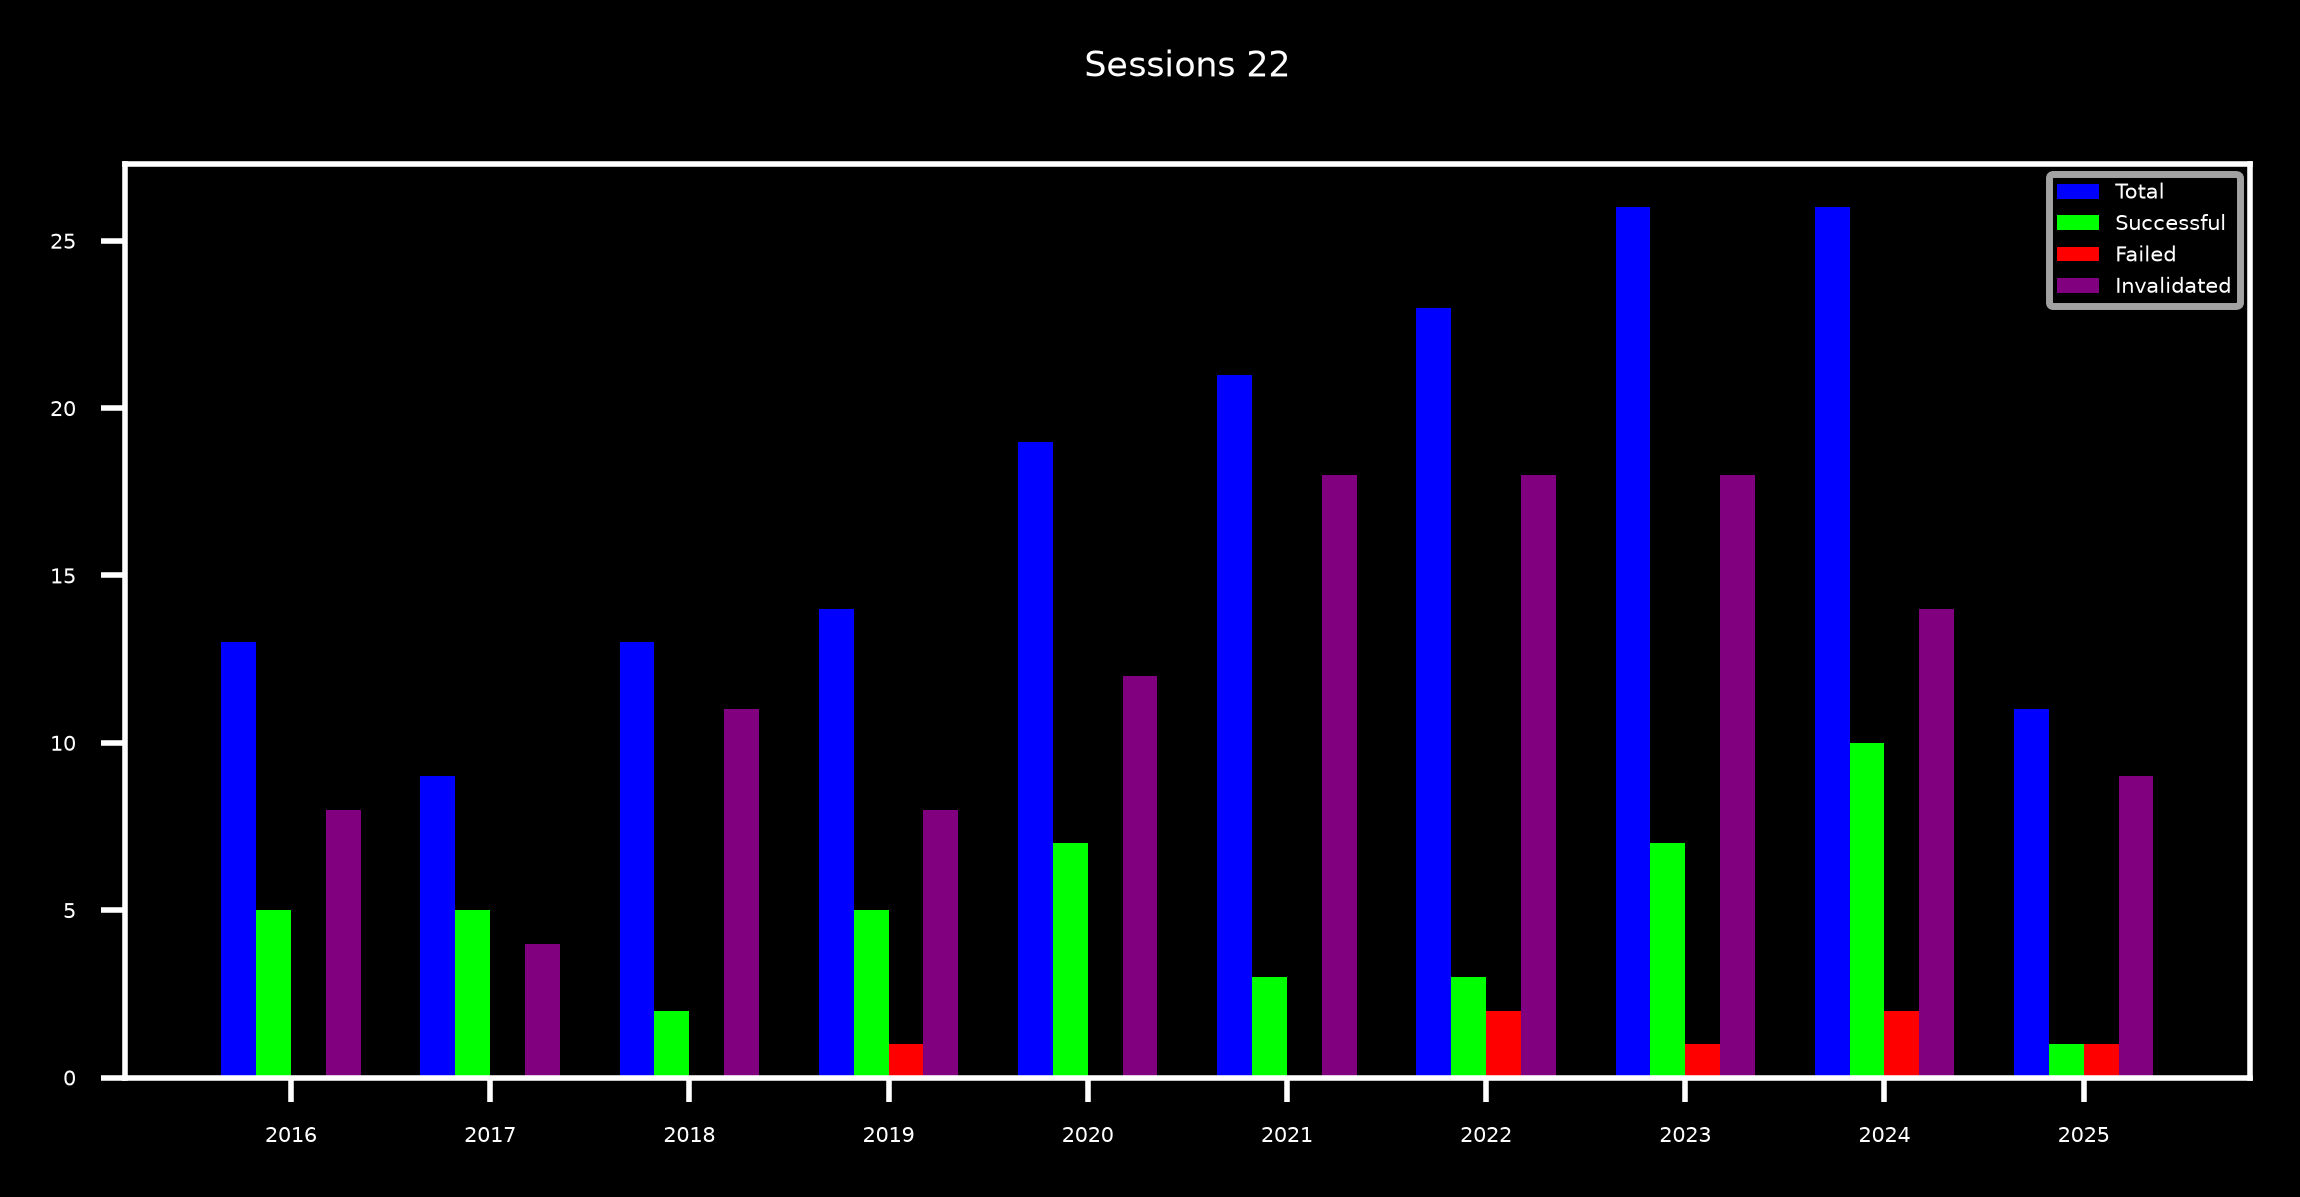

Sessions 23
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  5   │  0   │  8  │  38  │  0   │  61  │ 8.8  │ 10.… │ -7.… │ 6.1… │ -2.… │ 4.53 │ 4.45 │ -15.… │ 0.3… │
│ 2017 │  9   │  5   │  0   │  4  │  55  │  0   │  44  │ 41.… │ 38.… │ -19… │ 5.1x │ -3.… │ 16.… │ 16.… │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 10.… │ 7.36 │ -22… │ 1.2x │ -4.… │ -12… │ -9.8 │ -78.… │ 0.0… │
│ 2019 │  14  │  5   │  1   │  8  │  35  │  7   │  57  │ 12.… │ 17.… │ -8.… │ 3.3… │ -1.… │ 7.59 │ 11.… │ -15.… │ 0.0… │
│ 2020 │  19  │  7   │  0   │ 12  │  36  │  0   │  63  │ 19.… │ 17.… │ -9.… │ 4.2… │ -2.… │ 7.49 │ 8.66 │ -24.… │ 0.0… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 18.… │ 15.… │ -17… │ 2.2… │ -2.… │ 1.3  │ 1.76 │ -66.… │ 0.7… │
│ 2022 │  23  │  2   │  3   │ 18  │  8   │  13  │  78  │ 9.9  │ 8.65 │ -12… │ 1.7… │ -2.… │ -7.… │ -6.… │ -79.… │ 0.0… │
│ 2023 │  26  │  7   │  0   │ 19  │  26  │  0   │  73  │ 19.… │ 13.… │ -6.… │ 4.7… │ -1.… │ 9.06 │ 19.… │ -19.… │ 0.0… │
│ 2024 │  26  │  9   │  3   │ 14  │  34  │  11  │  53  │ 16.… │ 12.… │ -8.… │ 3.5… │ -2.… │ 5.41 │ 10.… │ -42.… │ 0.0… │
│ 2025 │  11  │  1   │  0   │ 10  │  9   │  0   │  90  │ 8.03 │ 7.14 │ -8.… │ 2.7… │ -2.… │ -2.… │ -2.… │ -17.… │ 0.6… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

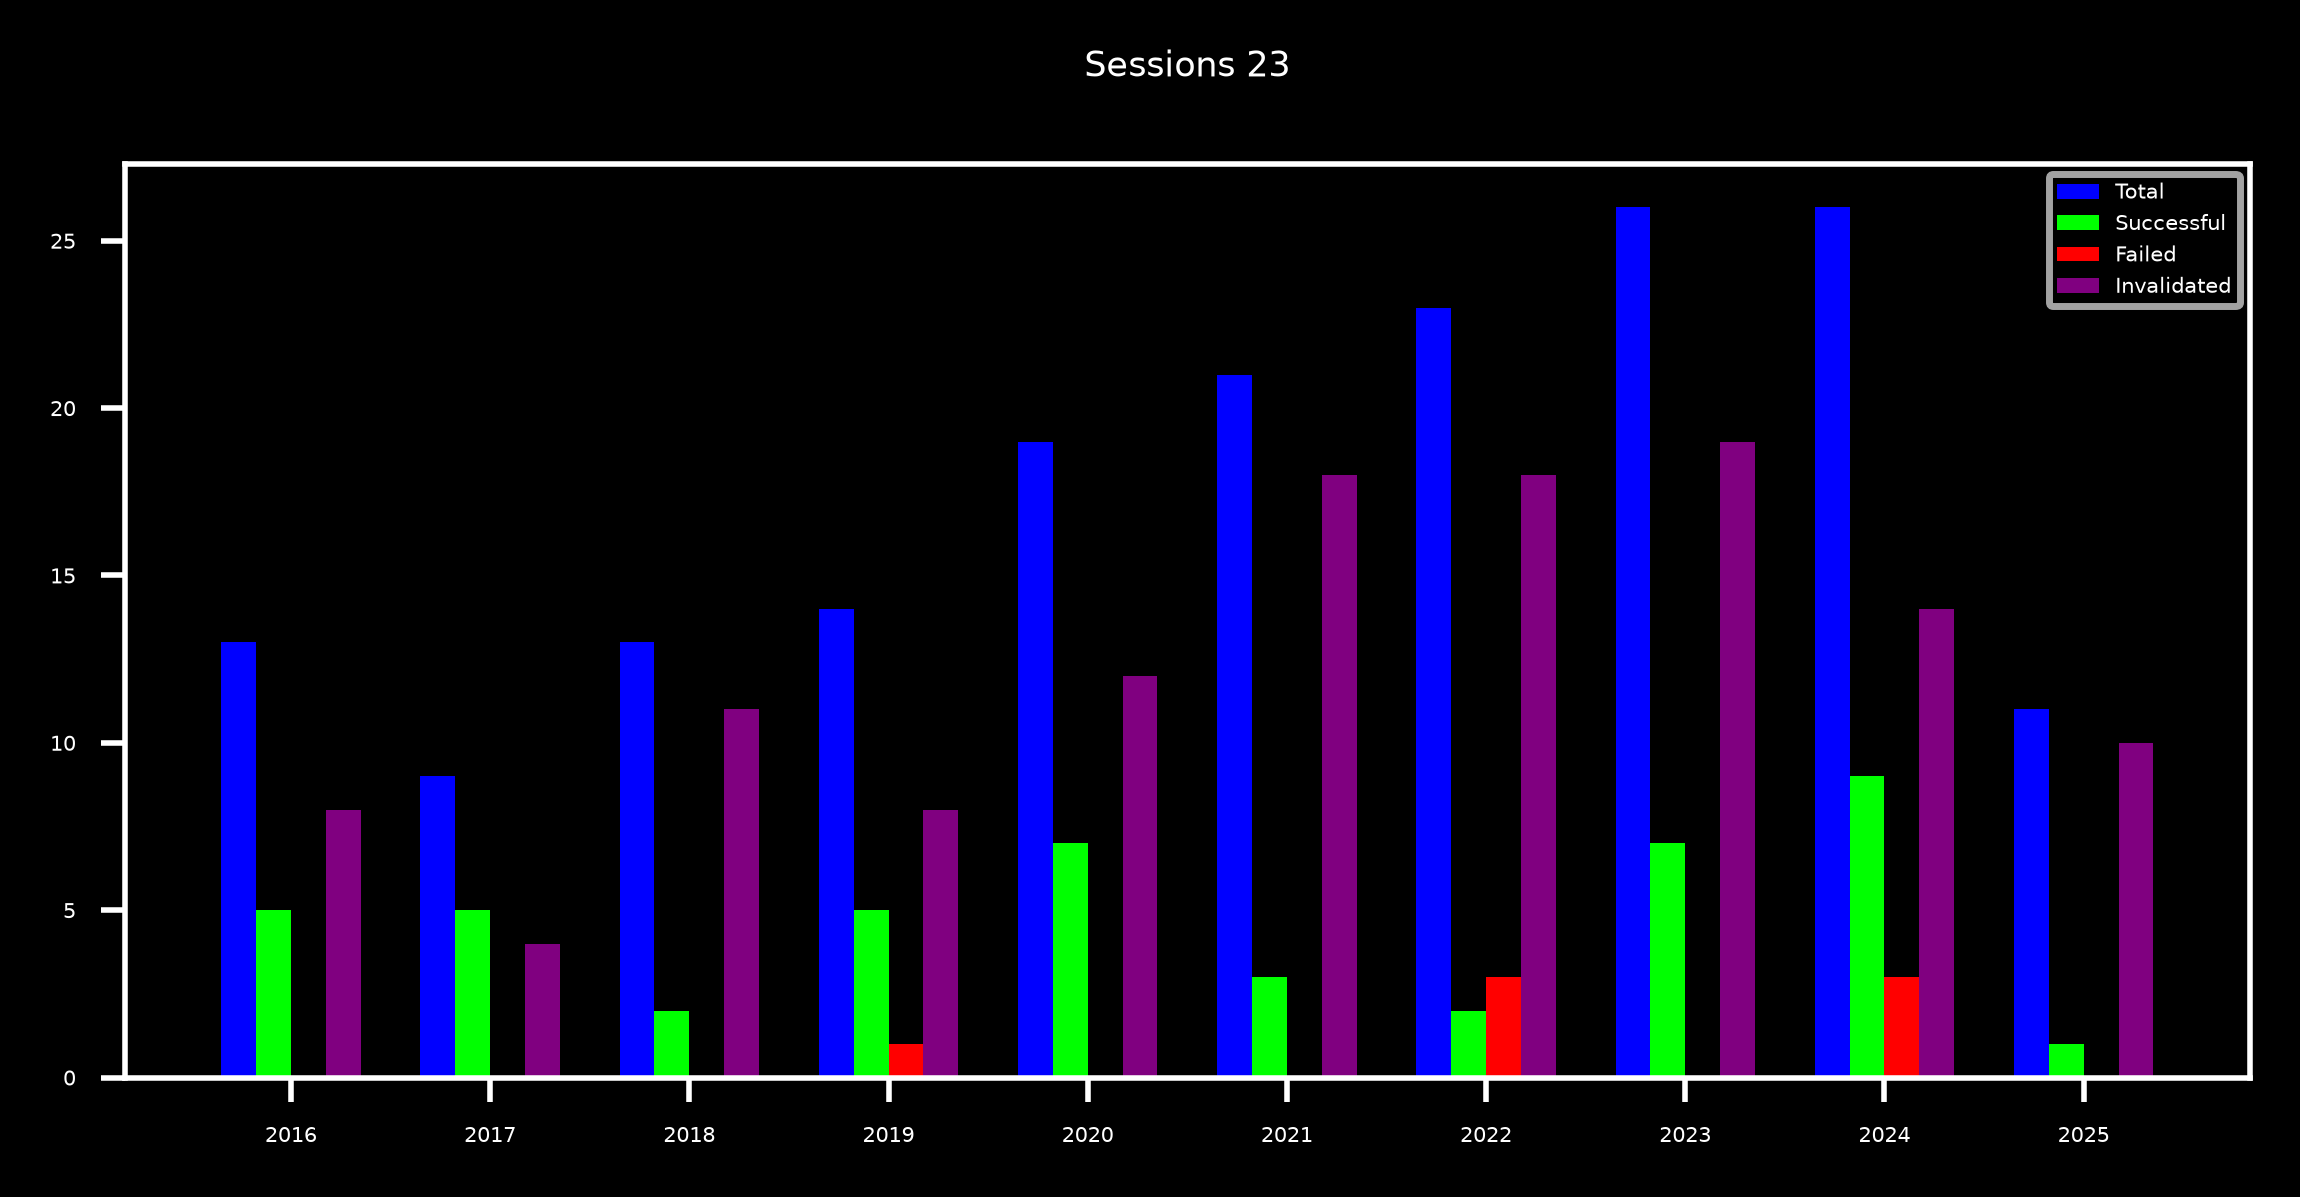

Sessions 24
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  5   │  0   │  8  │  38  │  0   │  61  │ 9.51 │ 10.… │ -7.… │ 6.5… │ -2.… │ 4.85 │ 4.79 │ -14.… │ 0.2… │
│ 2017 │  9   │  5   │  0   │  4  │  55  │  0   │  44  │ 40.… │ 41.… │ -19… │ 5.6… │ -3.… │ 16.… │ 19.… │ 0.0%  │ 0.0… │
│ 2018 │  13  │  1   │  1   │ 11  │  7   │  7   │  84  │ 24.… │ 7.57 │ -22… │ 1.2… │ -4.… │ -12… │ -10… │ -79.… │ 0.0… │
│ 2019 │  14  │  5   │  1   │  8  │  35  │  7   │  57  │ 18.… │ 19.… │ -8.… │ 3.9… │ -1.… │ 8.98 │ 17.… │ -14.… │ 0.0… │
│ 2020 │  19  │  7   │  0   │ 12  │  36  │  0   │  63  │ 14.… │ 17.… │ -9.… │ 4.3… │ -2.… │ 6.06 │ 5.6  │ -36.… │ 0.1… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 17.… │ 15.… │ -17… │ 2.3… │ -2.… │ 1.4  │ 2.03 │ -64.… │ 0.6… │
│ 2022 │  23  │  3   │  2   │ 18  │  13  │  8   │  78  │ 7.81 │ 8.65 │ -13… │ 1.7… │ -2.… │ -7.… │ -6.… │ -76.… │ 0.0… │
│ 2023 │  26  │  7   │  0   │ 19  │  26  │  0   │  73  │ 19.… │ 13.… │ -6.… │ 4.8… │ -1.… │ 8.52 │ 18.4 │ -21.… │ 0.0… │
│ 2024 │  26  │  9   │  2   │ 15  │  34  │  7   │  57  │ 14.… │ 12.… │ -8.… │ 3.7x │ -2.… │ 4.89 │ 8.47 │ -49.… │ 0.1… │
│ 2025 │  11  │  1   │  0   │ 10  │  9   │  0   │  90  │ 8.34 │ 7.26 │ -8.… │ 2.8… │ -2.… │ -1.… │ -2.… │ -16.… │ 0.7… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

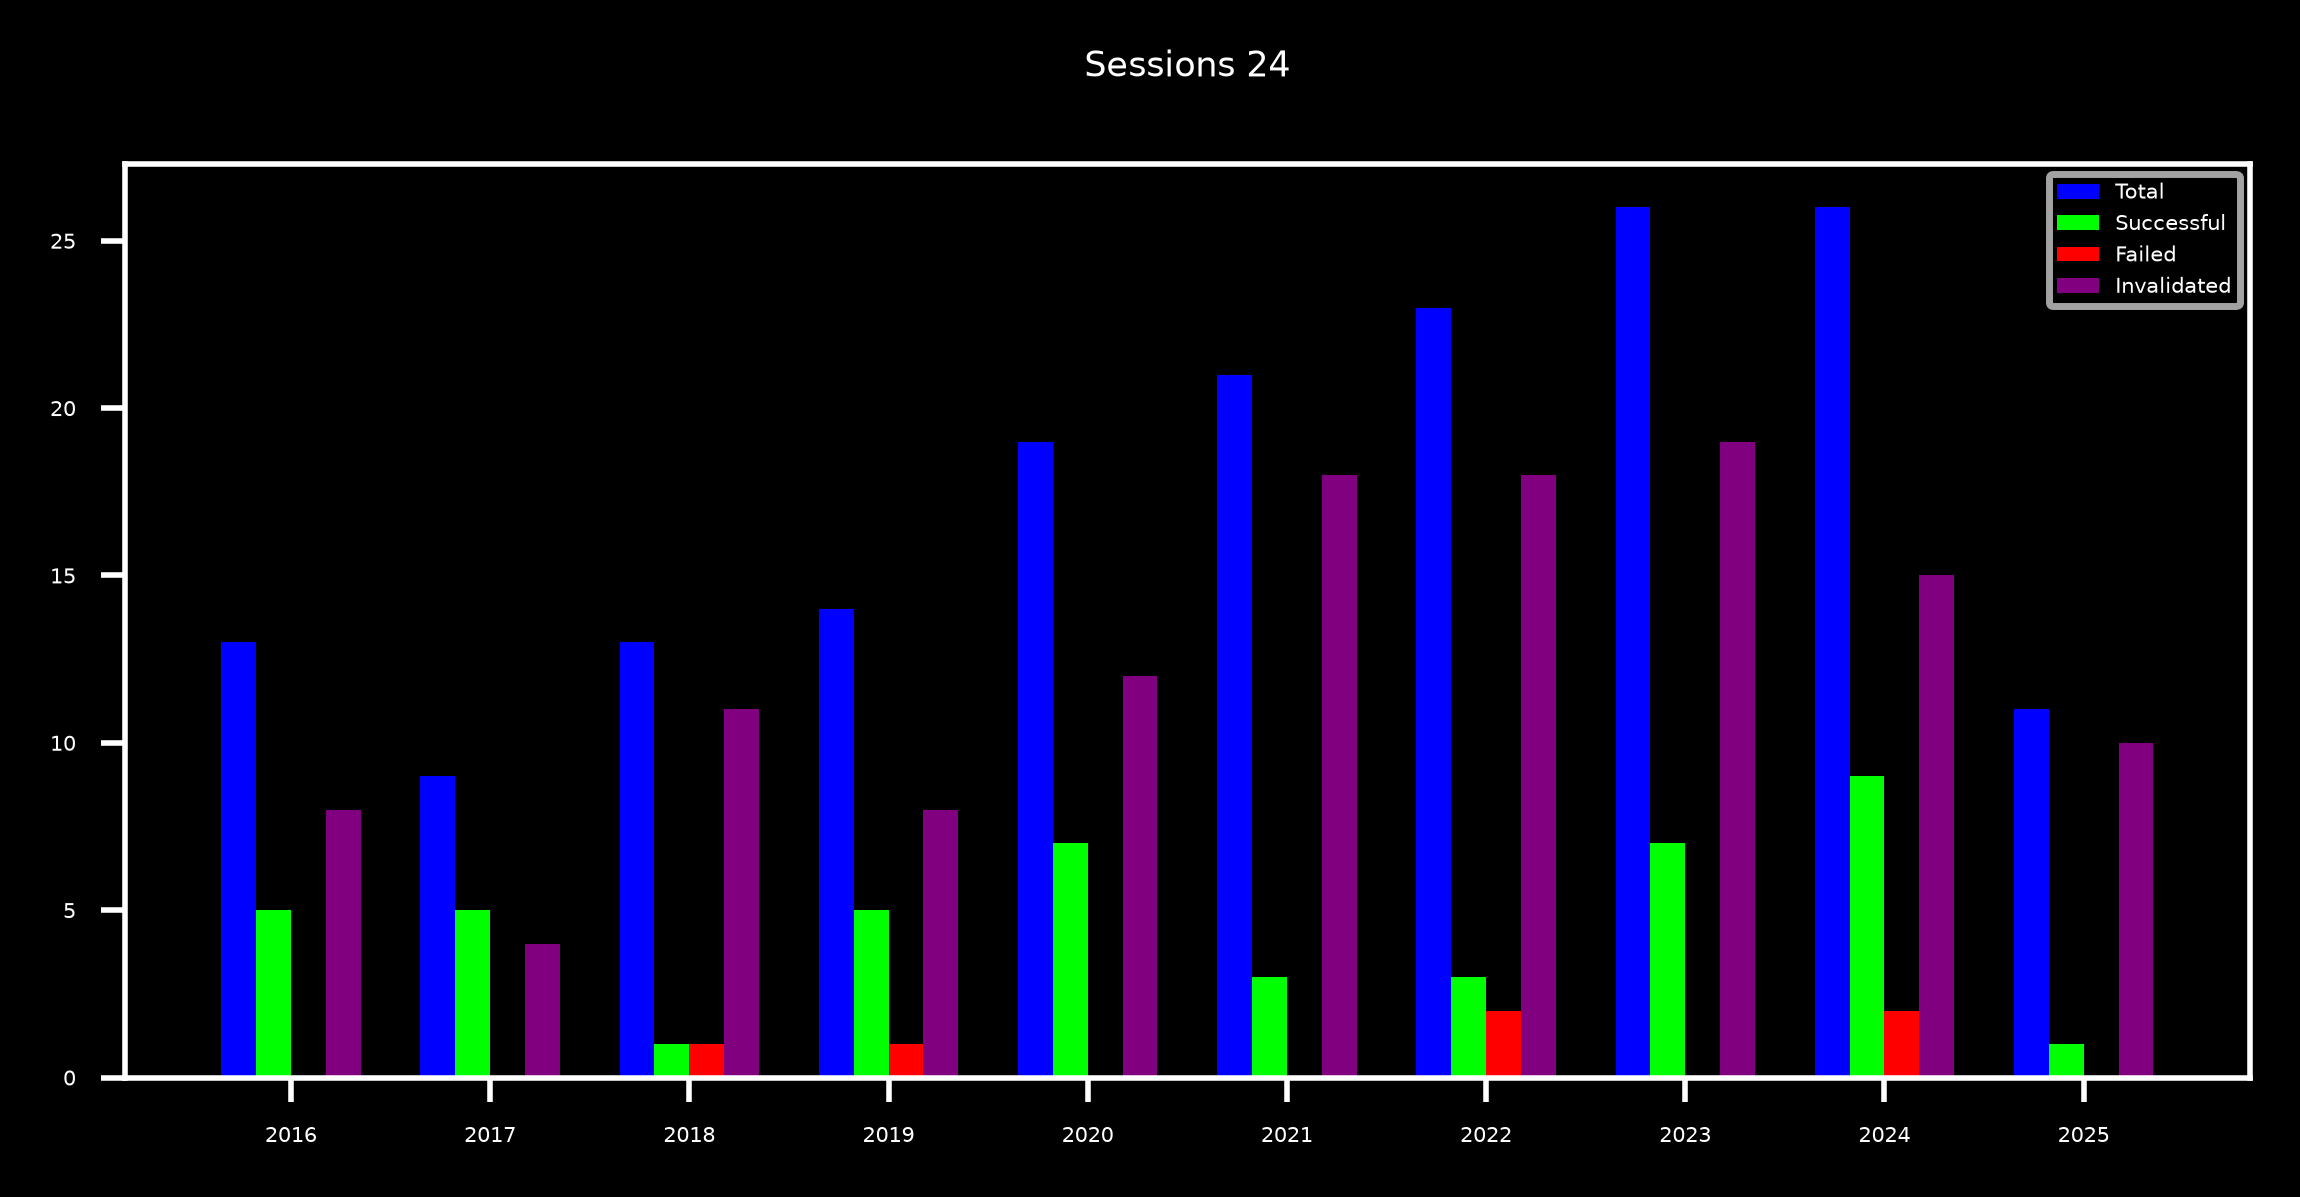

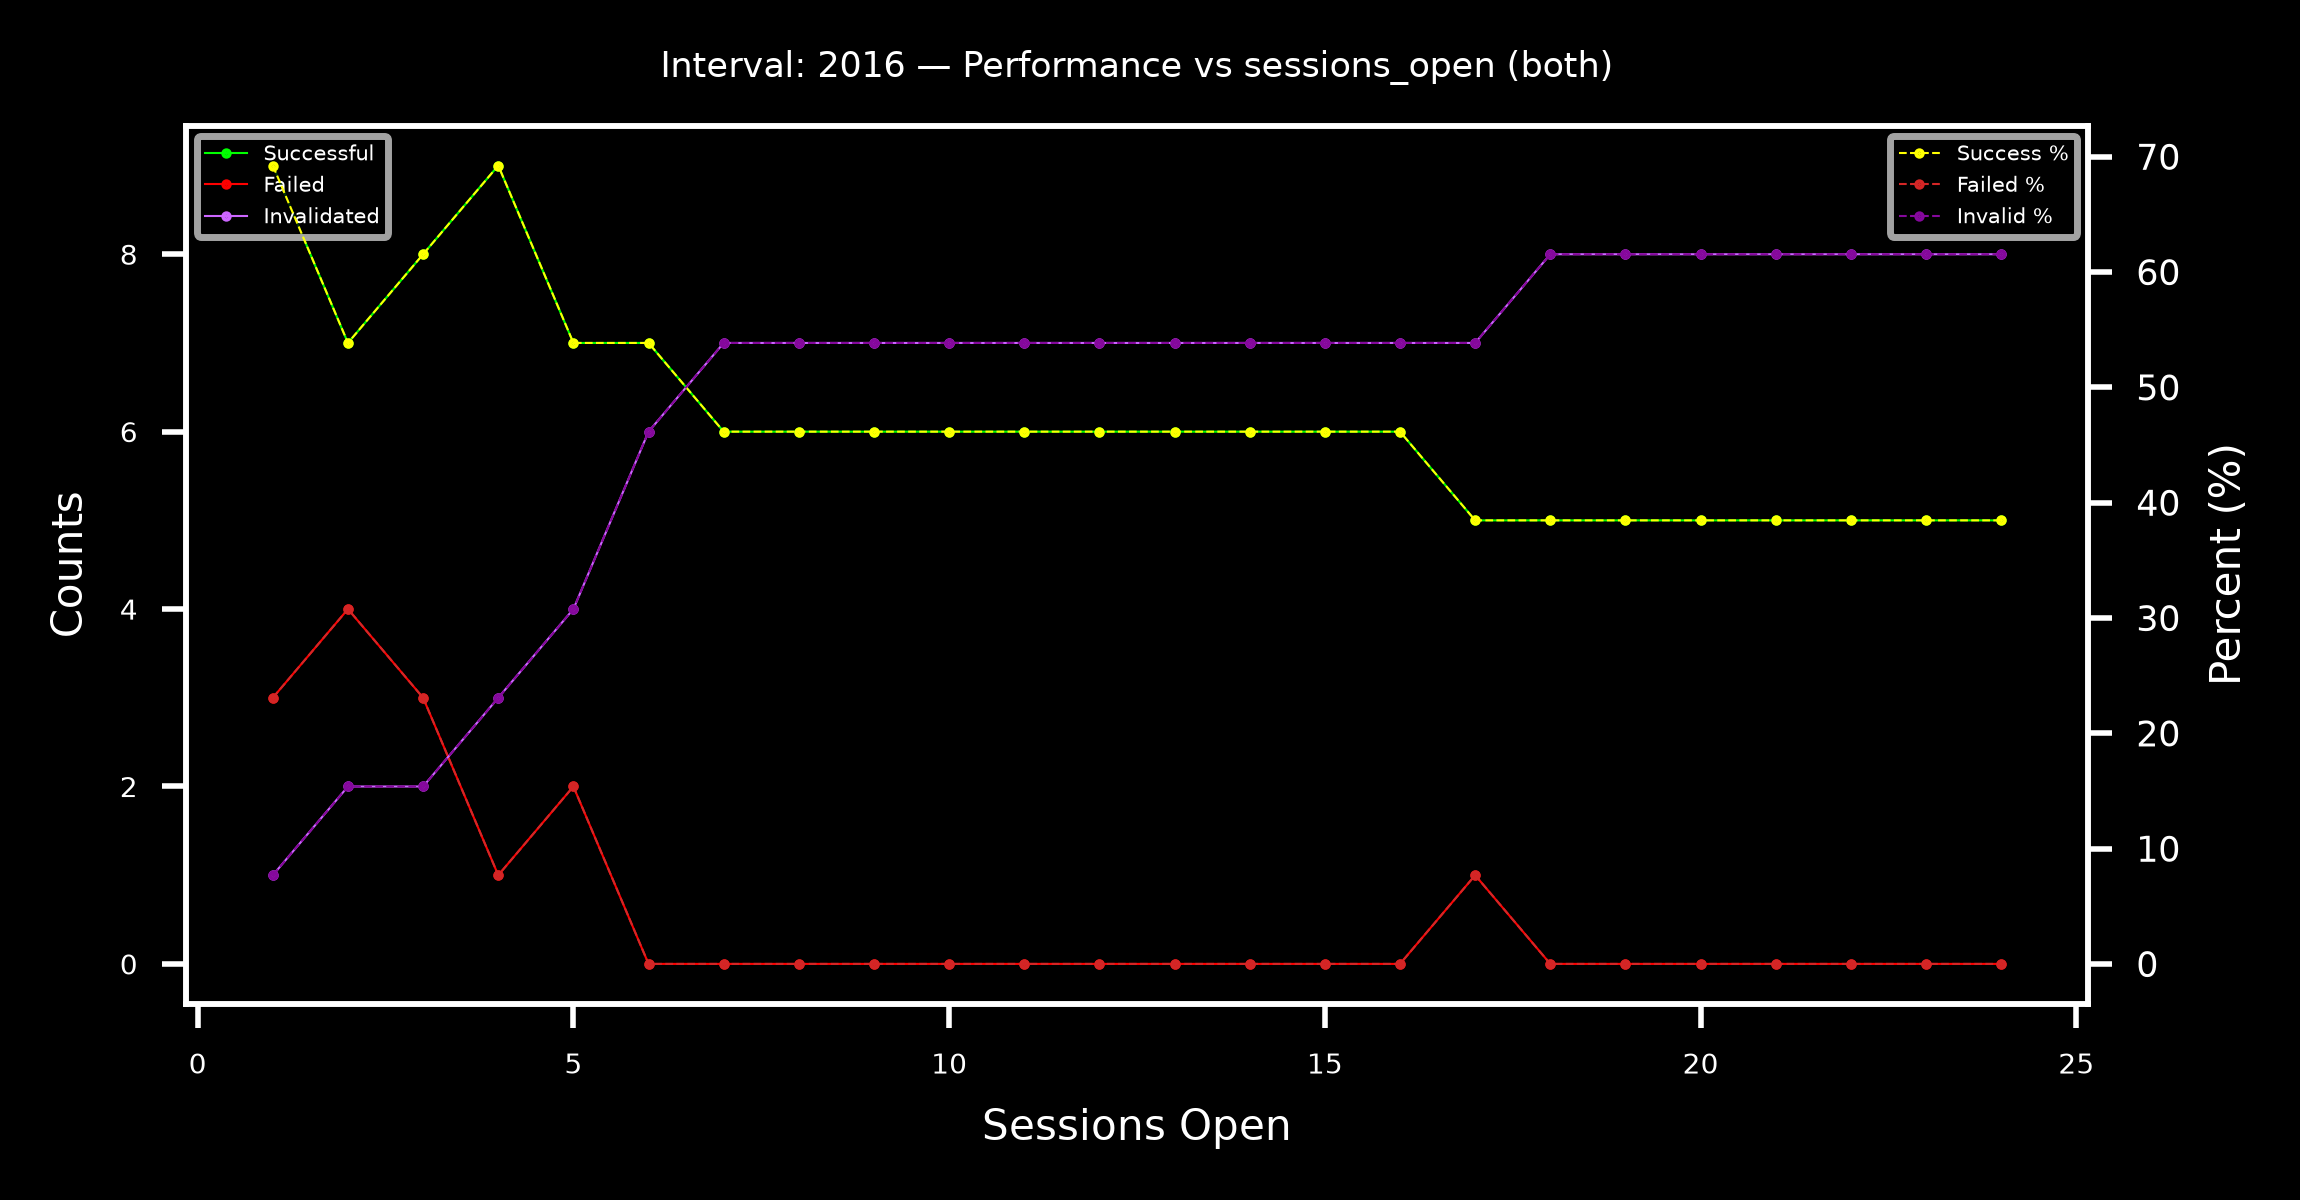

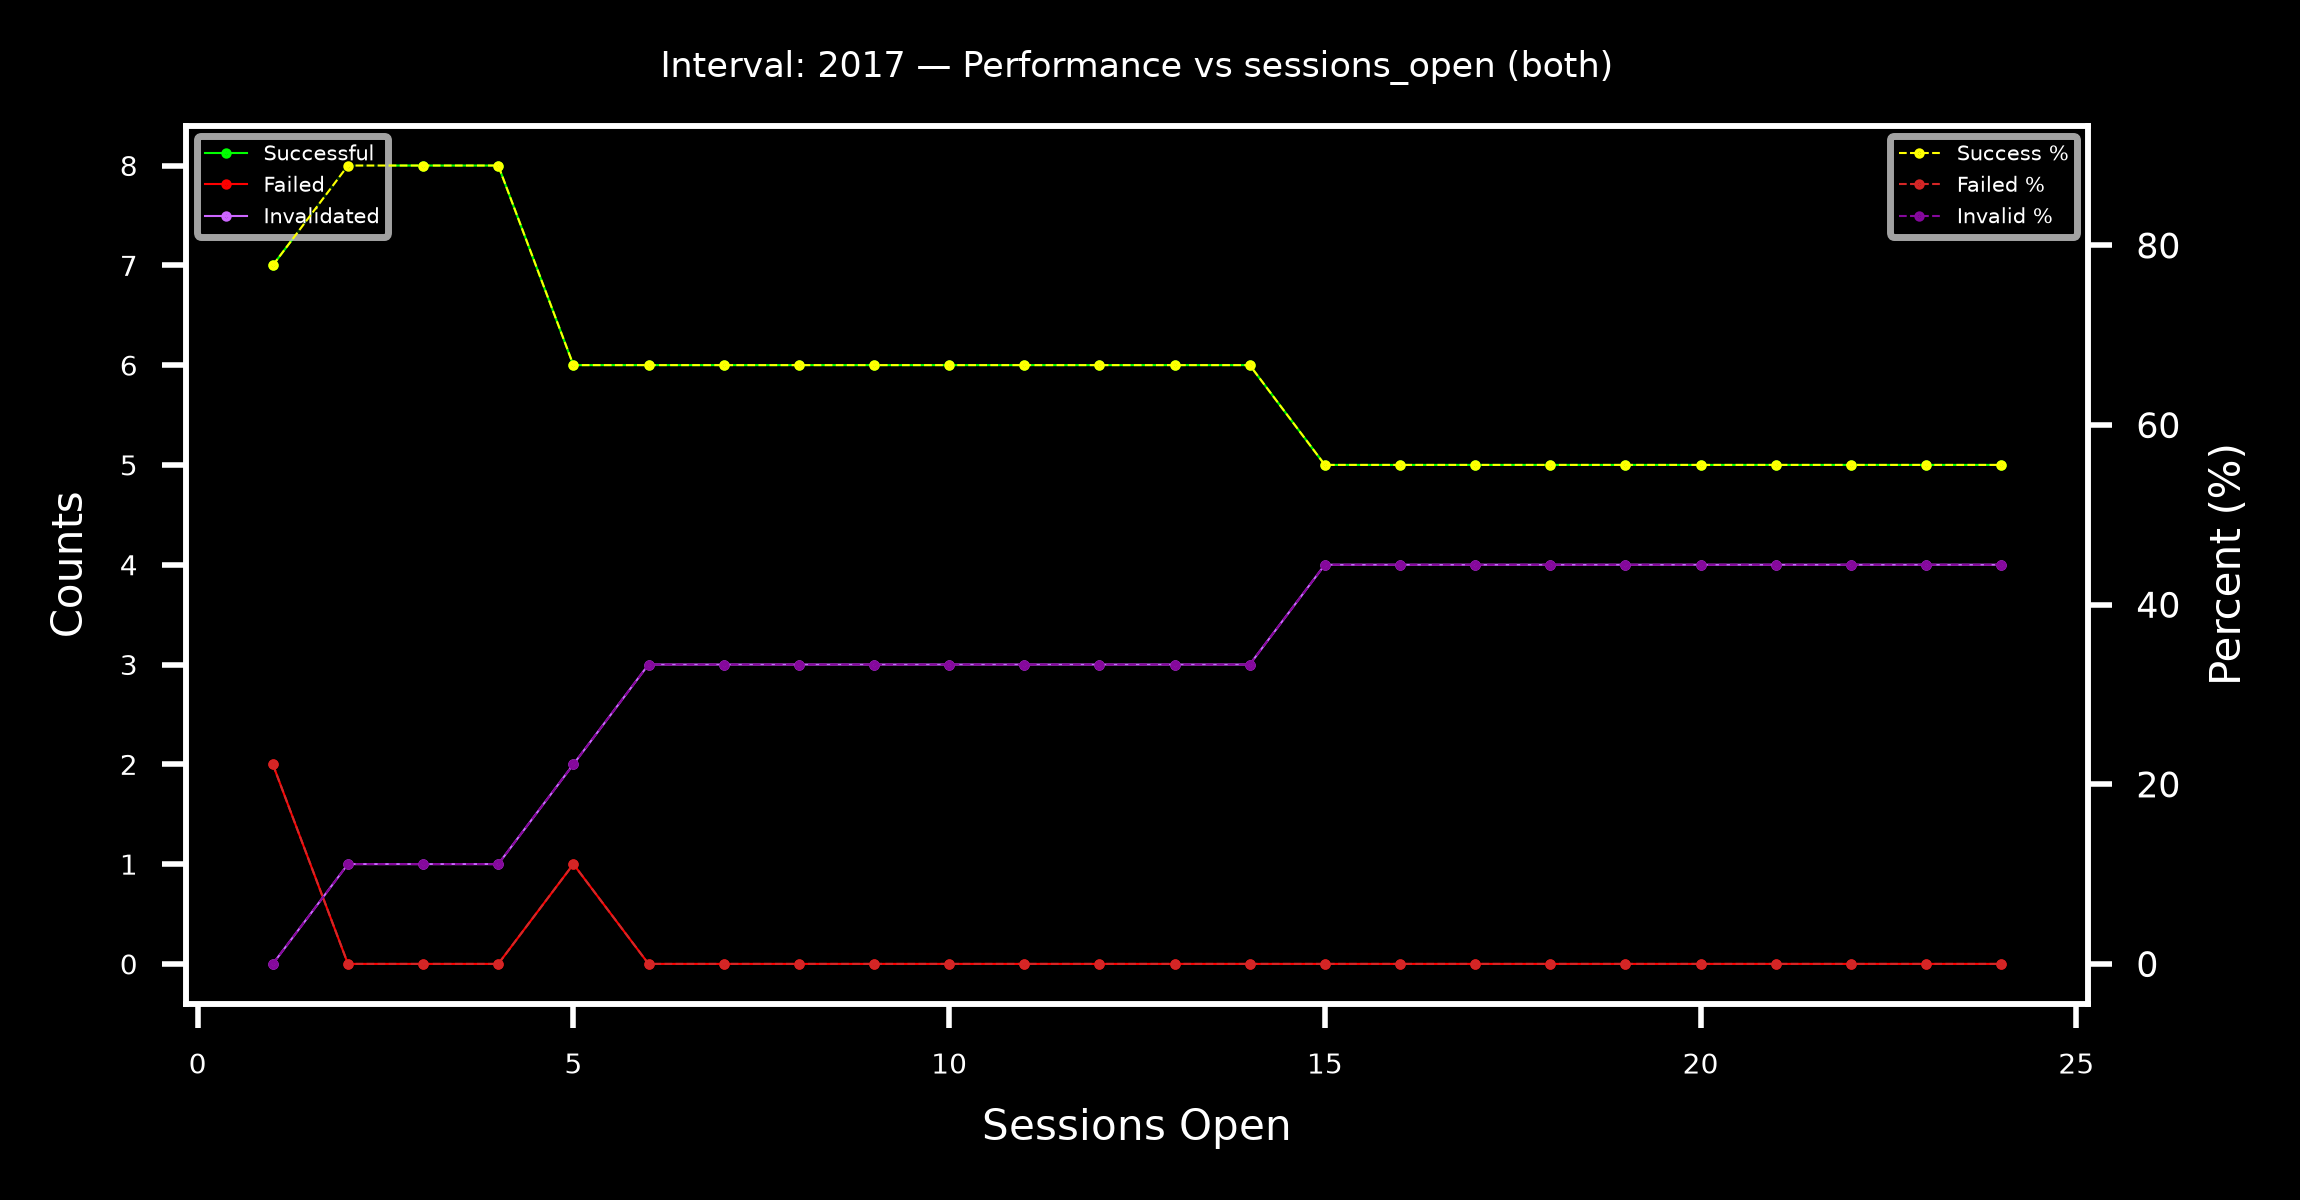

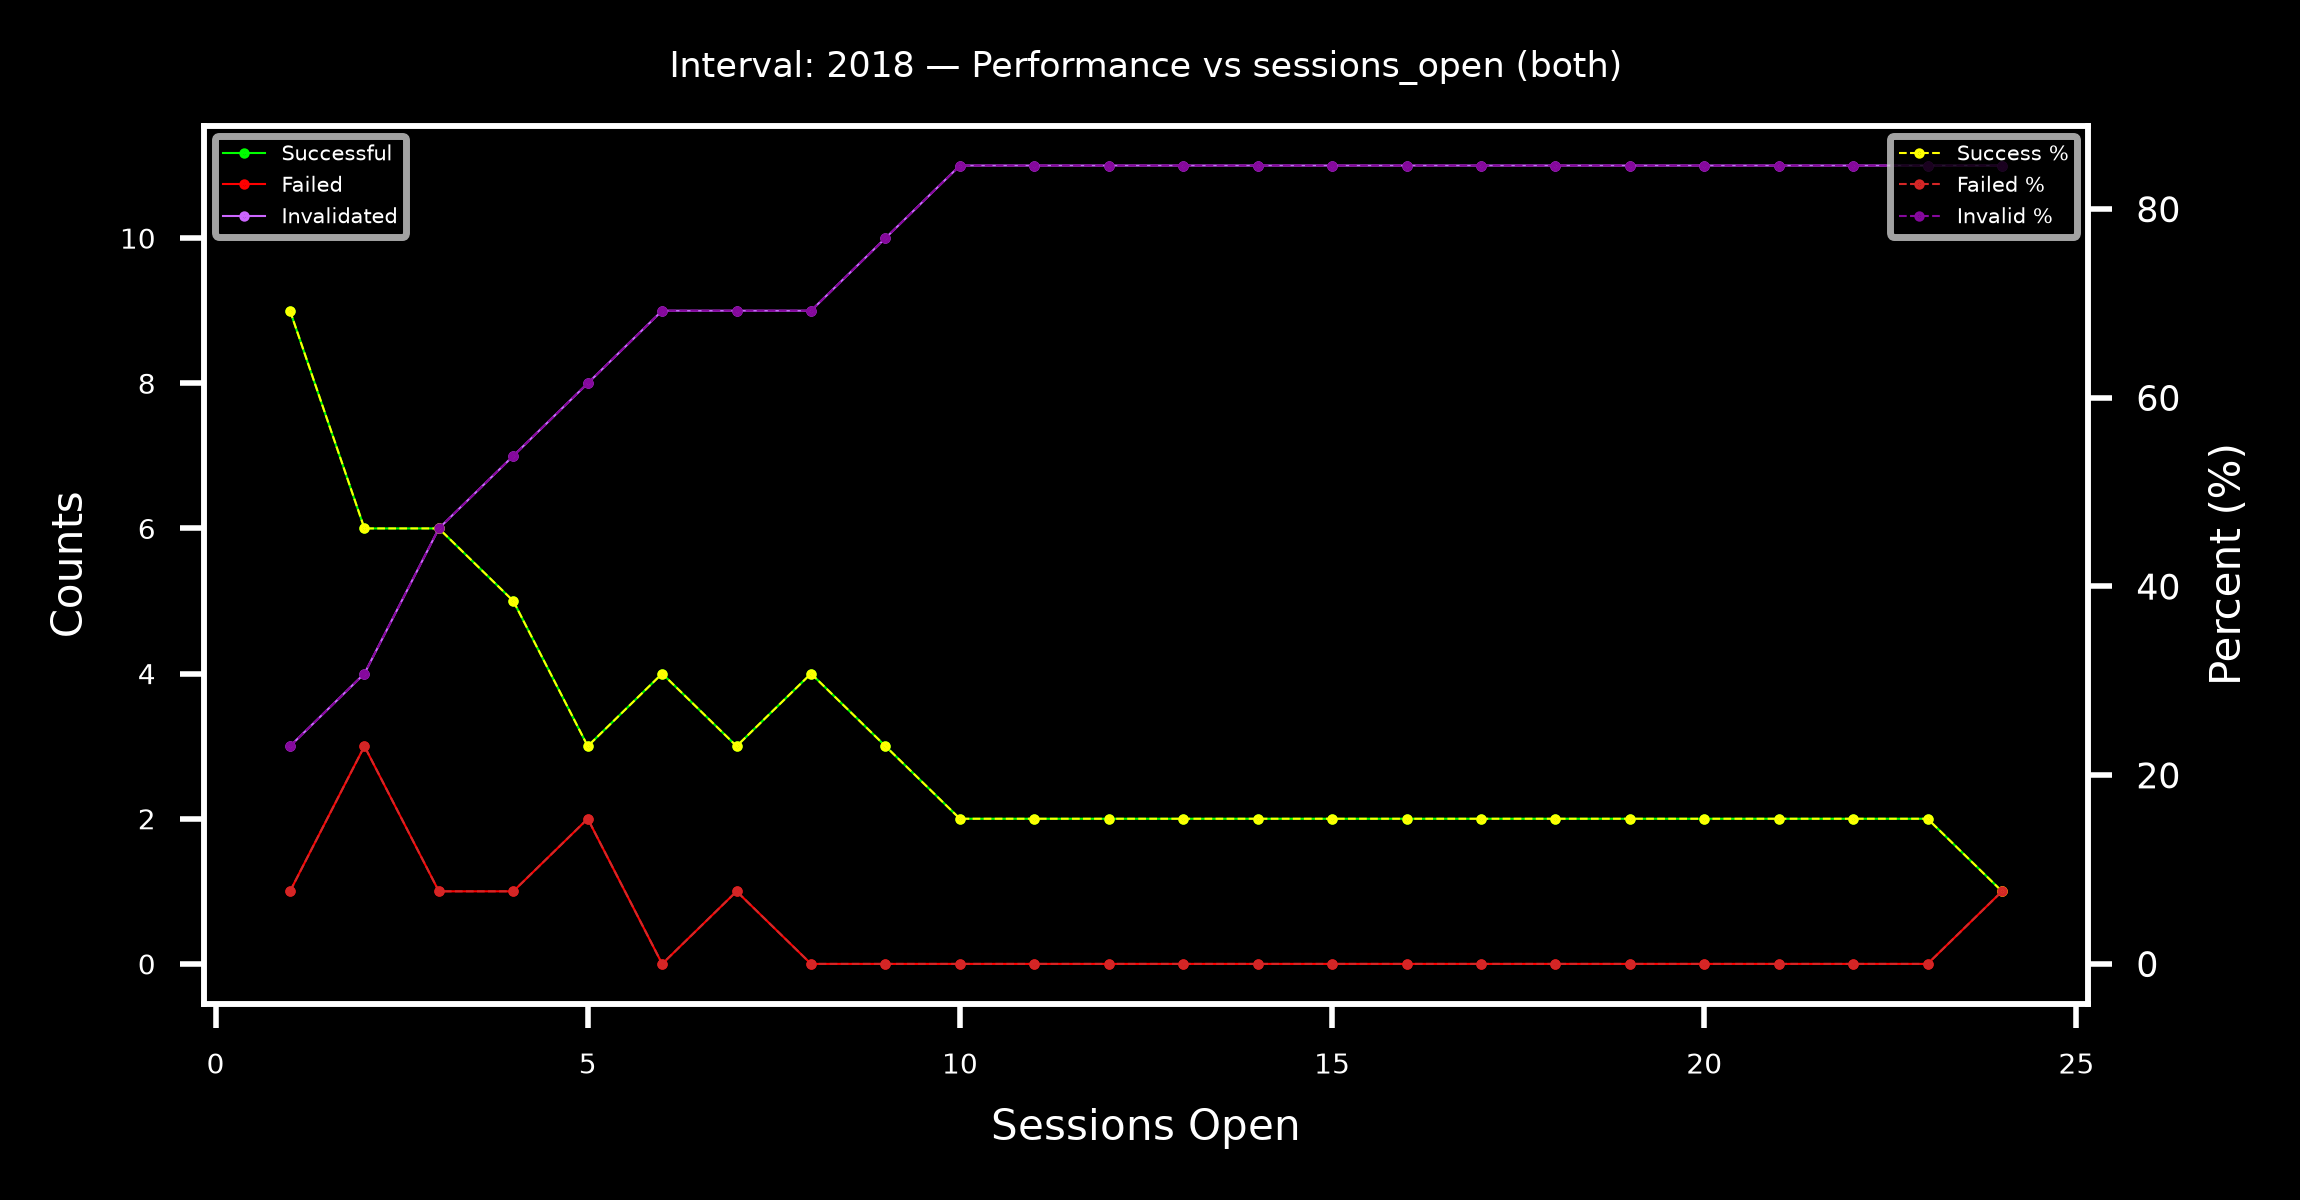

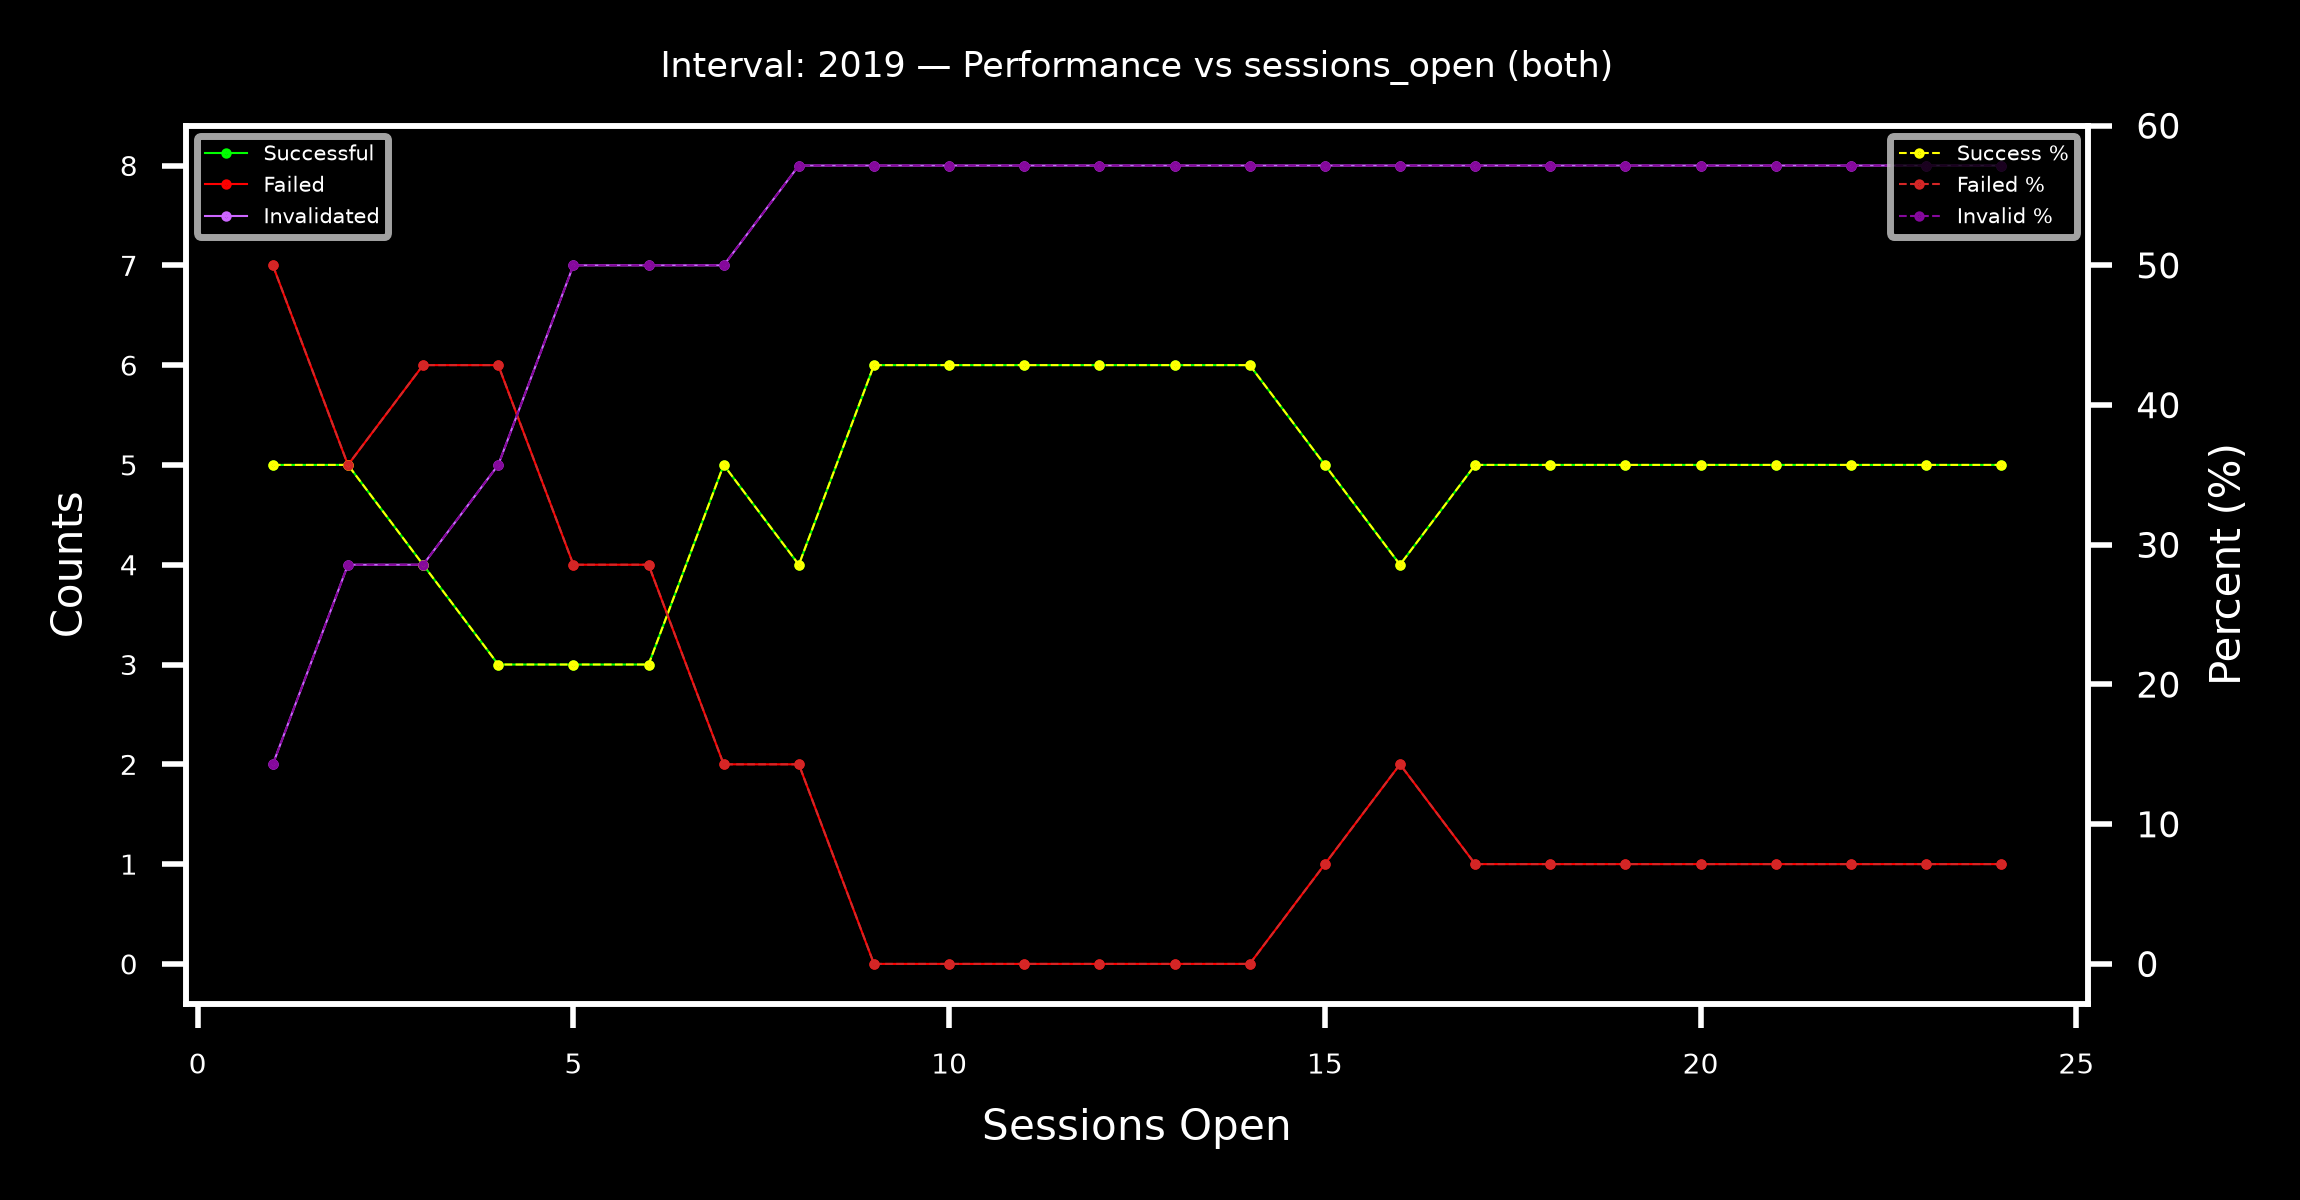

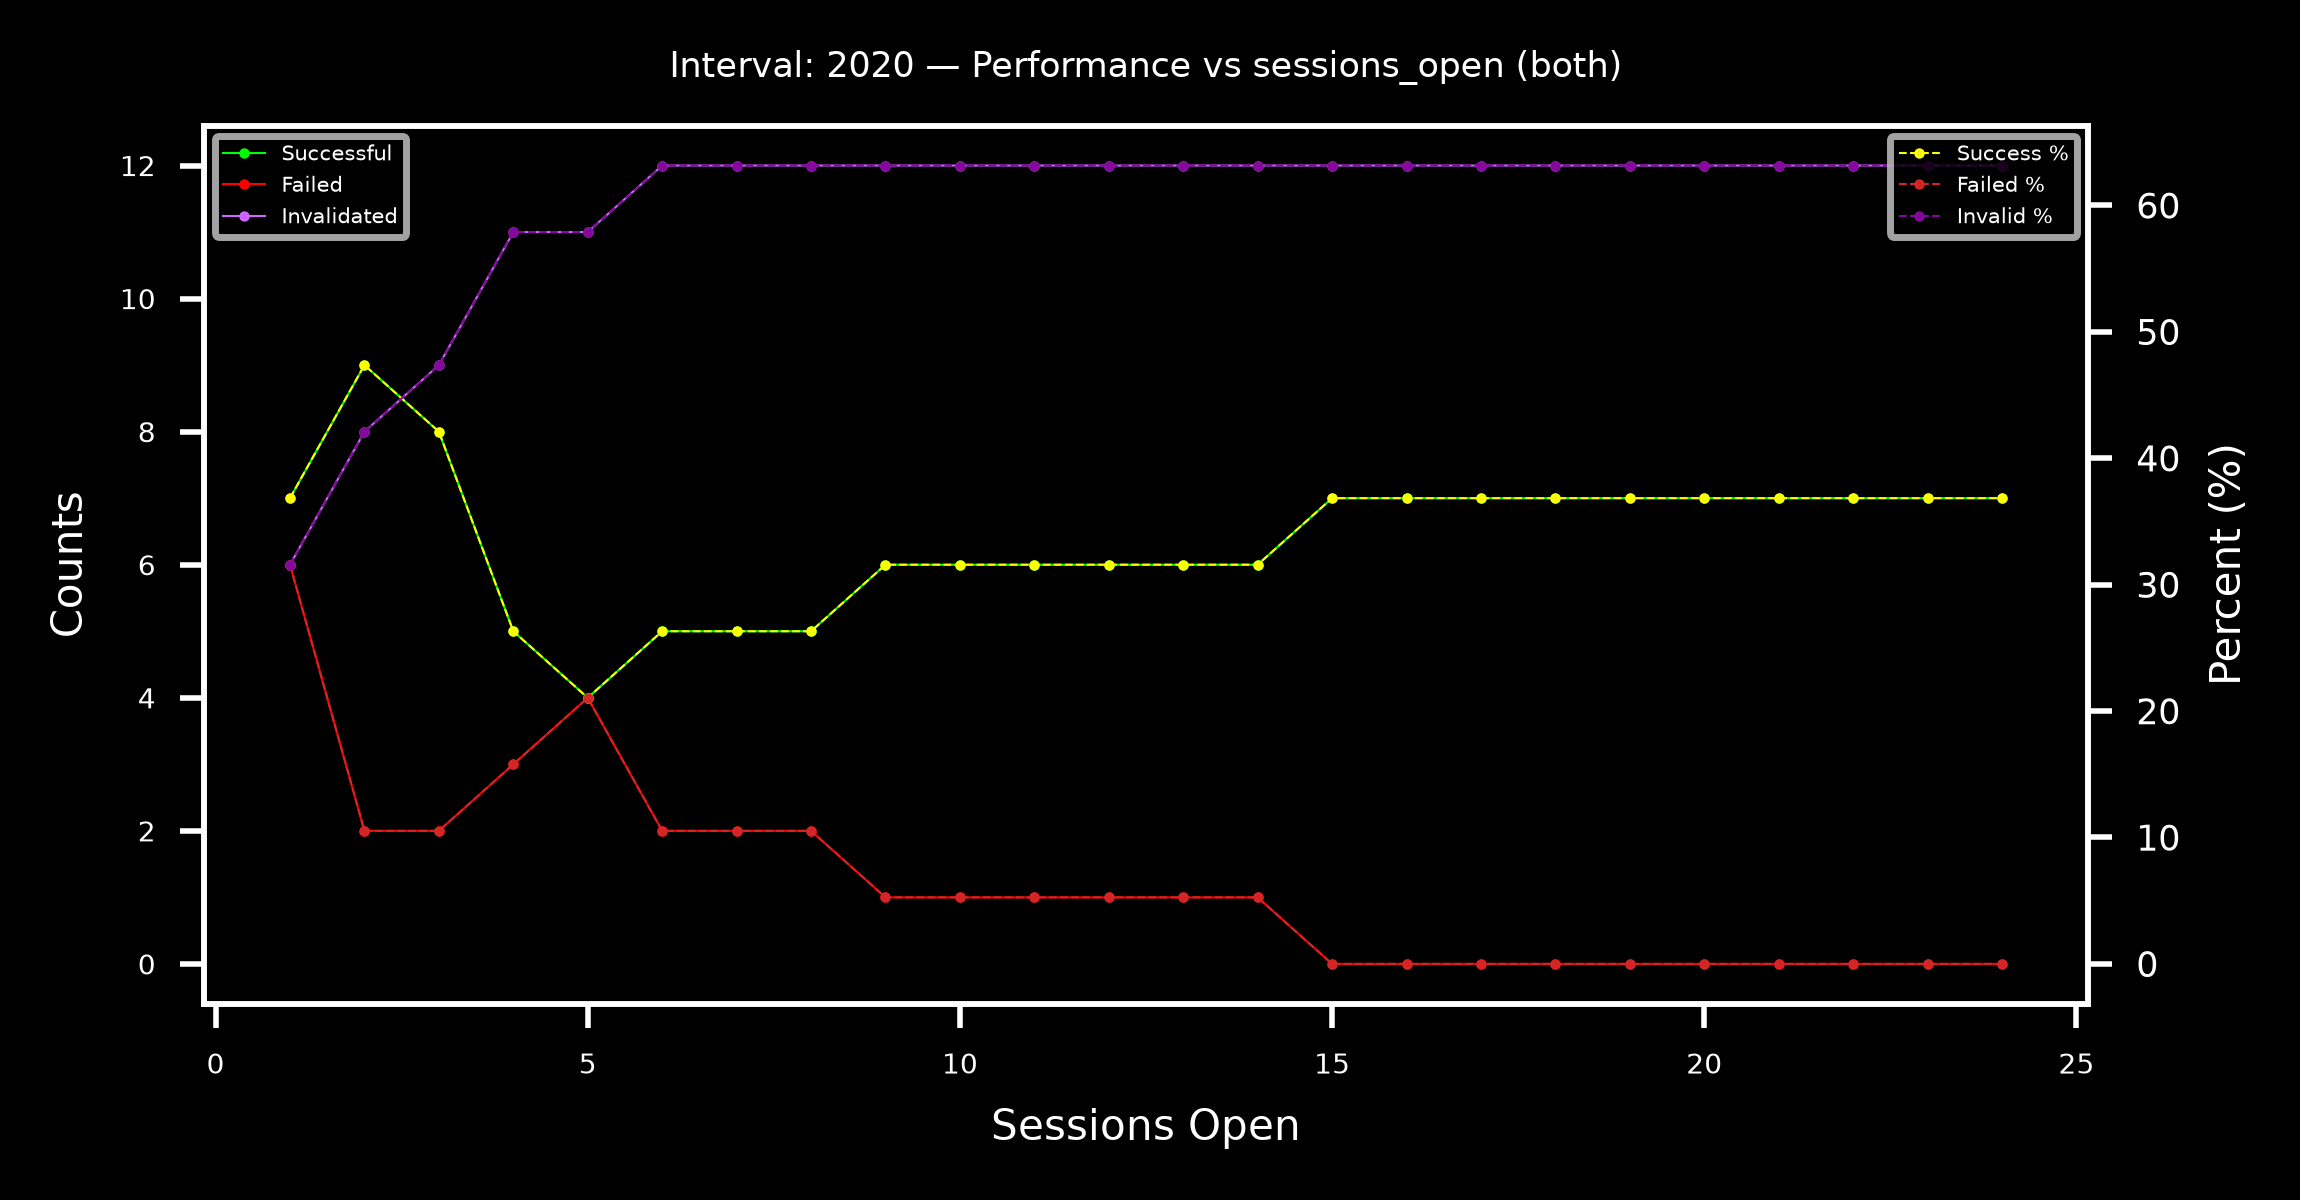

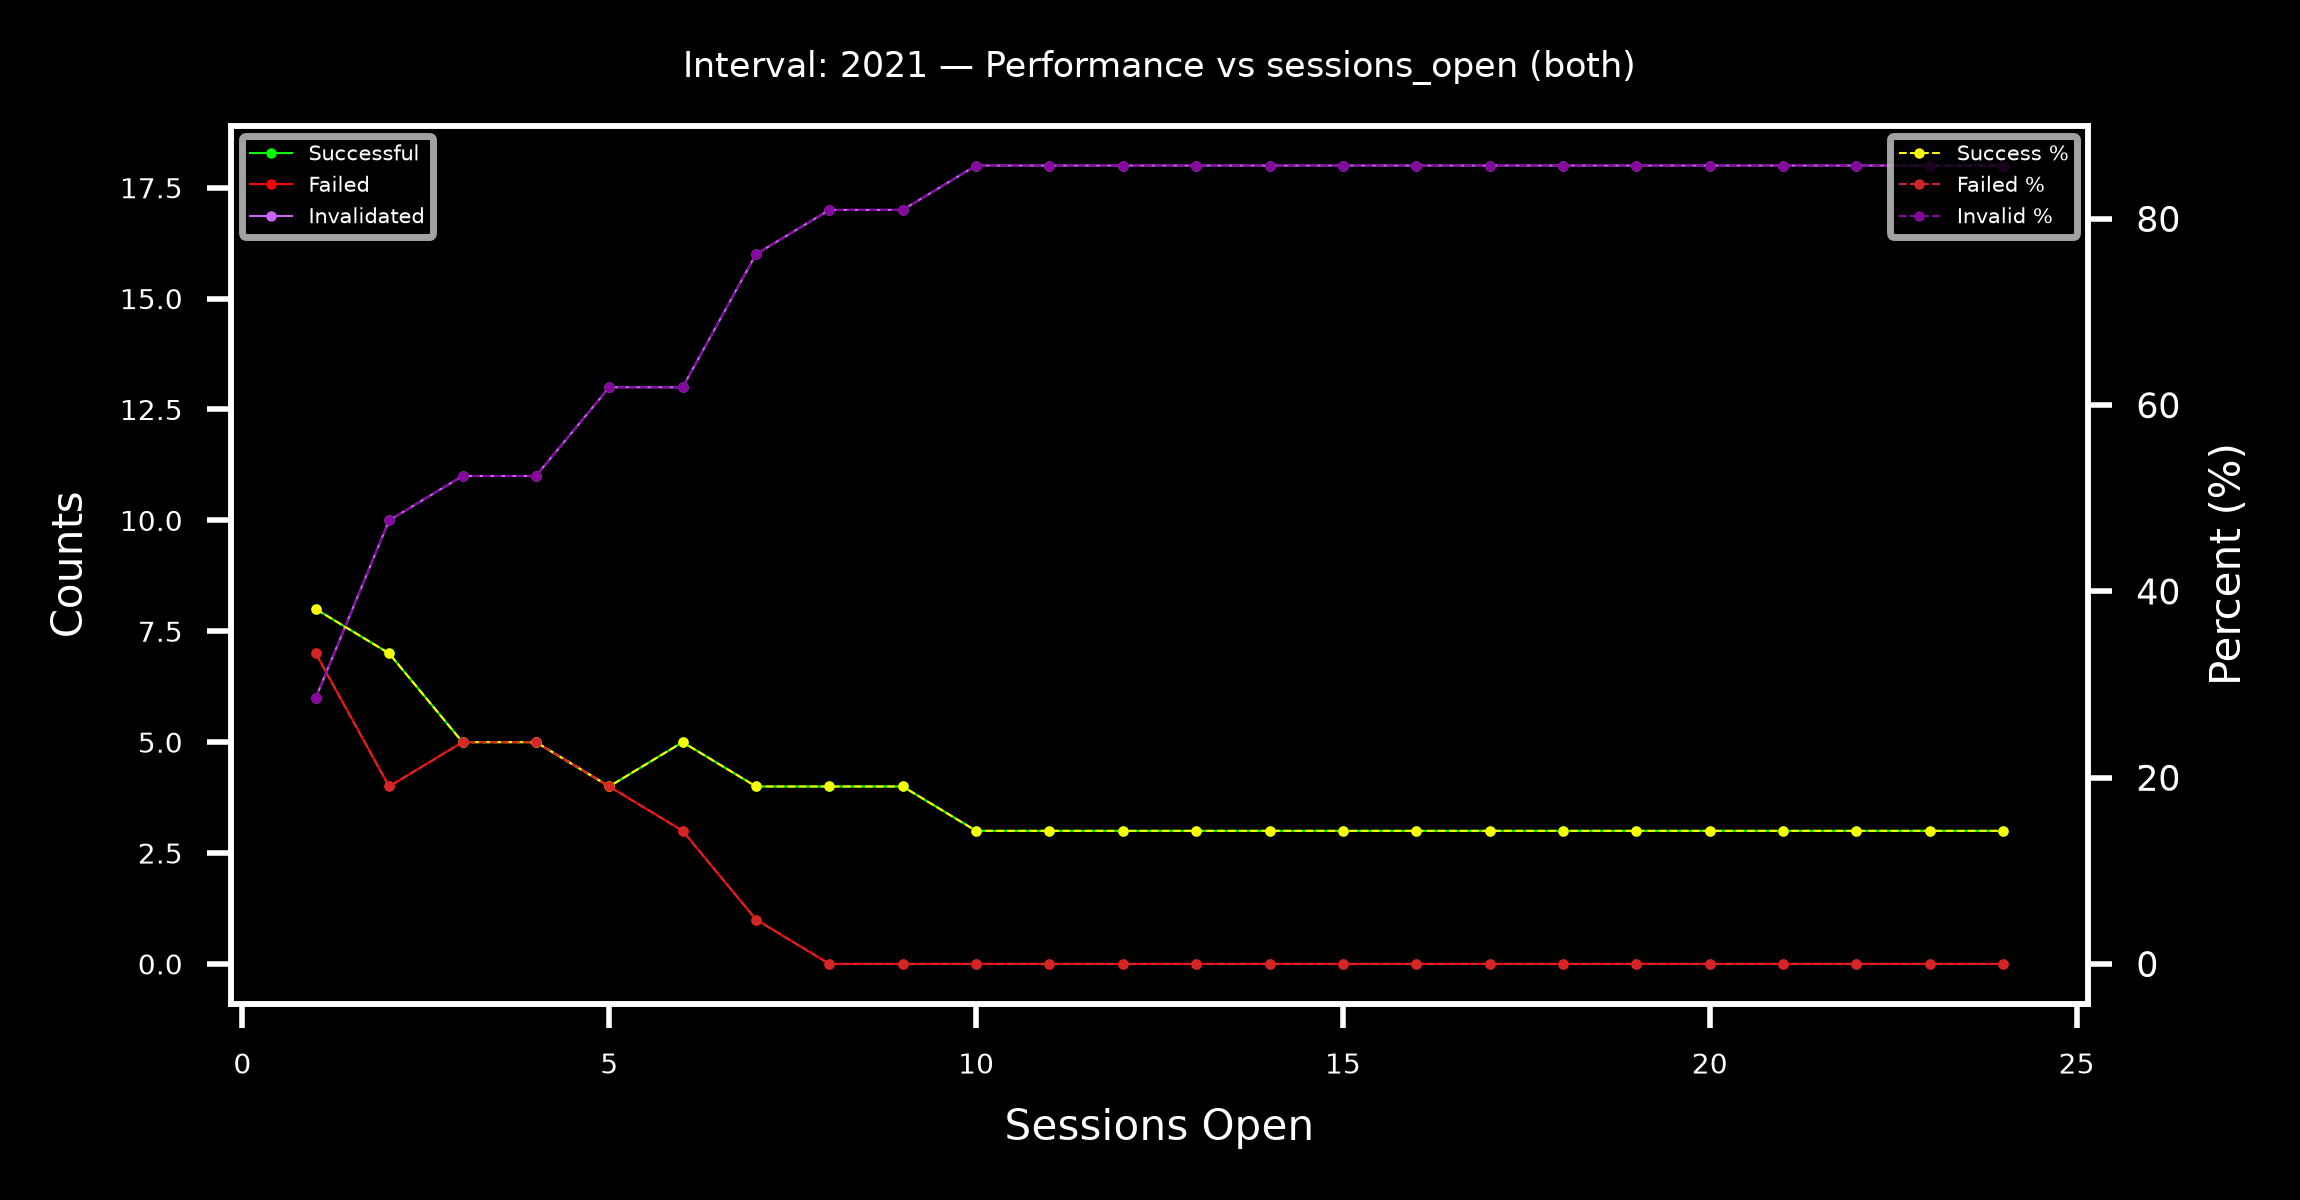

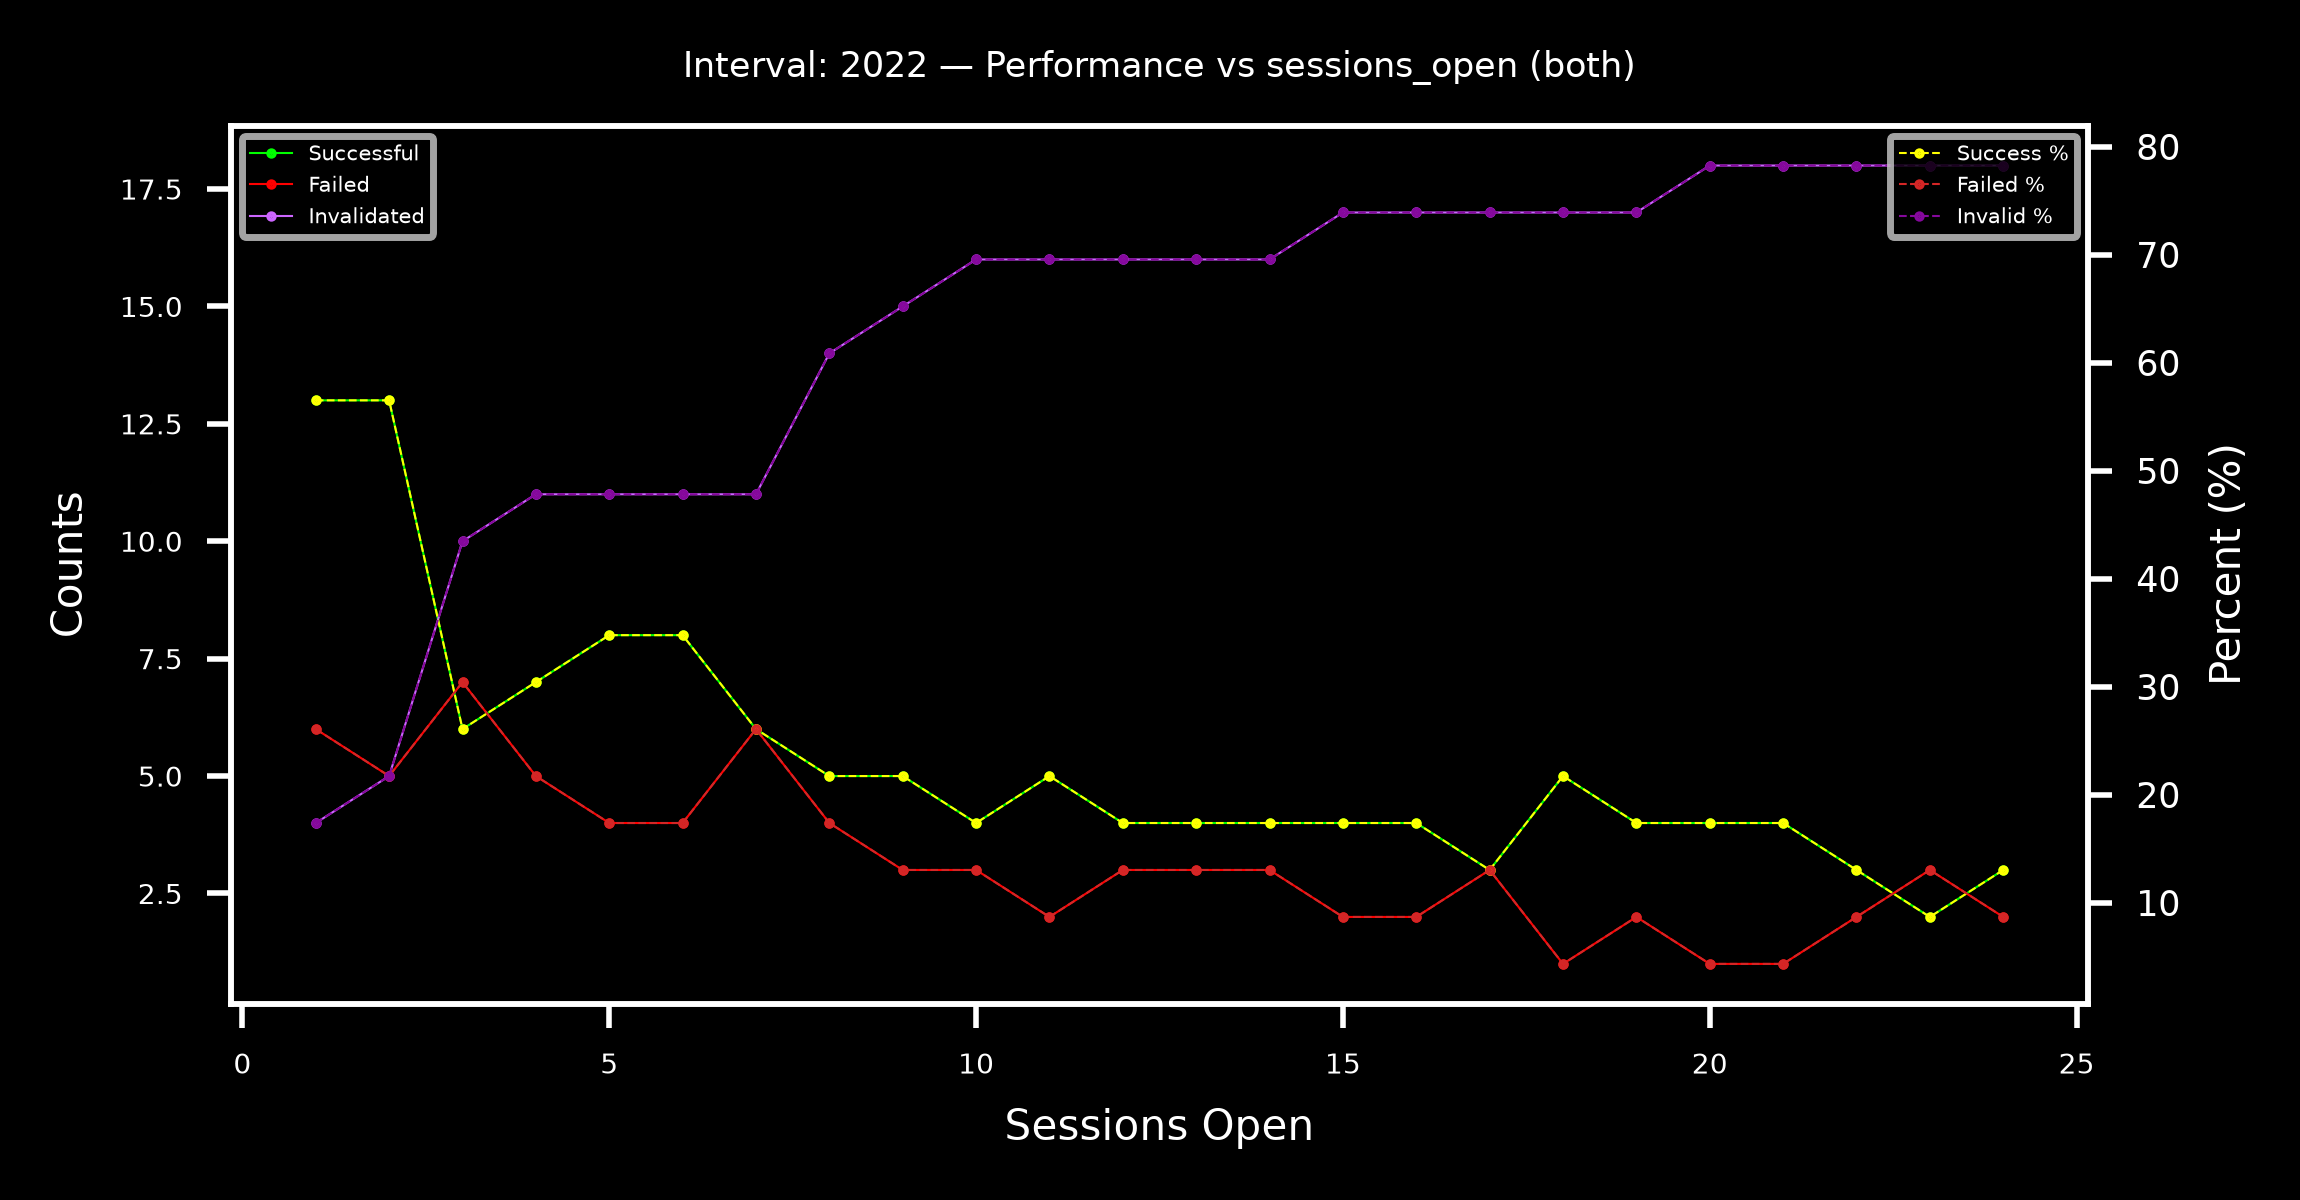

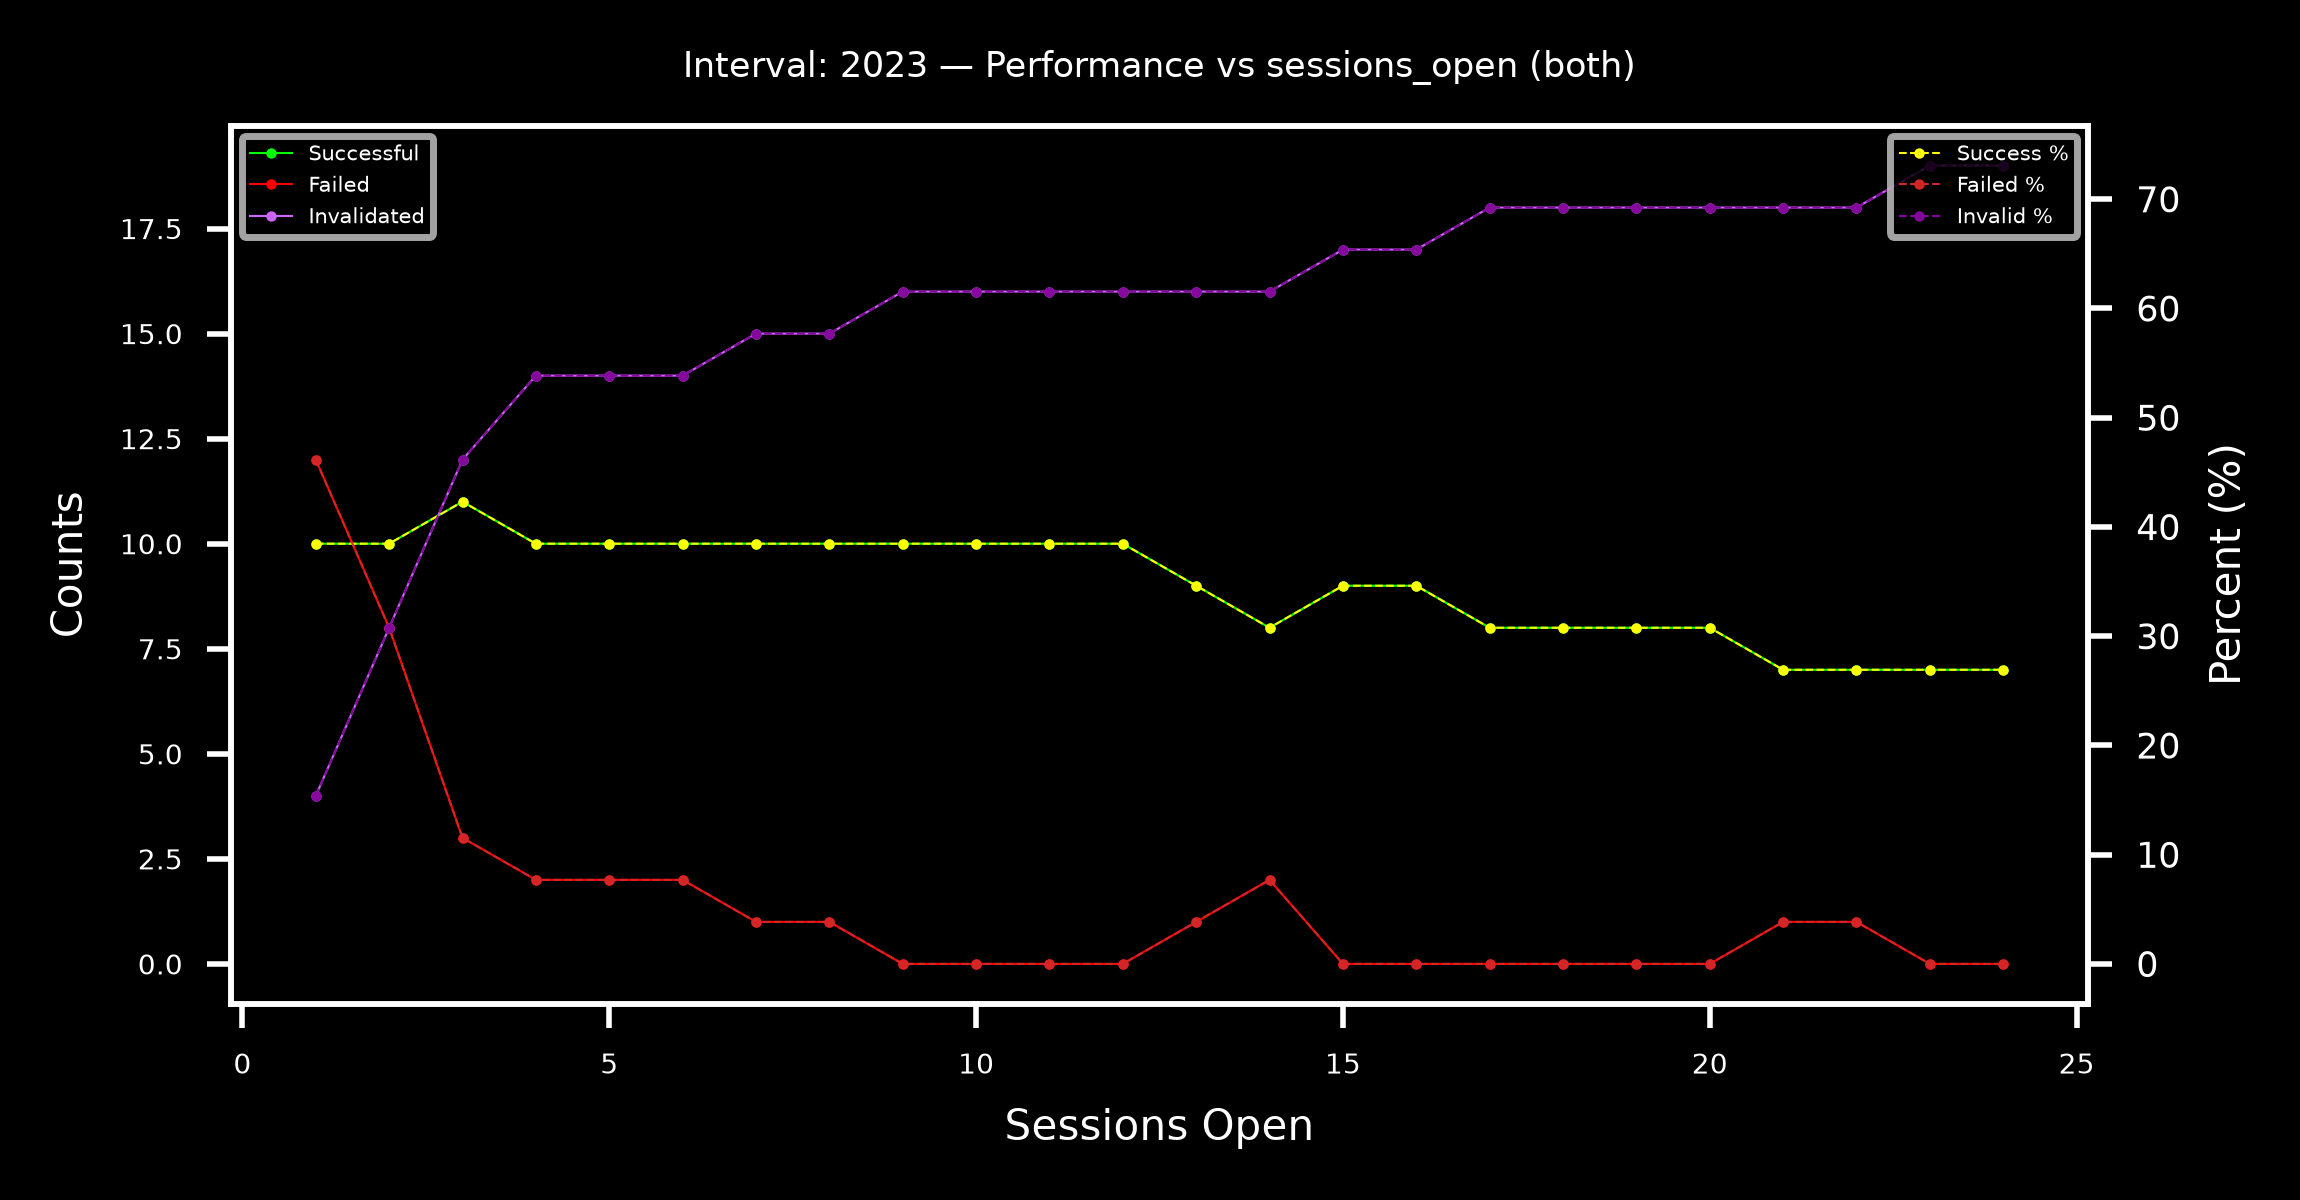

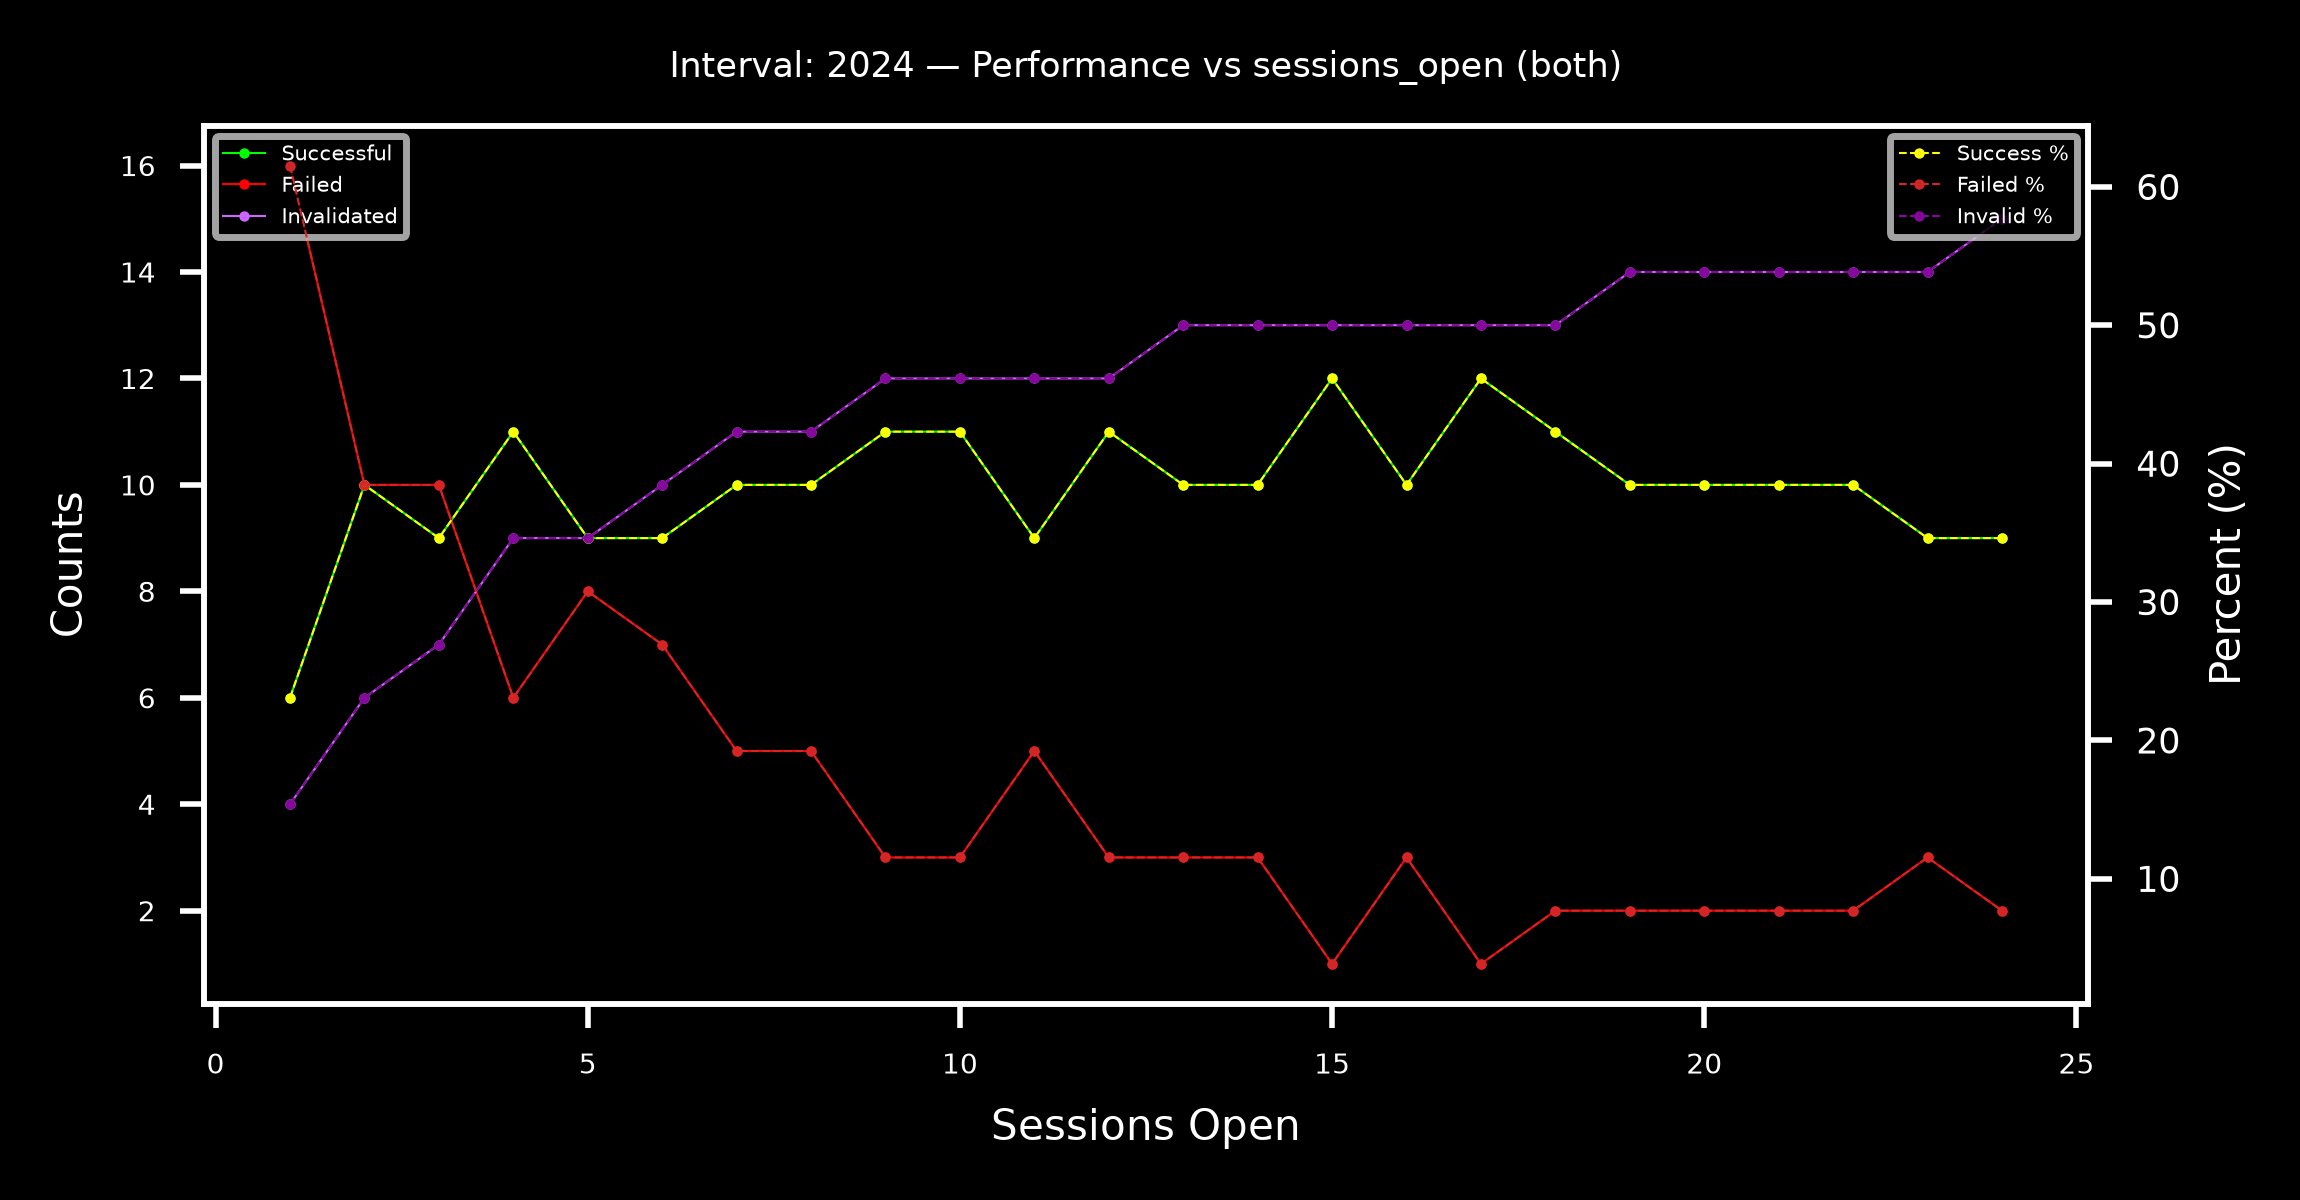

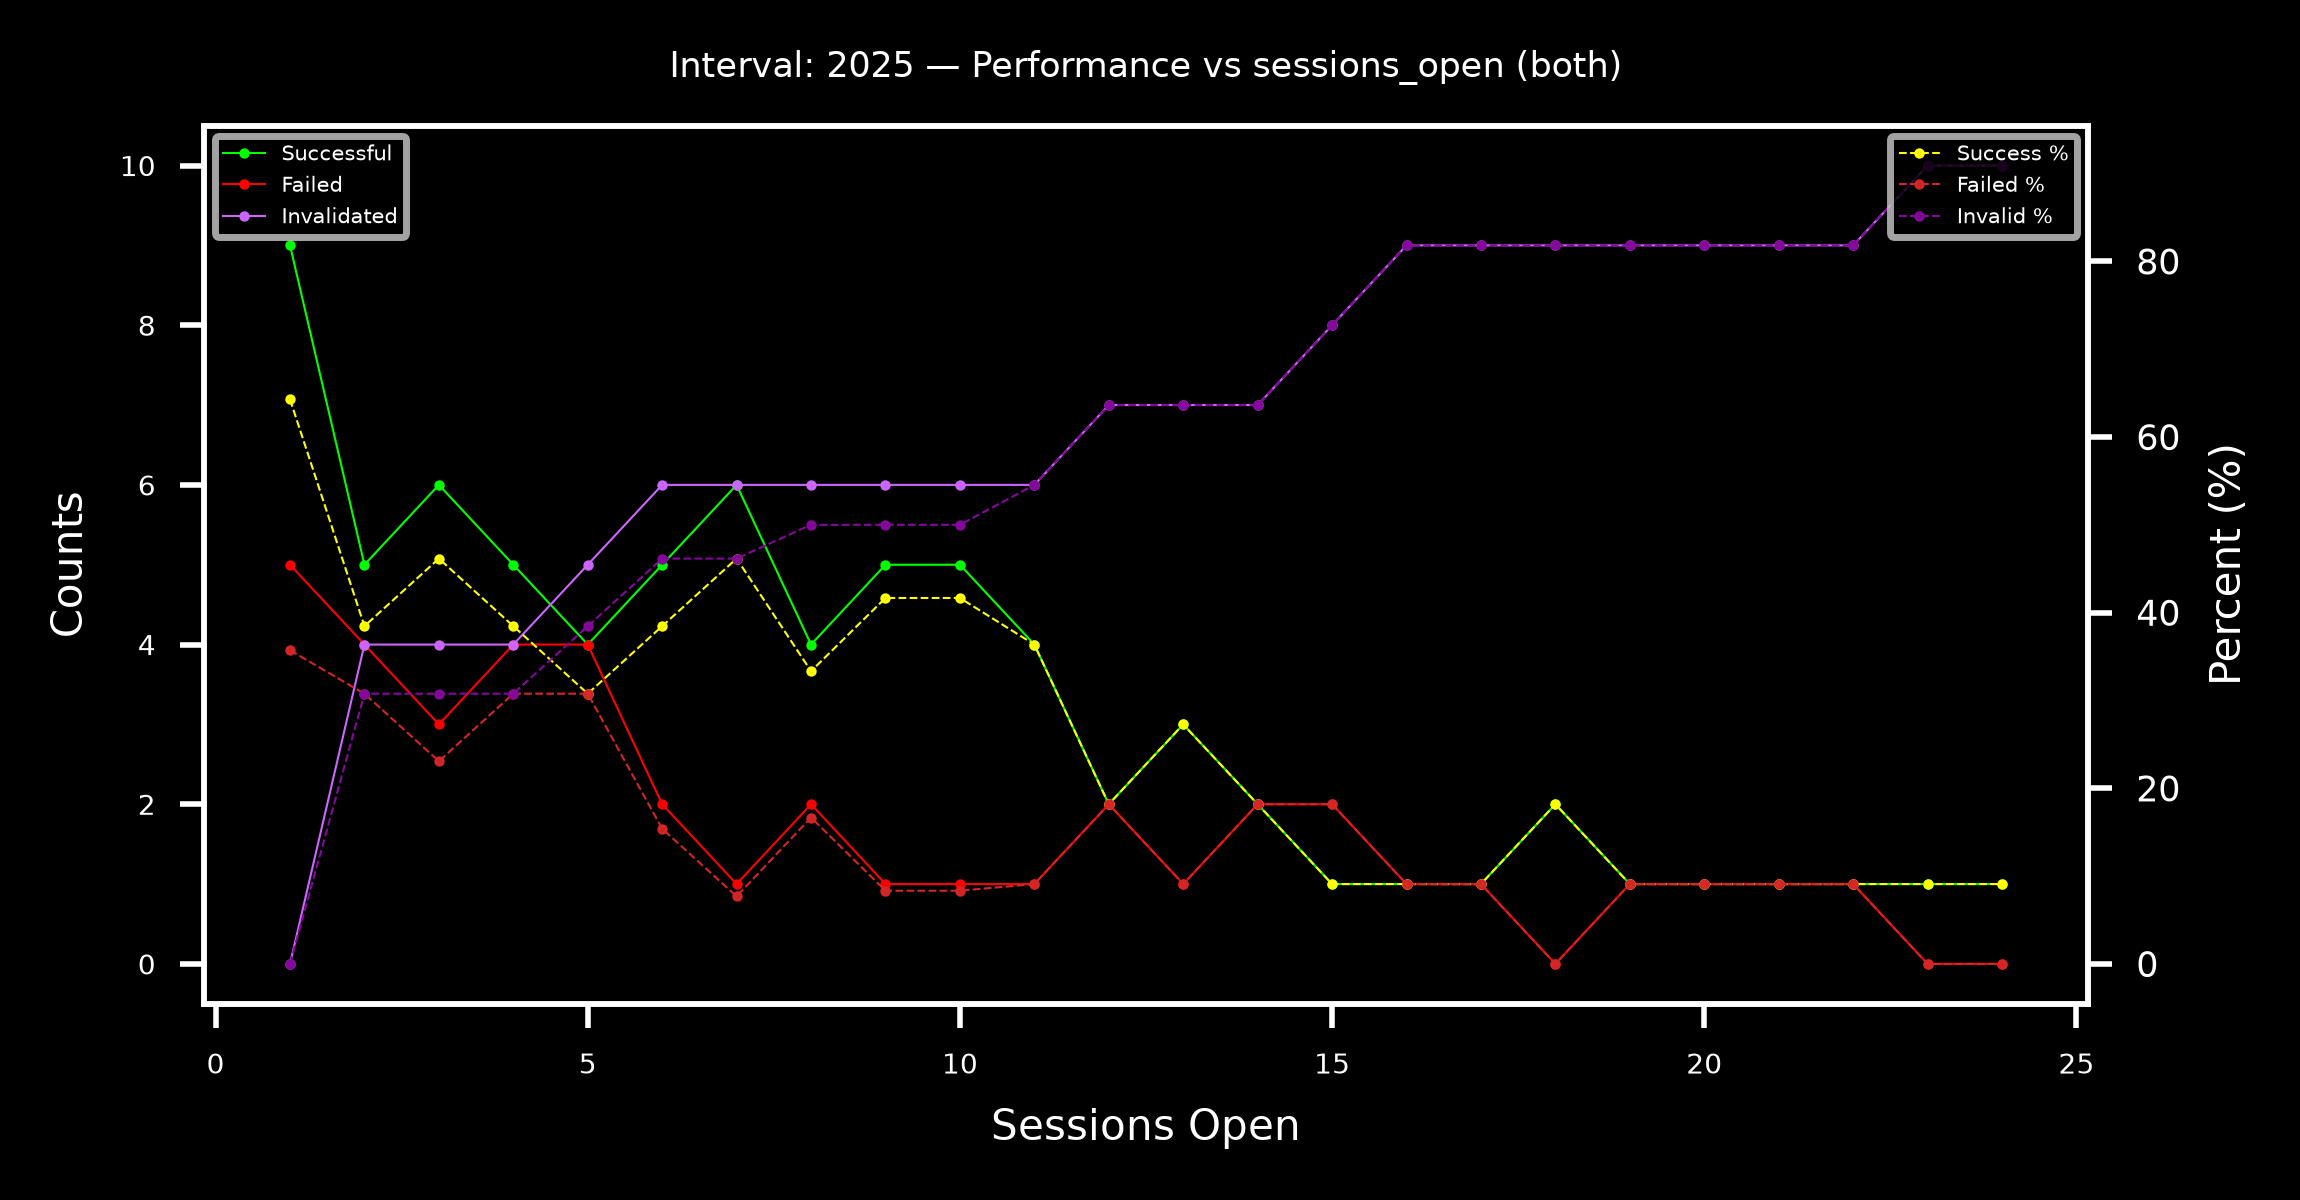

In [8]:
engine.run(show_results=True, plot_patterns=False)

Sessions 1
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  9   │  3   │  1  │  69  │  23  │  7   │ 0.69 │ 1.0  │ -0.… │ 0.4… │ -0.… │ 3.85 │ 3.68 │ -2.1… │ 0.3… │
│ 2017 │  9   │  7   │  2   │  0  │  77  │  22  │  0   │ 3.07 │ 3.55 │ -1.… │ 0.5… │ -0.… │ 11.… │ 26.… │ -1.8… │ 0.0… │
│ 2018 │  13  │  9   │  1   │  3  │  69  │  7   │  23  │ 2.04 │ 2.84 │ -3.3 │ 0.4… │ -0.… │ -2.… │ -1.… │ -27.… │ 0.5… │
│ 2019 │  14  │  5   │  7   │  2  │  35  │  50  │  14  │ 1.05 │ 1.31 │ -2.… │ 0.2… │ -0.… │ -6.… │ -5.… │ -7.6… │ 0.1… │
│ 2020 │  19  │  7   │  6   │  6  │  36  │  31  │  31  │ 2.1  │ 1.15 │ -2.… │ 0.2… │ -0.… │ -2.… │ -2.… │ -15.… │ 0.4… │
│ 2021 │  21  │  8   │  7   │  6  │  38  │  33  │  28  │ 2.99 │ 2.5  │ -4.… │ 0.3… │ -0.… │ -3.… │ -2.… │ -20.… │ 0.3… │
│ 2022 │  23  │  13  │  6   │  4  │  56  │  26  │  17  │ 2.93 │ 2.91 │ -2.… │ 0.5… │ -0.… │ 2.09 │ 1.84 │ -20.… │ 0.5… │
│ 2023 │  26  │  10  │  12  │  4  │  38  │  46  │  15  │ 2.91 │ 2.2  │ -1.… │ 0.6… │ -0.… │ 2.24 │ 4.18 │ -10.… │ 0.4… │
│ 2024 │  26  │  6   │  16  │  4  │  23  │  61  │  15  │ 0.43 │ 0.87 │ -2.… │ 0.2… │ -0.… │ -12… │ -8.… │ -24.… │ 0.0… │
│ 2025 │  14  │  9   │  5   │  0  │  64  │  35  │  0   │ 1.38 │ 1.48 │ -1.… │ 0.5x │ -0.… │ 6.69 │ 9.26 │ -2.2… │ 0.1… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

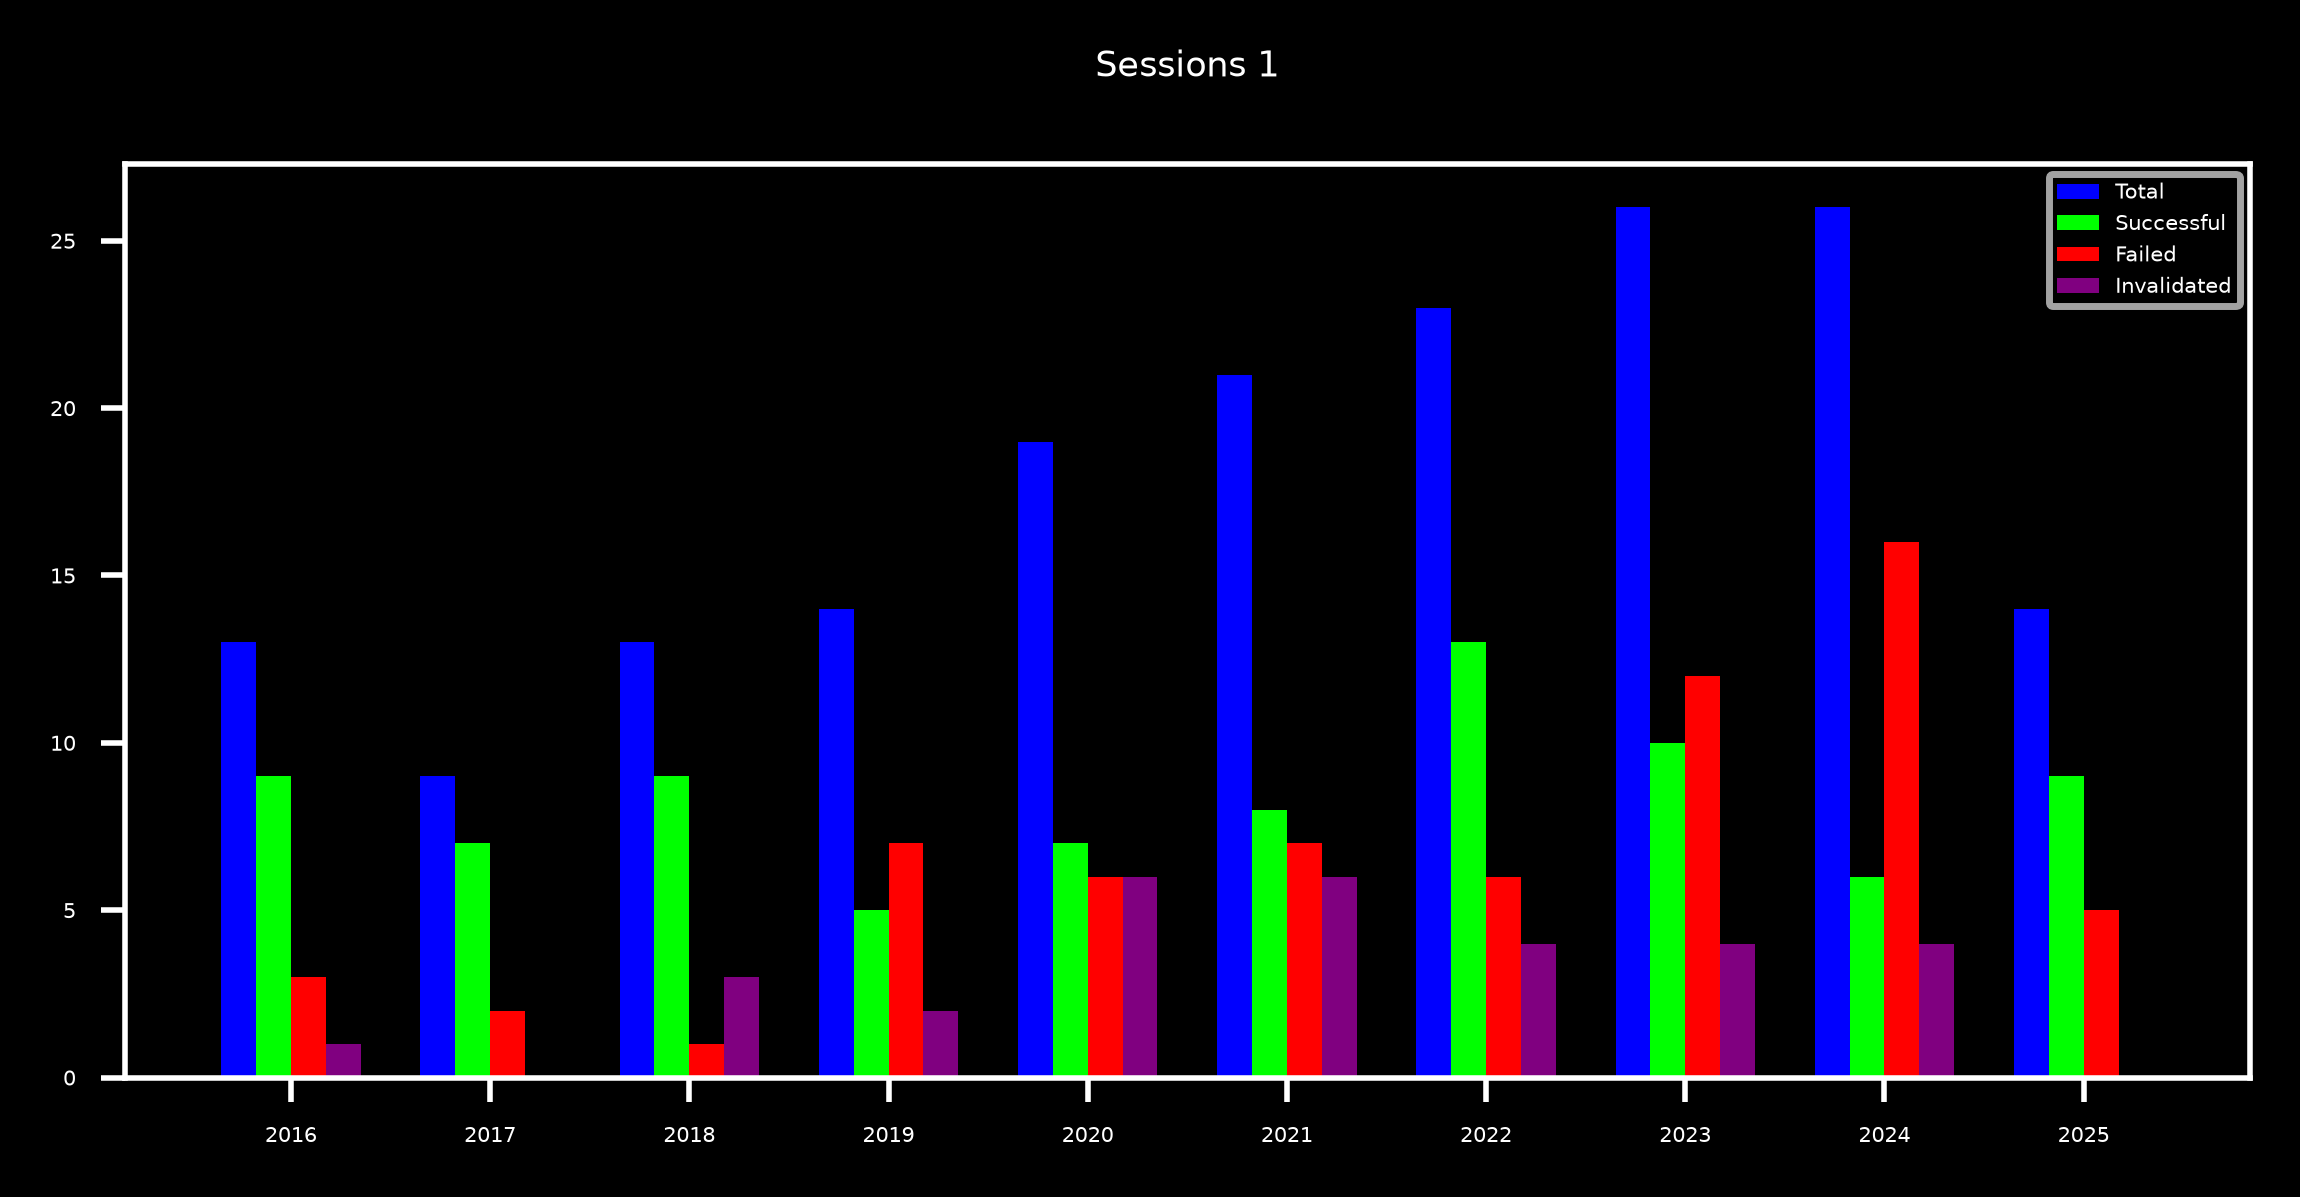

Sessions 2
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  7   │  4   │  2  │  53  │  30  │  15  │ 3.05 │ 2.15 │ -1.… │ 0.9… │ -0.… │ 7.0  │ 14.… │ -2.3% │ 0.1… │
│ 2017 │  9   │  8   │  0   │  1  │  88  │  0   │  11  │ 4.28 │ 5.26 │ -1.… │ 0.8… │ -0.… │ 8.54 │ 6.9  │ -6.9… │ 0.1… │
│ 2018 │  13  │  6   │  3   │  4  │  46  │  23  │  30  │ 2.93 │ 3.38 │ -6.0 │ 0.5… │ -1.… │ -4.… │ -3.… │ -34.… │ 0.2… │
│ 2019 │  14  │  5   │  5   │  4  │  35  │  35  │  28  │ 4.33 │ 2.48 │ -3.… │ 0.3… │ -0.… │ 0.64 │ 0.9  │ -14.… │ 0.8… │
│ 2020 │  19  │  9   │  2   │  8  │  47  │  10  │  42  │ 3.6  │ 2.68 │ -3.… │ 0.5… │ -0.… │ 1.45 │ 1.63 │ -11.… │ 0.6… │
│ 2021 │  21  │  7   │  4   │ 10  │  33  │  19  │  47  │ 3.97 │ 3.8  │ -5.… │ 0.5… │ -0.… │ -1.… │ -1.… │ -26.… │ 0.7… │
│ 2022 │  23  │  13  │  5   │  5  │  56  │  21  │  21  │ 2.03 │ 3.68 │ -2.8 │ 0.7… │ -0.… │ -0.… │ -0.… │ -19.… │ 0.8… │
│ 2023 │  26  │  10  │  8   │  8  │  38  │  30  │  30  │ 3.93 │ 3.16 │ -2.… │ 0.9… │ -0.… │ 1.36 │ 2.26 │ -11.… │ 0.6… │
│ 2024 │  26  │  10  │  10  │  6  │  38  │  38  │  23  │ 1.71 │ 1.54 │ -3.… │ 0.4… │ -0.… │ -5.… │ -4.… │ -29.… │ 0.1… │
│ 2025 │  13  │  5   │  4   │  4  │  38  │  30  │  30  │ 1.06 │ 1.87 │ -2.… │ 0.6… │ -0.… │ -5.… │ -5.… │ -9.0… │ 0.2… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

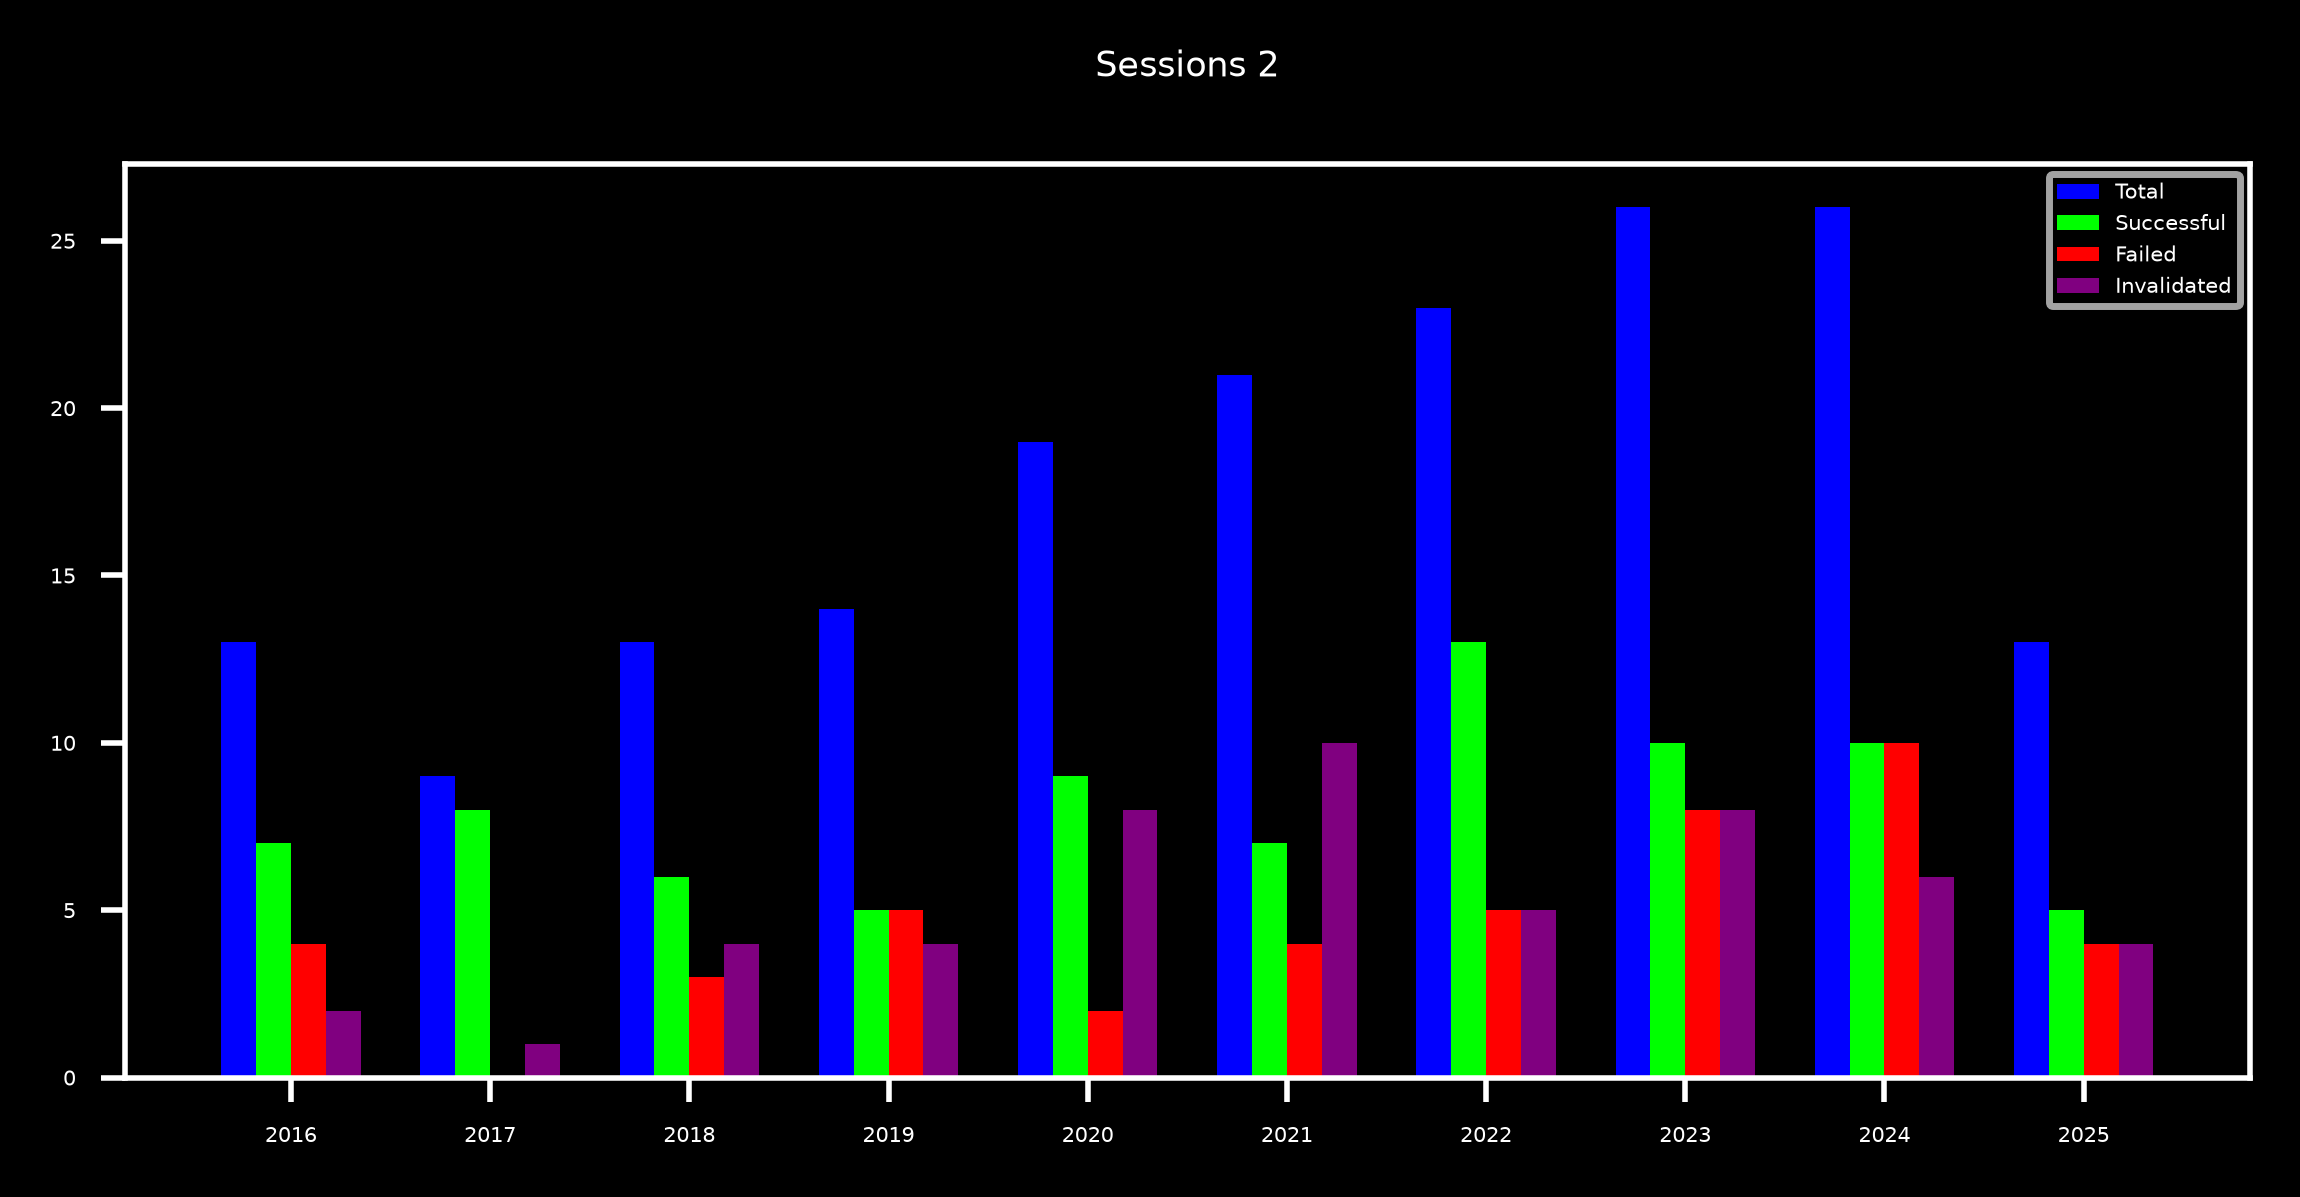

Sessions 3
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  8   │  3   │  2  │  61  │  23  │  15  │ 2.23 │ 2.53 │ -1.… │ 1.0… │ -0.… │ 4.4  │ 7.25 │ -4.3… │ 0.3… │
│ 2017 │  9   │  8   │  0   │  1  │  88  │  0   │  11  │ 4.67 │ 8.11 │ -3.3 │ 1.2… │ -0.… │ 4.43 │ 1.99 │ -17.… │ 0.4… │
│ 2018 │  13  │  6   │  1   │  6  │  46  │  7   │  46  │ 5.29 │ 4.61 │ -7.… │ 0.6… │ -1.… │ -3.… │ -3.… │ -39.… │ 0.4… │
│ 2019 │  14  │  4   │  6   │  4  │  28  │  42  │  28  │ 5.46 │ 3.23 │ -3.… │ 0.5x │ -0.… │ -0.… │ -0.… │ -15.… │ 0.8… │
│ 2020 │  19  │  8   │  2   │  9  │  42  │  10  │  47  │ 4.23 │ 3.18 │ -3.… │ 0.7x │ -0.… │ 2.09 │ 2.78 │ -9.9… │ 0.5… │
│ 2021 │  21  │  5   │  5   │ 11  │  23  │  23  │  52  │ 7.29 │ 5.47 │ -6.… │ 0.8x │ -1.… │ 0.46 │ 0.59 │ -28.… │ 0.8… │
│ 2022 │  23  │  6   │  7   │ 10  │  26  │  30  │  43  │ 2.77 │ 4.0  │ -4.… │ 0.7… │ -0.… │ -6.… │ -5.… │ -40.… │ 0.0… │
│ 2023 │  26  │  11  │  3   │ 12  │  42  │  11  │  46  │ 4.59 │ 3.73 │ -3.… │ 1.1… │ -0.… │ 1.34 │ 2.14 │ -11.… │ 0.6… │
│ 2024 │  26  │  9   │  10  │  7  │  34  │  38  │  26  │ 3.13 │ 2.16 │ -3.… │ 0.6x │ -0.… │ -3.… │ -3.2 │ -31.… │ 0.3… │
│ 2025 │  13  │  6   │  3   │  4  │  46  │  23  │  30  │ 2.59 │ 2.75 │ -2.… │ 0.9… │ -0.… │ 2.3  │ 2.59 │ -7.9% │ 0.6… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

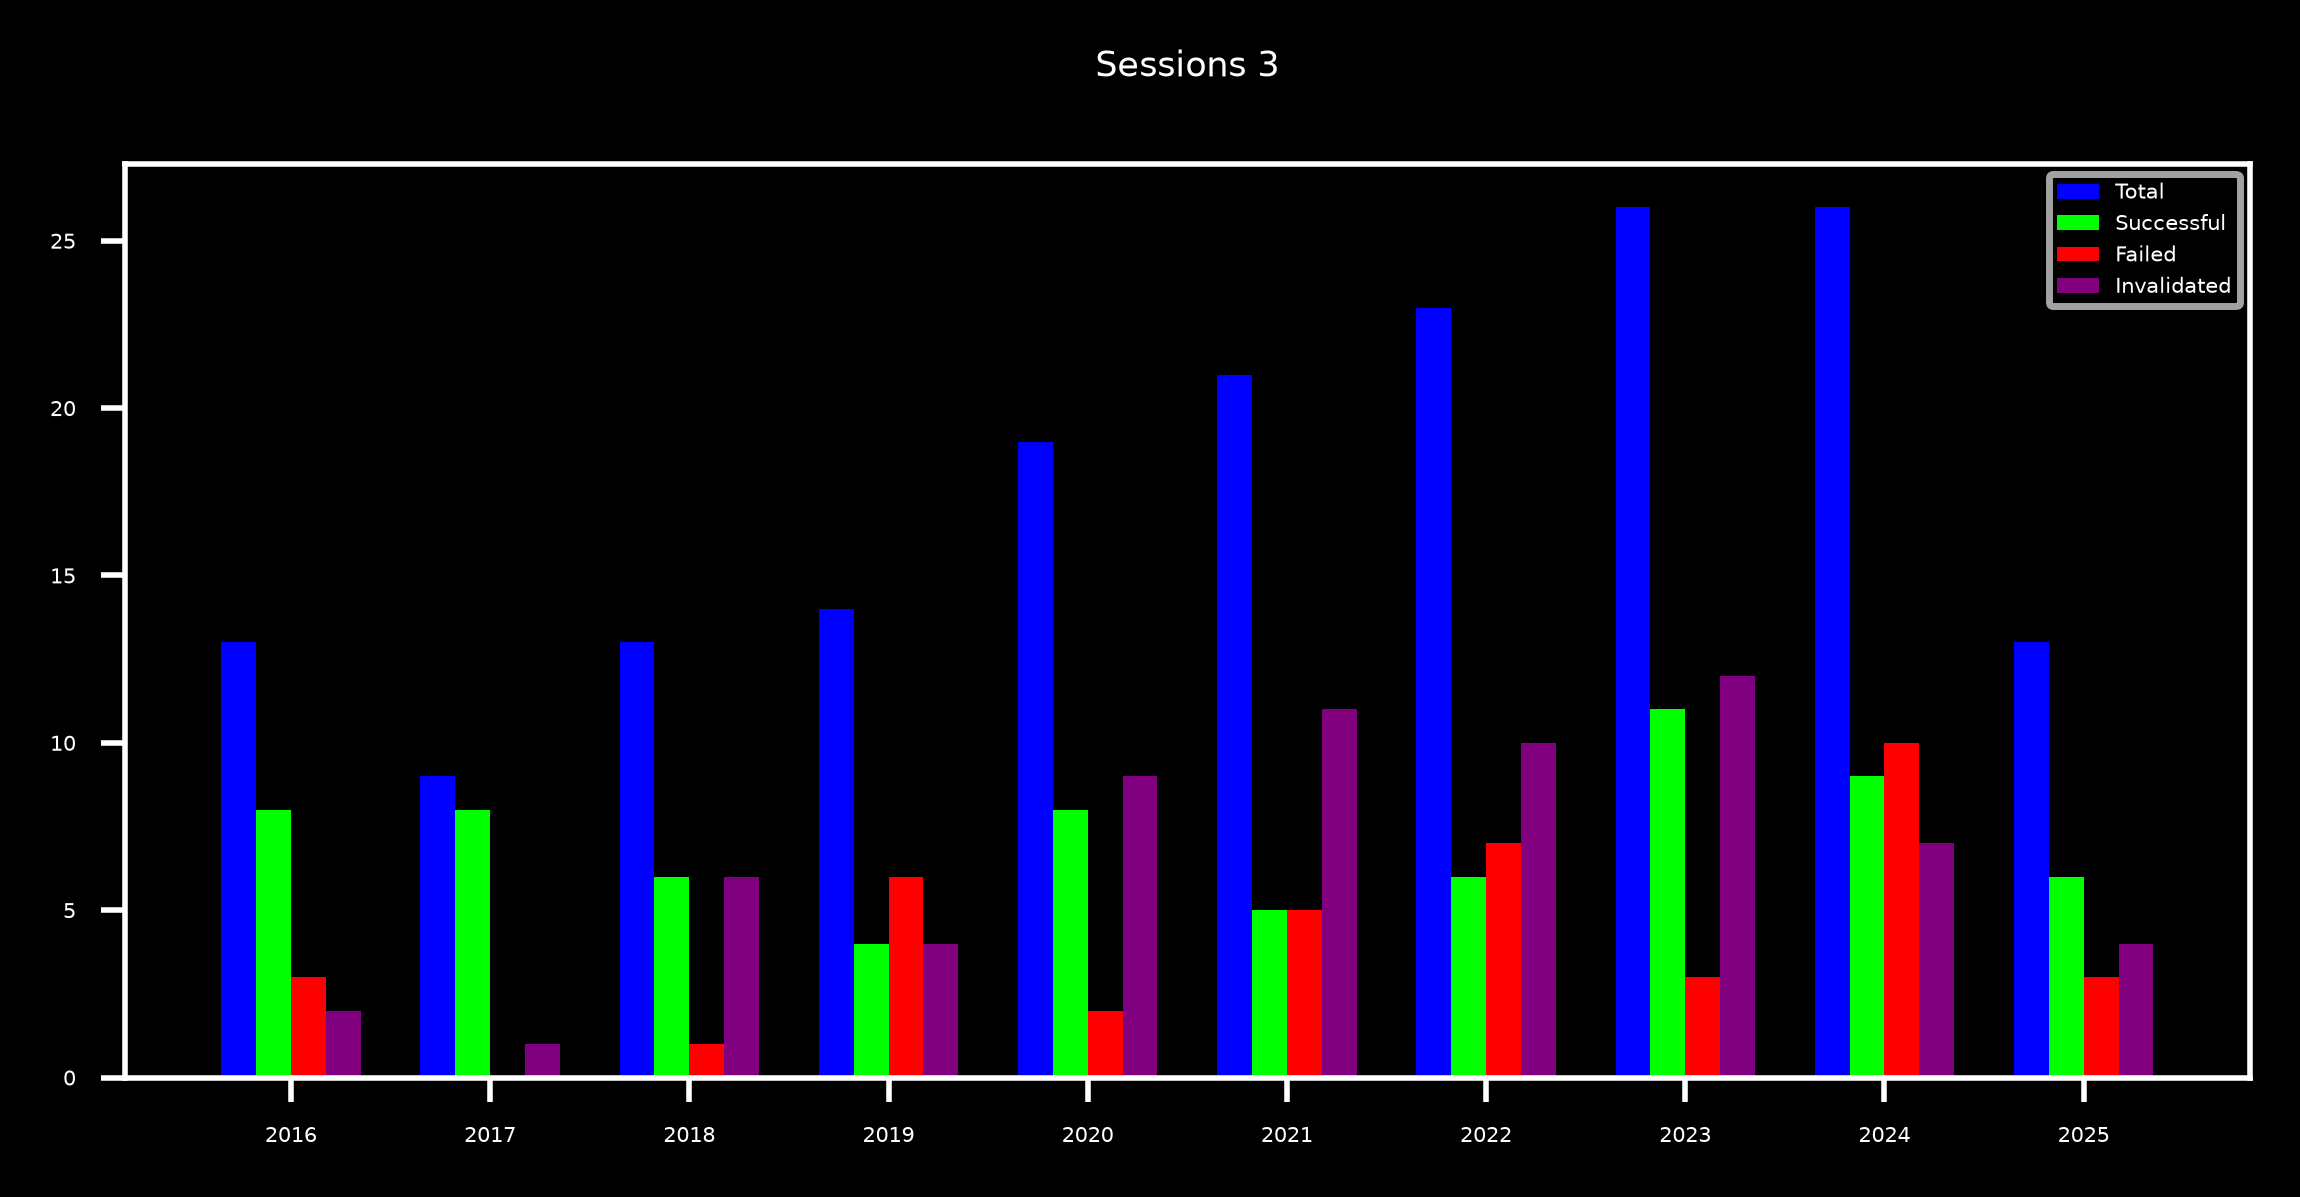

Sessions 4
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  9   │  1   │  3  │  69  │  7   │  23  │ 3.02 │ 3.3  │ -1.… │ 1.6x │ -0.… │ 8.57 │ 18.… │ -2.6… │ 0.0… │
│ 2017 │  9   │  8   │  0   │  1  │  88  │  0   │  11  │ 5.33 │ 9.03 │ -4.… │ 1.3… │ -0.… │ 4.72 │ 2.04 │ -19.… │ 0.3… │
│ 2018 │  13  │  5   │  1   │  7  │  38  │  7   │  53  │ 5.7  │ 4.72 │ -8.4 │ 0.7x │ -1.… │ -5.… │ -4.… │ -48.… │ 0.2… │
│ 2019 │  14  │  3   │  6   │  5  │  21  │  42  │  35  │ 6.44 │ 4.1  │ -5.… │ 0.6… │ -0.… │ -2.… │ -3.… │ -18.… │ 0.5… │
│ 2020 │  19  │  5   │  3   │ 11  │  26  │  15  │  57  │ 5.42 │ 3.64 │ -4.… │ 0.8… │ -1.… │ -2.… │ -2.… │ -31.… │ 0.5… │
│ 2021 │  21  │  5   │  5   │ 11  │  23  │  23  │  52  │ 7.52 │ 6.3  │ -7.… │ 0.9… │ -1.… │ 0.39 │ 0.42 │ -35.… │ 0.9… │
│ 2022 │  23  │  7   │  5   │ 11  │  30  │  21  │  47  │ 2.4  │ 4.56 │ -5.… │ 0.8… │ -1.… │ -3.… │ -3.… │ -36.… │ 0.2… │
│ 2023 │  26  │  10  │  2   │ 14  │  38  │  7   │  53  │ 6.31 │ 4.75 │ -3.… │ 1.5… │ -1.… │ 2.75 │ 4.29 │ -19.… │ 0.3… │
│ 2024 │  26  │  11  │  6   │  9  │  42  │  23  │  34  │ 3.86 │ 3.16 │ -4.… │ 0.8… │ -1.… │ -0.… │ -0.… │ -33.… │ 0.8… │
│ 2025 │  13  │  5   │  4   │  4  │  38  │  30  │  30  │ 3.23 │ 3.11 │ -2.… │ 1.1… │ -0.… │ 2.35 │ 3.52 │ -9.3… │ 0.6… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

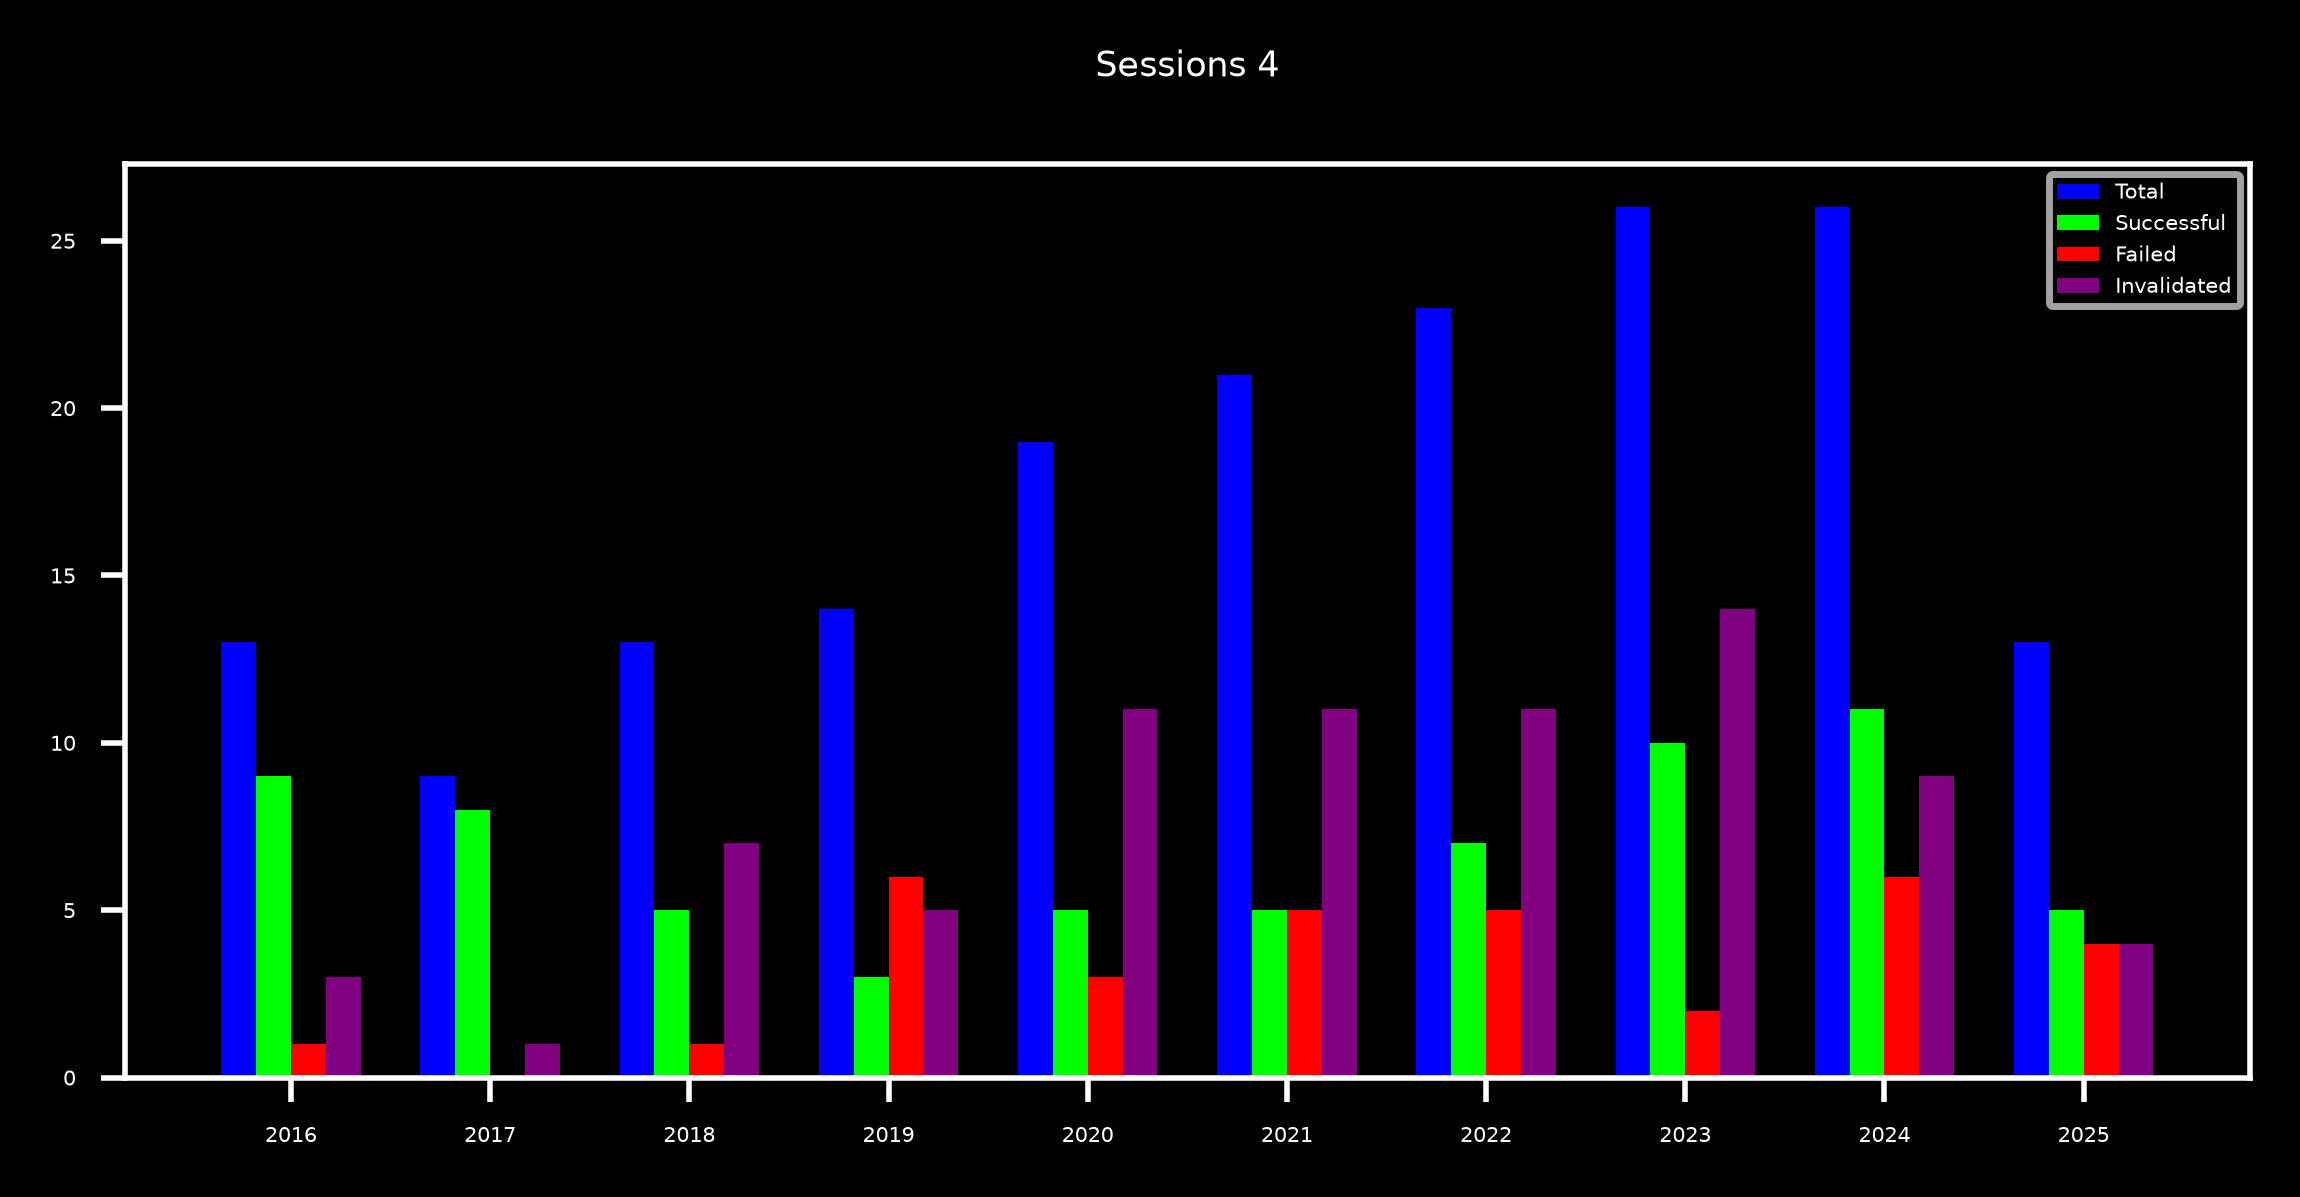

Sessions 5
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  7   │  2   │  4  │  53  │  15  │  30  │ 4.07 │ 3.55 │ -2.… │ 1.7… │ -0.… │ 3.92 │ 5.93 │ -5.3% │ 0.3… │
│ 2017 │  9   │  6   │  1   │  2  │  66  │  11  │  22  │ 4.8  │ 9.56 │ -5.… │ 1.4… │ -0.… │ 7.08 │ 7.96 │ -7.8… │ 0.2… │
│ 2018 │  13  │  3   │  2   │  8  │  23  │  15  │  61  │ 5.78 │ 4.87 │ -9.7 │ 0.7… │ -1.… │ -8.… │ -6.… │ -58.… │ 0.0… │
│ 2019 │  14  │  3   │  4   │  7  │  21  │  28  │  50  │ 5.54 │ 4.23 │ -5.… │ 0.6… │ -0.… │ -3.… │ -4.5 │ -20.… │ 0.3… │
│ 2020 │  19  │  4   │  4   │ 11  │  21  │  21  │  57  │ 10.… │ 5.26 │ -4.… │ 1.1… │ -1.… │ 2.05 │ 3.07 │ -17.… │ 0.5… │
│ 2021 │  21  │  4   │  4   │ 13  │  19  │  19  │  61  │ 11.… │ 7.37 │ -8.… │ 1.1… │ -1.… │ -1.… │ -1.… │ -50.… │ 0.7… │
│ 2022 │  23  │  8   │  4   │ 11  │  34  │  17  │  47  │ 3.25 │ 5.37 │ -6.… │ 1.1x │ -1.… │ -2.… │ -2.0 │ -45.… │ 0.4… │
│ 2023 │  26  │  10  │  2   │ 14  │  38  │  7   │  53  │ 7.13 │ 5.29 │ -3.… │ 1.8x │ -1.… │ 2.92 │ 4.83 │ -20.… │ 0.3… │
│ 2024 │  26  │  9   │  8   │  9  │  34  │  30  │  34  │ 5.96 │ 3.96 │ -4.… │ 1.0… │ -1.… │ 0.8  │ 1.07 │ -23.… │ 0.7… │
│ 2025 │  13  │  4   │  4   │  5  │  30  │  30  │  38  │ 4.6  │ 3.59 │ -3.1 │ 1.2… │ -0.… │ 0.62 │ 0.88 │ -9.8% │ 0.8… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

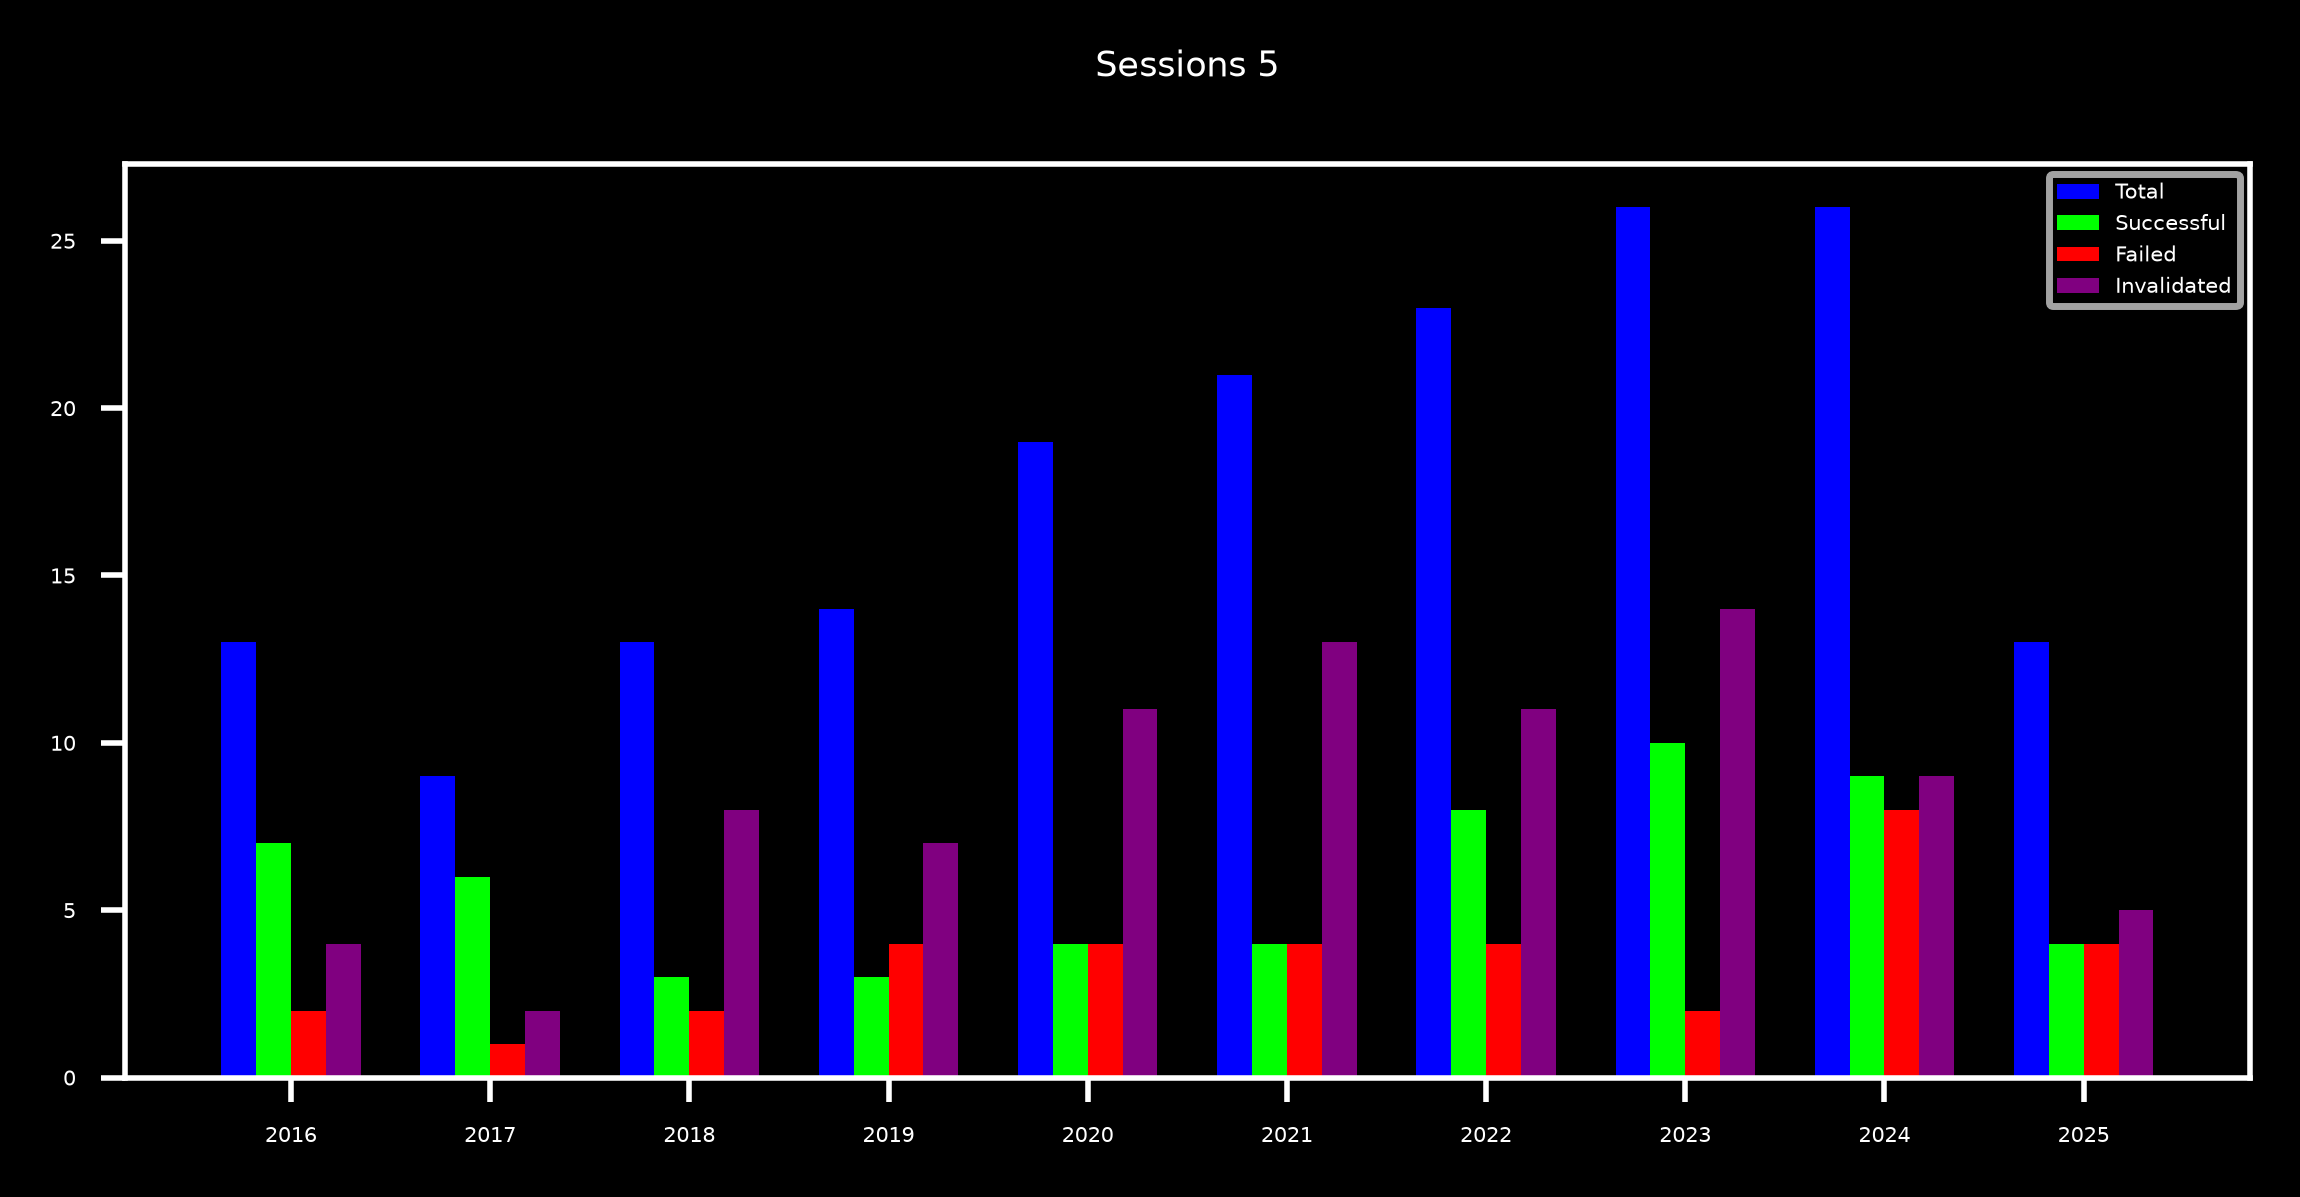

Sessions 6
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  7   │  0   │  6  │  53  │  0   │  46  │ 3.44 │ 4.02 │ -3.… │ 2.2… │ -1.… │ 5.05 │ 6.71 │ -4.3… │ 0.2… │
│ 2017 │  9   │  6   │  0   │  3  │  66  │  0   │  33  │ 5.29 │ 10.… │ -7.… │ 1.4… │ -1.… │ 14.… │ 19.… │ -3.1… │ 0.0… │
│ 2018 │  13  │  4   │  0   │  9  │  30  │  0   │  69  │ 3.08 │ 4.87 │ -11… │ 0.7… │ -2.… │ -9.… │ -6.… │ -64.… │ 0.0… │
│ 2019 │  14  │  3   │  4   │  7  │  21  │  28  │  50  │ 5.4  │ 4.23 │ -6.… │ 0.6… │ -1.… │ -0.… │ -0.… │ -16.… │ 0.9… │
│ 2020 │  19  │  5   │  2   │ 12  │  26  │  10  │  63  │ 8.22 │ 5.83 │ -5.… │ 1.2… │ -1.… │ 0.48 │ 0.52 │ -30.… │ 0.8… │
│ 2021 │  21  │  5   │  3   │ 13  │  23  │  14  │  61  │ 9.31 │ 7.64 │ -9.… │ 1.1… │ -1.… │ -1.… │ -1.… │ -47.… │ 0.7… │
│ 2022 │  23  │  8   │  4   │ 11  │  34  │  17  │  47  │ 3.72 │ 5.87 │ -6.… │ 1.2… │ -1.… │ -1.7 │ -1.… │ -40.… │ 0.6… │
│ 2023 │  26  │  10  │  2   │ 14  │  38  │  7   │  53  │ 10.0 │ 6.16 │ -3.… │ 2.1… │ -1.… │ 4.69 │ 10.… │ -18.… │ 0.1… │
│ 2024 │  26  │  9   │  7   │ 10  │  34  │  26  │  38  │ 5.99 │ 4.31 │ -5.1 │ 1.1… │ -1.… │ 0.16 │ 0.19 │ -32.… │ 0.9… │
│ 2025 │  13  │  5   │  2   │  6  │  38  │  15  │  46  │ 3.32 │ 3.65 │ -3.… │ 1.2… │ -1.… │ 1.59 │ 2.5  │ -11.… │ 0.7… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

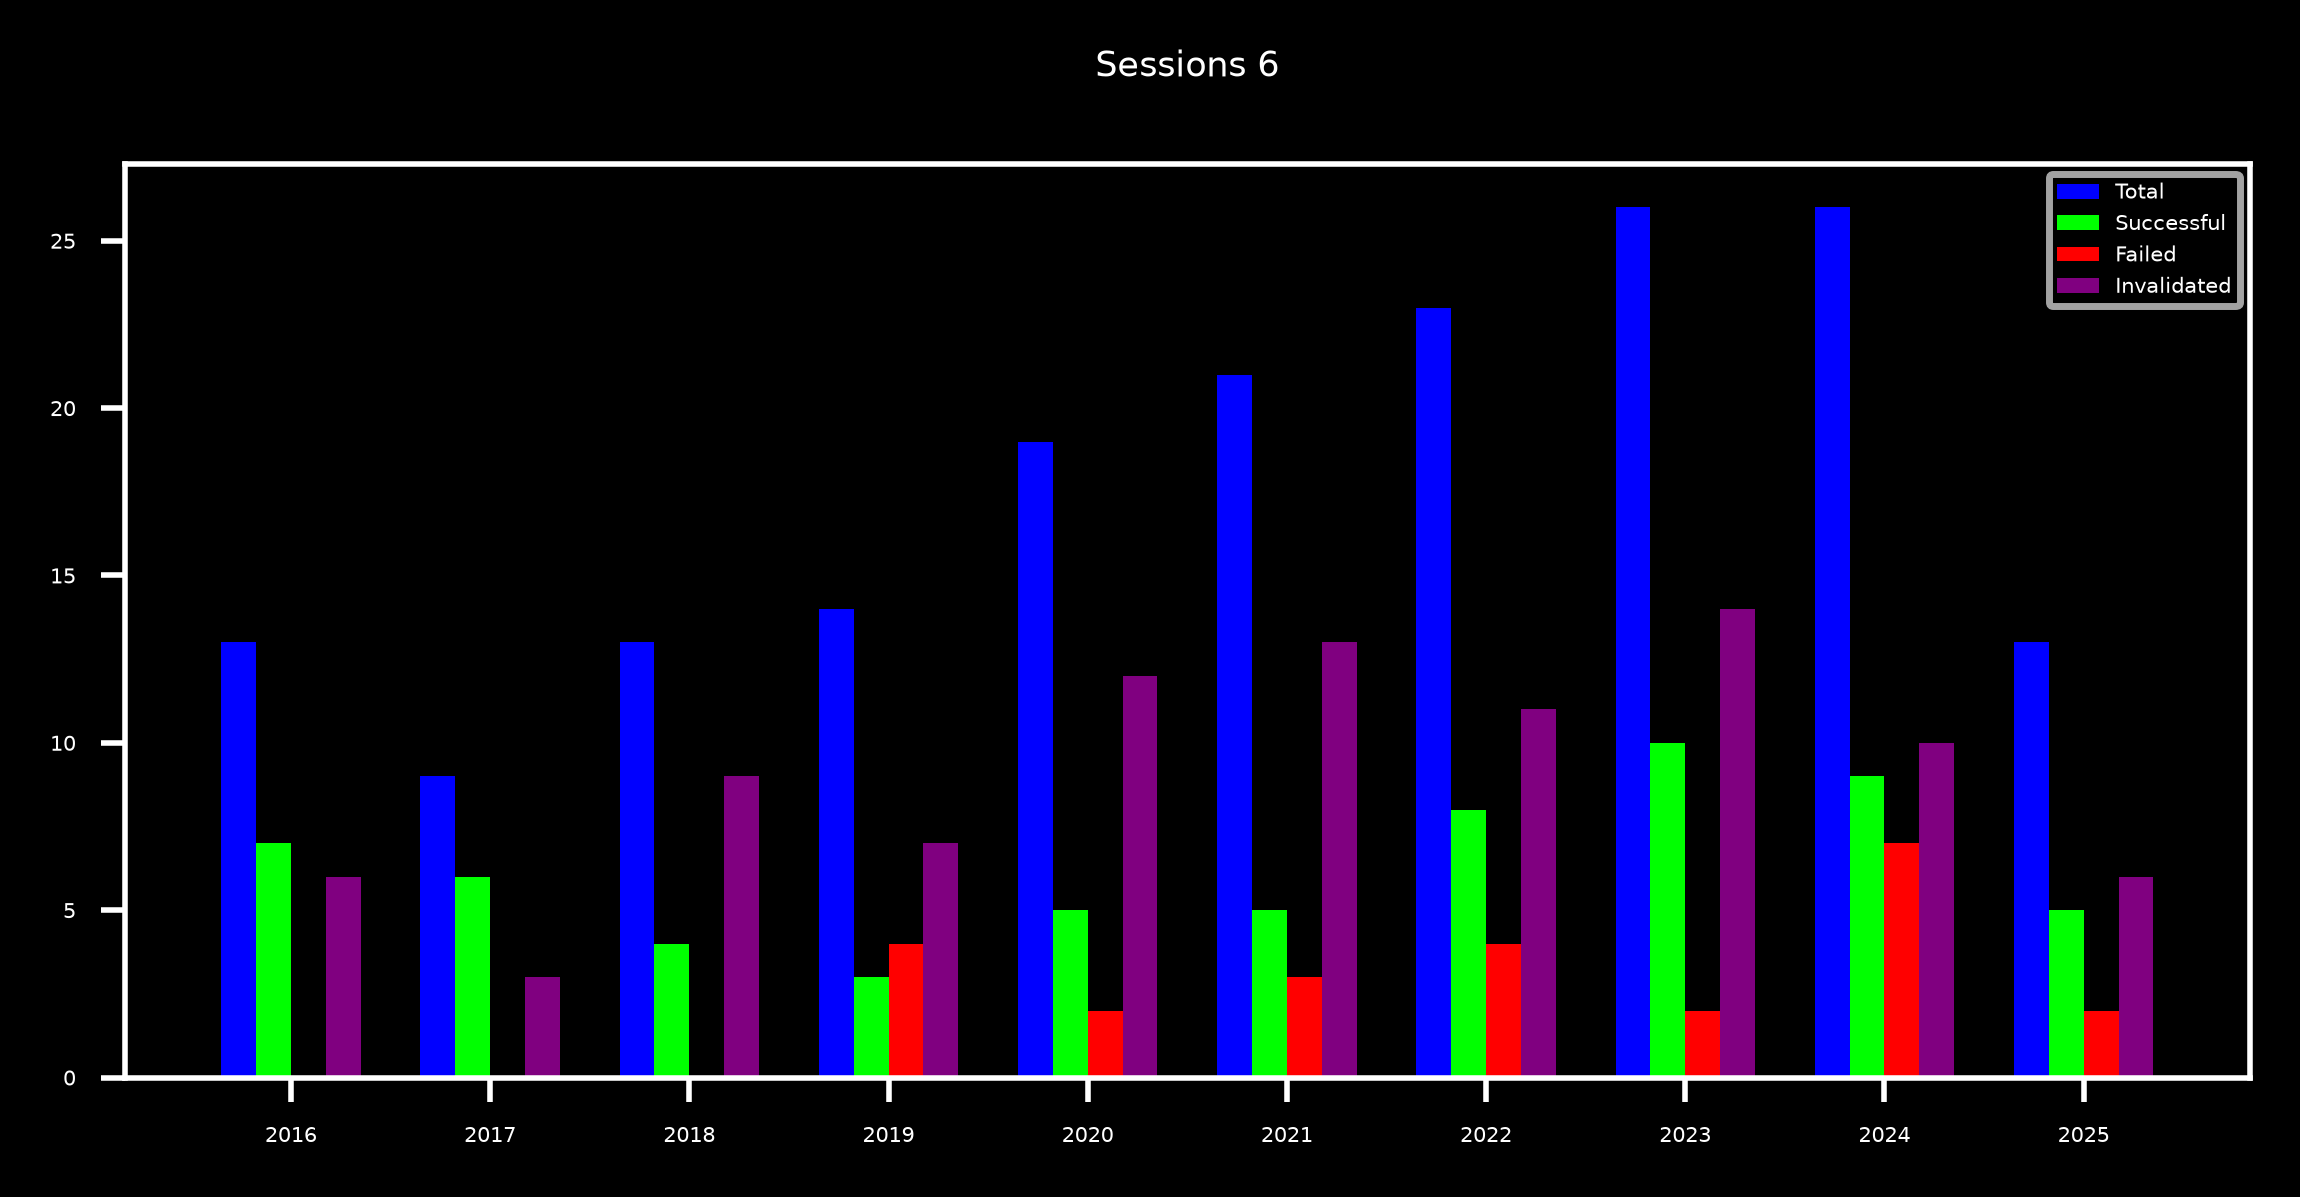

Sessions 7
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  6   │  0   │  7  │  46  │  0   │  53  │ 3.28 │ 4.03 │ -3.… │ 2.2… │ -1.… │ 1.98 │ 2.3  │ -7.8… │ 0.6… │
│ 2017 │  9   │  6   │  0   │  3  │  66  │  0   │  33  │ 6.59 │ 10.… │ -7.… │ 1.5x │ -1.… │ 10.… │ 10.… │ -5.2… │ 0.0… │
│ 2018 │  13  │  3   │  1   │  9  │  23  │  7   │  69  │ 3.51 │ 5.21 │ -12… │ 0.7… │ -2.… │ -10… │ -7.… │ -62.… │ 0.0… │
│ 2019 │  14  │  5   │  2   │  7  │  35  │  14  │  50  │ 4.68 │ 5.15 │ -6.… │ 0.8… │ -1.… │ 0.6  │ 0.59 │ -16.… │ 0.8… │
│ 2020 │  19  │  5   │  2   │ 12  │  26  │  10  │  63  │ 8.75 │ 6.5  │ -5.… │ 1.4… │ -1.… │ 3.12 │ 3.45 │ -18.… │ 0.4… │
│ 2021 │  21  │  4   │  1   │ 16  │  19  │  4   │  76  │ 10.… │ 7.95 │ -10… │ 1.2… │ -1.… │ -1.… │ -1.… │ -47.… │ 0.7… │
│ 2022 │  23  │  6   │  6   │ 11  │  26  │  26  │  47  │ 4.05 │ 6.01 │ -7.… │ 1.2… │ -1.… │ -3.… │ -3.… │ -55.… │ 0.2… │
│ 2023 │  26  │  10  │  1   │ 15  │  38  │  3   │  57  │ 10.… │ 6.55 │ -3.… │ 2.3… │ -1.… │ 5.6  │ 14.… │ -14.… │ 0.0… │
│ 2024 │  26  │  10  │  5   │ 11  │  38  │  19  │  42  │ 5.62 │ 4.75 │ -5.… │ 1.2… │ -1.… │ 1.48 │ 2.08 │ -19.… │ 0.6… │
│ 2025 │  13  │  6   │  1   │  6  │  46  │  7   │  46  │ 3.23 │ 3.99 │ -3.… │ 1.4x │ -1.… │ 1.29 │ 1.42 │ -15.… │ 0.7… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

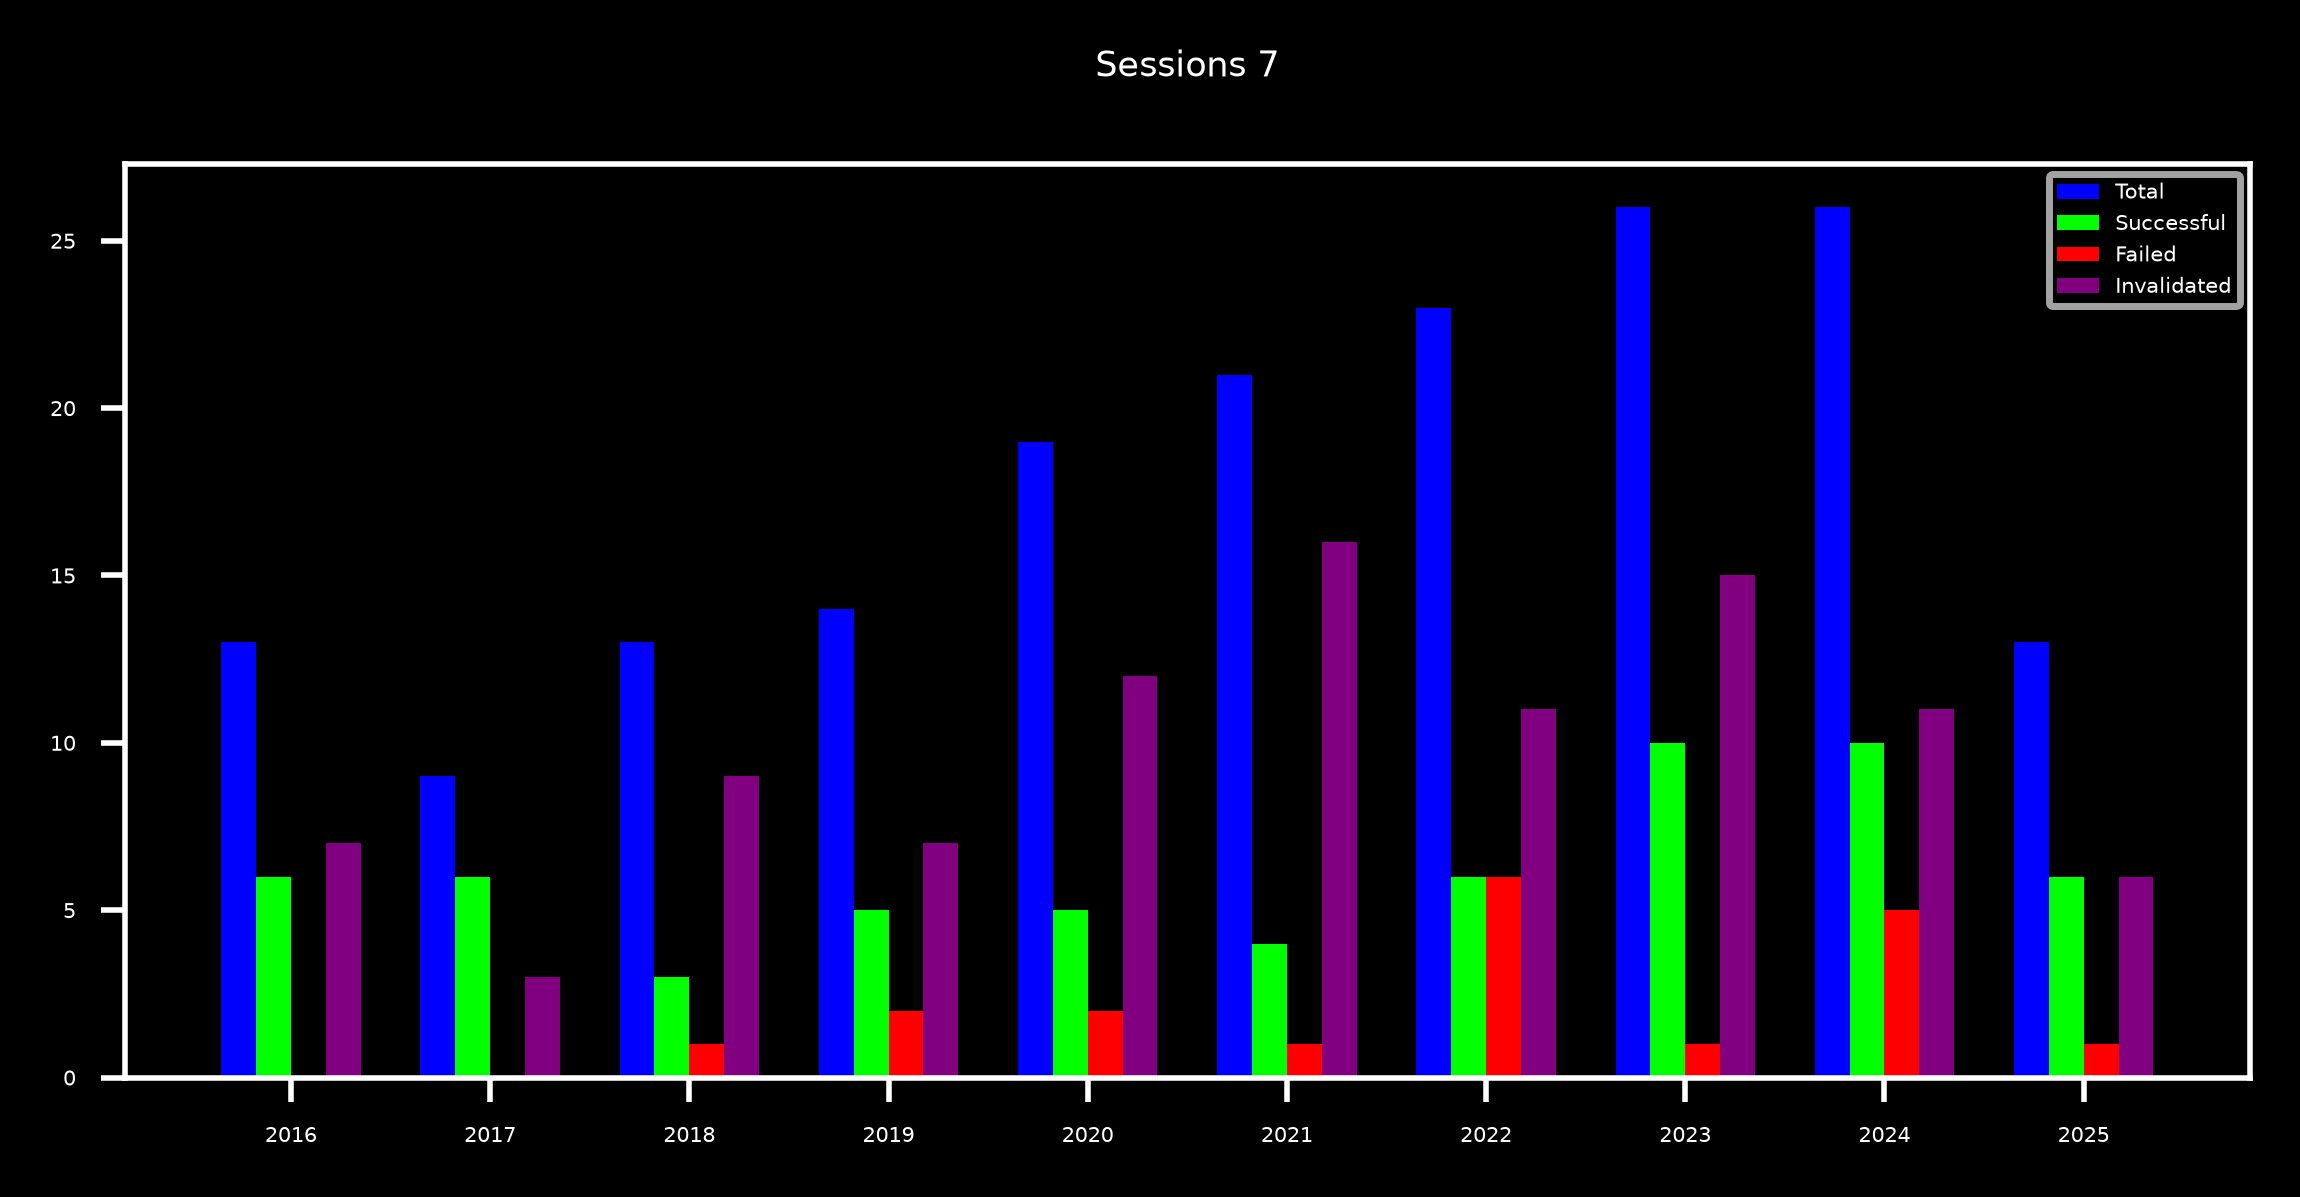

Sessions 8
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  6   │  0   │  7  │  46  │  0   │  53  │ 2.83 │ 4.44 │ -5.… │ 2.5… │ -1.… │ -1.… │ -0.… │ -8.0… │ 0.7… │
│ 2017 │  9   │  6   │  0   │  3  │  66  │  0   │  33  │ 7.66 │ 13.… │ -7.… │ 2.1x │ -1.… │ 17.… │ 44.… │ 0.0%  │ 0.0… │
│ 2018 │  13  │  4   │  0   │  9  │  30  │  0   │  69  │ 3.85 │ 5.27 │ -13… │ 0.7… │ -2.… │ -9.… │ -6.… │ -66.… │ 0.0… │
│ 2019 │  14  │  4   │  2   │  8  │  28  │  14  │  57  │ 6.25 │ 5.63 │ -7.… │ 0.8… │ -1.… │ -0.… │ -0.… │ -24.… │ 0.9… │
│ 2020 │  19  │  5   │  2   │ 12  │  26  │  10  │  63  │ 10.… │ 6.66 │ -5.… │ 1.4… │ -1.… │ 3.74 │ 5.3  │ -16.… │ 0.3… │
│ 2021 │  21  │  4   │  0   │ 17  │  19  │  0   │  80  │ 11.… │ 8.56 │ -11… │ 1.3… │ -1.… │ -1.… │ -1.… │ -48.… │ 0.7… │
│ 2022 │  23  │  5   │  4   │ 14  │  21  │  17  │  60  │ 4.67 │ 6.16 │ -8.3 │ 1.2… │ -1.… │ -5.1 │ -4.… │ -60.… │ 0.1… │
│ 2023 │  26  │  10  │  1   │ 15  │  38  │  3   │  57  │ 10.… │ 7.58 │ -4.… │ 2.7… │ -1.… │ 6.04 │ 11.… │ -19.… │ 0.0… │
│ 2024 │  26  │  10  │  5   │ 11  │  38  │  19  │  42  │ 5.83 │ 5.46 │ -5.… │ 1.4… │ -1.… │ 1.82 │ 2.37 │ -17.… │ 0.5… │
│ 2025 │  12  │  4   │  2   │  6  │  33  │  16  │  50  │ 5.27 │ 4.5  │ -3.6 │ 1.6… │ -1.… │ 2.76 │ 3.34 │ -13.… │ 0.5… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

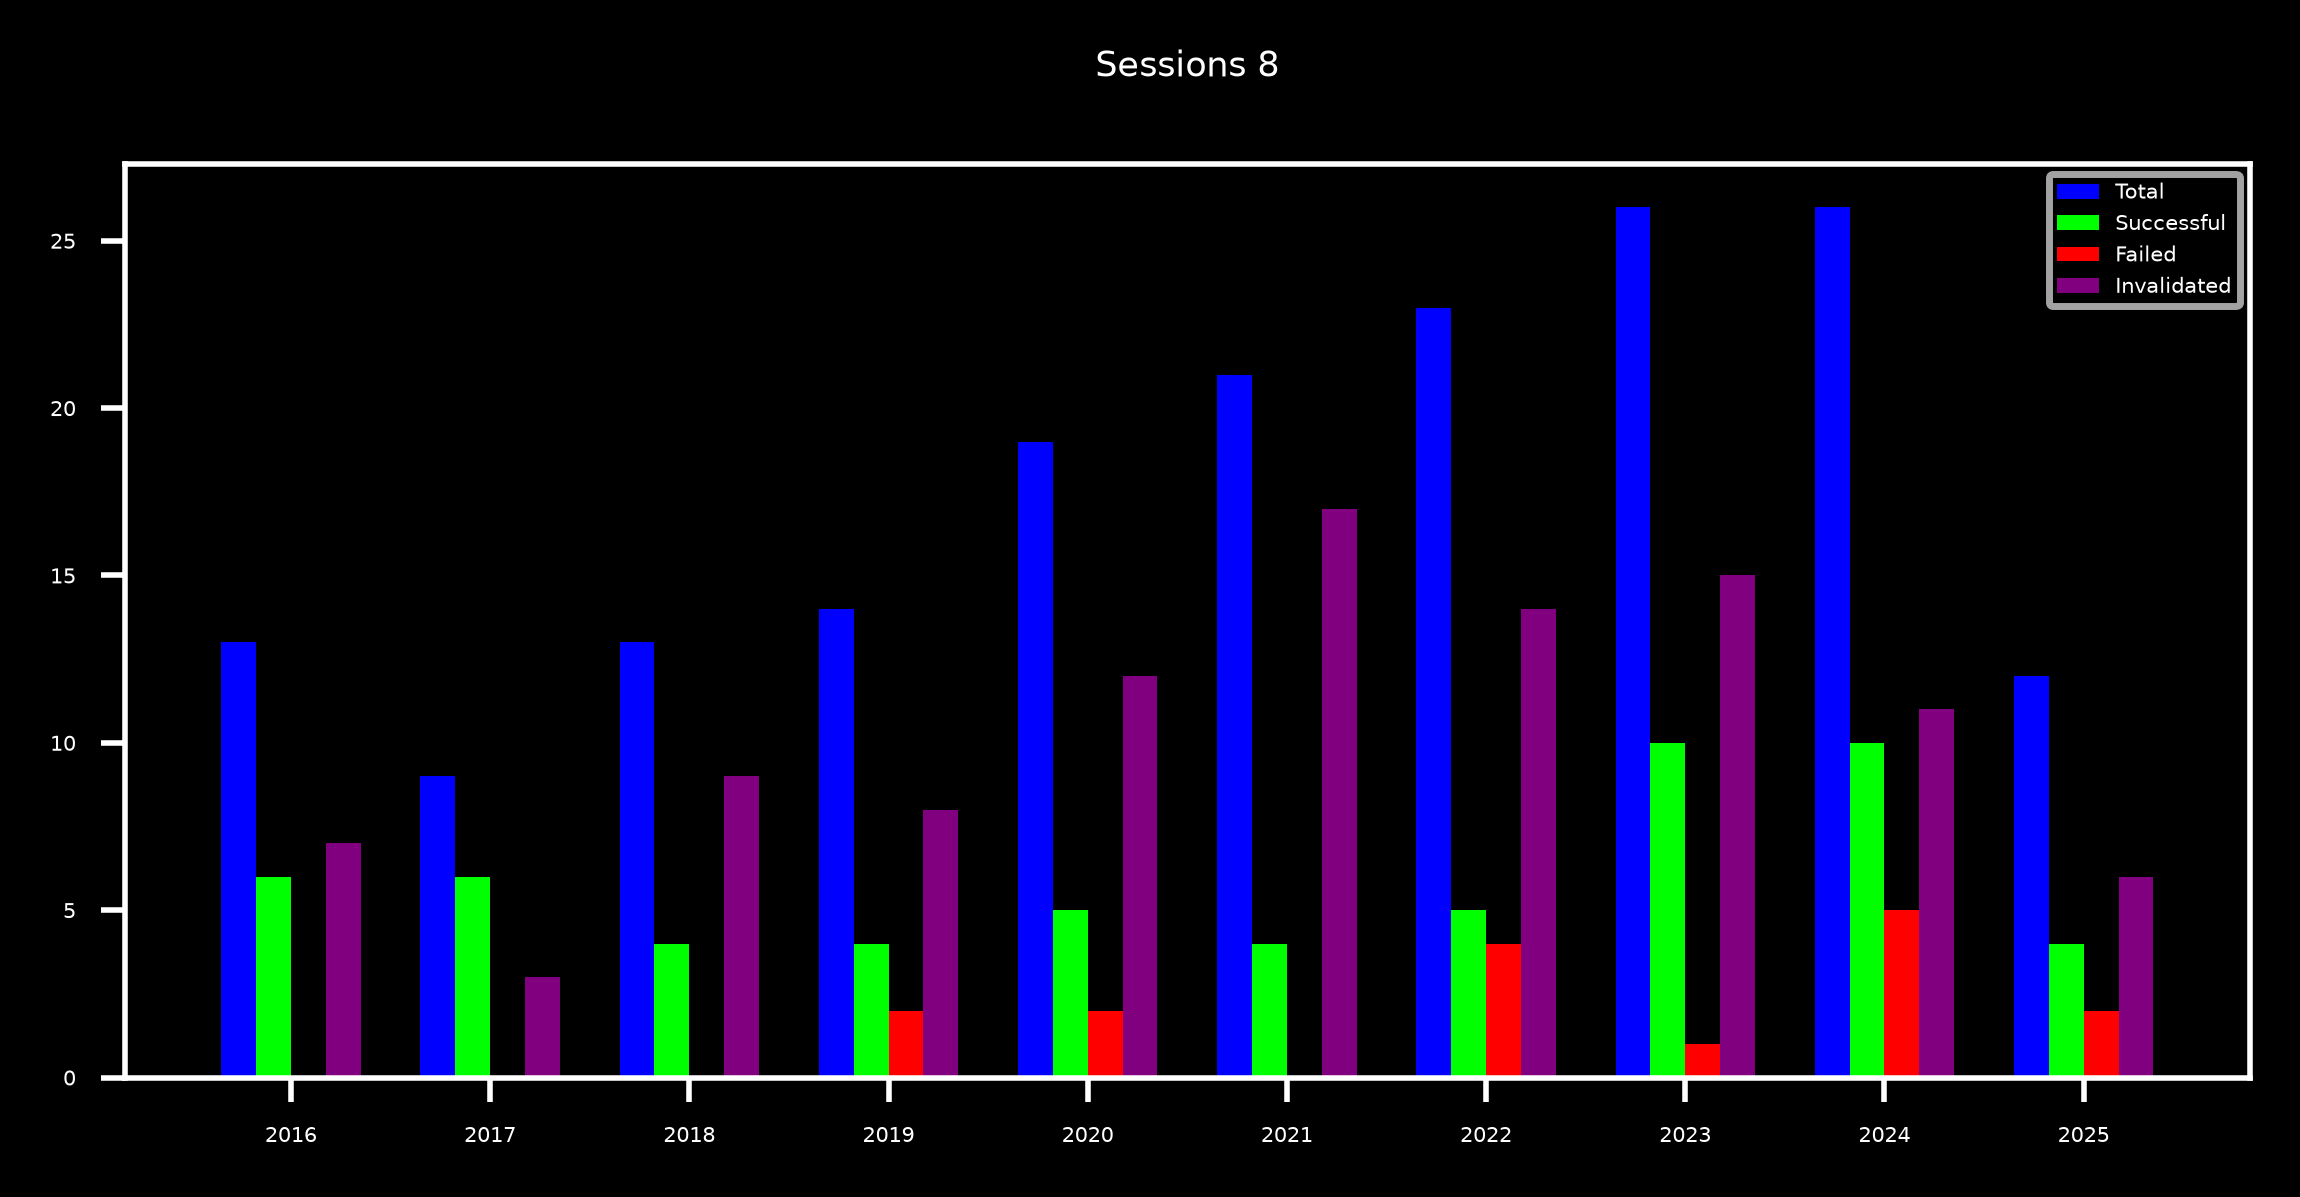

Sessions 9
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  6   │  0   │  7  │  46  │  0   │  53  │ 3.17 │ 4.67 │ -5.… │ 2.6… │ -1.… │ 0.52 │ 0.42 │ -6.4… │ 0.9… │
│ 2017 │  9   │  6   │  0   │  3  │  66  │  0   │  33  │ 11.… │ 16.… │ -8.… │ 2.4… │ -1.… │ 14.… │ 13.… │ 0.0%  │ 0.0… │
│ 2018 │  13  │  3   │  0   │ 10  │  23  │  0   │  76  │ 4.98 │ 5.27 │ -14… │ 0.7… │ -2.… │ -9.… │ -7.… │ -71.… │ 0.0… │
│ 2019 │  14  │  6   │  0   │  8  │  42  │  0   │  57  │ 6.42 │ 7.18 │ -7.… │ 1.2x │ -1.… │ 1.94 │ 2.47 │ -21.… │ 0.6… │
│ 2020 │  19  │  6   │  1   │ 12  │  31  │  5   │  63  │ 10.… │ 7.17 │ -5.… │ 1.5… │ -1.… │ 3.94 │ 5.7  │ -18.… │ 0.2… │
│ 2021 │  21  │  4   │  0   │ 17  │  19  │  0   │  80  │ 13.… │ 9.38 │ -12… │ 1.4… │ -2.… │ -0.… │ -0.… │ -53.… │ 0.8… │
│ 2022 │  23  │  5   │  3   │ 15  │  21  │  13  │  65  │ 4.02 │ 6.42 │ -8.… │ 1.3… │ -1.… │ -5.… │ -4.… │ -56.… │ 0.1… │
│ 2023 │  26  │  10  │  0   │ 16  │  38  │  0   │  61  │ 10.… │ 8.43 │ -4.… │ 3.0… │ -1.… │ 6.61 │ 12.… │ -18.… │ 0.0… │
│ 2024 │  26  │  11  │  3   │ 12  │  42  │  11  │  46  │ 7.24 │ 6.12 │ -5.… │ 1.6… │ -1.… │ 2.2  │ 3.12 │ -18.… │ 0.4… │
│ 2025 │  12  │  5   │  1   │  6  │  41  │  8   │  50  │ 5.08 │ 4.74 │ -3.… │ 1.7… │ -1.… │ 1.49 │ 1.52 │ -17.… │ 0.7… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

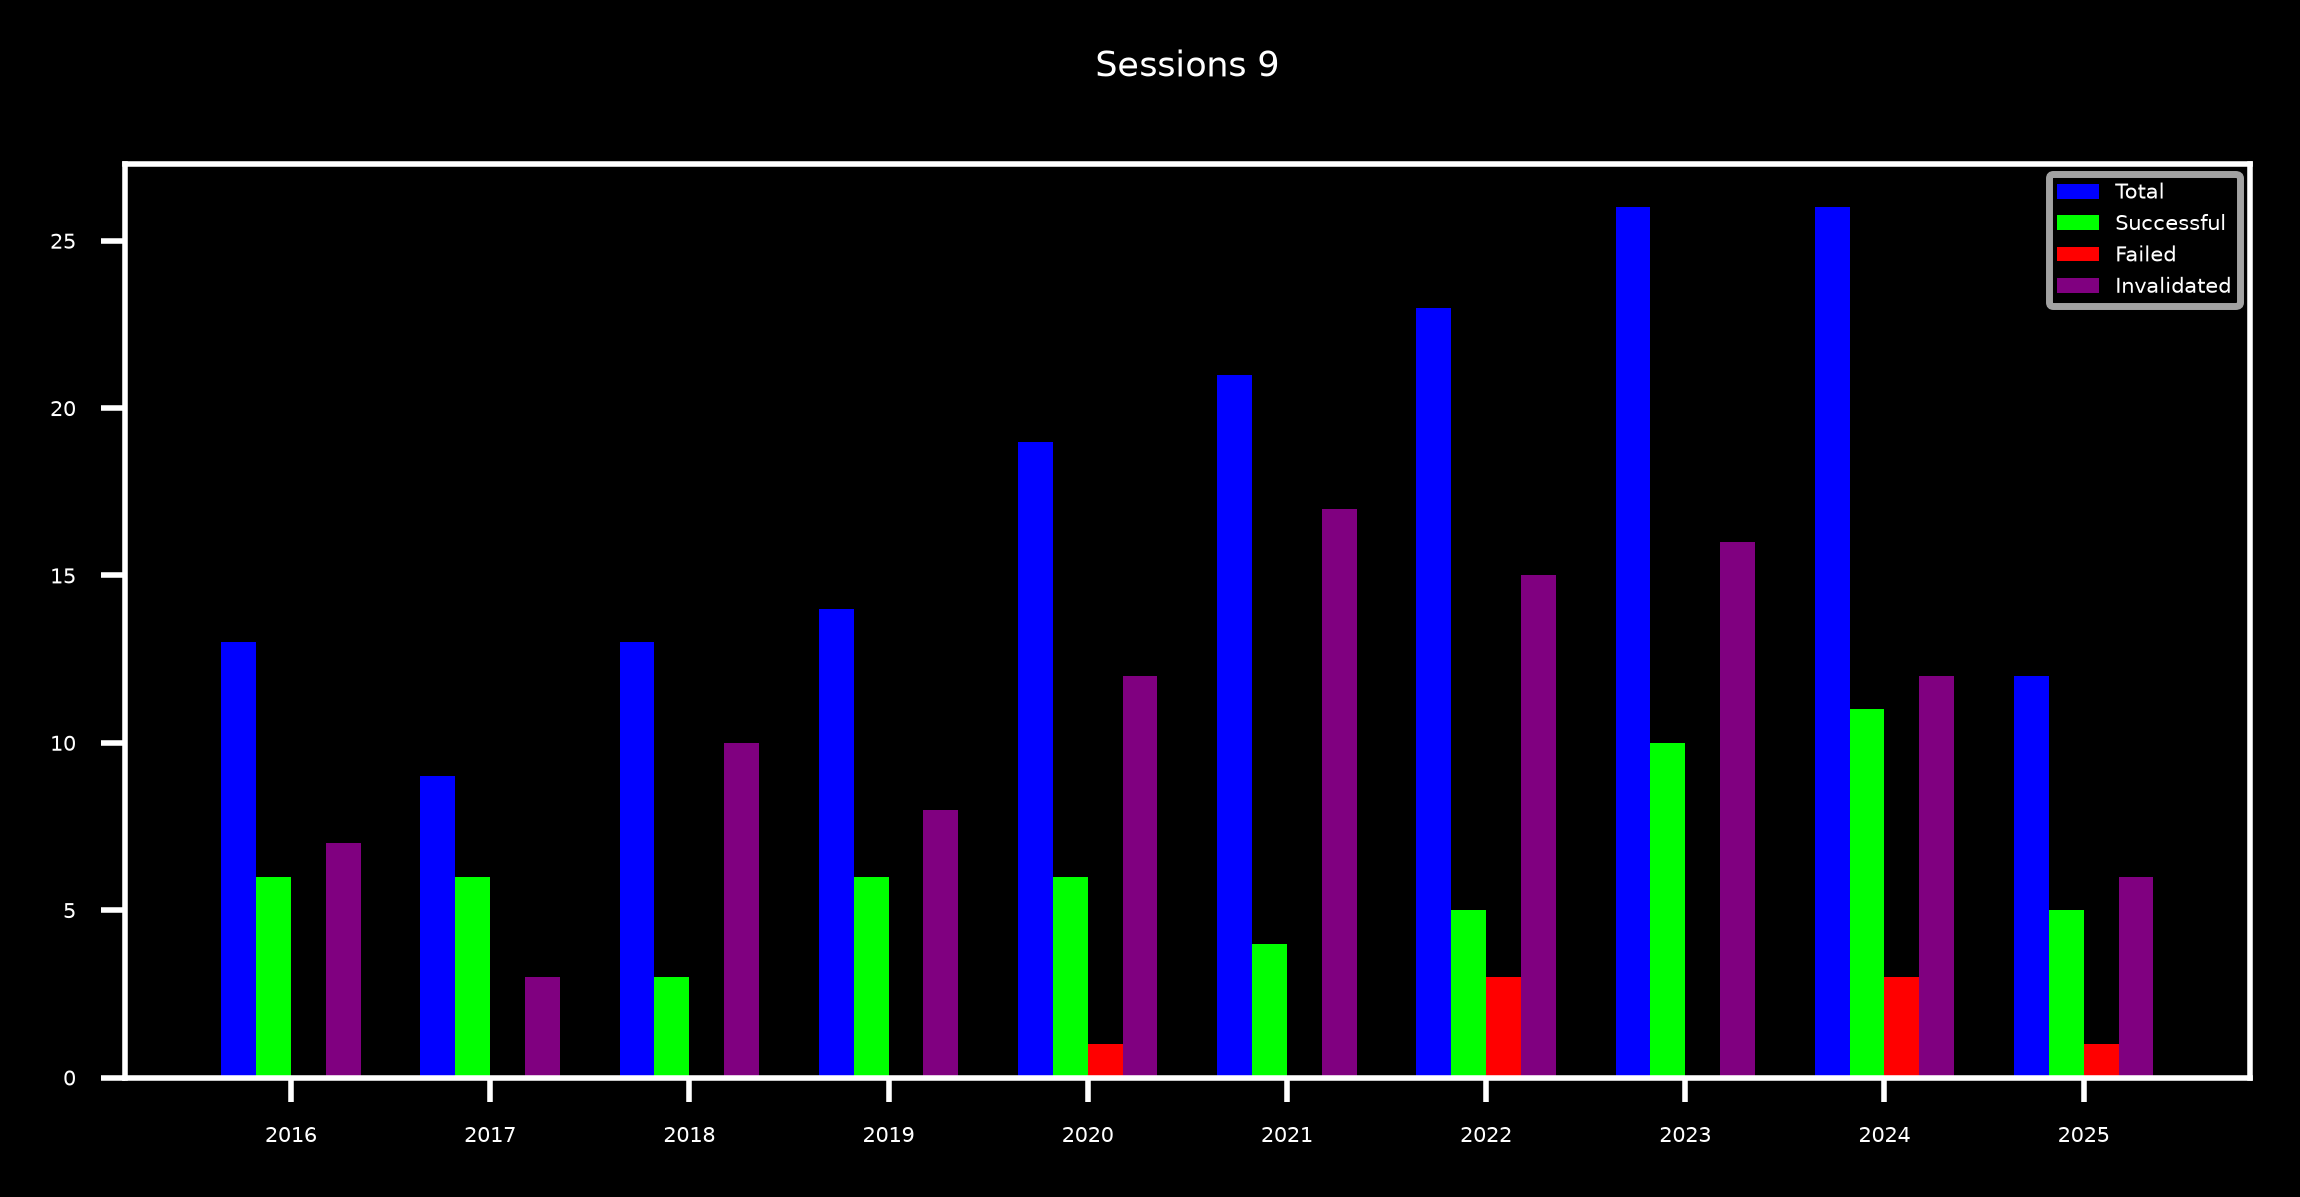

Sessions 10
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  6   │  0   │  7  │  46  │  0   │  53  │ 3.64 │ 4.89 │ -5.… │ 2.7… │ -1.… │ 1.57 │ 1.38 │ -6.3… │ 0.7… │
│ 2017 │  9   │  6   │  0   │  3  │  66  │  0   │  33  │ 14.… │ 17.… │ -8.… │ 2.6… │ -1.… │ 25.… │ 58.… │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 7.46 │ 5.3  │ -15… │ 0.8x │ -2.… │ -9.… │ -7.… │ -64.… │ 0.0… │
│ 2019 │  14  │  6   │  0   │  8  │  42  │  0   │  57  │ 8.66 │ 8.62 │ -7.… │ 1.5… │ -1.… │ 2.69 │ 2.99 │ -26.… │ 0.5… │
│ 2020 │  19  │  6   │  1   │ 12  │  31  │  5   │  63  │ 13.… │ 8.37 │ -7.9 │ 1.7… │ -1.… │ 1.5  │ 1.44 │ -46.… │ 0.6… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 17.… │ 9.84 │ -13… │ 1.5… │ -2.… │ -1.… │ -1.… │ -48.… │ 0.7… │
│ 2022 │  23  │  4   │  3   │ 16  │  17  │  13  │  69  │ 5.33 │ 6.56 │ -9.… │ 1.3… │ -1.… │ -6.… │ -5.… │ -56.… │ 0.0… │
│ 2023 │  26  │  10  │  0   │ 16  │  38  │  0   │  61  │ 11.… │ 8.88 │ -4.… │ 3.1… │ -1.… │ 7.09 │ 13.… │ -17.… │ 0.0… │
│ 2024 │  26  │  11  │  3   │ 12  │  42  │  11  │  46  │ 5.88 │ 6.42 │ -5.… │ 1.7… │ -1.… │ 2.45 │ 3.04 │ -13.… │ 0.4… │
│ 2025 │  12  │  5   │  1   │  6  │  41  │  8   │  50  │ 6.25 │ 5.54 │ -3.… │ 2.0x │ -1.… │ 5.99 │ 8.67 │ -12.… │ 0.2… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

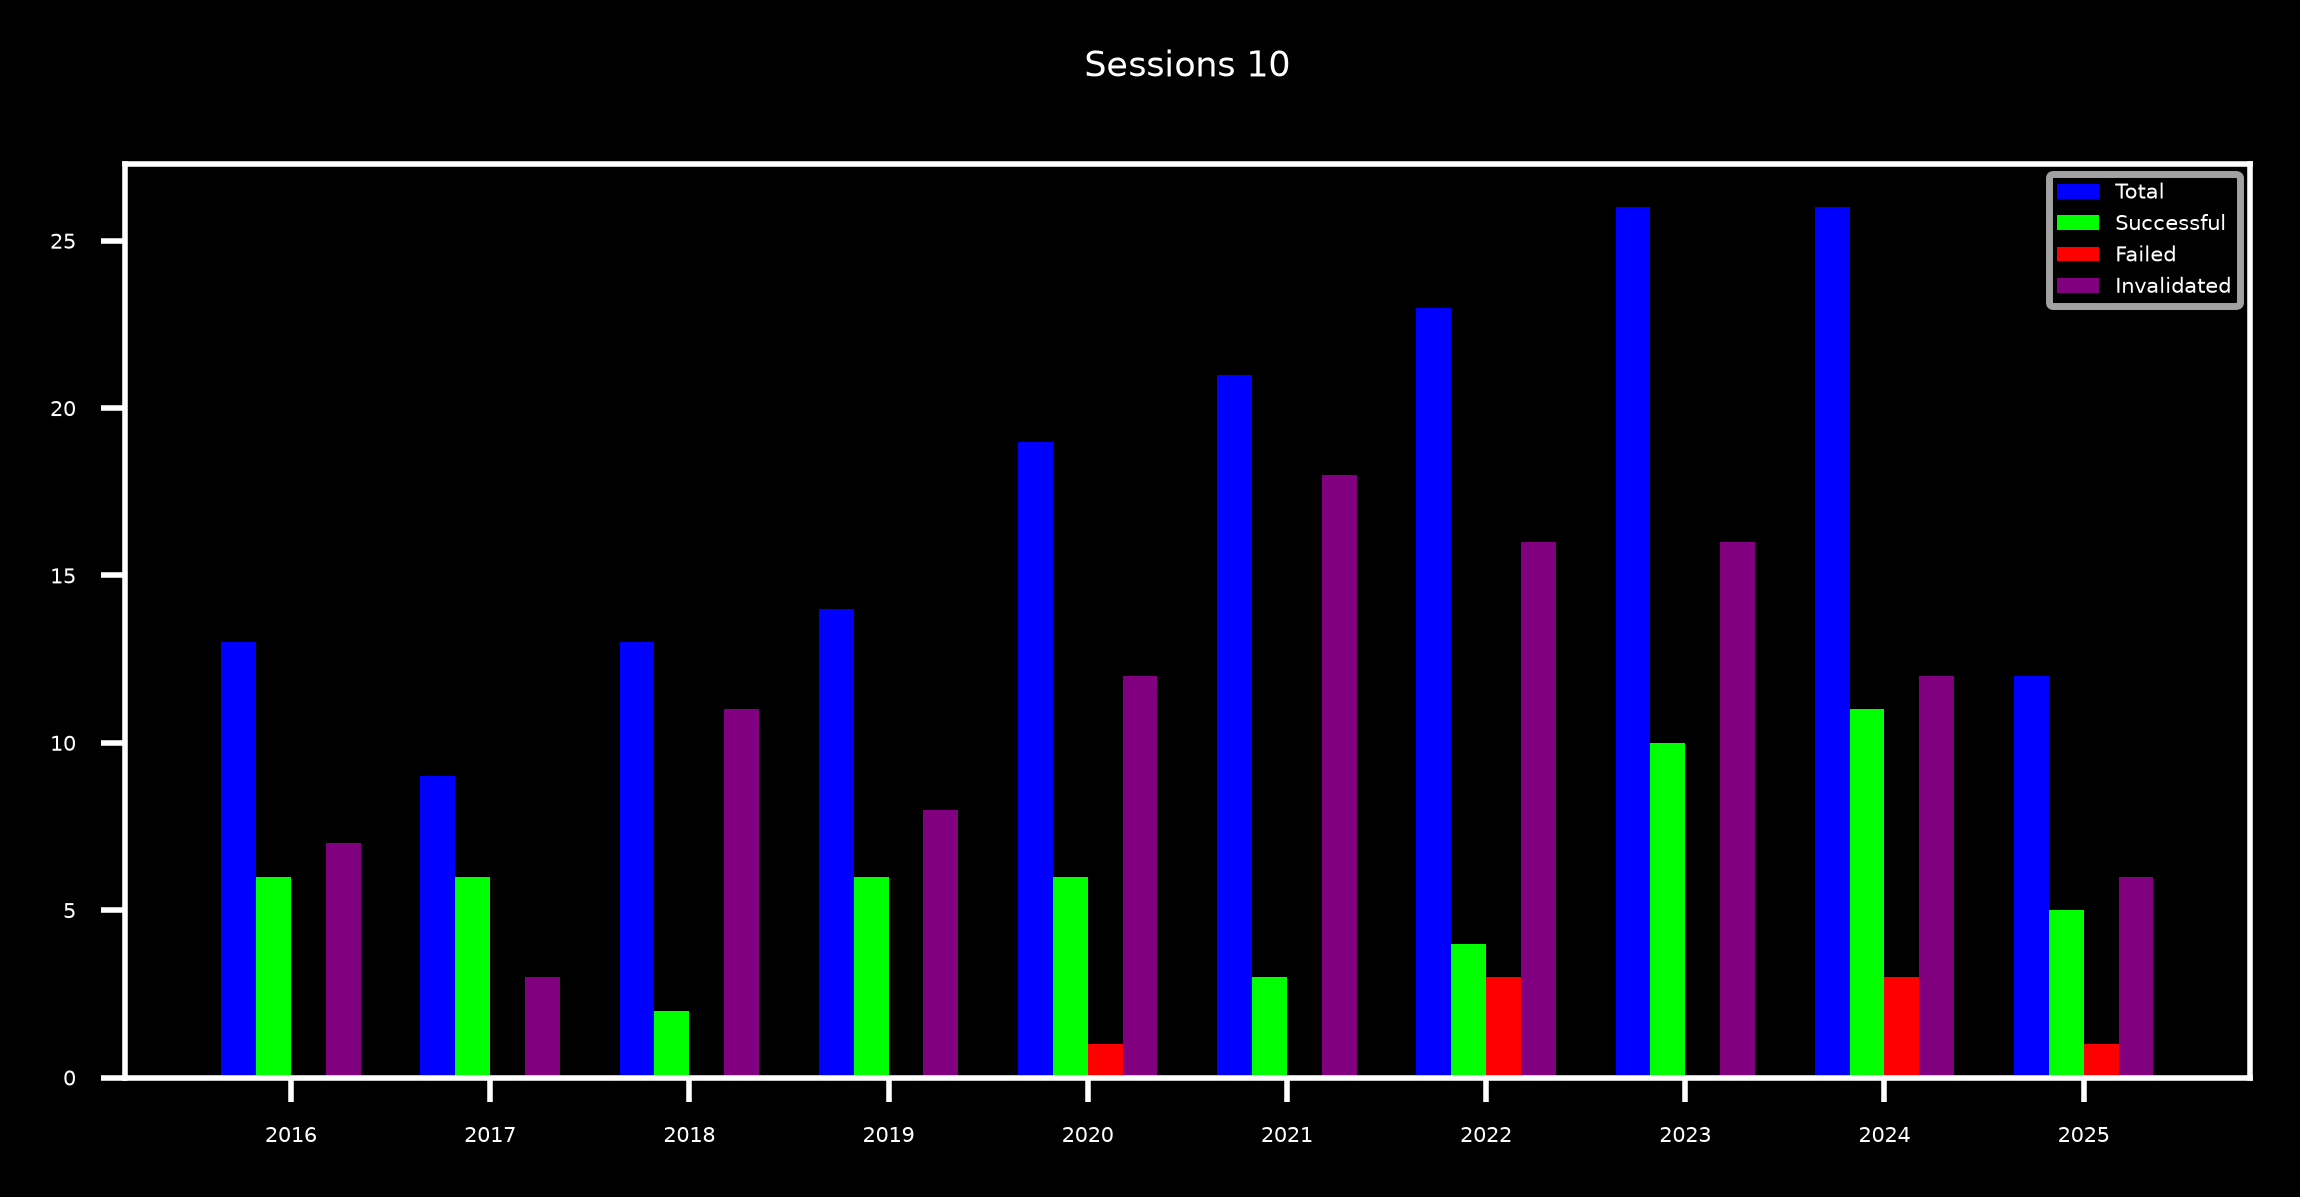

Sessions 11
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  6   │  0   │  7  │  46  │  0   │  53  │ 3.5  │ 6.01 │ -5.… │ 3.0… │ -1.… │ 3.05 │ 3.73 │ -6.5… │ 0.5… │
│ 2017 │  9   │  6   │  0   │  3  │  66  │  0   │  33  │ 16.0 │ 19.… │ -8.… │ 2.8… │ -1.… │ 27.… │ 0.0  │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 4.33 │ 5.32 │ -15… │ 0.8… │ -2.… │ -9.… │ -7.… │ -64.… │ 0.0… │
│ 2019 │  14  │  6   │  0   │  8  │  42  │  0   │  57  │ 8.95 │ 10.… │ -8.… │ 1.8x │ -1.… │ 5.95 │ 8.51 │ -19.… │ 0.1… │
│ 2020 │  19  │  6   │  1   │ 12  │  31  │  5   │  63  │ 15.… │ 9.81 │ -8.… │ 2.0… │ -1.… │ 3.04 │ 3.32 │ -36.… │ 0.4… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 14.9 │ 10.4 │ -13… │ 1.5… │ -2.… │ -1.… │ -1.… │ -47.… │ 0.7… │
│ 2022 │  23  │  5   │  2   │ 16  │  21  │  8   │  69  │ 4.48 │ 6.78 │ -9.… │ 1.4… │ -2.… │ -6.… │ -5.… │ -55.… │ 0.0… │
│ 2023 │  26  │  10  │  0   │ 16  │  38  │  0   │  61  │ 10.… │ 9.35 │ -4.… │ 3.2… │ -1.… │ 8.07 │ 17.… │ -15.… │ 0.0… │
│ 2024 │  26  │  9   │  5   │ 12  │  34  │  19  │  46  │ 7.2  │ 7.11 │ -5.… │ 1.9… │ -1.… │ 3.11 │ 5.0  │ -16.… │ 0.3… │
│ 2025 │  11  │  4   │  1   │  6  │  36  │  9   │  54  │ 5.78 │ 5.63 │ -4.… │ 2.1… │ -1.… │ 4.38 │ 6.18 │ -13.… │ 0.3… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

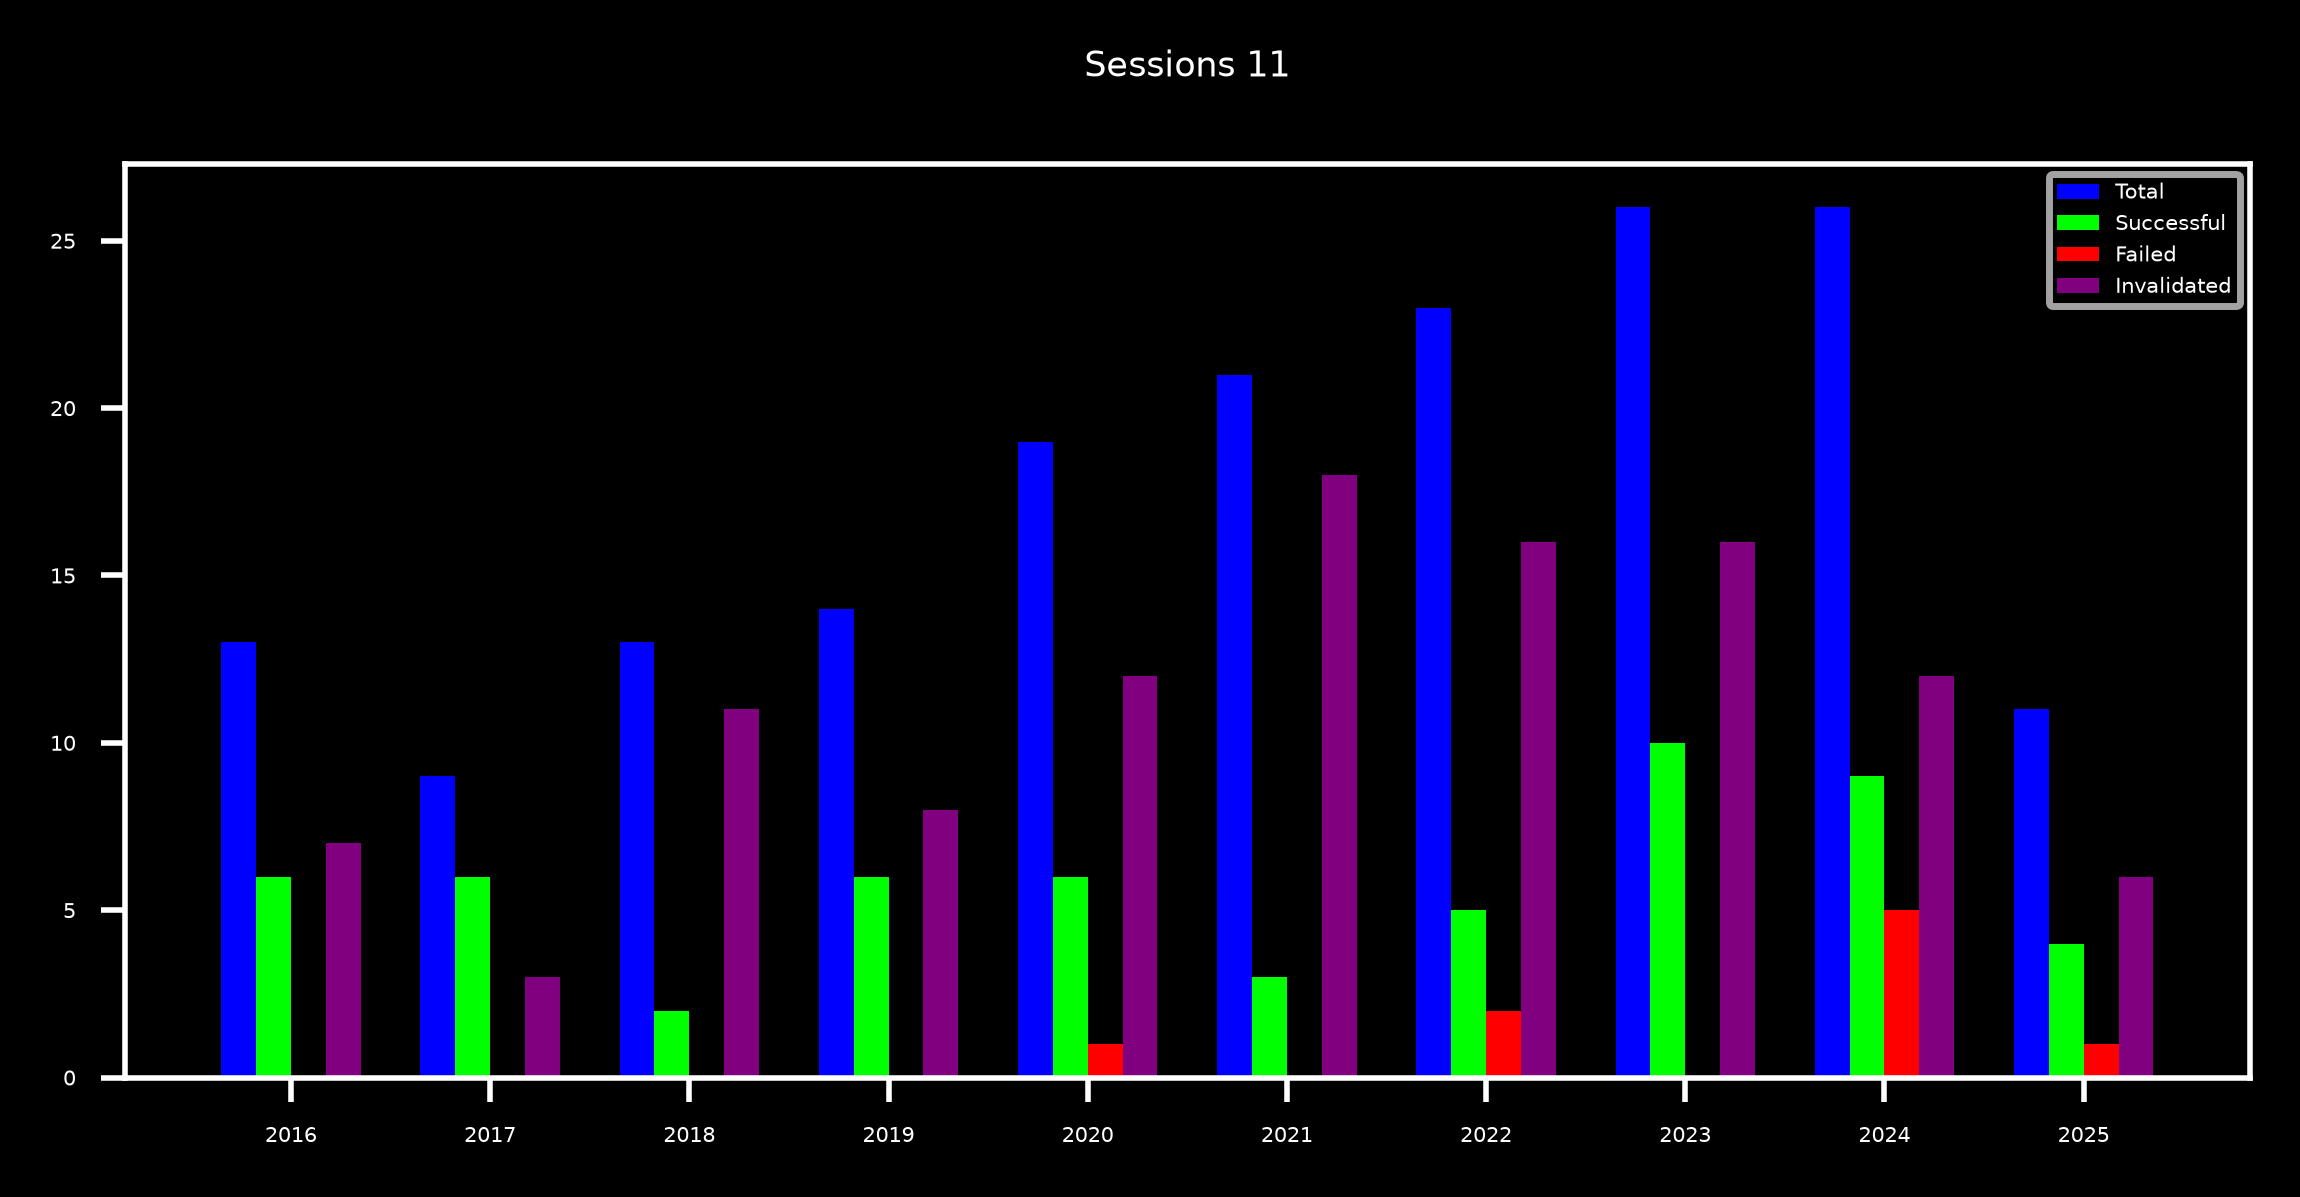

Sessions 12
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  6   │  0   │  7  │  46  │  0   │  53  │ 4.15 │ 6.84 │ -5.… │ 3.5… │ -1.… │ 3.93 │ 5.07 │ -4.3… │ 0.3… │
│ 2017 │  9   │  6   │  0   │  3  │  66  │  0   │  33  │ 17.… │ 20.… │ -8.… │ 2.9… │ -1.… │ 32.… │ 0.0  │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 6.64 │ 5.52 │ -15… │ 0.8… │ -2.… │ -8.… │ -6.… │ -61.… │ 0.0… │
│ 2019 │  14  │  6   │  0   │  8  │  42  │  0   │  57  │ 9.51 │ 11.… │ -8.… │ 2.2… │ -1.… │ 8.28 │ 22.… │ -8.3… │ 0.0… │
│ 2020 │  19  │  6   │  1   │ 12  │  31  │  5   │  63  │ 15.… │ 10.… │ -8.… │ 2.1… │ -1.… │ 2.79 │ 3.16 │ -42.… │ 0.4… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 15.… │ 11.… │ -14… │ 1.6… │ -2.… │ -2.… │ -2.… │ -55.… │ 0.4… │
│ 2022 │  23  │  4   │  3   │ 16  │  17  │  13  │  69  │ 5.94 │ 6.82 │ -9.… │ 1.4… │ -2.… │ -6.… │ -5.… │ -58.… │ 0.0… │
│ 2023 │  26  │  10  │  0   │ 16  │  38  │  0   │  61  │ 10.… │ 9.73 │ -4.… │ 3.3… │ -1.… │ 7.77 │ 19.… │ -17.… │ 0.0… │
│ 2024 │  26  │  11  │  3   │ 12  │  42  │  11  │  46  │ 6.56 │ 7.26 │ -6.… │ 2.0… │ -1.… │ 3.11 │ 5.01 │ -23.… │ 0.3… │
│ 2025 │  11  │  2   │  2   │  7  │  18  │  18  │  63  │ 6.79 │ 6.11 │ -4.… │ 2.3… │ -1.… │ 2.75 │ 4.04 │ -12.… │ 0.5… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

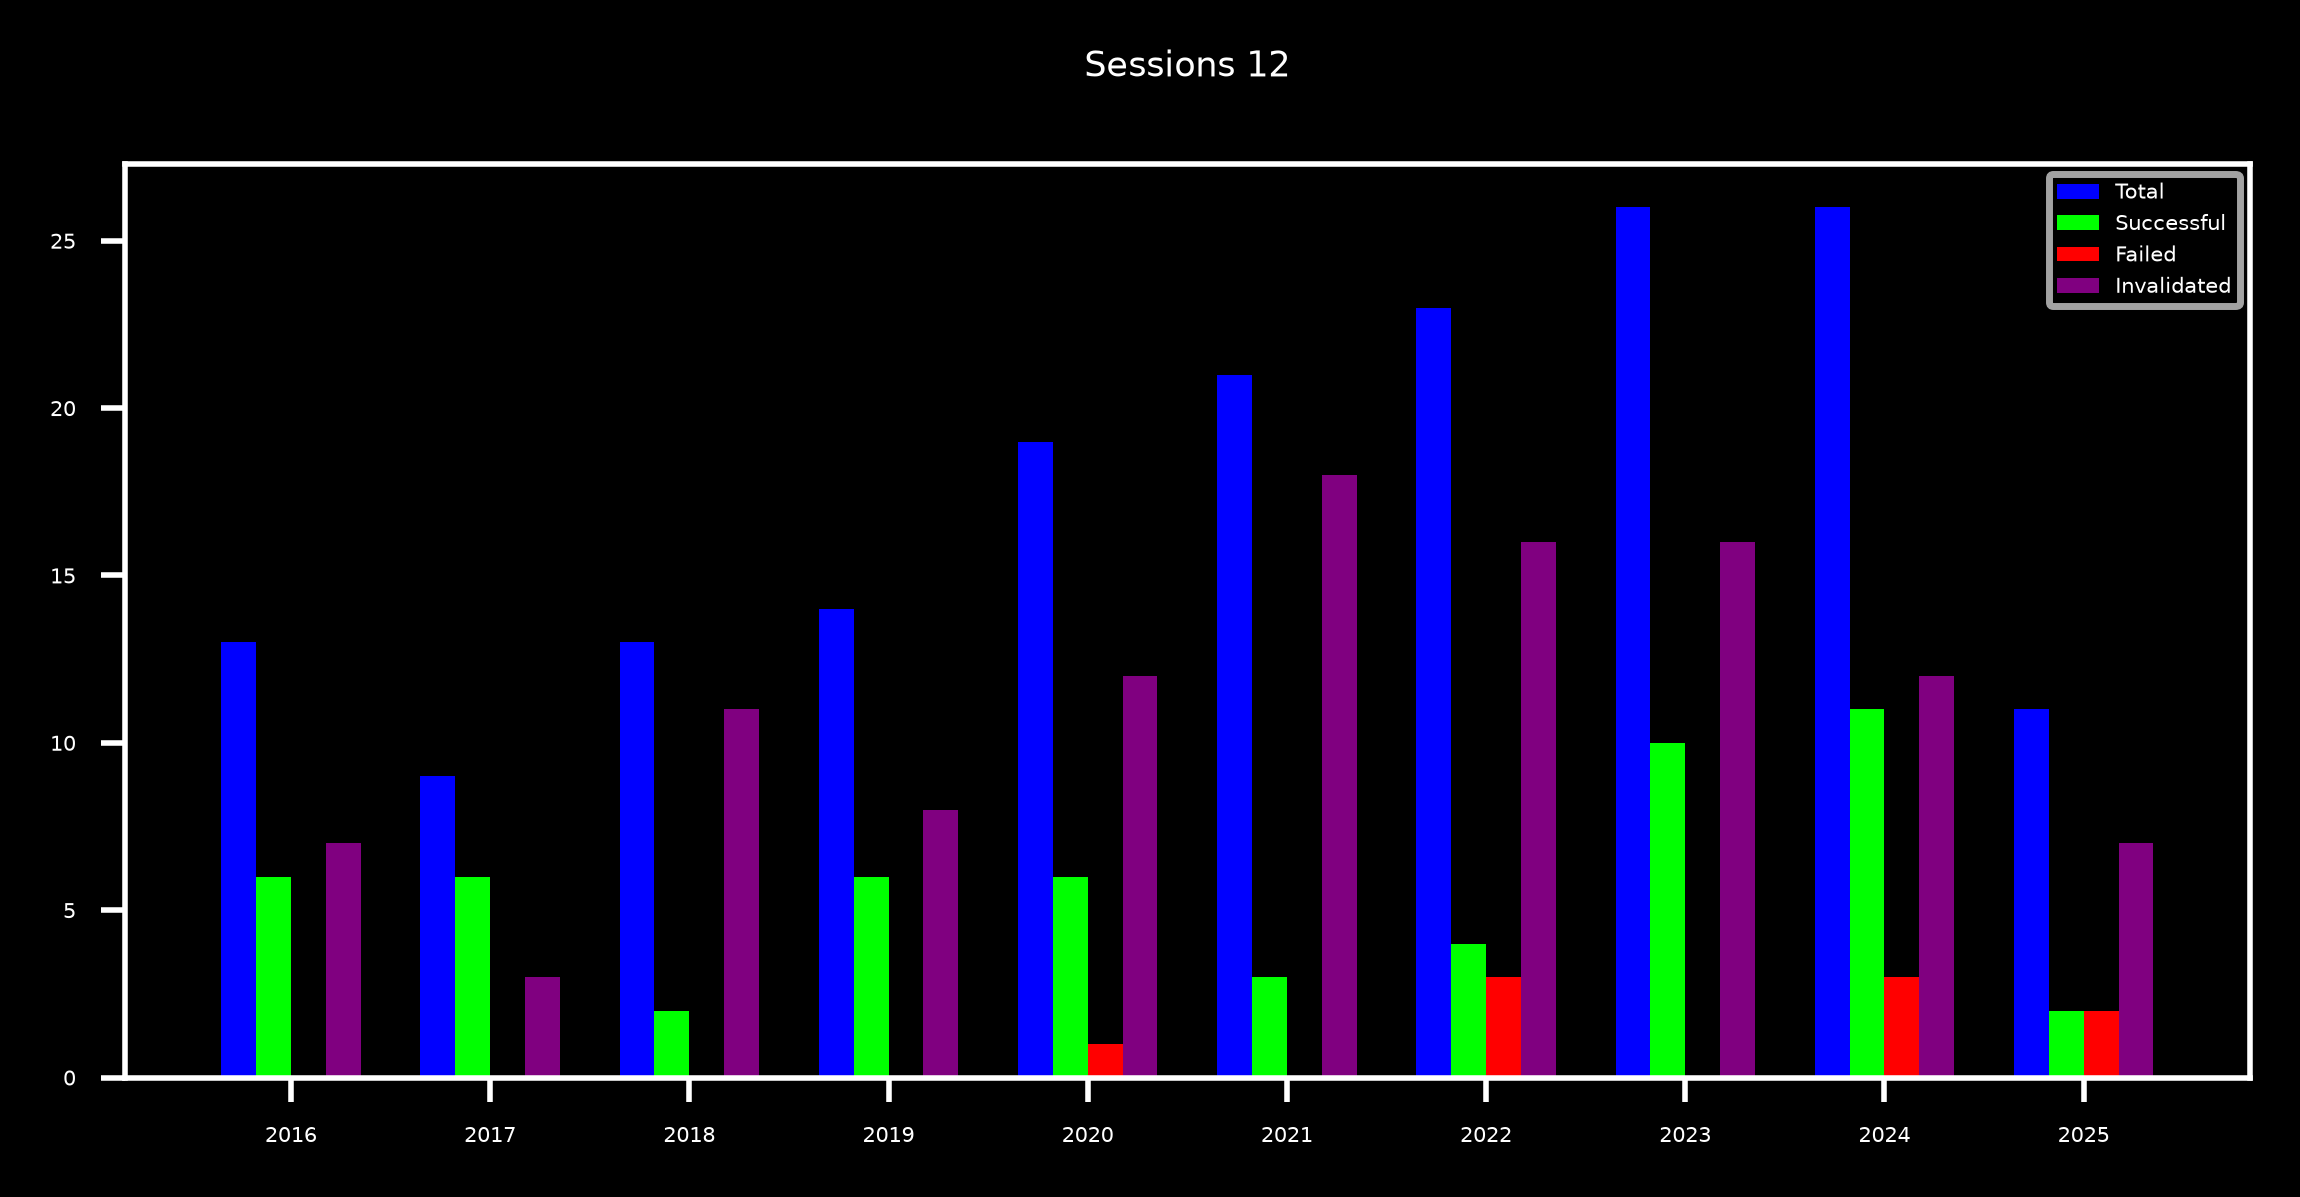

Sessions 13
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  6   │  0   │  7  │  46  │  0   │  53  │ 3.48 │ 7.02 │ -5.… │ 3.6… │ -1.… │ 5.44 │ 9.22 │ -6.1… │ 0.2… │
│ 2017 │  9   │  6   │  0   │  3  │  66  │  0   │  33  │ 18.… │ 21.… │ -8.… │ 3.1… │ -1.… │ 29.… │ 0.0  │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 6.78 │ 5.82 │ -16… │ 0.8… │ -2.… │ -8.… │ -6.… │ -63.… │ 0.0… │
│ 2019 │  14  │  6   │  0   │  8  │  42  │  0   │  57  │ 10.… │ 12.… │ -8.… │ 2.3… │ -1.… │ 8.88 │ 24.… │ -8.2… │ 0.0… │
│ 2020 │  19  │  6   │  1   │ 12  │  31  │  5   │  63  │ 16.2 │ 11.… │ -8.… │ 2.4x │ -1.… │ 3.42 │ 3.44 │ -40.… │ 0.3… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 14.… │ 11.… │ -14… │ 1.7… │ -2.… │ -0.… │ -0.… │ -45.… │ 0.8… │
│ 2022 │  23  │  4   │  3   │ 16  │  17  │  13  │  69  │ 5.34 │ 6.83 │ -10… │ 1.4… │ -2.… │ -5.9 │ -4.9 │ -57.… │ 0.0… │
│ 2023 │  26  │  9   │  1   │ 16  │  34  │  3   │  61  │ 11.… │ 10.… │ -4.… │ 3.5x │ -1.… │ 8.06 │ 21.… │ -17.… │ 0.0… │
│ 2024 │  26  │  10  │  3   │ 13  │  38  │  11  │  50  │ 9.12 │ 7.96 │ -6.4 │ 2.2… │ -1.… │ 3.54 │ 6.02 │ -27.… │ 0.2… │
│ 2025 │  11  │  3   │  1   │  7  │  27  │  9   │  63  │ 4.21 │ 6.11 │ -5.… │ 2.3… │ -1.… │ -1.… │ -1.… │ -18.… │ 0.8… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

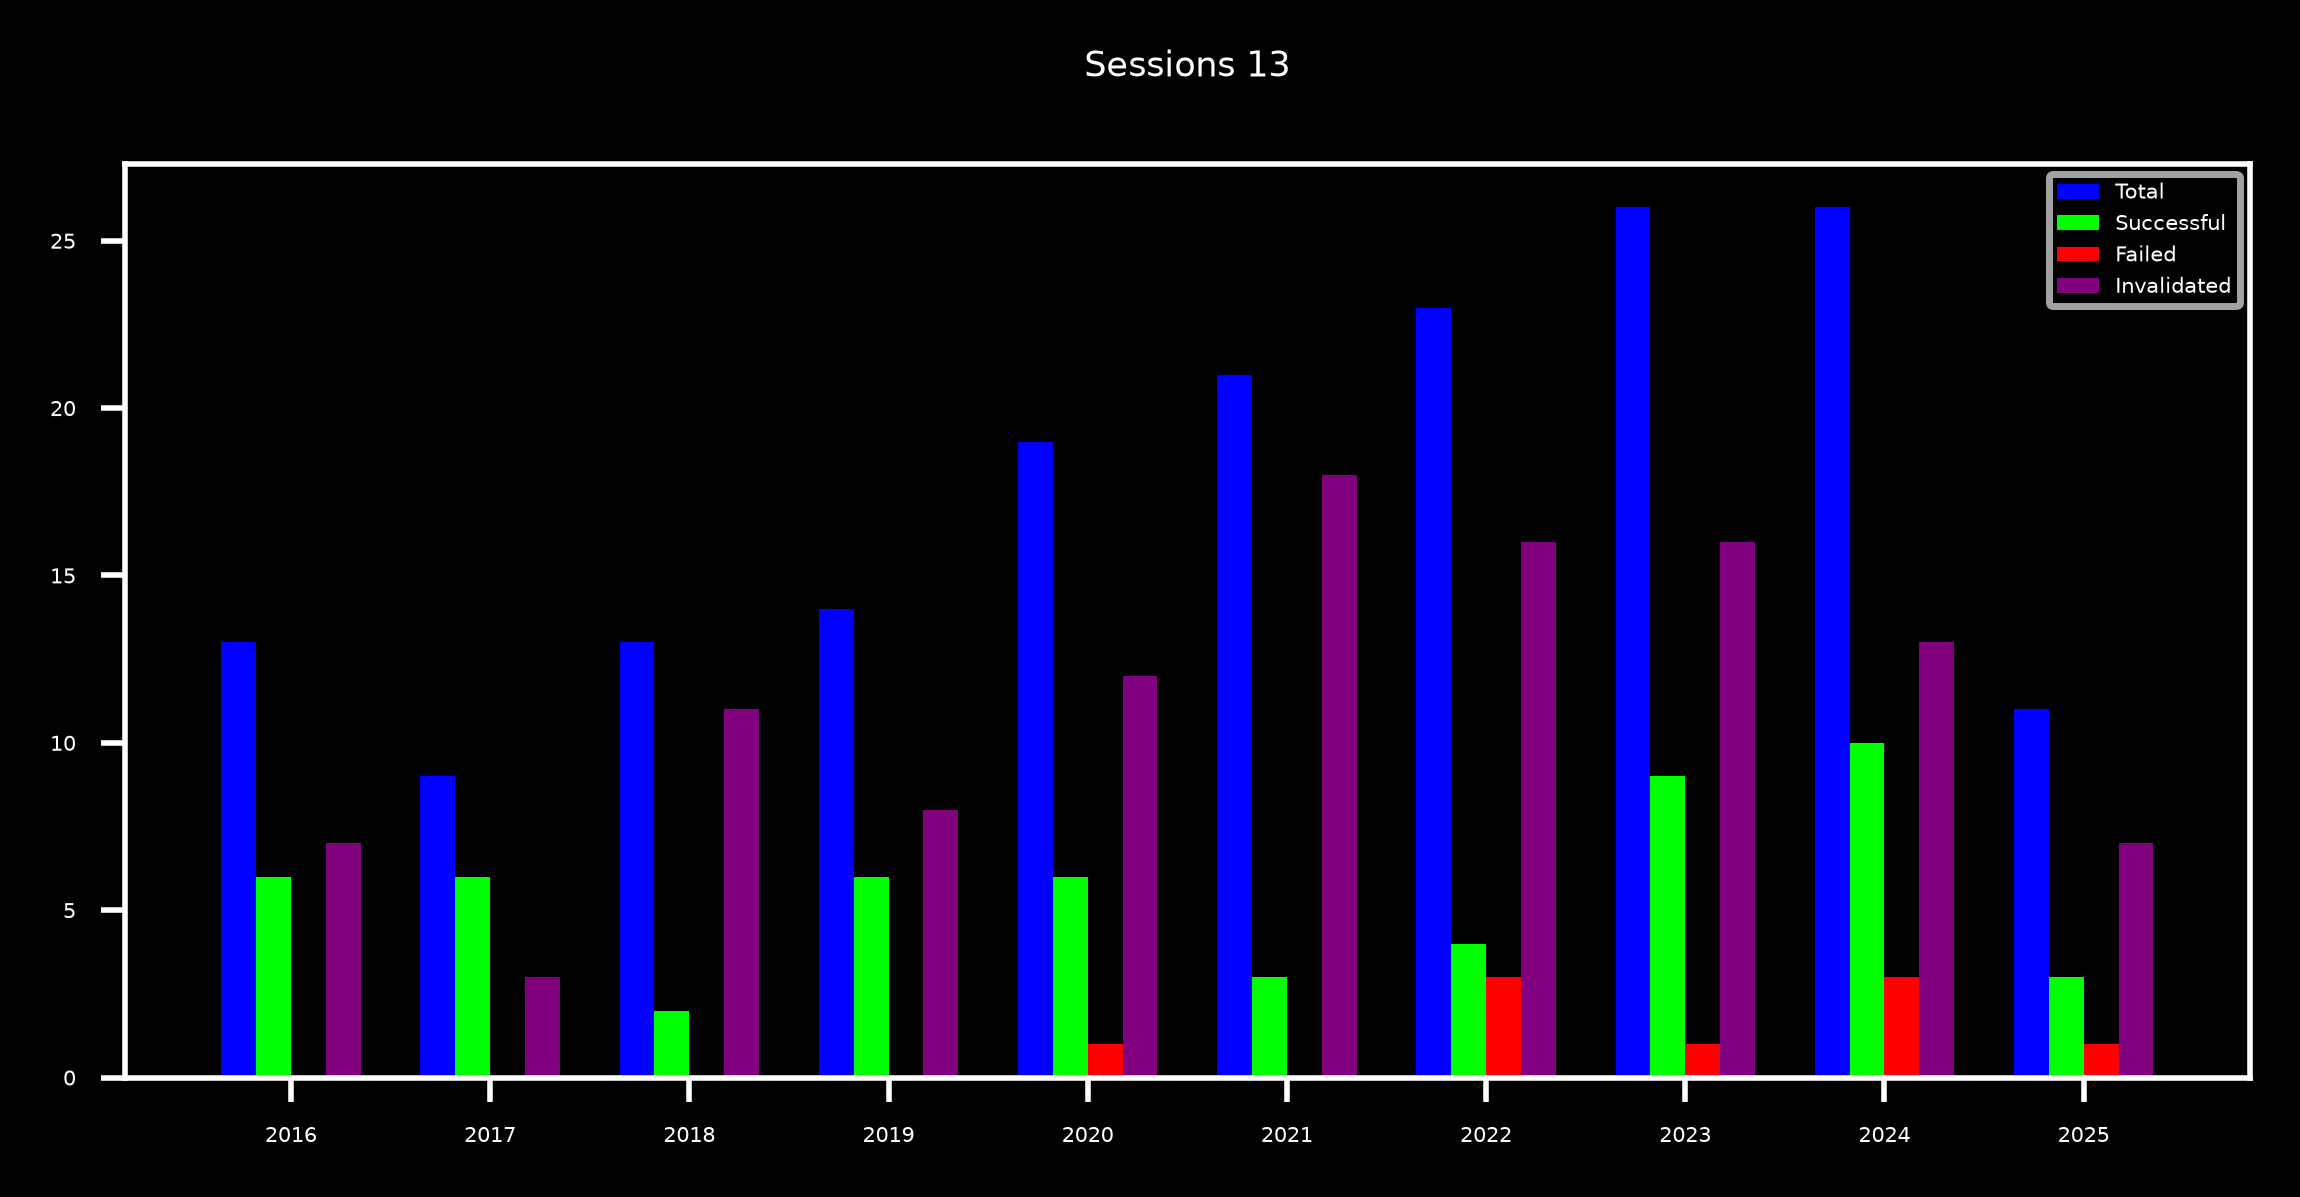

Sessions 14
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  6   │  0   │  7  │  46  │  0   │  53  │ 3.66 │ 7.29 │ -5.… │ 3.7… │ -1.… │ 4.93 │ 7.07 │ -9.4… │ 0.2… │
│ 2017 │  9   │  6   │  0   │  3  │  66  │  0   │  33  │ 20.… │ 23.… │ -8.… │ 3.4… │ -1.… │ 27.… │ 0.0  │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 6.19 │ 5.91 │ -18… │ 0.9… │ -3.… │ -9.… │ -6.… │ -61.… │ 0.0… │
│ 2019 │  14  │  6   │  0   │  8  │  42  │  0   │  57  │ 13.… │ 14.… │ -8.… │ 2.7… │ -1.… │ 8.43 │ 44.… │ -4.2… │ 0.0… │
│ 2020 │  19  │  6   │  1   │ 12  │  31  │  5   │  63  │ 16.… │ 11.… │ -8.… │ 2.5… │ -1.… │ 3.44 │ 3.38 │ -43.… │ 0.3… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 13.… │ 12.… │ -15… │ 1.8… │ -2.… │ -0.… │ -0.… │ -49.… │ 0.8… │
│ 2022 │  23  │  4   │  3   │ 16  │  17  │  13  │  69  │ 7.31 │ 7.21 │ -10… │ 1.5… │ -2.… │ -5.… │ -4.… │ -64.… │ 0.1… │
│ 2023 │  26  │  8   │  2   │ 16  │  30  │  7   │  61  │ 12.9 │ 10.7 │ -4.… │ 3.7… │ -1.… │ 7.65 │ 23.… │ -15.… │ 0.0… │
│ 2024 │  26  │  10  │  3   │ 13  │  38  │  11  │  50  │ 11.… │ 8.7  │ -6.… │ 2.4… │ -1.… │ 3.46 │ 5.69 │ -37.… │ 0.2… │
│ 2025 │  11  │  2   │  2   │  7  │  18  │  18  │  63  │ 4.74 │ 6.18 │ -5.… │ 2.4x │ -2.… │ -2.… │ -2.… │ -16.… │ 0.6… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

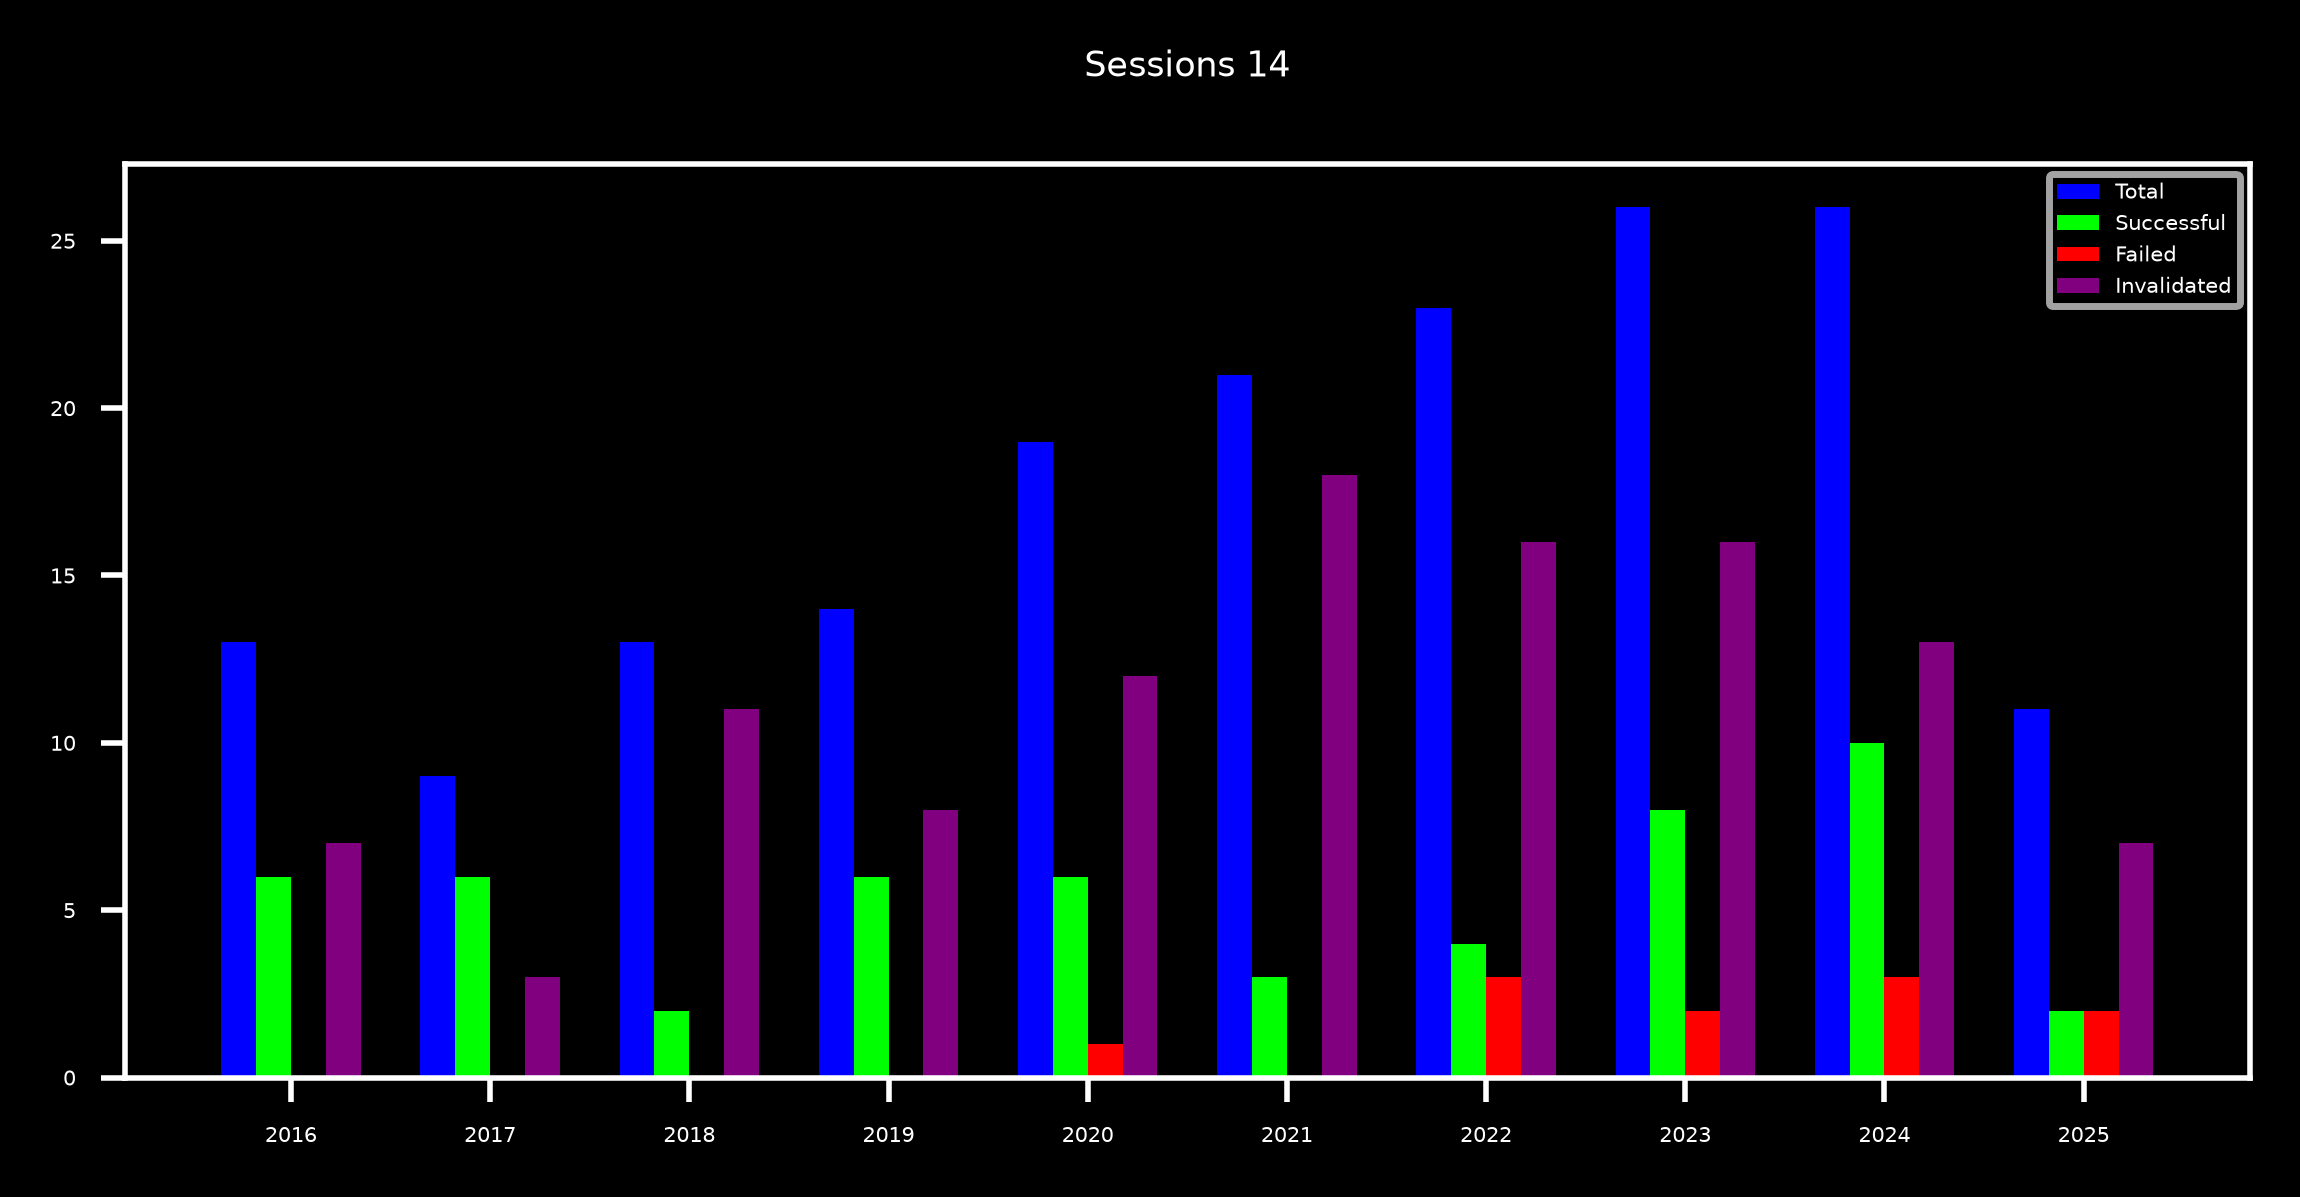

Sessions 15
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  6   │  0   │  7  │  46  │  0   │  53  │ 3.65 │ 8.28 │ -5.… │ 4.1… │ -2.… │ 3.72 │ 5.1  │ -11.… │ 0.4… │
│ 2017 │  9   │  5   │  0   │  4  │  55  │  0   │  44  │ 28.… │ 26.… │ -19… │ 3.7… │ -3.… │ 23.… │ 75.… │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 6.07 │ 5.96 │ -18… │ 0.9… │ -3.… │ -11… │ -8.… │ -70.… │ 0.0… │
│ 2019 │  14  │  5   │  1   │  8  │  35  │  7   │  57  │ 11.… │ 15.… │ -8.… │ 2.8… │ -1.… │ 9.31 │ 25.… │ -5.7… │ 0.0… │
│ 2020 │  19  │  7   │  0   │ 12  │  36  │  0   │  63  │ 12.… │ 12.… │ -8.… │ 2.5… │ -1.… │ 3.66 │ 3.38 │ -40.… │ 0.3… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 16.… │ 12.… │ -15… │ 1.8… │ -2.… │ -0.… │ -0.… │ -45.… │ 0.99 │
│ 2022 │  23  │  4   │  2   │ 17  │  17  │  8   │  73  │ 6.29 │ 7.45 │ -10… │ 1.6x │ -2.… │ -6.0 │ -5.… │ -61.… │ 0.0… │
│ 2023 │  26  │  9   │  0   │ 17  │  34  │  0   │  65  │ 13.… │ 10.… │ -4.… │ 3.8… │ -1.… │ 8.34 │ 23.… │ -14.… │ 0.0… │
│ 2024 │  26  │  12  │  1   │ 13  │  46  │  3   │  50  │ 9.62 │ 9.02 │ -7.… │ 2.5… │ -1.… │ 3.34 │ 4.6  │ -34.… │ 0.2… │
│ 2025 │  11  │  1   │  2   │  8  │  9   │  18  │  72  │ 9.54 │ 6.18 │ -6.… │ 2.4x │ -2.… │ -3.… │ -3.… │ -22.… │ 0.4… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

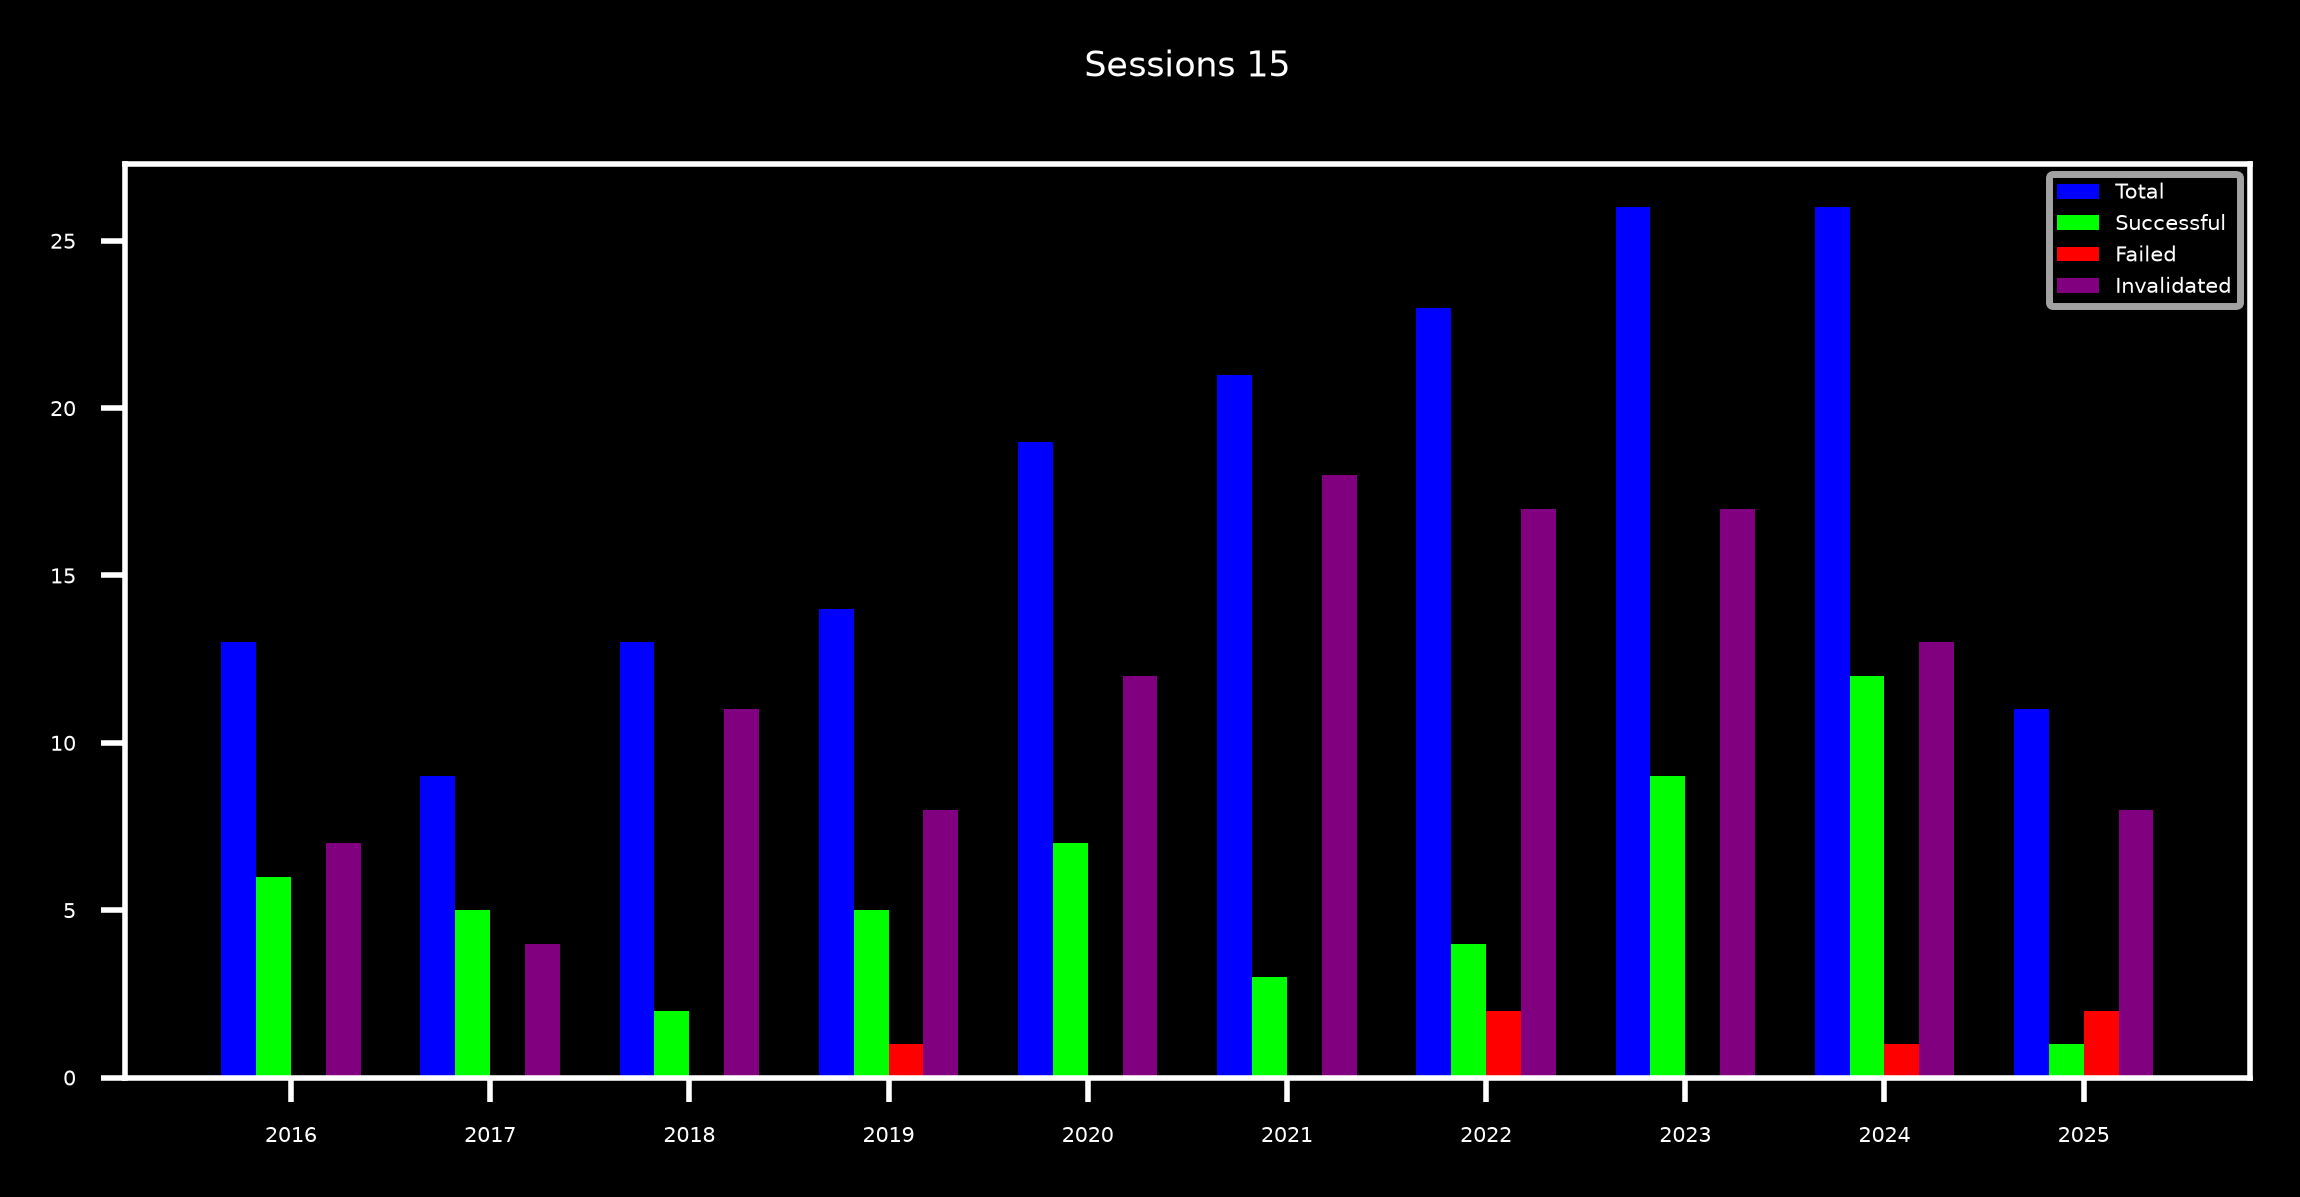

Sessions 16
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  6   │  0   │  7  │  46  │  0   │  53  │ 3.61 │ 8.29 │ -7.… │ 4.1… │ -2.… │ 2.41 │ 2.58 │ -21.… │ 0.5… │
│ 2017 │  9   │  5   │  0   │  4  │  55  │  0   │  44  │ 32.… │ 29.… │ -19… │ 4.0… │ -3.… │ 20.… │ 27.… │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 7.13 │ 5.96 │ -18… │ 0.9… │ -3.… │ -11… │ -8.… │ -69.… │ 0.0… │
│ 2019 │  14  │  4   │  2   │  8  │  28  │  14  │  57  │ 15.… │ 15.… │ -8.… │ 2.9… │ -1.… │ 6.74 │ 18.… │ -8.1… │ 0.1… │
│ 2020 │  19  │  7   │  0   │ 12  │  36  │  0   │  63  │ 16.… │ 12.… │ -8.… │ 2.6… │ -1.… │ 4.63 │ 4.84 │ -39.… │ 0.2… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 20.… │ 12.… │ -16… │ 1.9x │ -2.… │ 0.51 │ 0.7  │ -54.… │ 0.8… │
│ 2022 │  23  │  4   │  2   │ 17  │  17  │  8   │  73  │ 7.01 │ 7.59 │ -10… │ 1.6… │ -2.… │ -4.… │ -4.… │ -61.… │ 0.1… │
│ 2023 │  26  │  9   │  0   │ 17  │  34  │  0   │  65  │ 12.… │ 11.… │ -5.… │ 3.9… │ -1.… │ 7.77 │ 16.… │ -21.… │ 0.0… │
│ 2024 │  26  │  10  │  3   │ 13  │  38  │  11  │  50  │ 12.… │ 9.41 │ -7.… │ 2.6… │ -1.… │ 3.44 │ 5.51 │ -36.… │ 0.2… │
│ 2025 │  11  │  1   │  1   │  9  │  9   │  9   │  81  │ 8.39 │ 6.18 │ -6.8 │ 2.4x │ -2.… │ -4.… │ -4.… │ -19.… │ 0.3… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

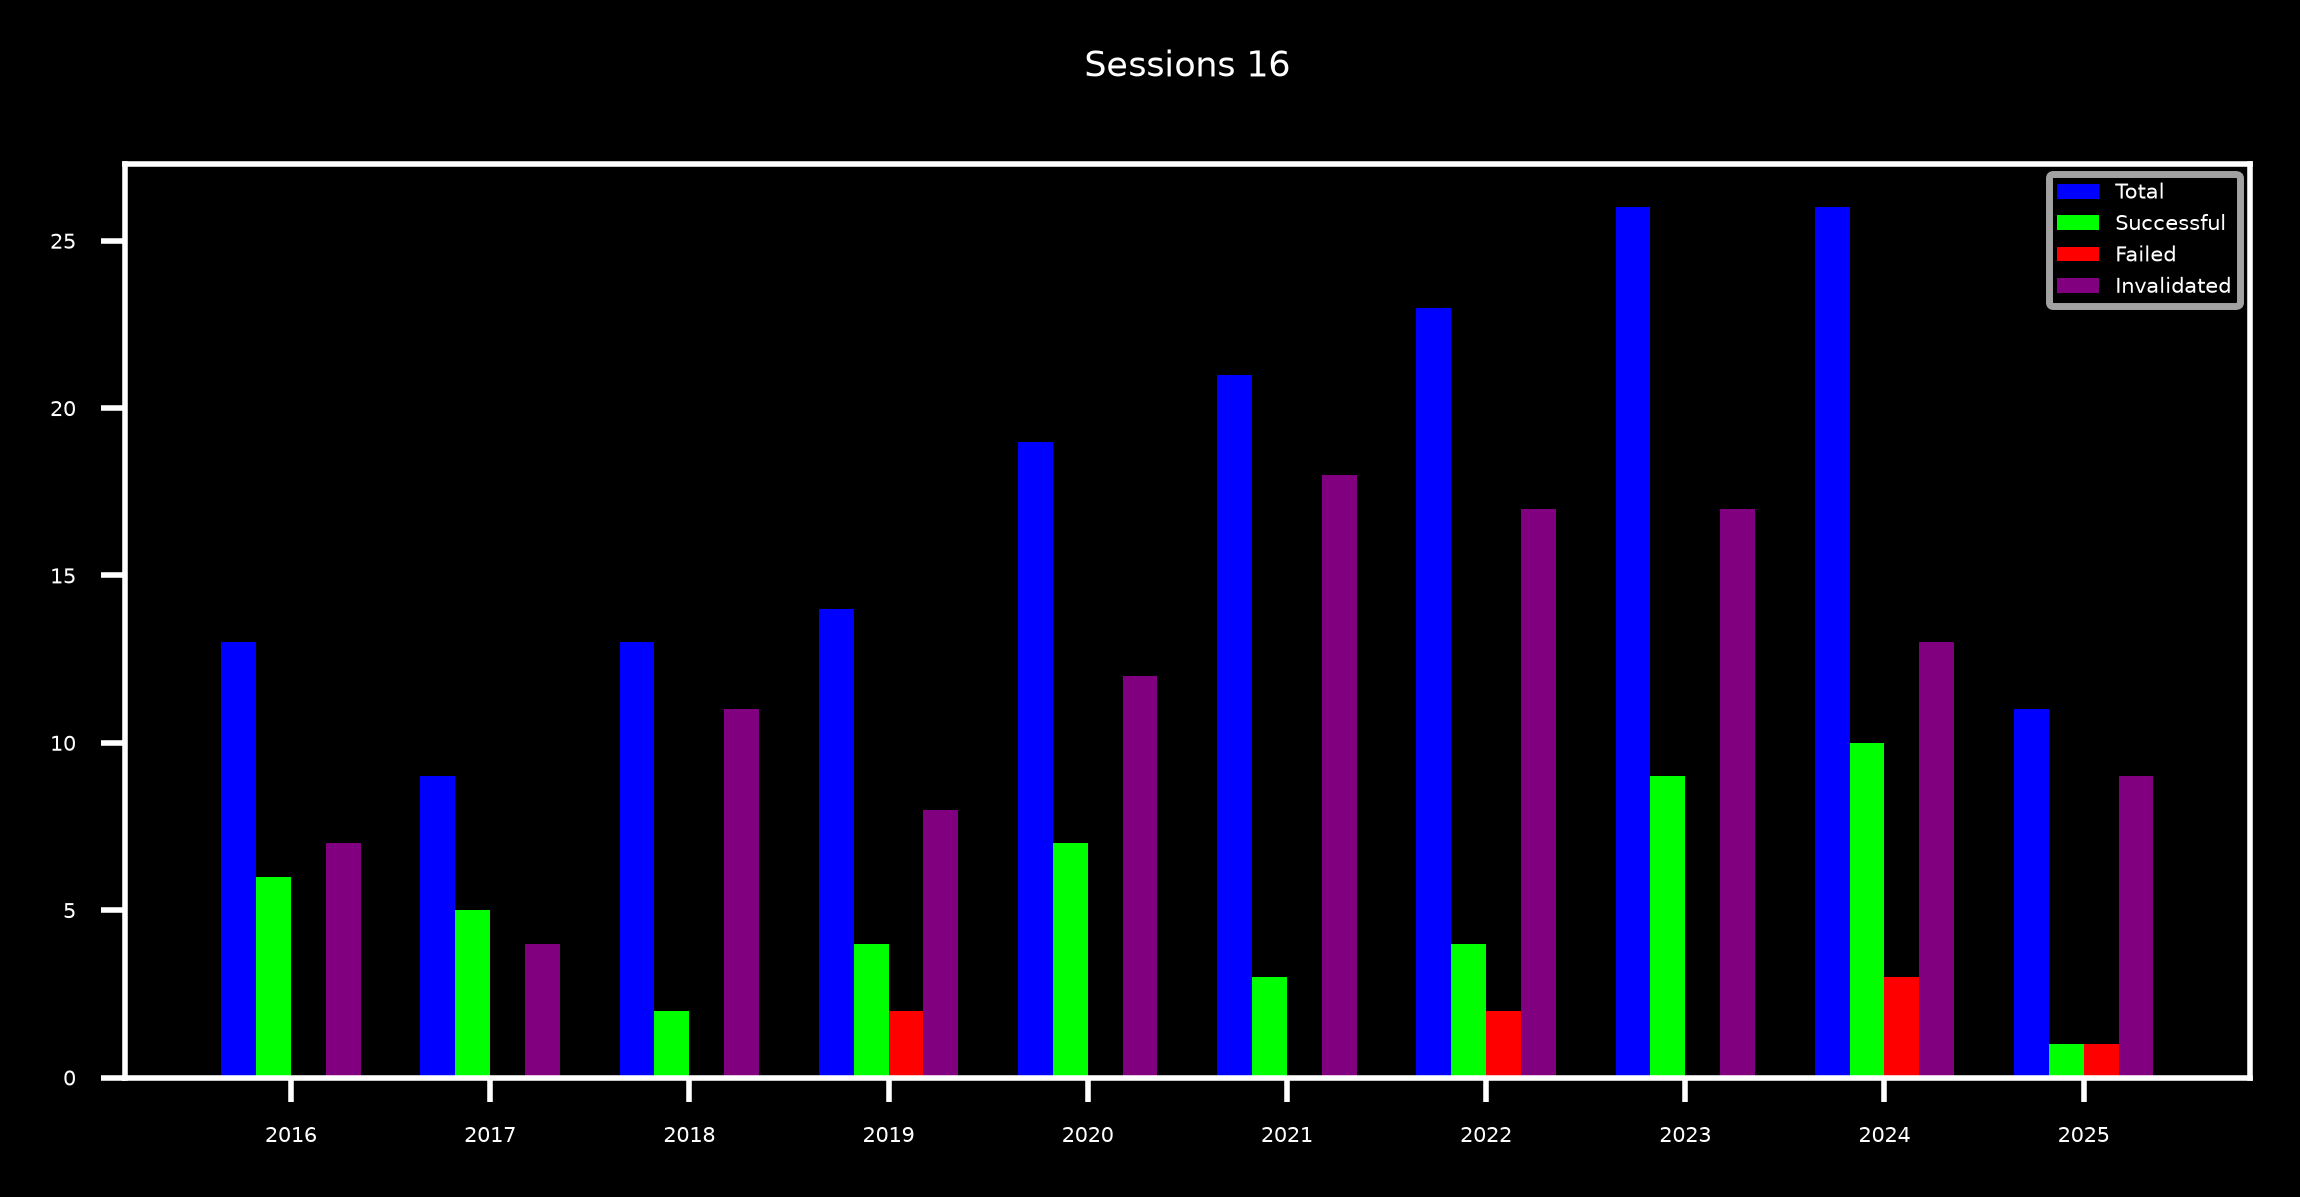

Sessions 17
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  5   │  1   │  7  │  38  │  7   │  53  │ 5.19 │ 8.52 │ -7.… │ 4.3… │ -2.… │ 3.83 │ 5.13 │ -15.… │ 0.4… │
│ 2017 │  9   │  5   │  0   │  4  │  55  │  0   │  44  │ 36.… │ 32.… │ -19… │ 4.3… │ -3.… │ 17.… │ 17.… │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 11.6 │ 6.14 │ -19… │ 0.9… │ -3.… │ -11… │ -8.… │ -73.… │ 0.0… │
│ 2019 │  14  │  5   │  1   │  8  │  35  │  7   │  57  │ 11.7 │ 16.… │ -8.… │ 3.0… │ -1.… │ 7.17 │ 12.… │ -12.… │ 0.1… │
│ 2020 │  19  │  7   │  0   │ 12  │  36  │  0   │  63  │ 18.… │ 13.… │ -8.… │ 2.8… │ -1.… │ 6.06 │ 7.25 │ -30.… │ 0.1… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 21.… │ 13.2 │ -16… │ 1.9… │ -2.… │ 1.21 │ 1.73 │ -52.… │ 0.7… │
│ 2022 │  23  │  3   │  3   │ 17  │  13  │  13  │  73  │ 7.37 │ 7.82 │ -11… │ 1.6… │ -2.… │ -5.… │ -5.… │ -60.… │ 0.0… │
│ 2023 │  26  │  8   │  0   │ 18  │  30  │  0   │  69  │ 12.… │ 11.… │ -5.7 │ 3.9… │ -1.… │ 5.58 │ 10.1 │ -24.… │ 0.0… │
│ 2024 │  26  │  12  │  1   │ 13  │  46  │  3   │  50  │ 10.… │ 9.86 │ -7.9 │ 2.7… │ -1.… │ 3.4  │ 4.79 │ -39.… │ 0.2… │
│ 2025 │  11  │  1   │  1   │  9  │  9   │  9   │  81  │ 8.29 │ 6.18 │ -7.… │ 2.4x │ -2.… │ -4.… │ -4.… │ -23.… │ 0.3… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

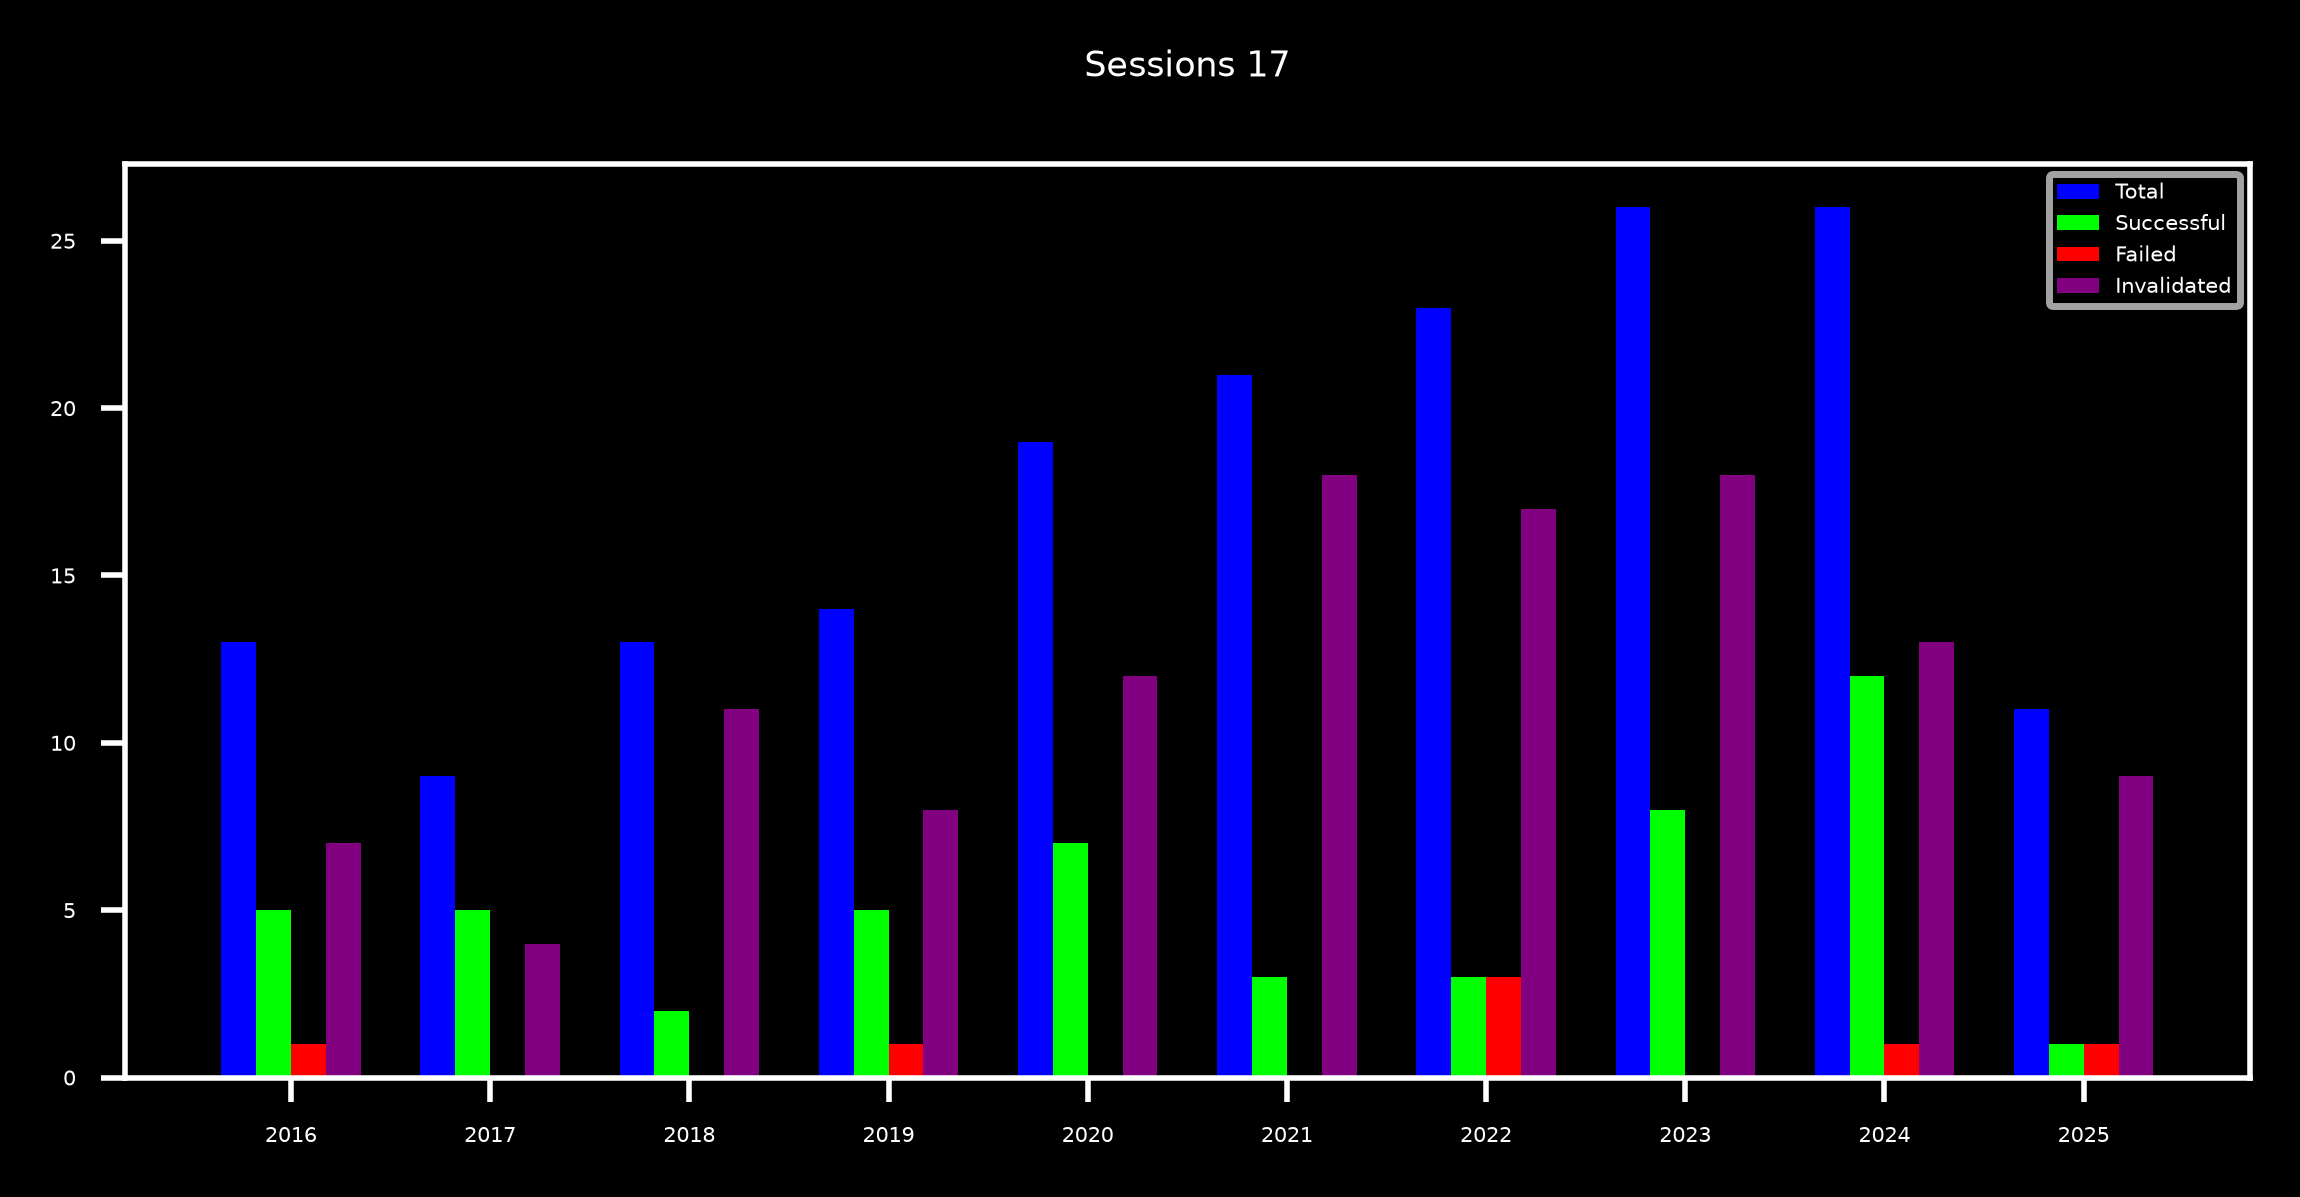

Sessions 18
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  5   │  0   │  8  │  38  │  0   │  61  │ 5.96 │ 8.87 │ -7.… │ 4.5… │ -2.… │ 3.96 │ 5.42 │ -13.… │ 0.3… │
│ 2017 │  9   │  5   │  0   │  4  │  55  │  0   │  44  │ 38.… │ 33.… │ -19… │ 4.5… │ -3.… │ 18.… │ 23.… │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 17.… │ 6.99 │ -19… │ 1.1… │ -3.… │ -9.… │ -8.… │ -68.… │ 0.0… │
│ 2019 │  14  │  5   │  1   │  8  │  35  │  7   │  57  │ 9.68 │ 16.… │ -8.… │ 3.0… │ -1.… │ 8.7  │ 11.0 │ -13.… │ 0.0… │
│ 2020 │  19  │  7   │  0   │ 12  │  36  │  0   │  63  │ 15.… │ 13.… │ -8.… │ 2.8… │ -1.… │ 5.44 │ 6.63 │ -30.… │ 0.1… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 22.… │ 13.… │ -16… │ 2.0… │ -2.… │ 1.06 │ 1.33 │ -57.… │ 0.7… │
│ 2022 │  23  │  5   │  1   │ 17  │  21  │  4   │  73  │ 5.8  │ 7.84 │ -11… │ 1.6… │ -2.… │ -5.… │ -4.… │ -56.… │ 0.1… │
│ 2023 │  26  │  8   │  0   │ 18  │  30  │  0   │  69  │ 14.… │ 11.… │ -5.… │ 4.0… │ -1.… │ 6.68 │ 12.… │ -22.… │ 0.0… │
│ 2024 │  26  │  11  │  2   │ 13  │  42  │  7   │  50  │ 13.… │ 10.… │ -7.… │ 2.9… │ -2.… │ 4.43 │ 7.53 │ -36.… │ 0.1… │
│ 2025 │  11  │  2   │  0   │  9  │  18  │  0   │  81  │ 4.58 │ 6.18 │ -7.… │ 2.4x │ -2.… │ -3.… │ -3.… │ -22.… │ 0.4… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

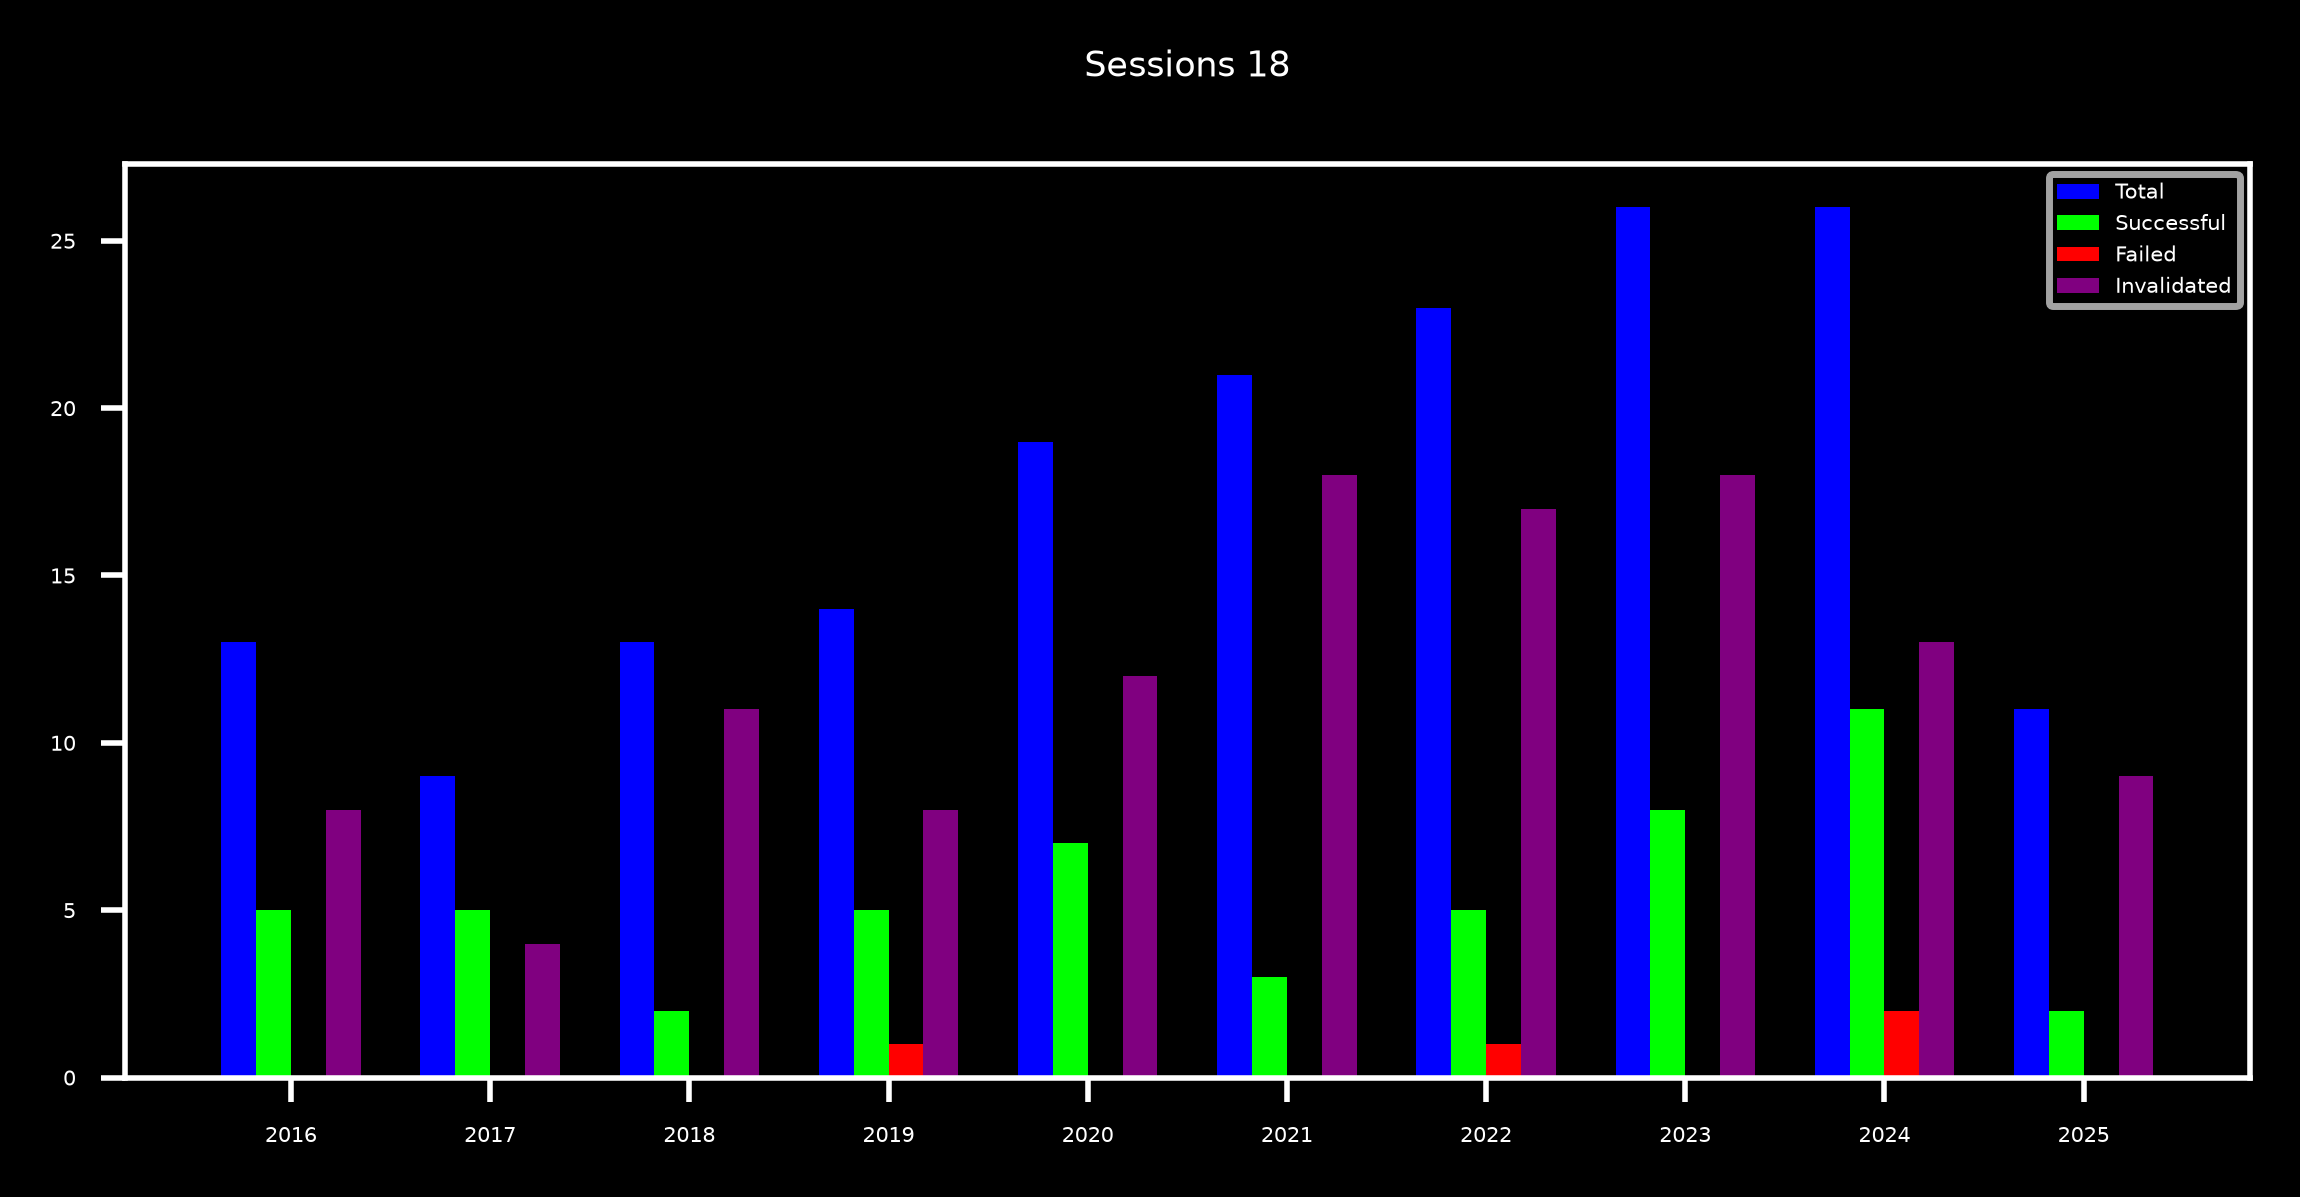

Sessions 19
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  5   │  0   │  8  │  38  │  0   │  61  │ 6.24 │ 9.11 │ -7.… │ 4.8… │ -2.… │ 3.91 │ 4.28 │ -14.… │ 0.3… │
│ 2017 │  9   │  5   │  0   │  4  │  55  │  0   │  44  │ 36.… │ 35.… │ -19… │ 4.7… │ -3.… │ 20.… │ 27.… │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 17.… │ 7.16 │ -20… │ 1.1… │ -3.… │ -8.… │ -7.… │ -66.… │ 0.0… │
│ 2019 │  14  │  5   │  1   │  8  │  35  │  7   │  57  │ 10.… │ 17.… │ -8.… │ 3.1… │ -1.… │ 10.… │ 13.… │ -12.… │ 0.0… │
│ 2020 │  19  │  7   │  0   │ 12  │  36  │  0   │  63  │ 16.… │ 13.… │ -9.… │ 3.0… │ -2.… │ 5.84 │ 7.24 │ -30.… │ 0.1… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 25.… │ 14.… │ -16… │ 2.0… │ -2.… │ 1.37 │ 1.94 │ -59.… │ 0.6… │
│ 2022 │  23  │  4   │  2   │ 17  │  17  │  8   │  73  │ 8.18 │ 8.21 │ -11… │ 1.7x │ -2.… │ -5.… │ -4.… │ -58.… │ 0.1… │
│ 2023 │  26  │  8   │  0   │ 18  │  30  │  0   │  69  │ 15.… │ 12.… │ -5.… │ 4.4… │ -1.… │ 7.68 │ 12.… │ -21.… │ 0.0… │
│ 2024 │  26  │  10  │  2   │ 14  │  38  │  7   │  53  │ 16.… │ 11.… │ -8.… │ 3.2x │ -2.… │ 4.82 │ 8.28 │ -40.… │ 0.1… │
│ 2025 │  11  │  1   │  1   │  9  │  9   │  9   │  81  │ 7.84 │ 6.18 │ -7.… │ 2.4x │ -2.… │ -6.… │ -5.… │ -24.… │ 0.2… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

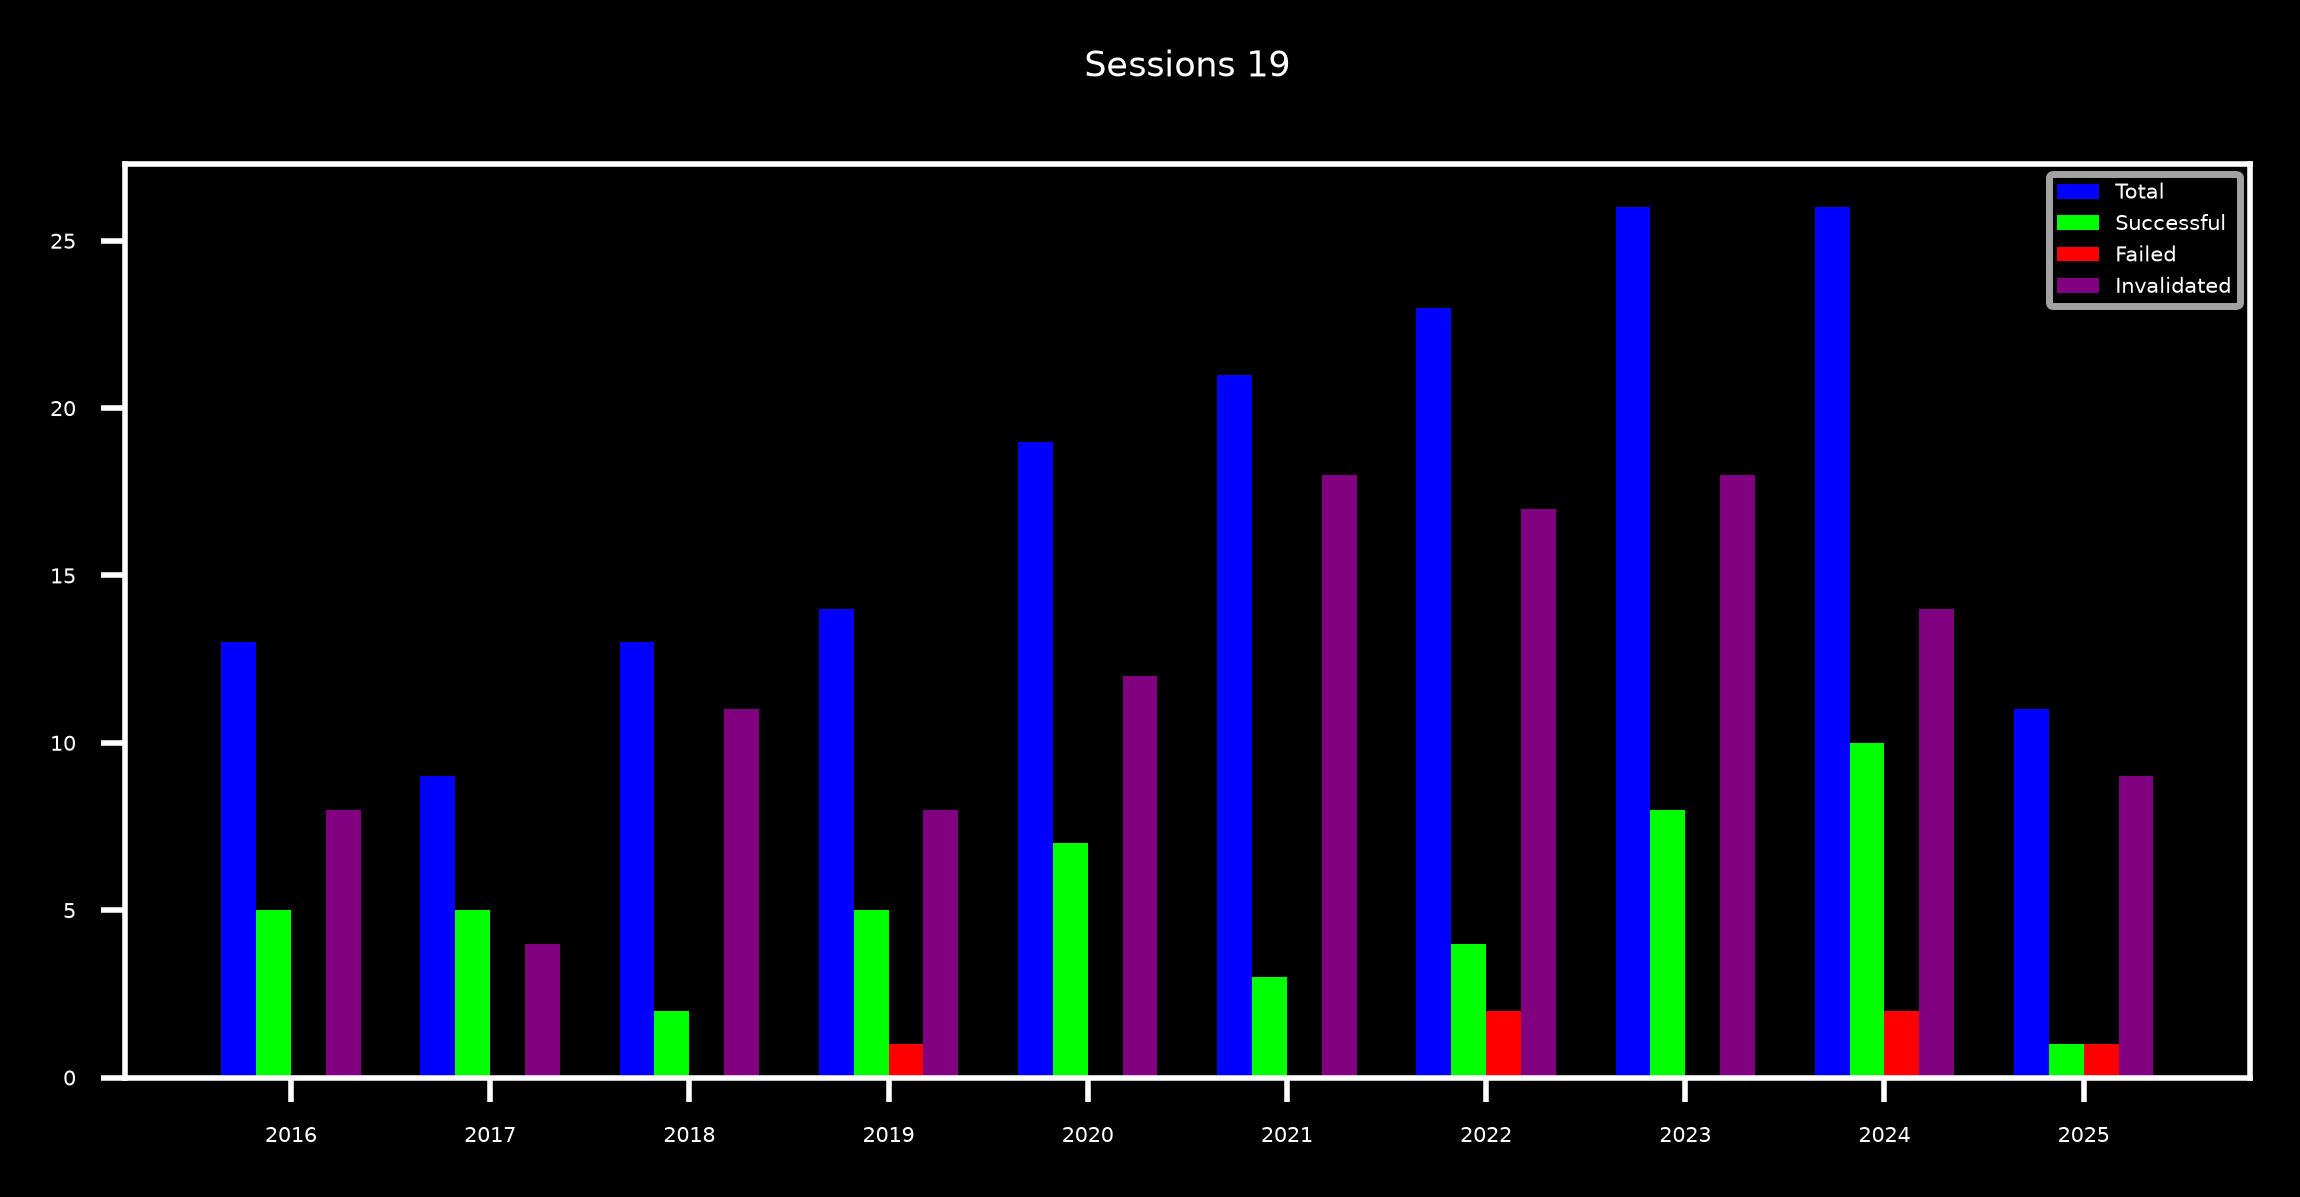

Sessions 20
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  5   │  0   │  8  │  38  │  0   │  61  │ 6.82 │ 9.29 │ -7.… │ 5.0… │ -2.… │ 4.47 │ 4.59 │ -13.… │ 0.3… │
│ 2017 │  9   │  5   │  0   │  4  │  55  │  0   │  44  │ 40.… │ 36.3 │ -19… │ 4.8… │ -3.… │ 22.… │ 49.… │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 18.… │ 7.24 │ -20… │ 1.1… │ -3.… │ -8.… │ -7.… │ -63.… │ 0.0… │
│ 2019 │  14  │  5   │  1   │  8  │  35  │  7   │  57  │ 11.… │ 17.… │ -8.… │ 3.2… │ -1.… │ 9.48 │ 10.… │ -12.… │ 0.0… │
│ 2020 │  19  │  7   │  0   │ 12  │  36  │  0   │  63  │ 16.… │ 14.… │ -9.… │ 3.1… │ -2.… │ 5.65 │ 6.0  │ -34.… │ 0.1… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 24.… │ 14.… │ -16… │ 2.1… │ -2.… │ 1.67 │ 2.09 │ -59.… │ 0.6… │
│ 2022 │  23  │  4   │  1   │ 18  │  17  │  4   │  78  │ 7.65 │ 8.47 │ -11… │ 1.7… │ -2.… │ -6.… │ -5.… │ -65.… │ 0.0… │
│ 2023 │  26  │  8   │  0   │ 18  │  30  │  0   │  69  │ 16.… │ 12.… │ -5.… │ 4.4… │ -1.… │ 8.58 │ 17.… │ -19.… │ 0.0… │
│ 2024 │  26  │  10  │  2   │ 14  │  38  │  7   │  53  │ 15.… │ 11.6 │ -8.… │ 3.3… │ -2.… │ 5.45 │ 9.83 │ -35.… │ 0.0… │
│ 2025 │  11  │  1   │  1   │  9  │  9   │  9   │  81  │ 10.… │ 6.27 │ -7.… │ 2.4… │ -2.… │ -4.… │ -4.… │ -21.… │ 0.4… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

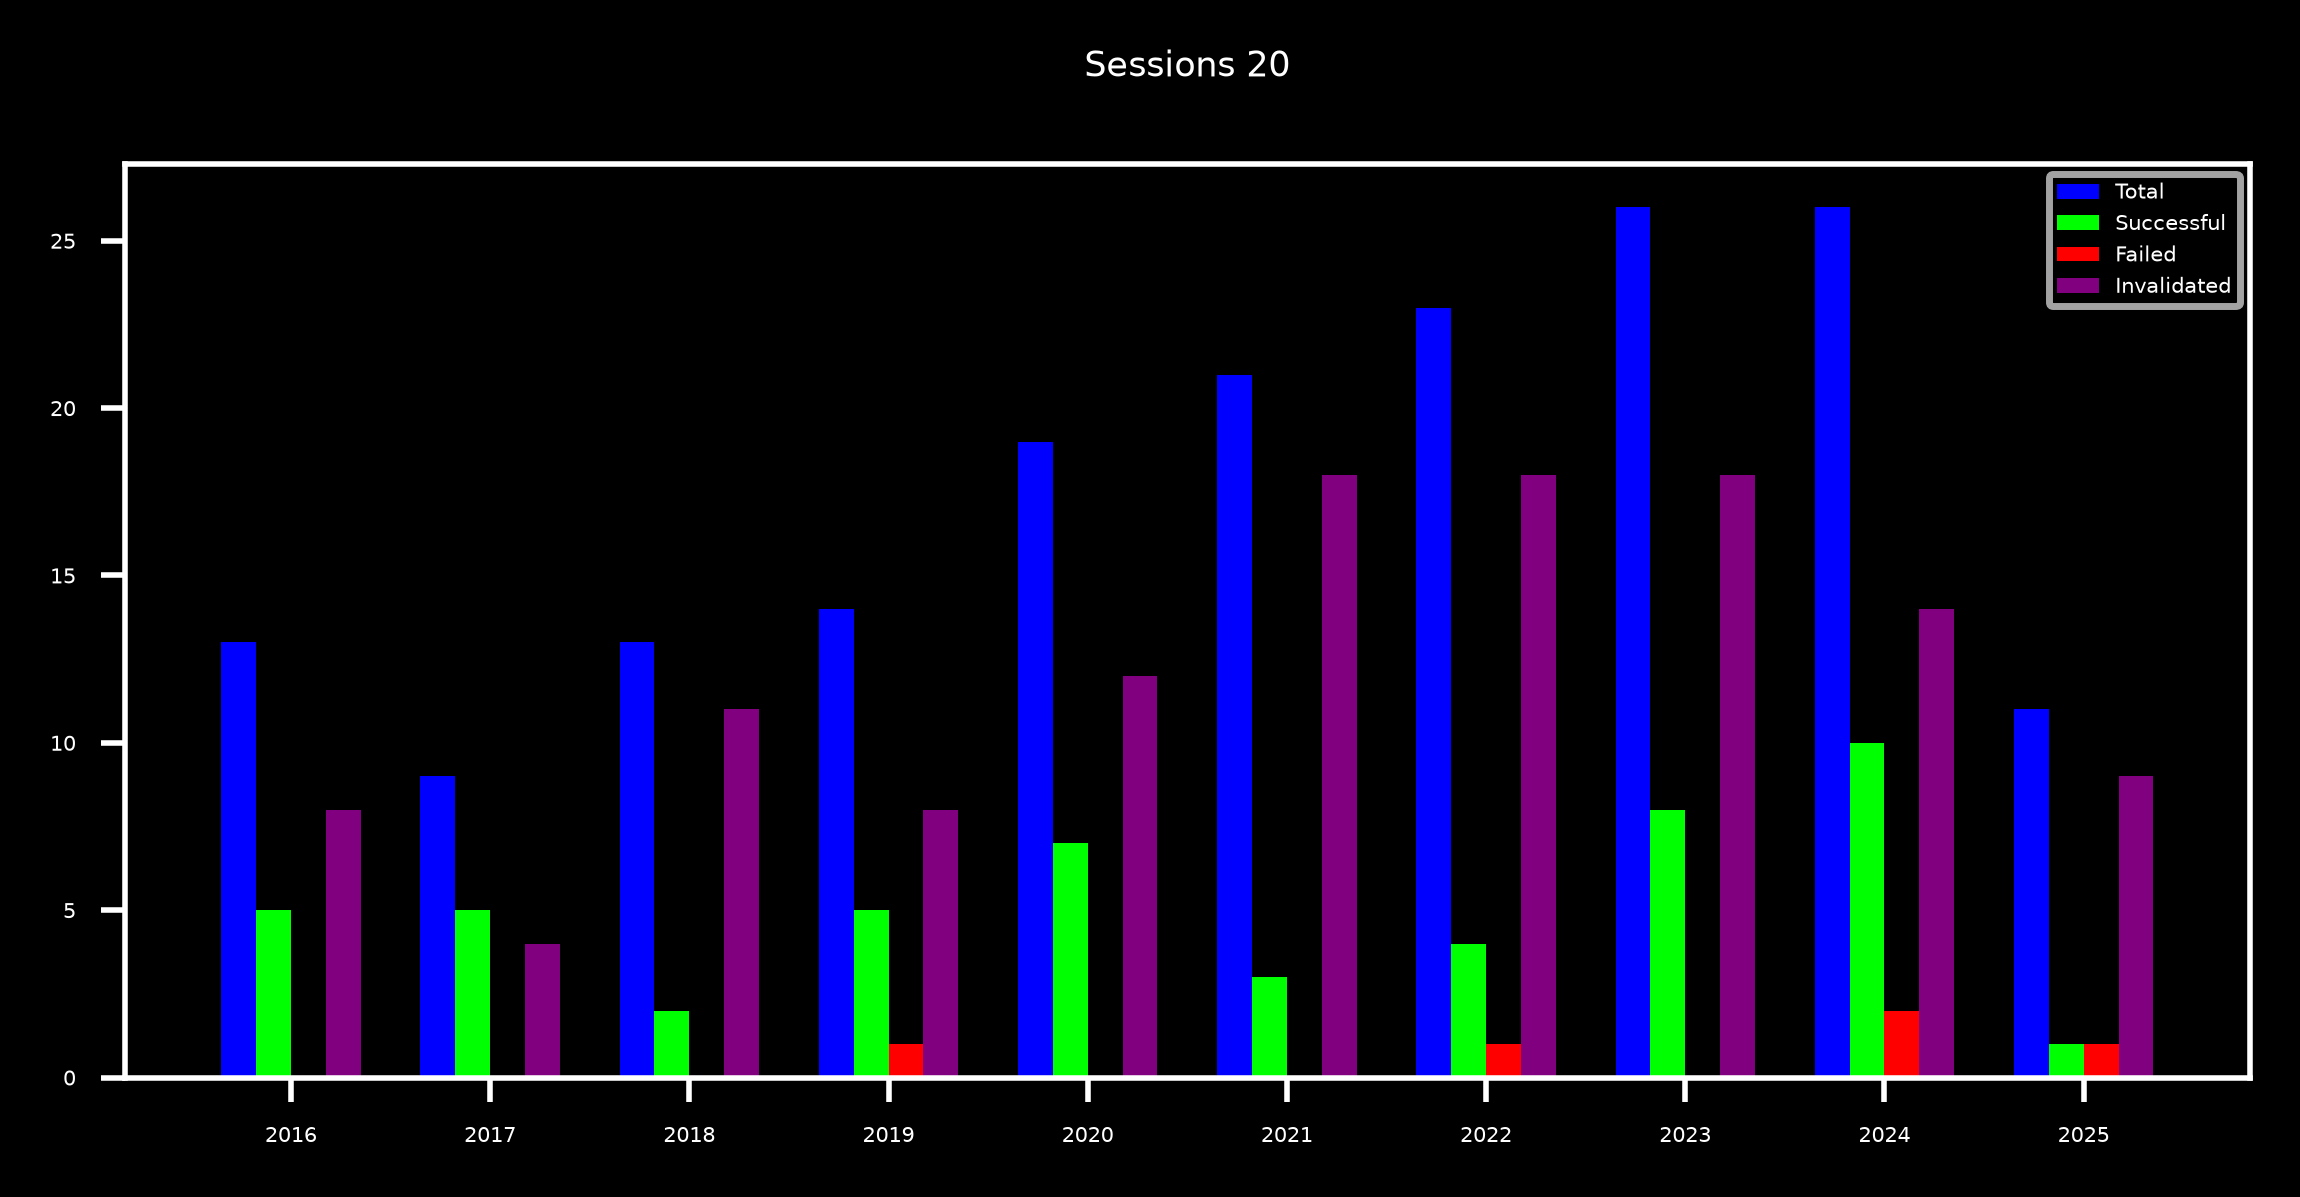

Sessions 21
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  5   │  0   │  8  │  38  │  0   │  61  │ 6.92 │ 9.55 │ -7.… │ 5.3… │ -2.… │ 2.91 │ 2.36 │ -13.… │ 0.5… │
│ 2017 │  9   │  5   │  0   │  4  │  55  │  0   │  44  │ 41.… │ 37.… │ -19… │ 4.9… │ -3.… │ 19.… │ 27.… │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 12.… │ 7.36 │ -21… │ 1.2x │ -3.… │ -10… │ -8.… │ -69.… │ 0.0… │
│ 2019 │  14  │  5   │  1   │  8  │  35  │  7   │  57  │ 14.… │ 17.4 │ -8.… │ 3.2… │ -1.… │ 7.01 │ 9.88 │ -15.… │ 0.1… │
│ 2020 │  19  │  7   │  0   │ 12  │  36  │  0   │  63  │ 20.… │ 15.… │ -9.… │ 3.6… │ -2.… │ 7.19 │ 8.48 │ -27.… │ 0.0… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 20.… │ 14.… │ -17… │ 2.1… │ -2.… │ 1.17 │ 1.4  │ -59.… │ 0.7… │
│ 2022 │  23  │  4   │  1   │ 18  │  17  │  4   │  78  │ 7.09 │ 8.53 │ -12… │ 1.7… │ -2.… │ -7.… │ -6.… │ -73.… │ 0.0… │
│ 2023 │  26  │  7   │  1   │ 18  │  26  │  3   │  69  │ 18.… │ 13.… │ -5.… │ 4.6… │ -1.… │ 8.43 │ 22.… │ -19.… │ 0.0… │
│ 2024 │  26  │  10  │  2   │ 14  │  38  │  7   │  53  │ 14.… │ 11.… │ -8.… │ 3.3… │ -2.… │ 5.6  │ 9.93 │ -33.… │ 0.0… │
│ 2025 │  11  │  1   │  1   │  9  │  9   │  9   │  81  │ 9.11 │ 6.37 │ -7.… │ 2.4… │ -2.… │ -2.… │ -2.… │ -16.… │ 0.6… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

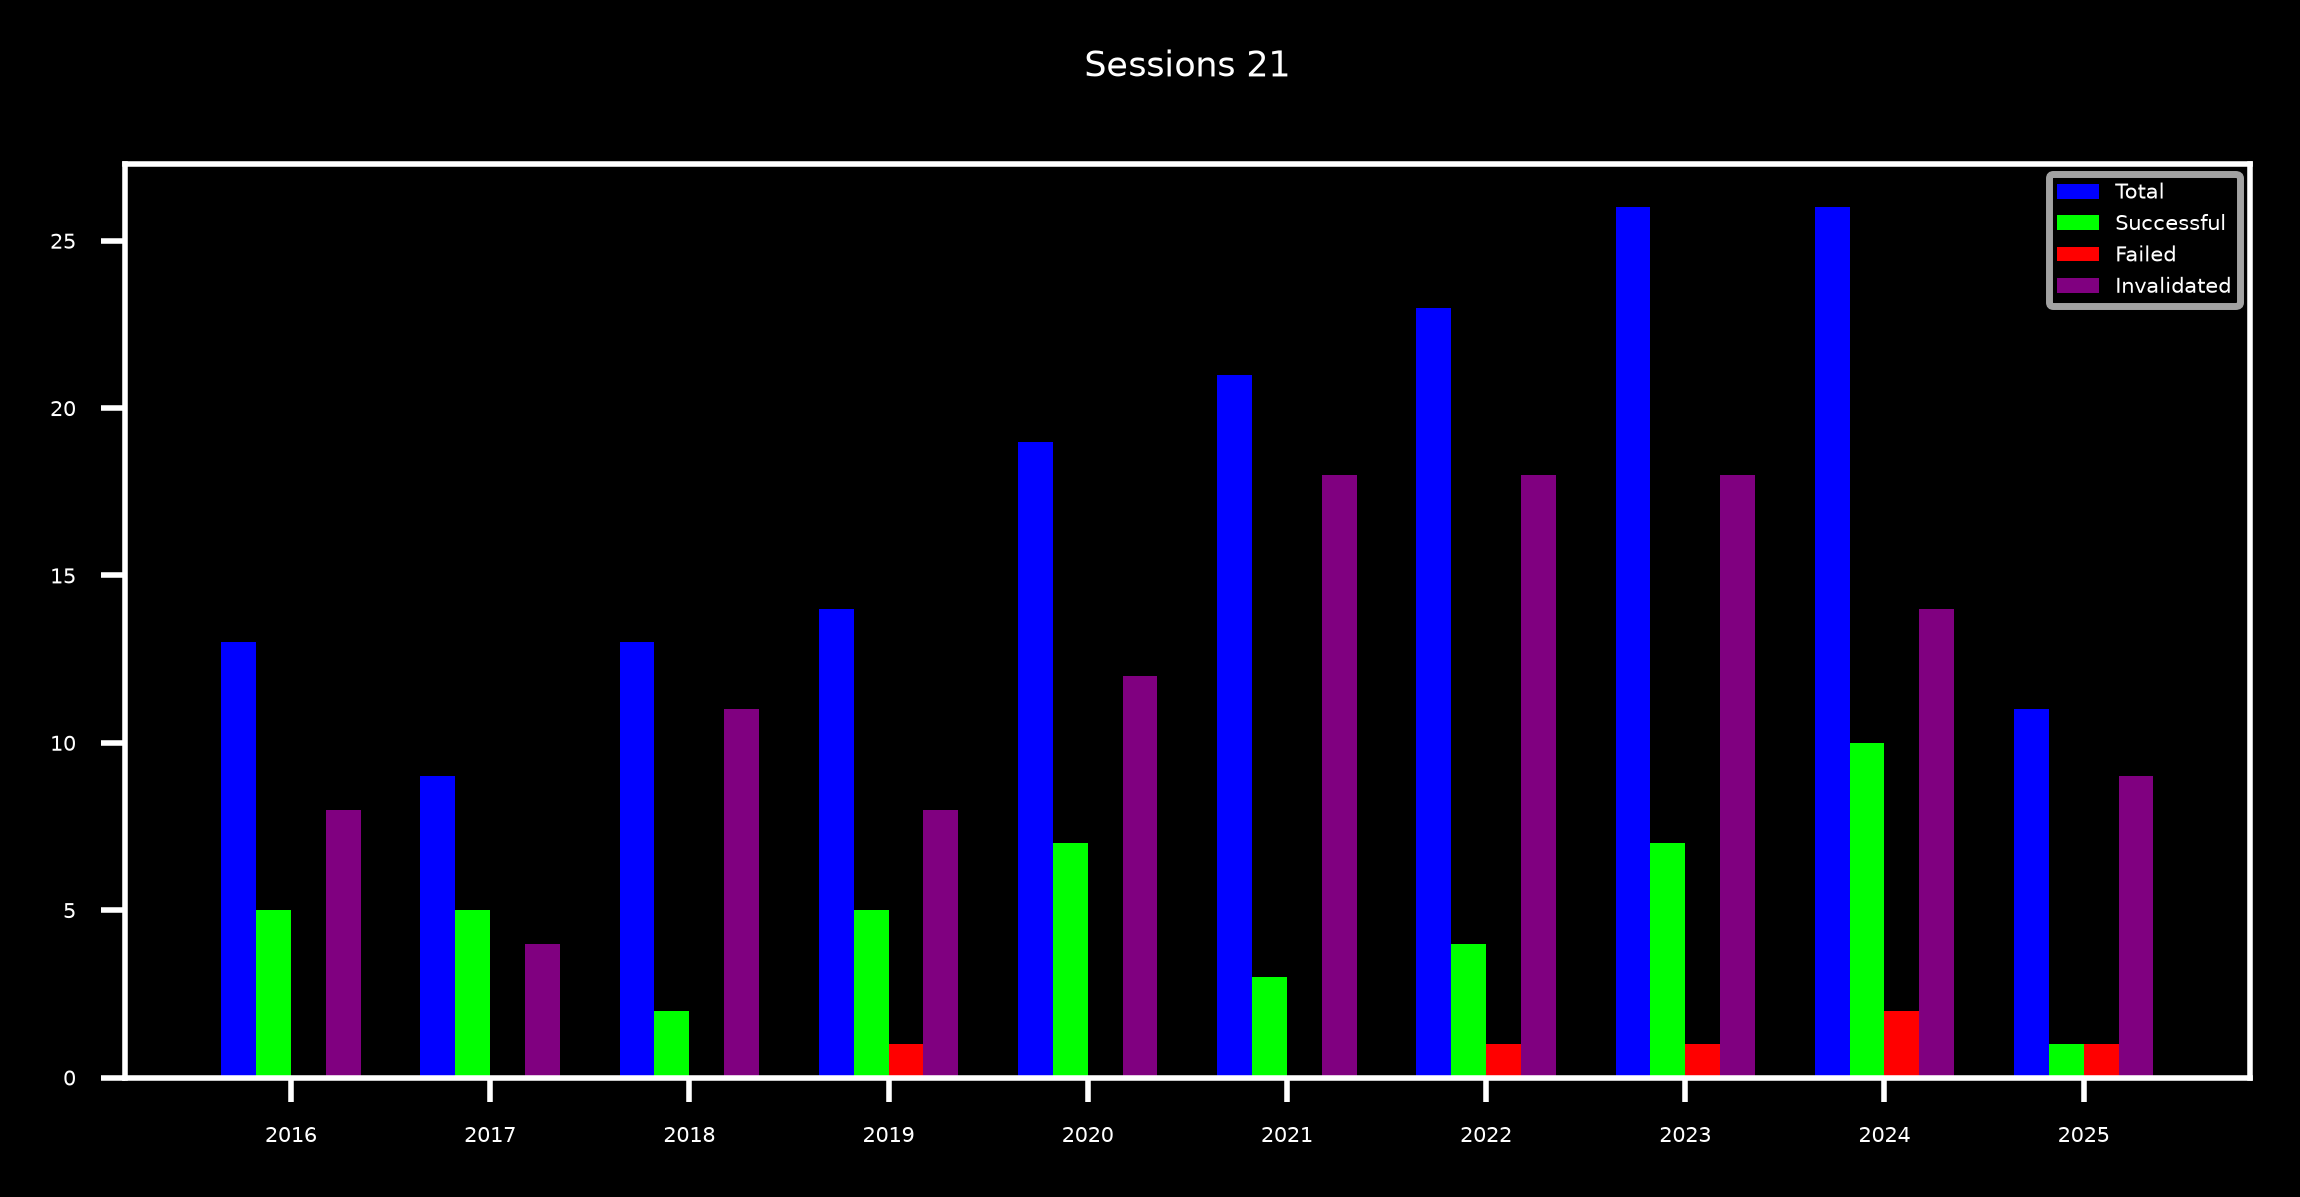

Sessions 22
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  5   │  0   │  8  │  38  │  0   │  61  │ 8.44 │ 10.… │ -7.… │ 5.9… │ -2.… │ 3.81 │ 3.47 │ -15.… │ 0.4… │
│ 2017 │  9   │  5   │  0   │  4  │  55  │  0   │  44  │ 37.… │ 37.… │ -19… │ 5.0… │ -3.… │ 19.4 │ 24.6 │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 11.… │ 7.36 │ -21… │ 1.2x │ -3.… │ -13… │ -10… │ -77.… │ 0.0… │
│ 2019 │  14  │  5   │  1   │  8  │  35  │  7   │  57  │ 12.… │ 17.… │ -8.… │ 3.2… │ -1.… │ 7.77 │ 12.… │ -15.… │ 0.0… │
│ 2020 │  19  │  7   │  0   │ 12  │  36  │  0   │  63  │ 18.7 │ 16.… │ -9.… │ 3.9… │ -2.… │ 7.53 │ 7.68 │ -24.… │ 0.0… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 18.… │ 15.… │ -17… │ 2.2… │ -2.… │ 1.23 │ 1.76 │ -58.… │ 0.7… │
│ 2022 │  23  │  3   │  2   │ 18  │  13  │  8   │  78  │ 8.28 │ 8.53 │ -12… │ 1.7… │ -2.… │ -6.… │ -6.0 │ -70.… │ 0.0… │
│ 2023 │  26  │  7   │  1   │ 18  │  26  │  3   │  69  │ 19.… │ 13.… │ -6.… │ 4.7… │ -1.… │ 9.4  │ 27.3 │ -16.… │ 0.0… │
│ 2024 │  26  │  10  │  2   │ 14  │  38  │  7   │  53  │ 15.… │ 11.… │ -8.… │ 3.4x │ -2.… │ 5.84 │ 11.… │ -33.… │ 0.0… │
│ 2025 │  11  │  1   │  1   │  9  │  9   │  9   │  81  │ 8.73 │ 6.58 │ -7.… │ 2.5… │ -2.… │ -1.… │ -1.… │ -15.… │ 0.81 │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

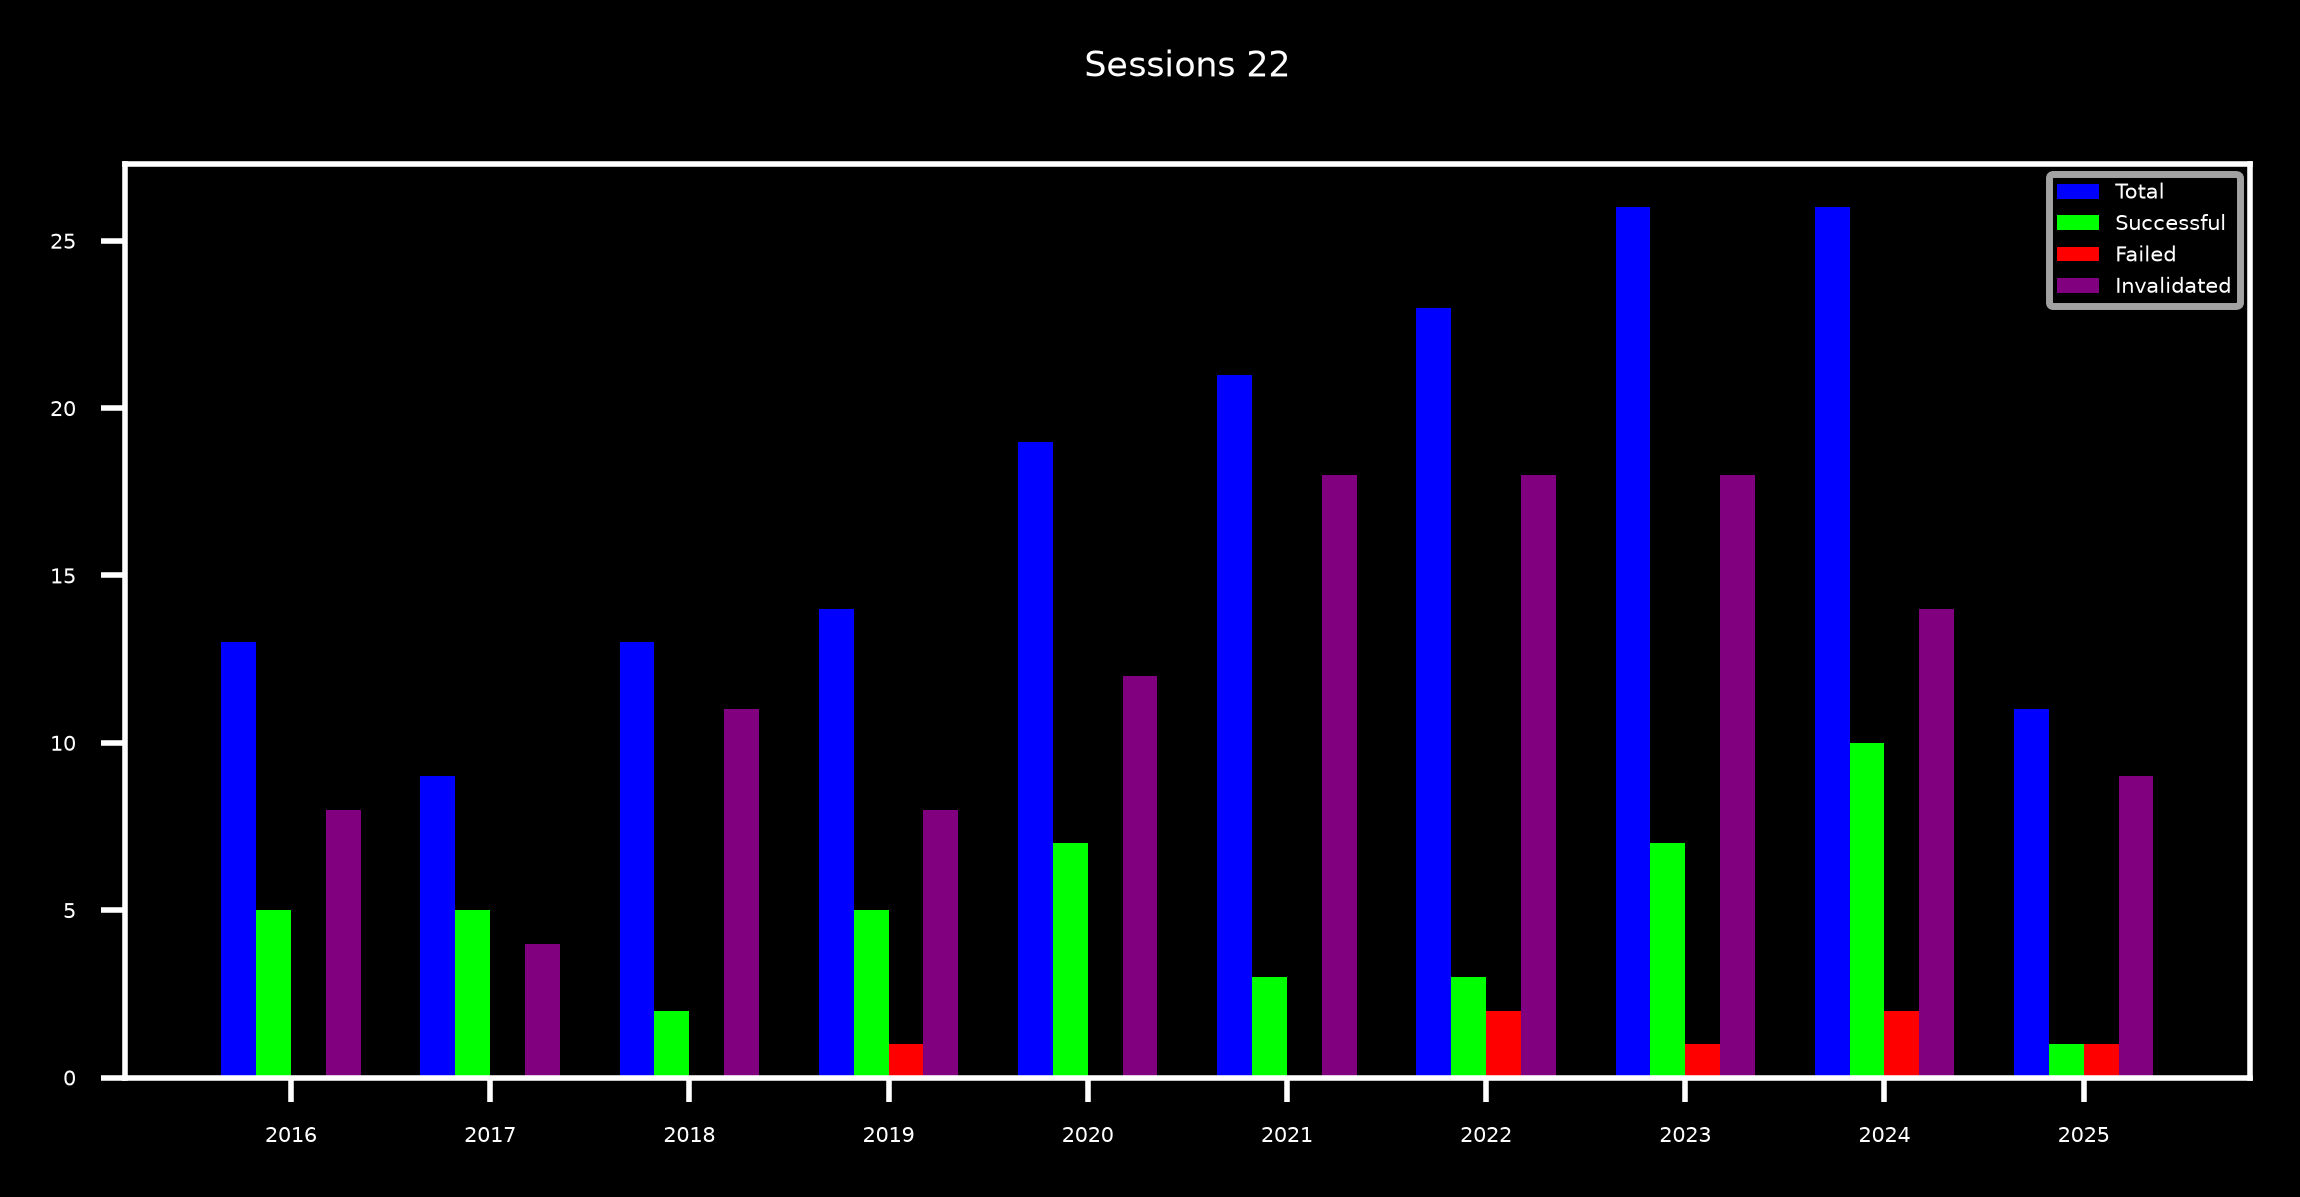

Sessions 23
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  5   │  0   │  8  │  38  │  0   │  61  │ 8.8  │ 10.… │ -7.… │ 6.1… │ -2.… │ 4.53 │ 4.45 │ -15.… │ 0.3… │
│ 2017 │  9   │  5   │  0   │  4  │  55  │  0   │  44  │ 41.… │ 38.… │ -19… │ 5.1x │ -3.… │ 16.… │ 16.… │ 0.0%  │ 0.0… │
│ 2018 │  13  │  2   │  0   │ 11  │  15  │  0   │  84  │ 10.… │ 7.36 │ -22… │ 1.2x │ -4.… │ -12… │ -9.8 │ -78.… │ 0.0… │
│ 2019 │  14  │  5   │  1   │  8  │  35  │  7   │  57  │ 12.… │ 17.… │ -8.… │ 3.3… │ -1.… │ 7.59 │ 11.… │ -15.… │ 0.0… │
│ 2020 │  19  │  7   │  0   │ 12  │  36  │  0   │  63  │ 19.… │ 17.… │ -9.… │ 4.2… │ -2.… │ 7.49 │ 8.66 │ -24.… │ 0.0… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 18.… │ 15.… │ -17… │ 2.2… │ -2.… │ 1.3  │ 1.76 │ -66.… │ 0.7… │
│ 2022 │  23  │  2   │  3   │ 18  │  8   │  13  │  78  │ 9.9  │ 8.65 │ -12… │ 1.7… │ -2.… │ -7.… │ -6.… │ -79.… │ 0.0… │
│ 2023 │  26  │  7   │  0   │ 19  │  26  │  0   │  73  │ 19.… │ 13.… │ -6.… │ 4.7… │ -1.… │ 9.06 │ 19.… │ -19.… │ 0.0… │
│ 2024 │  26  │  9   │  3   │ 14  │  34  │  11  │  53  │ 16.… │ 12.… │ -8.… │ 3.5… │ -2.… │ 5.41 │ 10.… │ -42.… │ 0.0… │
│ 2025 │  11  │  1   │  0   │ 10  │  9   │  0   │  90  │ 8.03 │ 7.14 │ -8.… │ 2.7… │ -2.… │ -2.… │ -2.… │ -17.… │ 0.6… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

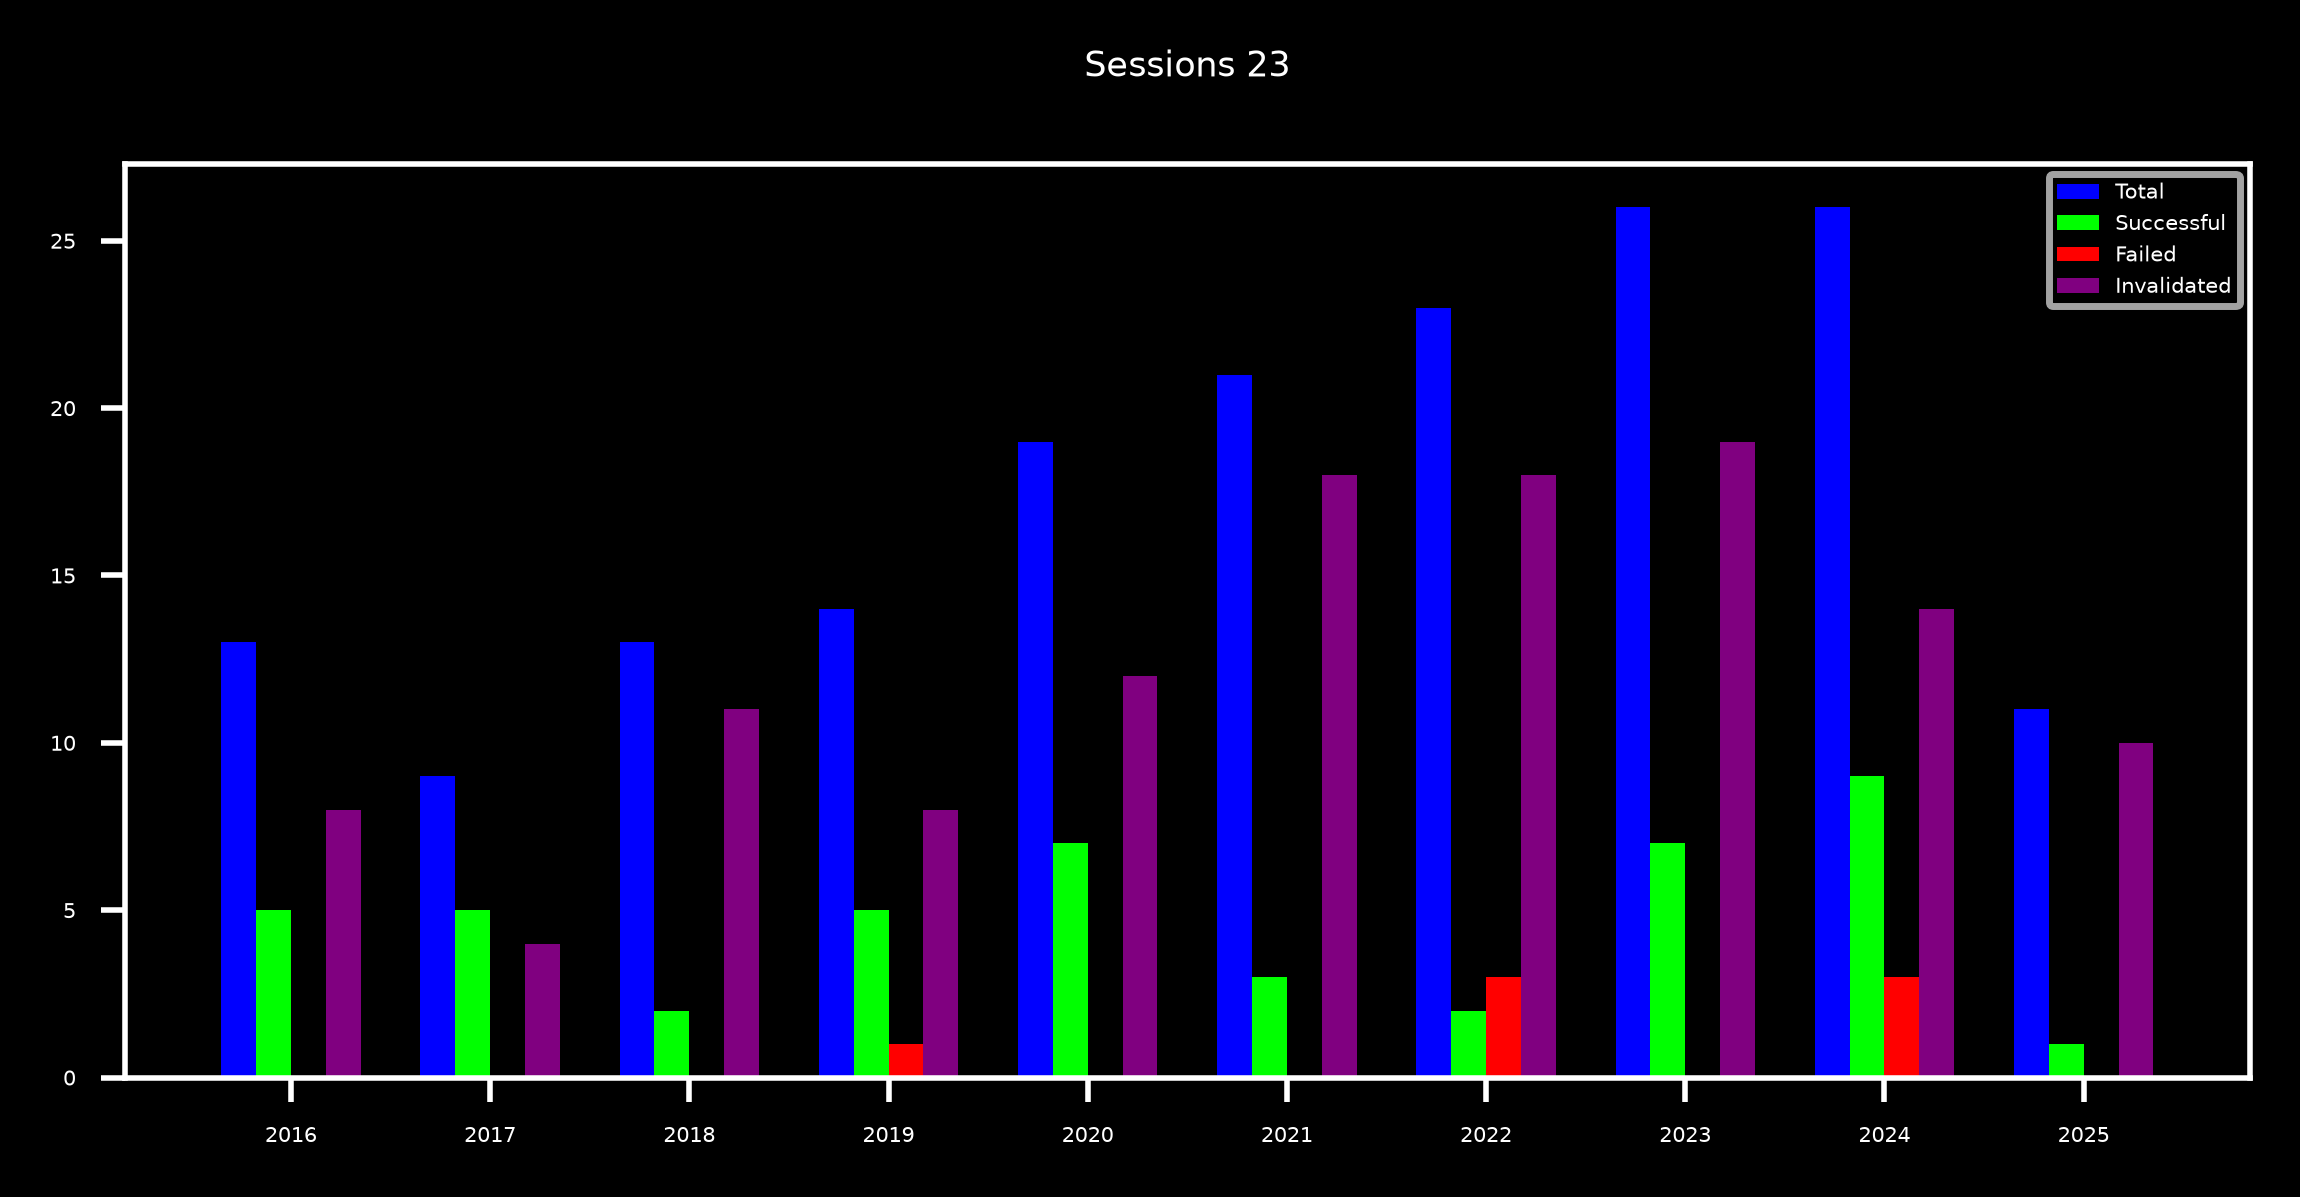

Sessions 24
┏━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┓
┃ Int… ┃ Tot… ┃ Succ ┃ Fail ┃ Inv ┃ Suc… ┃ Fai… ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE% ┃ MFE… ┃ MAE… ┃ Sha… ┃ Sor… ┃ MaxD… ┃ p-v… ┃
┡━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━┩
│ 2016 │  13  │  5   │  0   │  8  │  38  │  0   │  61  │ 9.51 │ 10.… │ -7.… │ 6.5… │ -2.… │ 4.85 │ 4.79 │ -14.… │ 0.2… │
│ 2017 │  9   │  5   │  0   │  4  │  55  │  0   │  44  │ 40.… │ 41.… │ -19… │ 5.6… │ -3.… │ 16.… │ 19.… │ 0.0%  │ 0.0… │
│ 2018 │  13  │  1   │  1   │ 11  │  7   │  7   │  84  │ 24.… │ 7.57 │ -22… │ 1.2… │ -4.… │ -12… │ -10… │ -79.… │ 0.0… │
│ 2019 │  14  │  5   │  1   │  8  │  35  │  7   │  57  │ 18.… │ 19.… │ -8.… │ 3.9… │ -1.… │ 8.98 │ 17.… │ -14.… │ 0.0… │
│ 2020 │  19  │  7   │  0   │ 12  │  36  │  0   │  63  │ 14.… │ 17.… │ -9.… │ 4.3… │ -2.… │ 6.06 │ 5.6  │ -36.… │ 0.1… │
│ 2021 │  21  │  3   │  0   │ 18  │  14  │  0   │  85  │ 17.… │ 15.… │ -17… │ 2.3… │ -2.… │ 1.4  │ 2.03 │ -64.… │ 0.6… │
│ 2022 │  23  │  3   │  2   │ 18  │  13  │  8   │  78  │ 7.81 │ 8.65 │ -13… │ 1.7… │ -2.… │ -7.… │ -6.… │ -76.… │ 0.0… │
│ 2023 │  26  │  7   │  0   │ 19  │  26  │  0   │  73  │ 19.… │ 13.… │ -6.… │ 4.8… │ -1.… │ 8.52 │ 18.4 │ -21.… │ 0.0… │
│ 2024 │  26  │  9   │  2   │ 15  │  34  │  7   │  57  │ 14.… │ 12.… │ -8.… │ 3.7x │ -2.… │ 4.89 │ 8.47 │ -49.… │ 0.1… │
│ 2025 │  11  │  1   │  0   │ 10  │  9   │  0   │  90  │ 8.34 │ 7.26 │ -8.… │ 2.8… │ -2.… │ -1.… │ -2.… │ -16.… │ 0.7… │
└──────┴──────┴──────┴──────┴─────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴──────┴───────┴──────┘

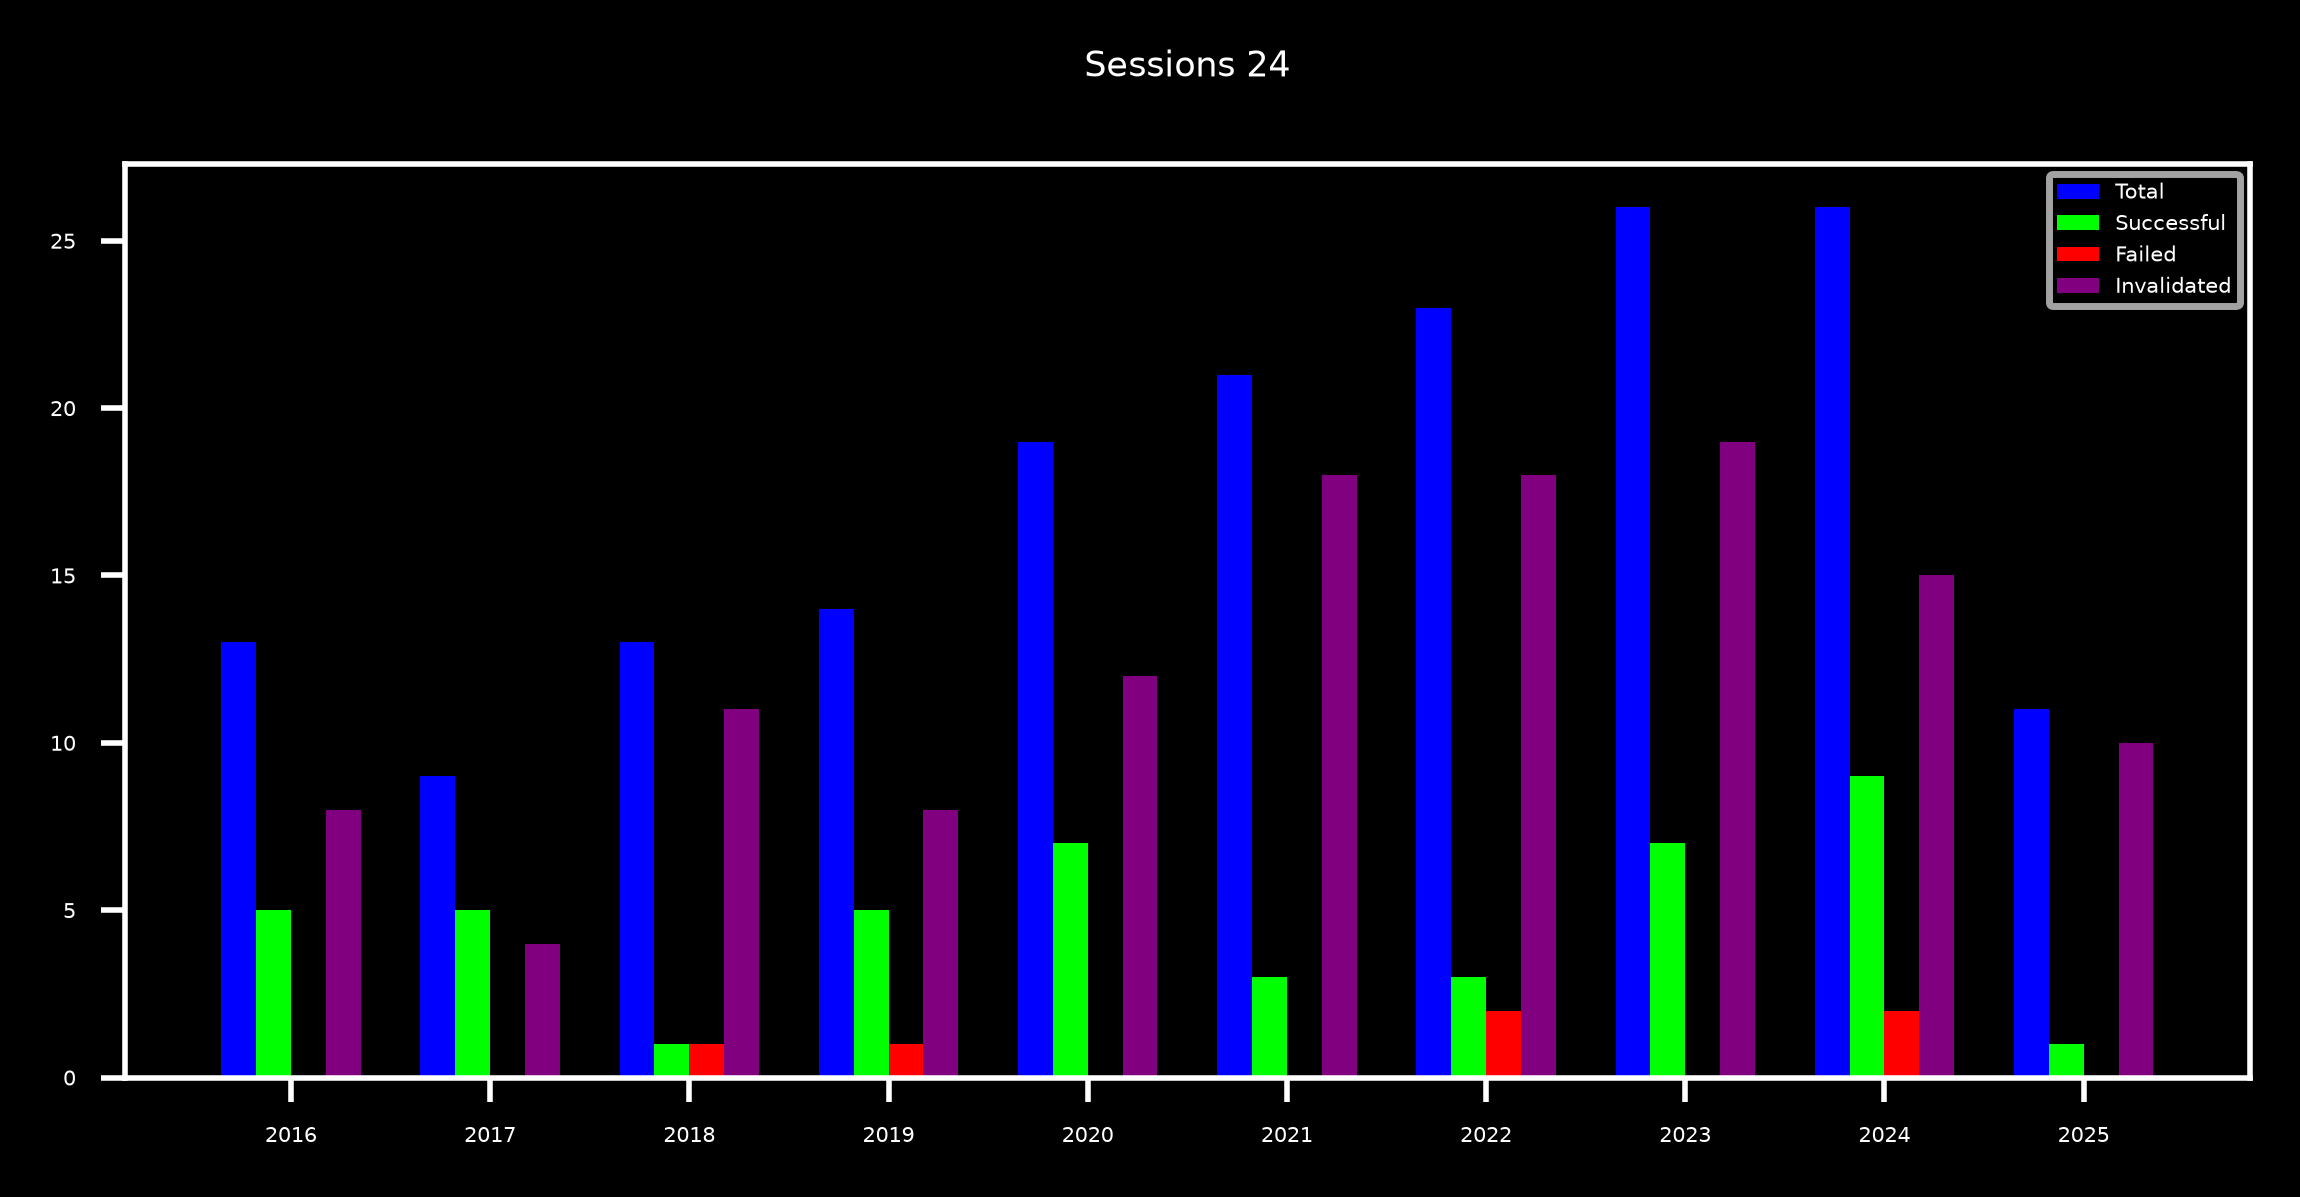

In [9]:
engine.show_stats_per_session()

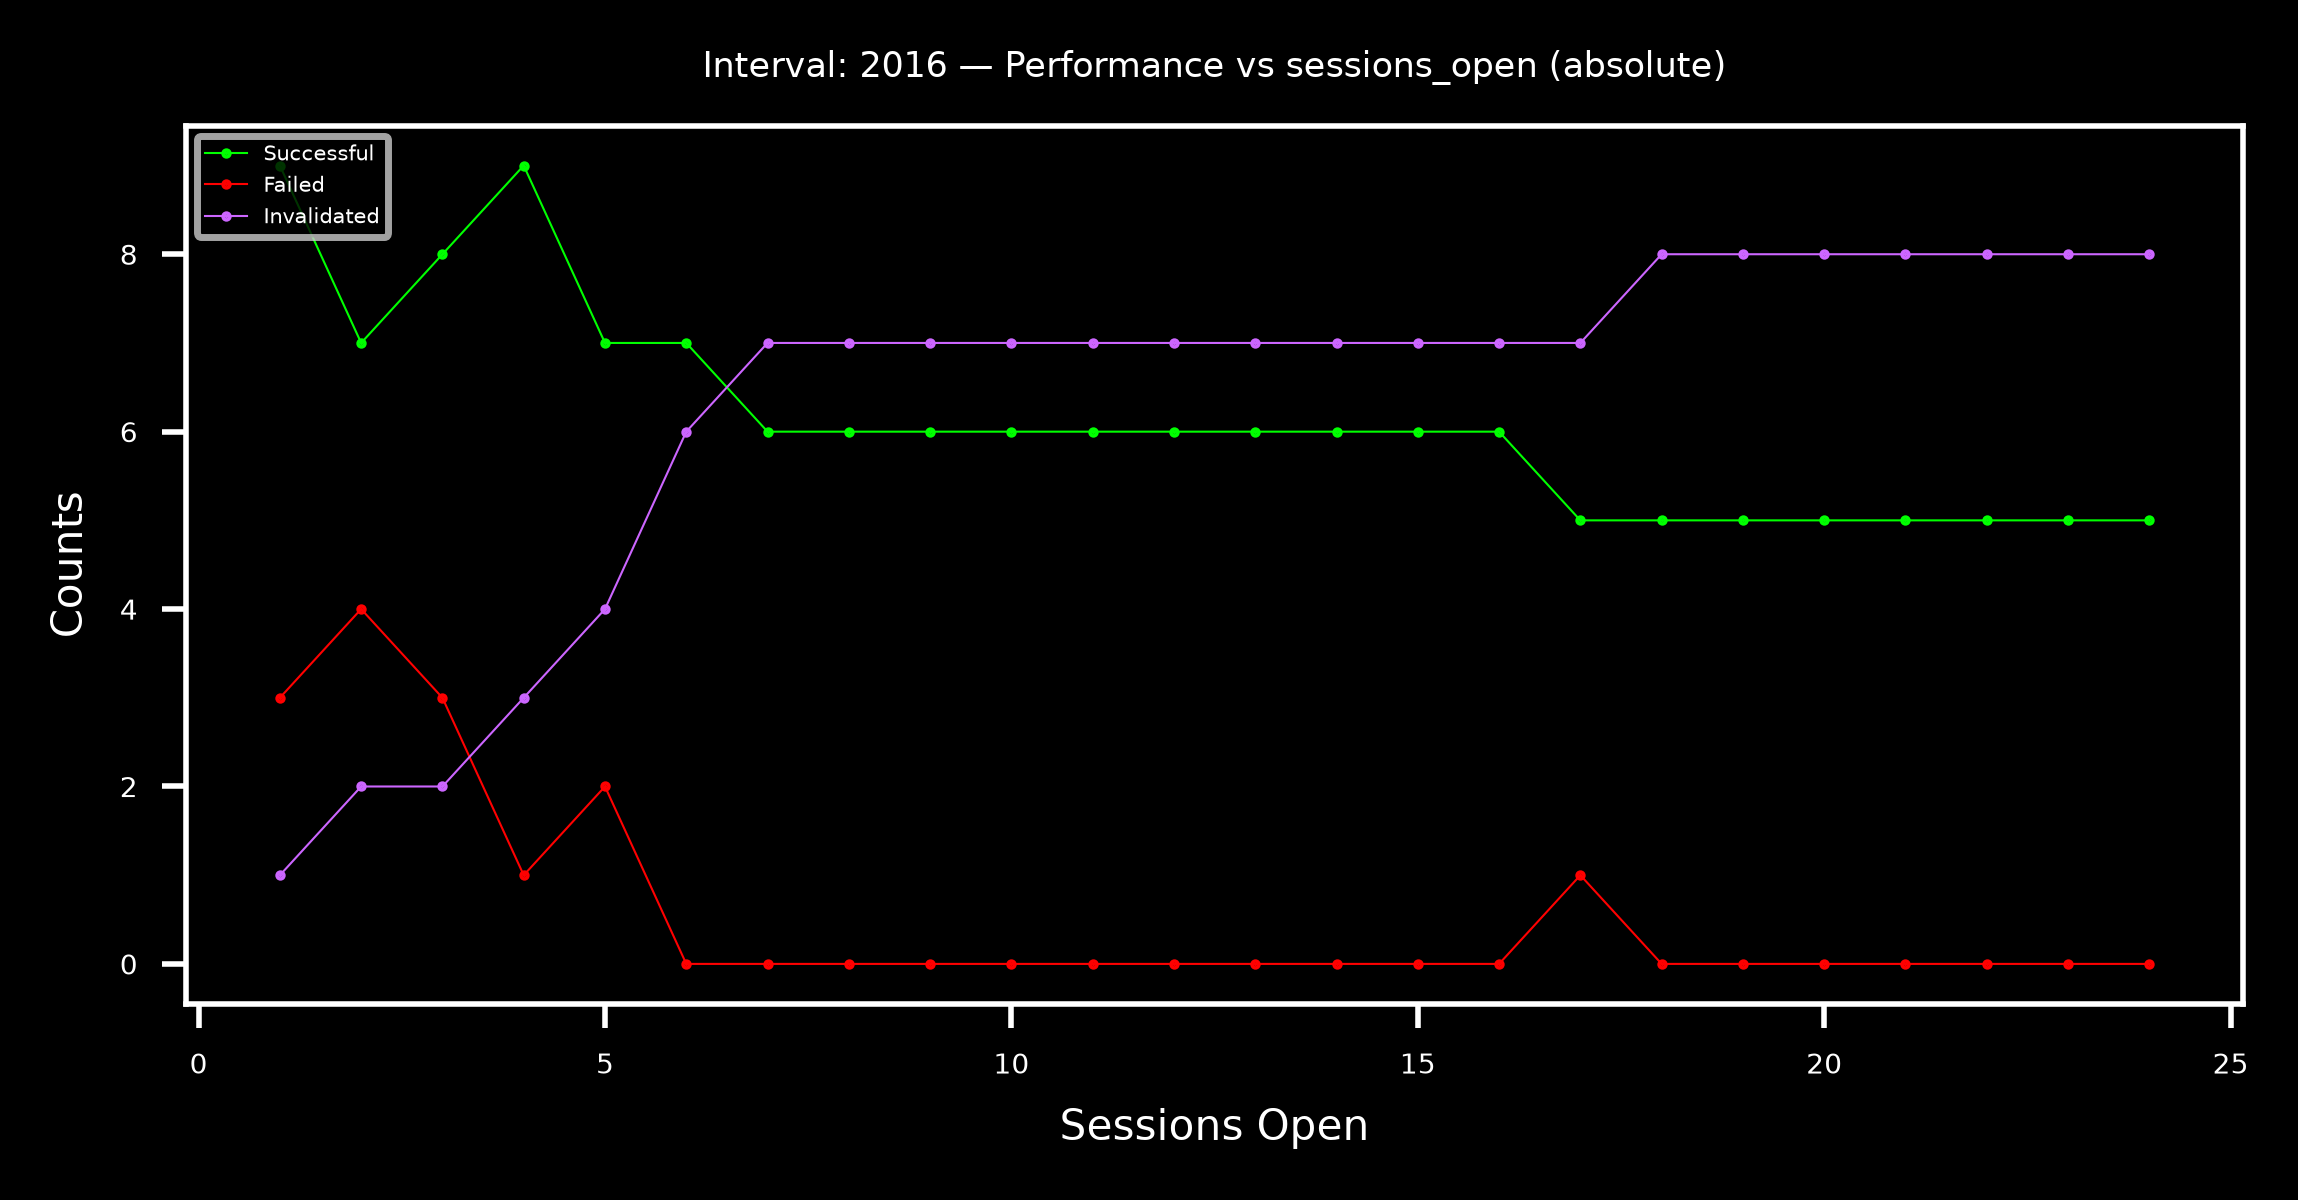

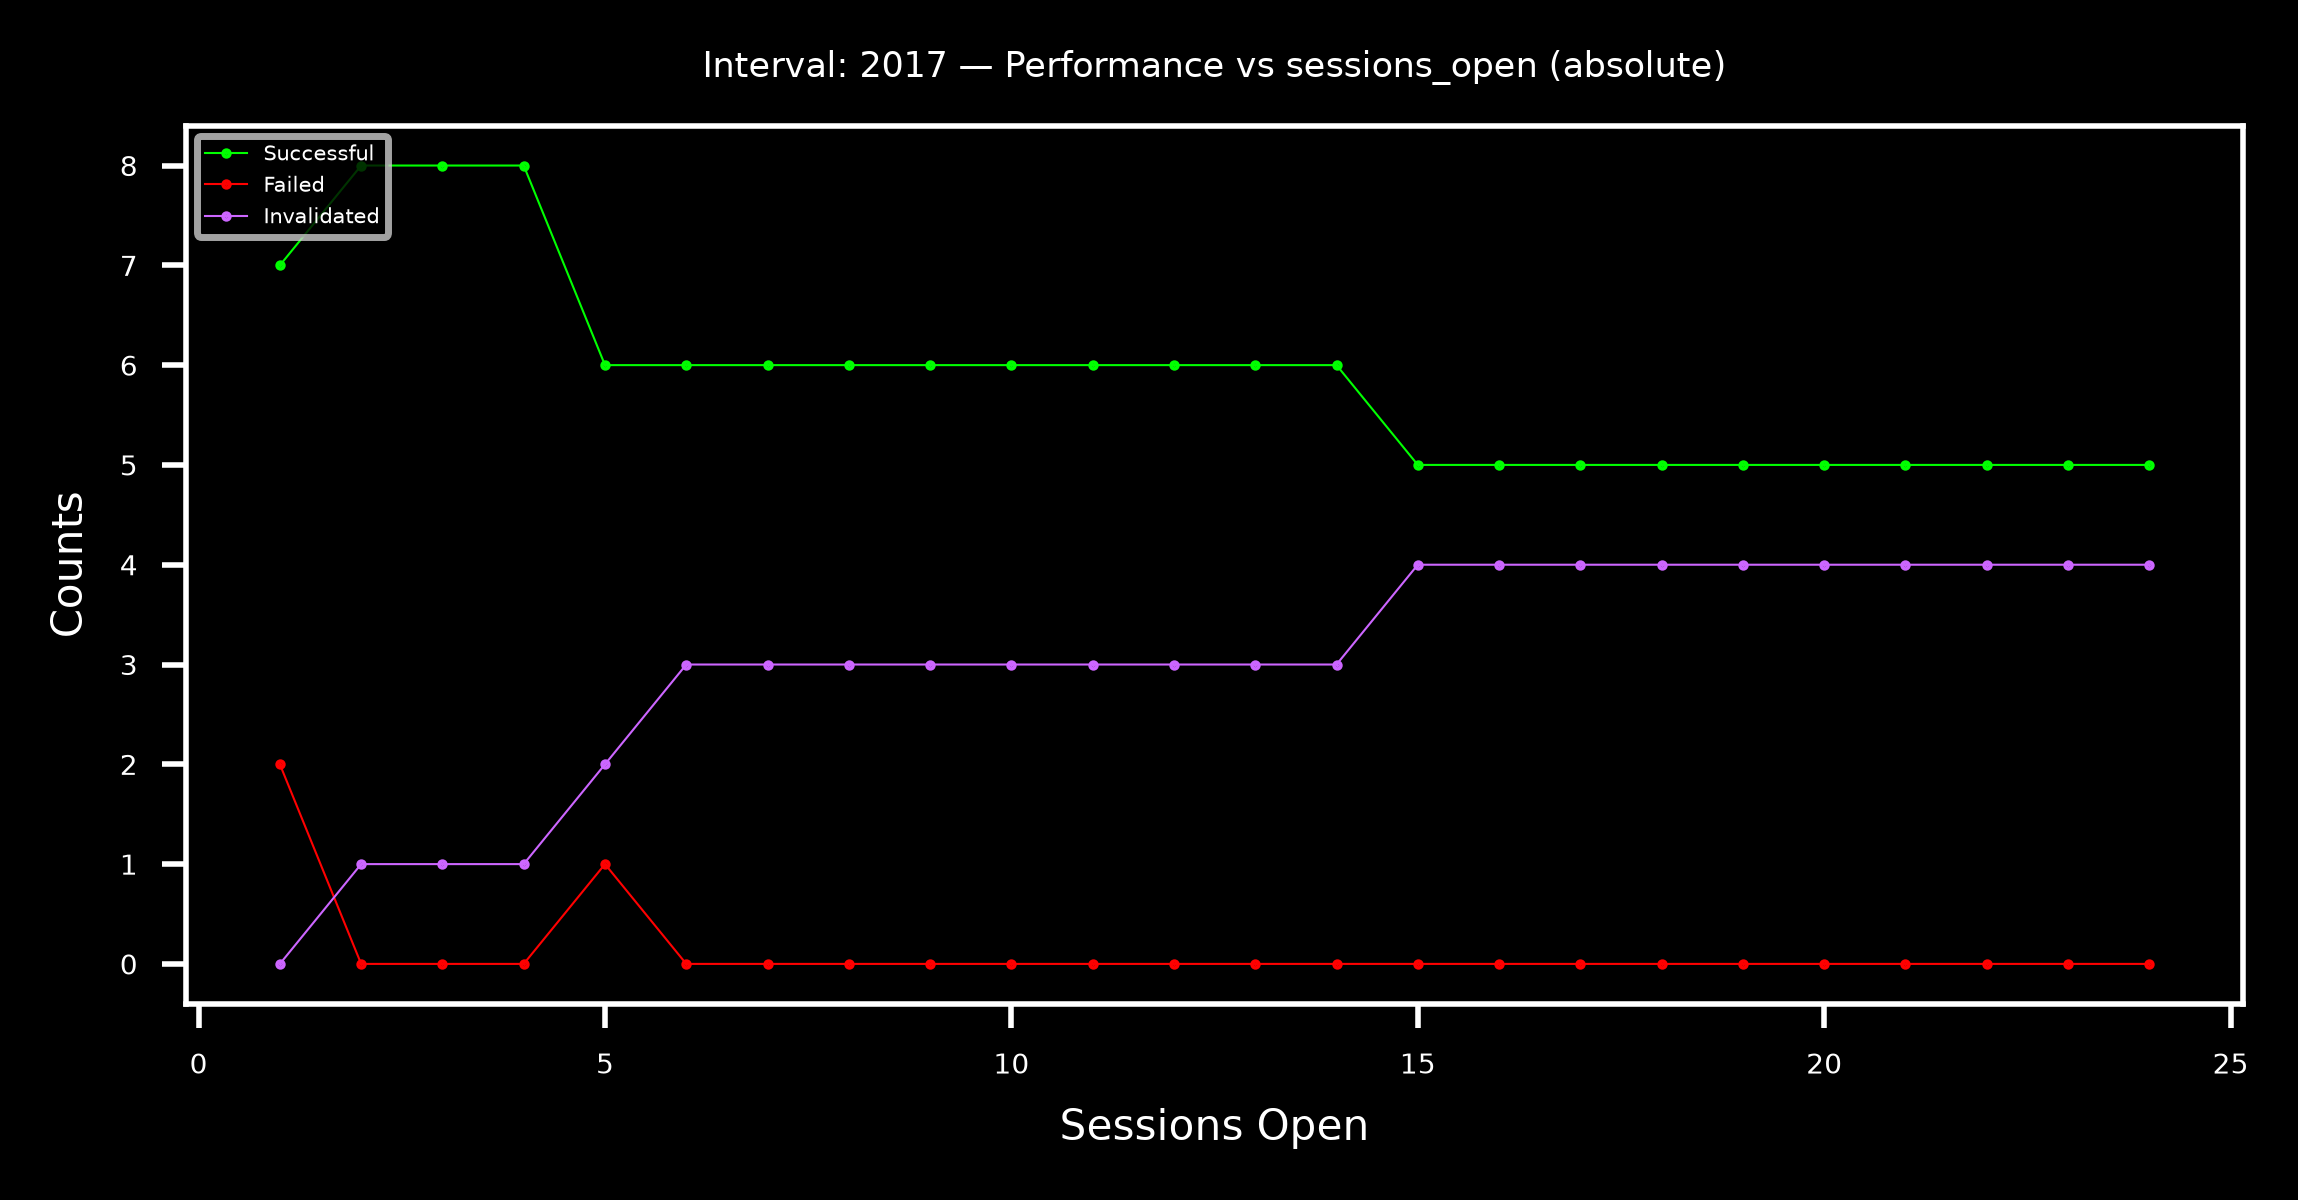

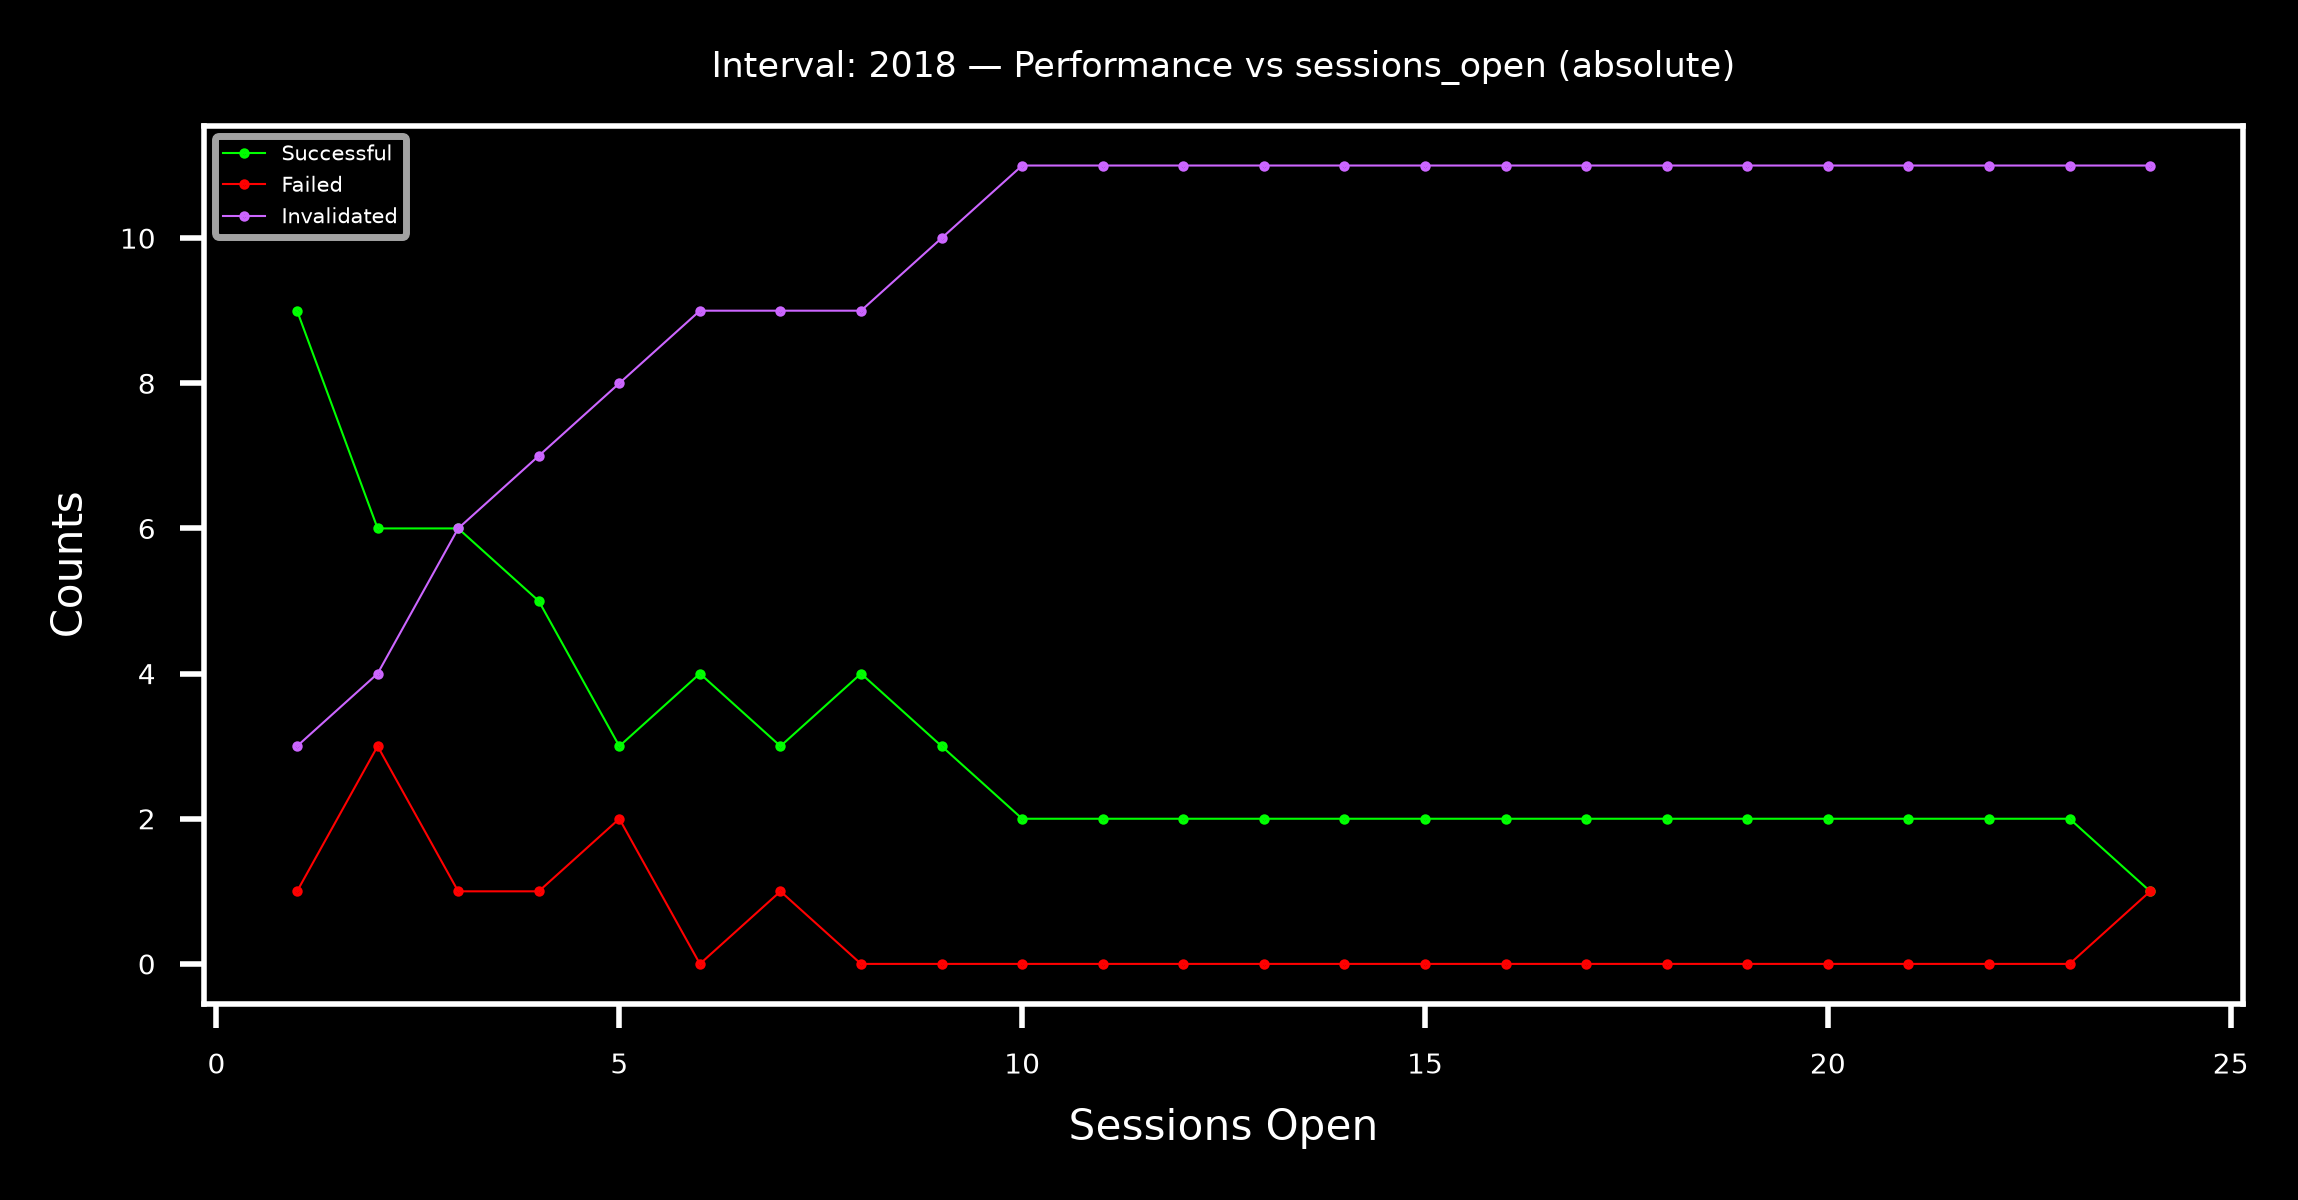

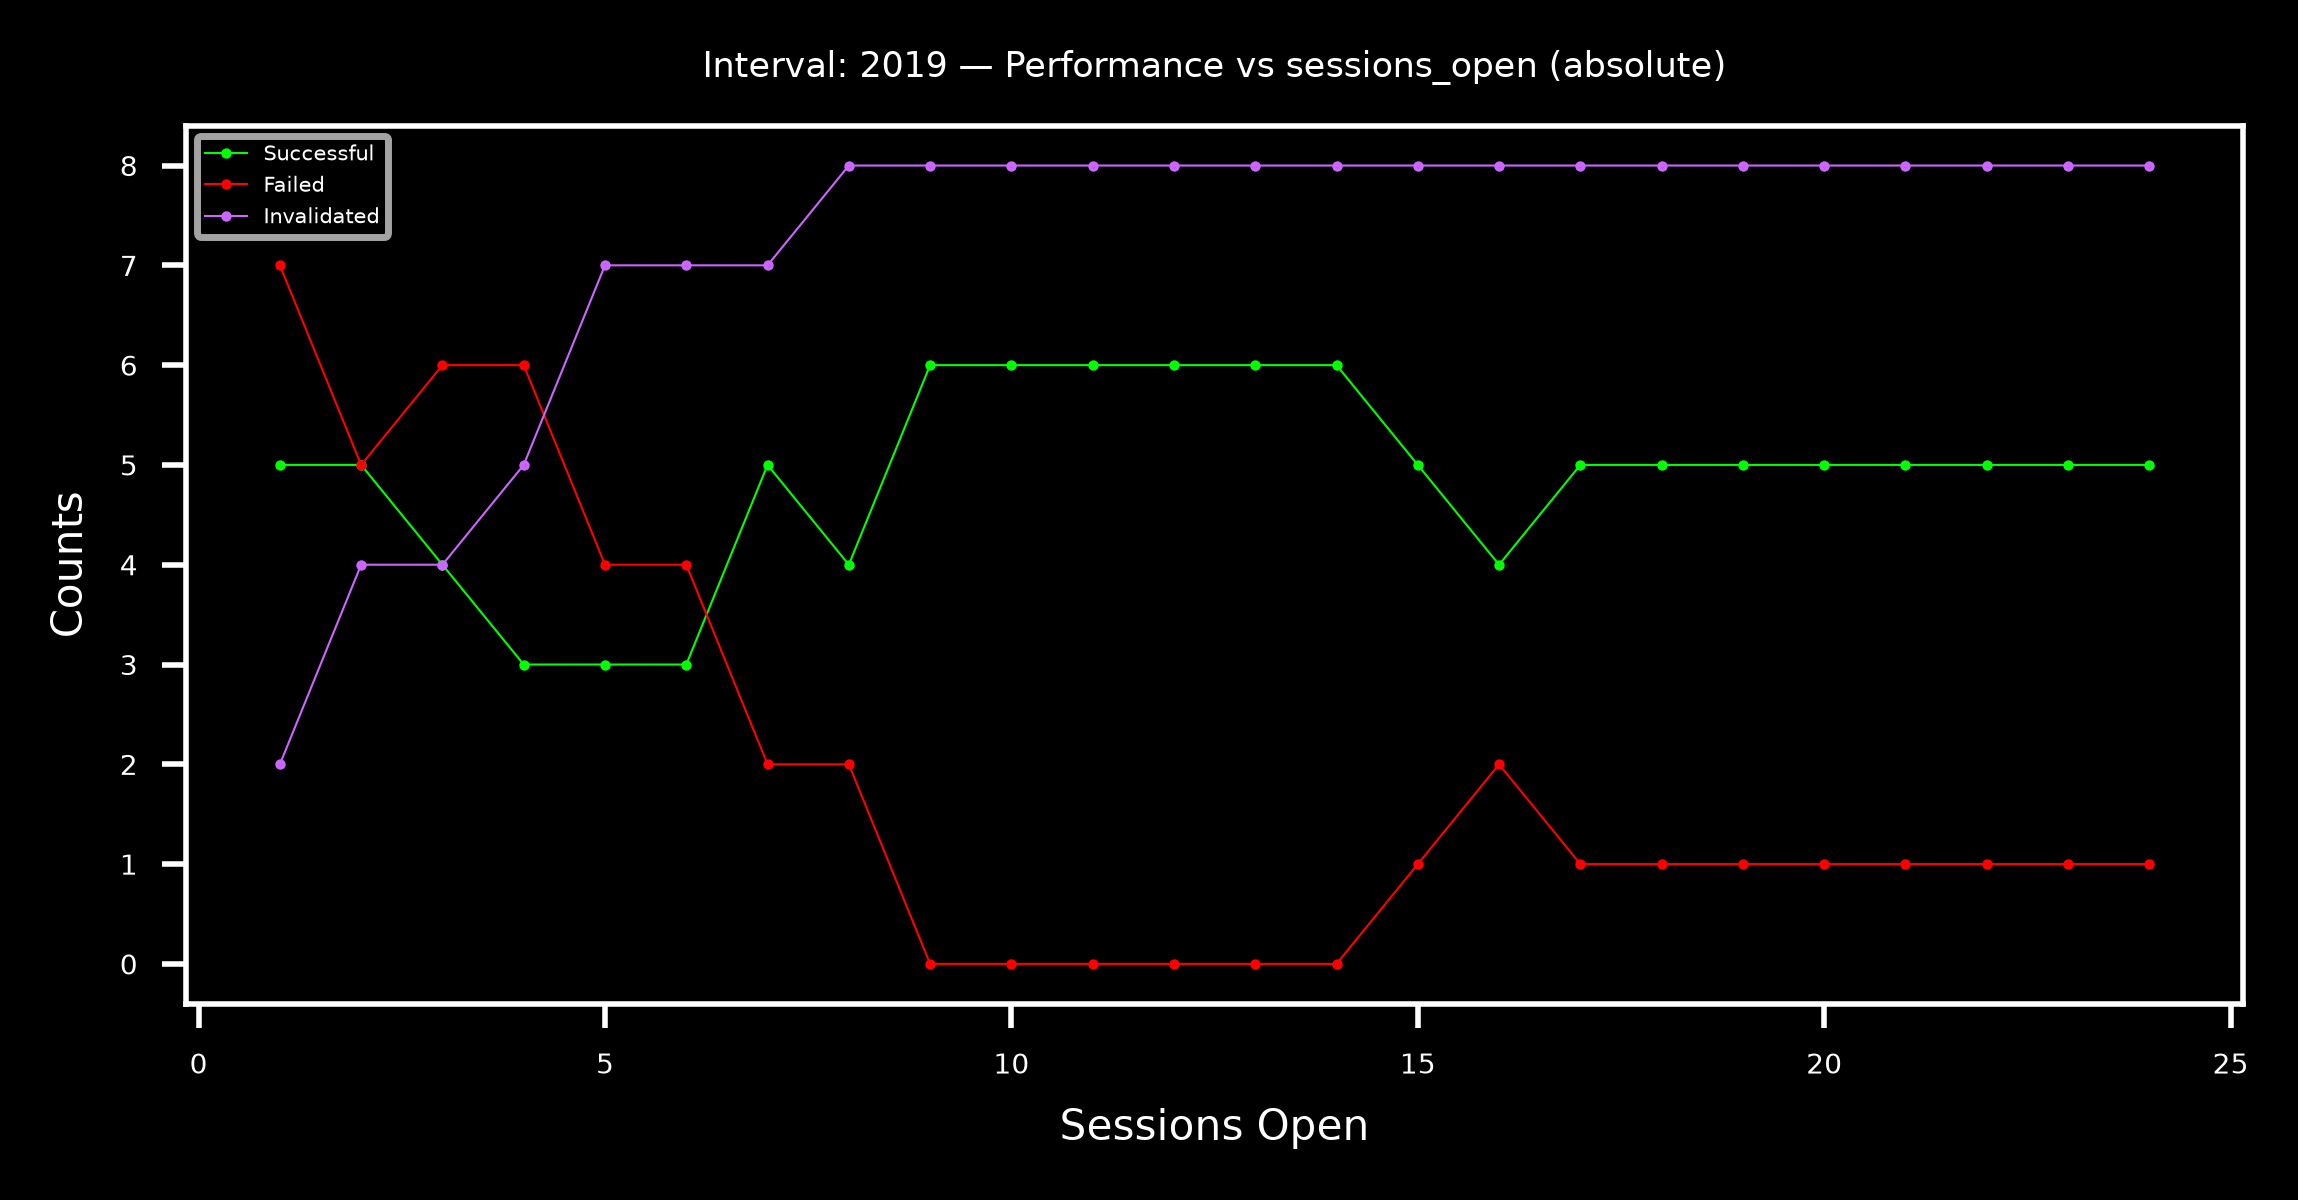

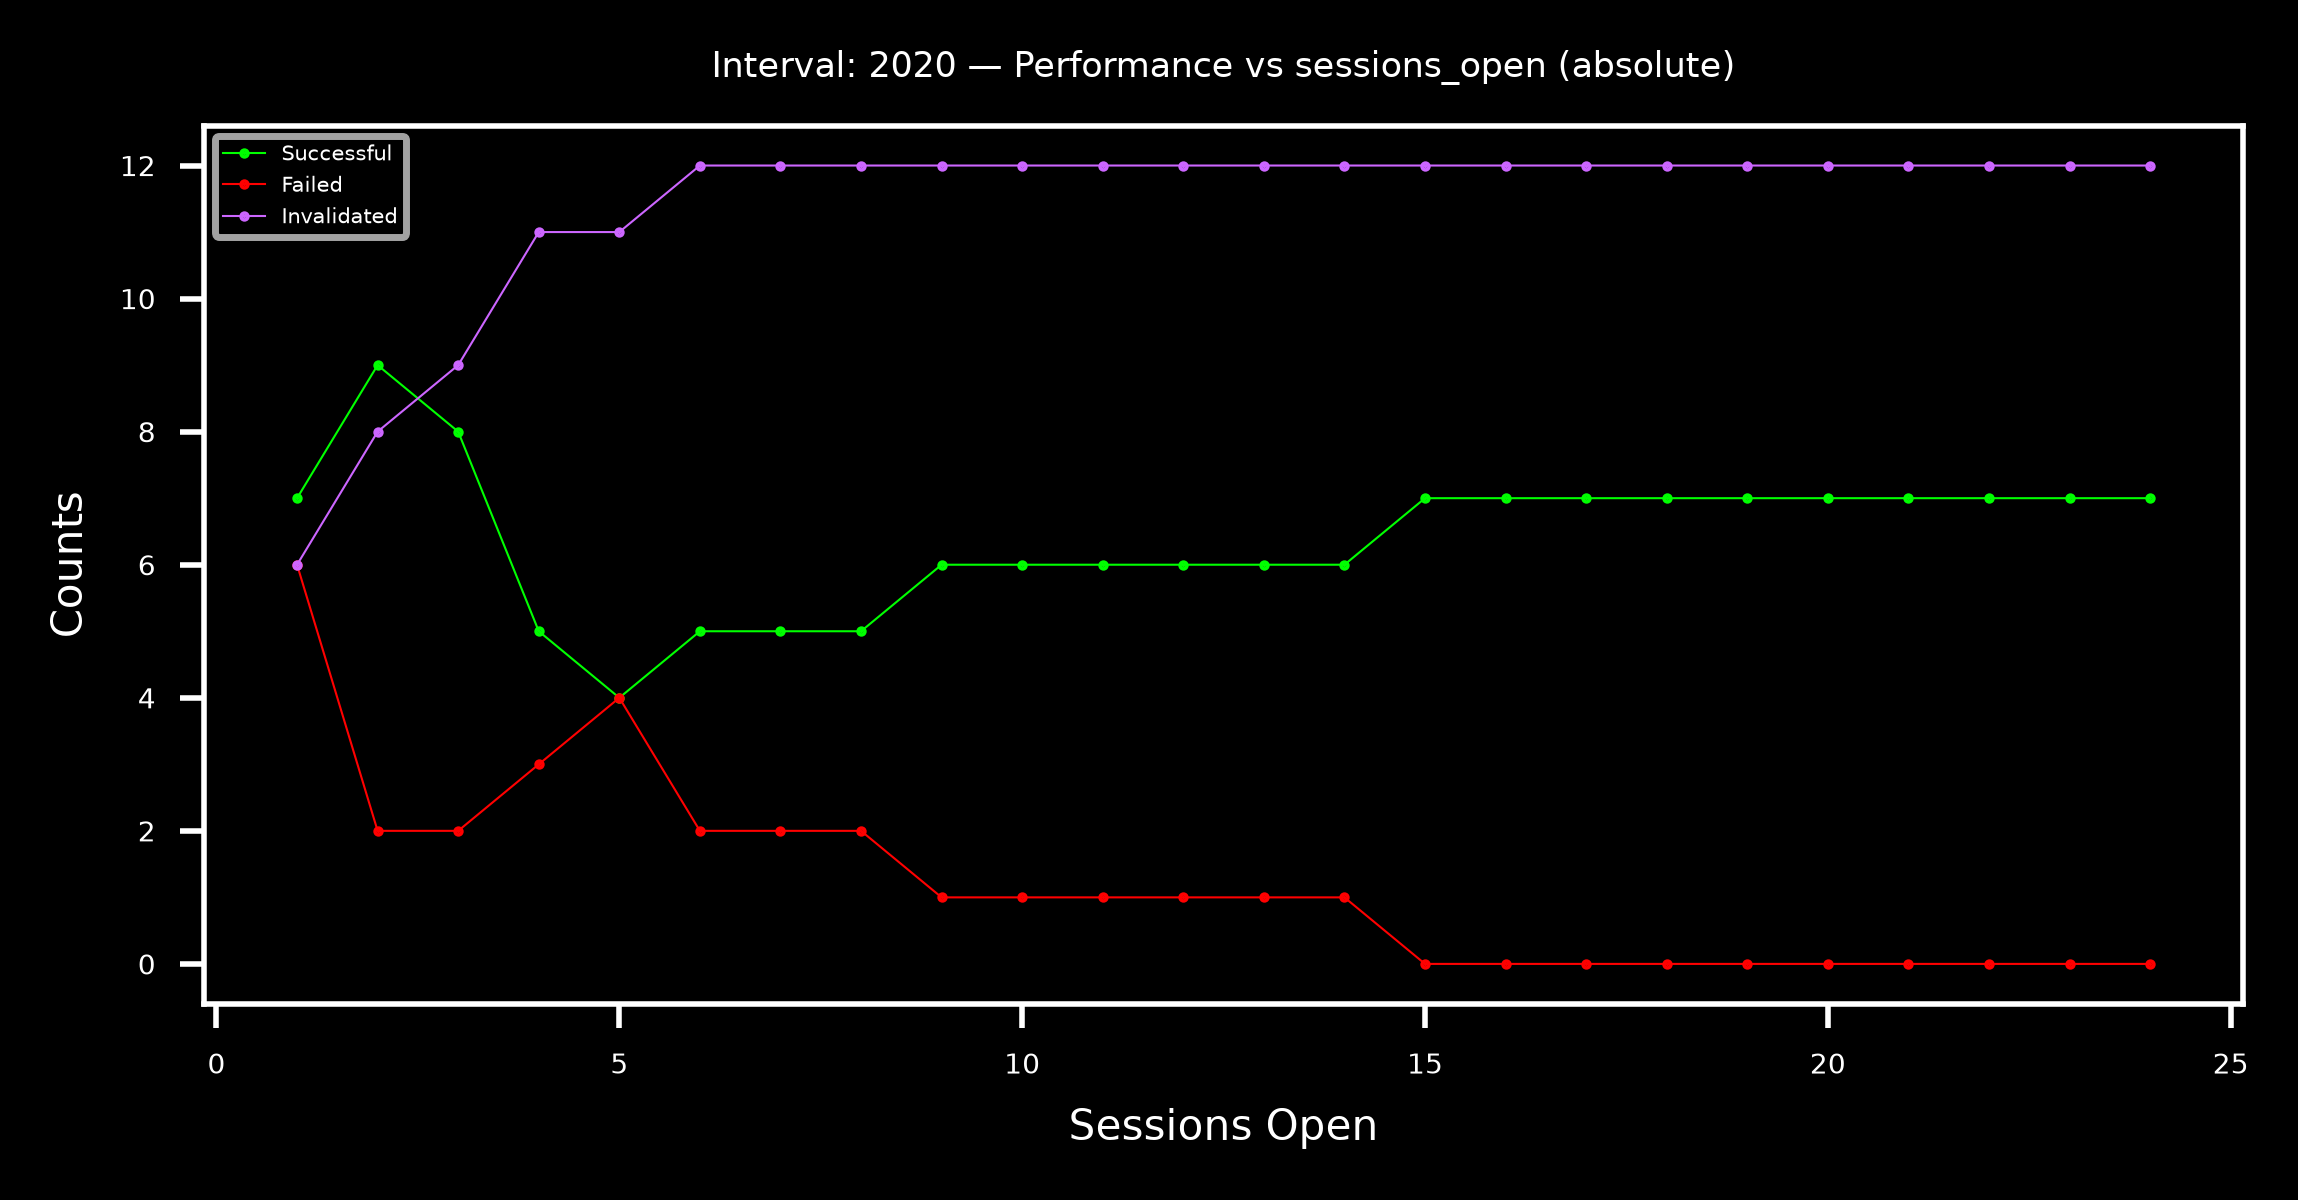

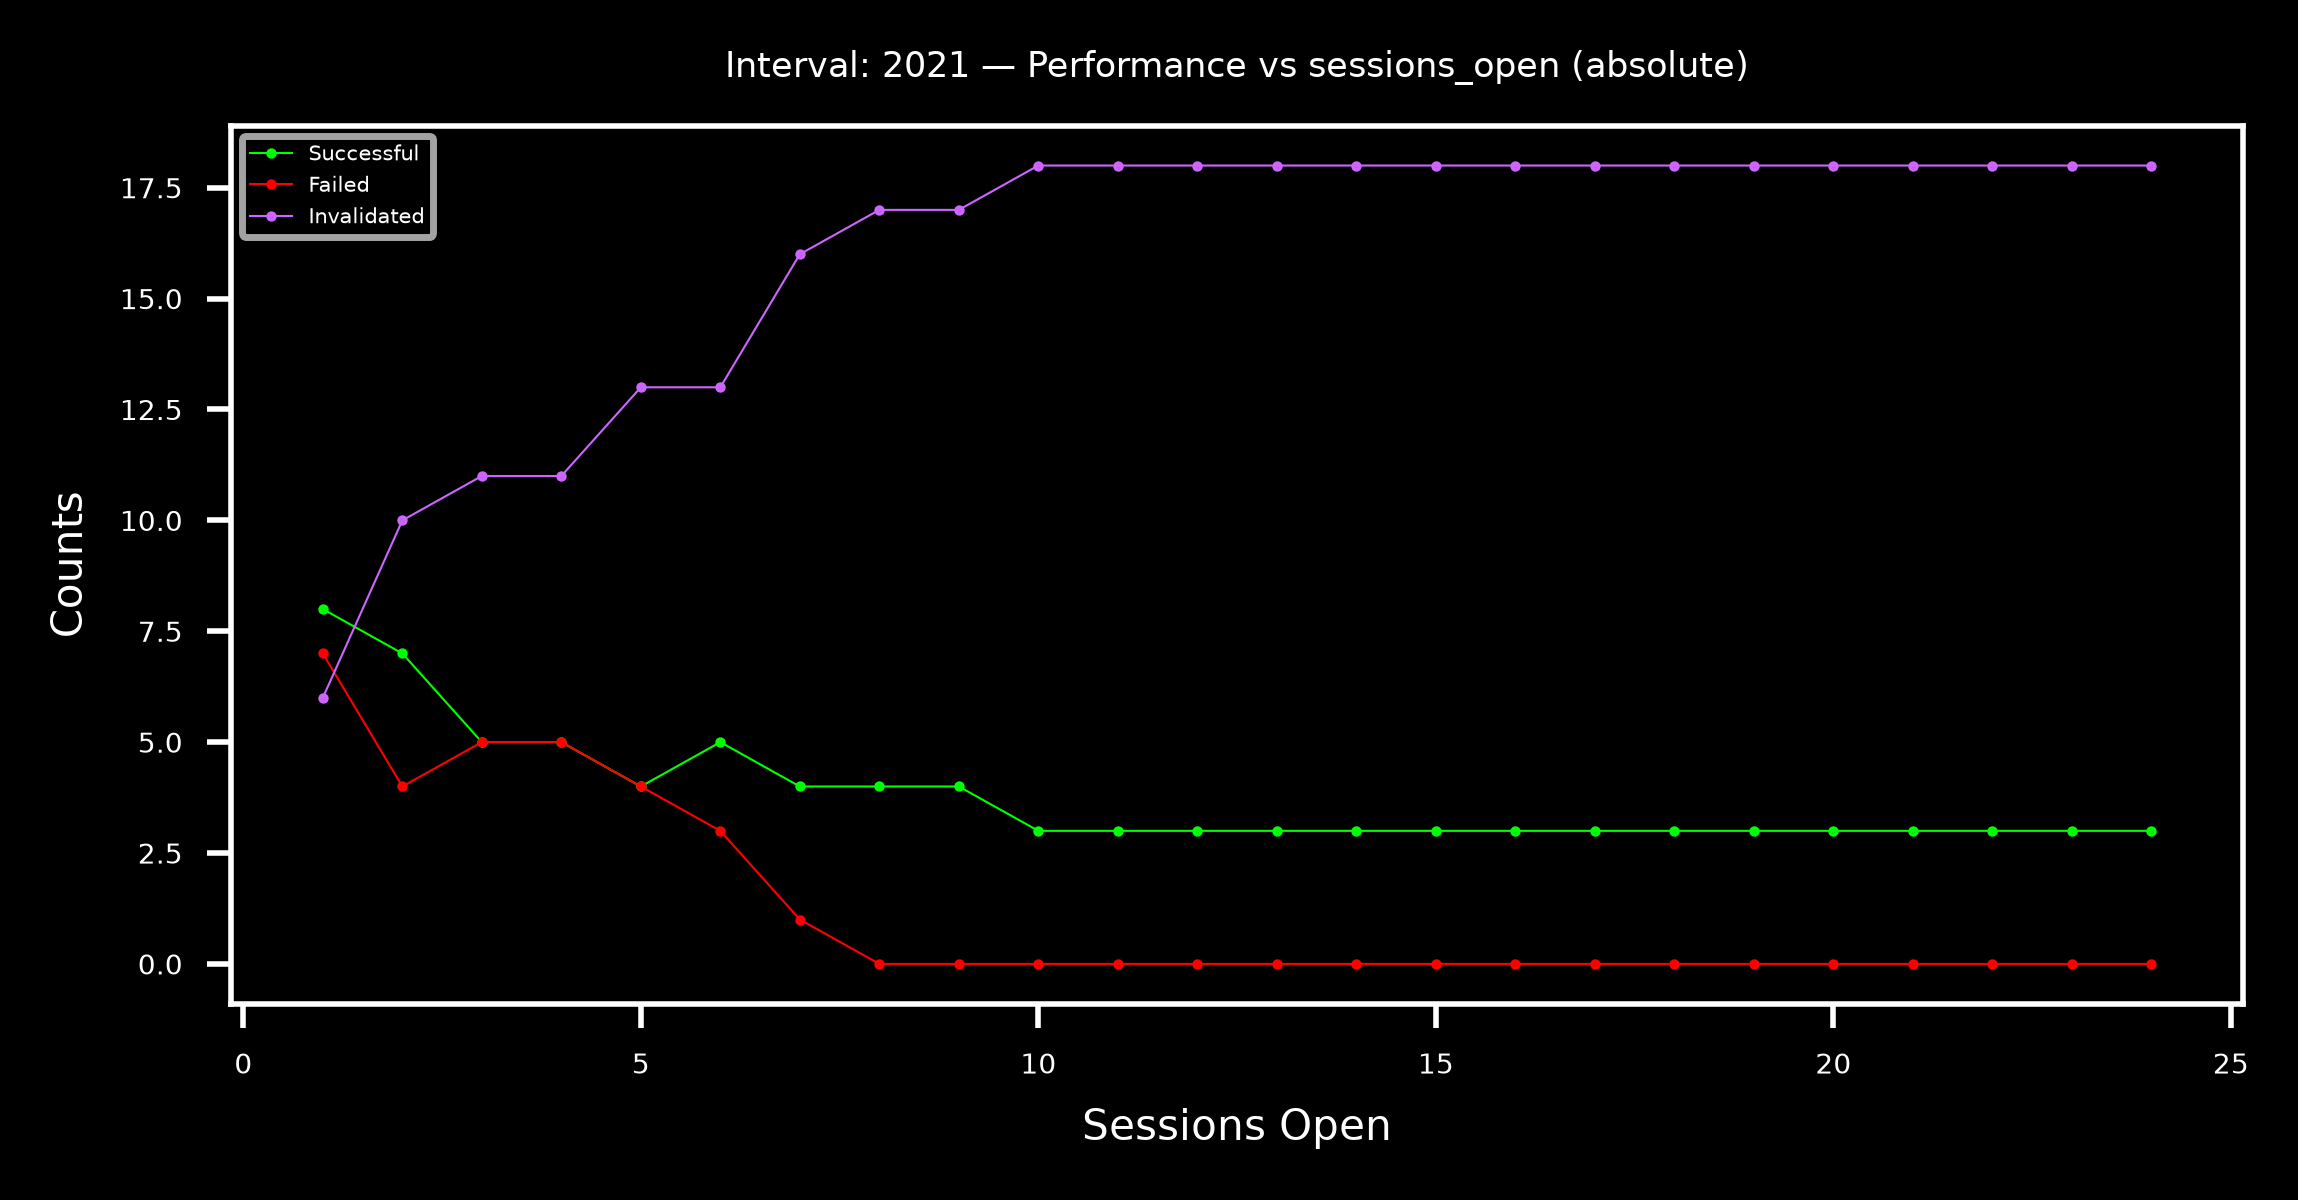

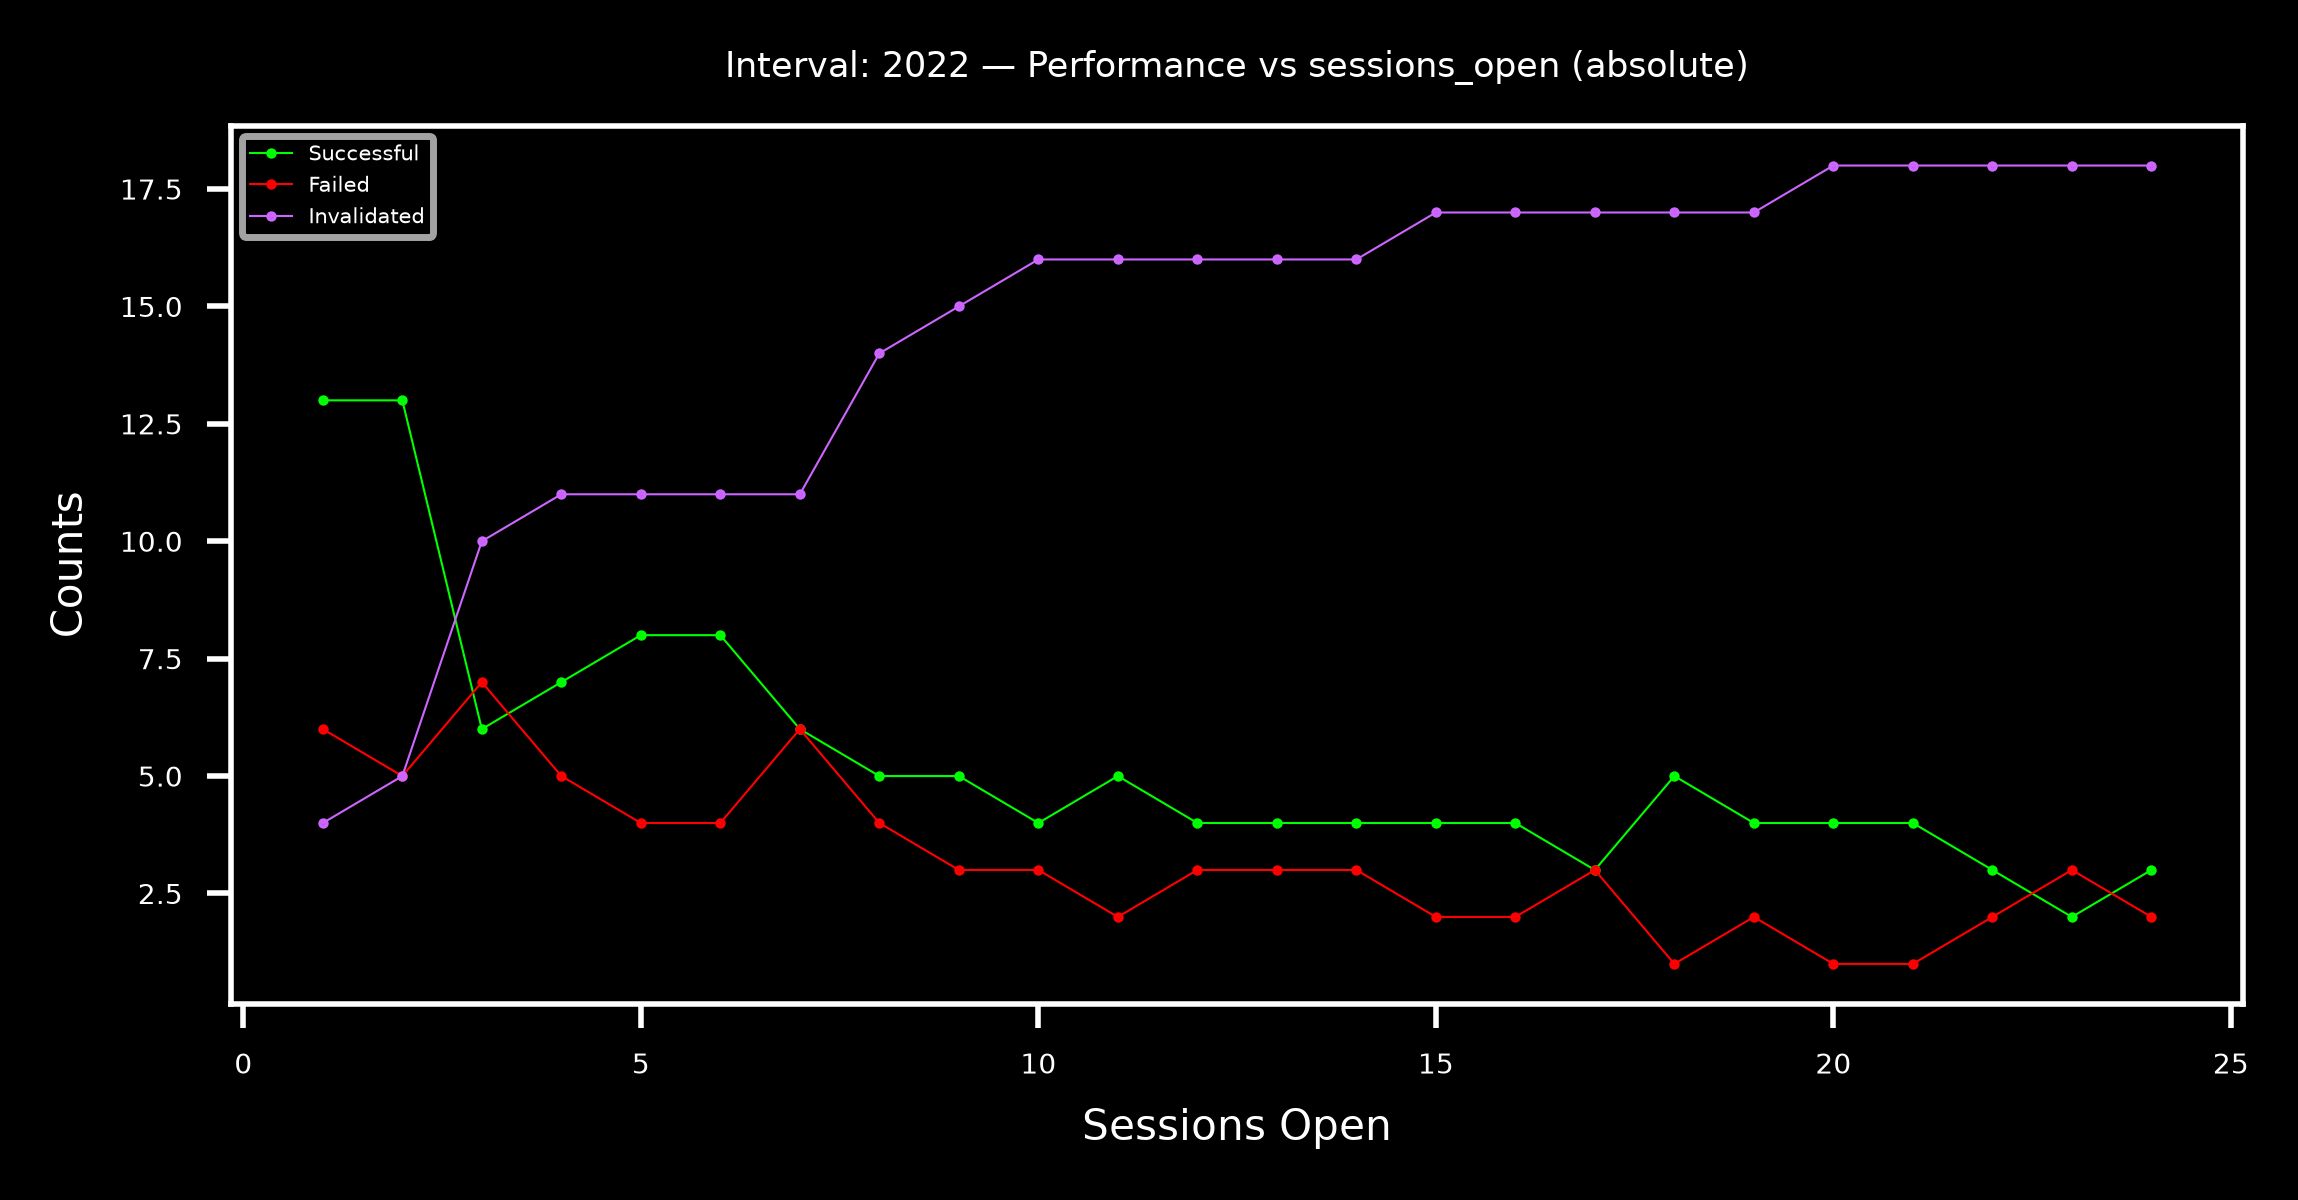

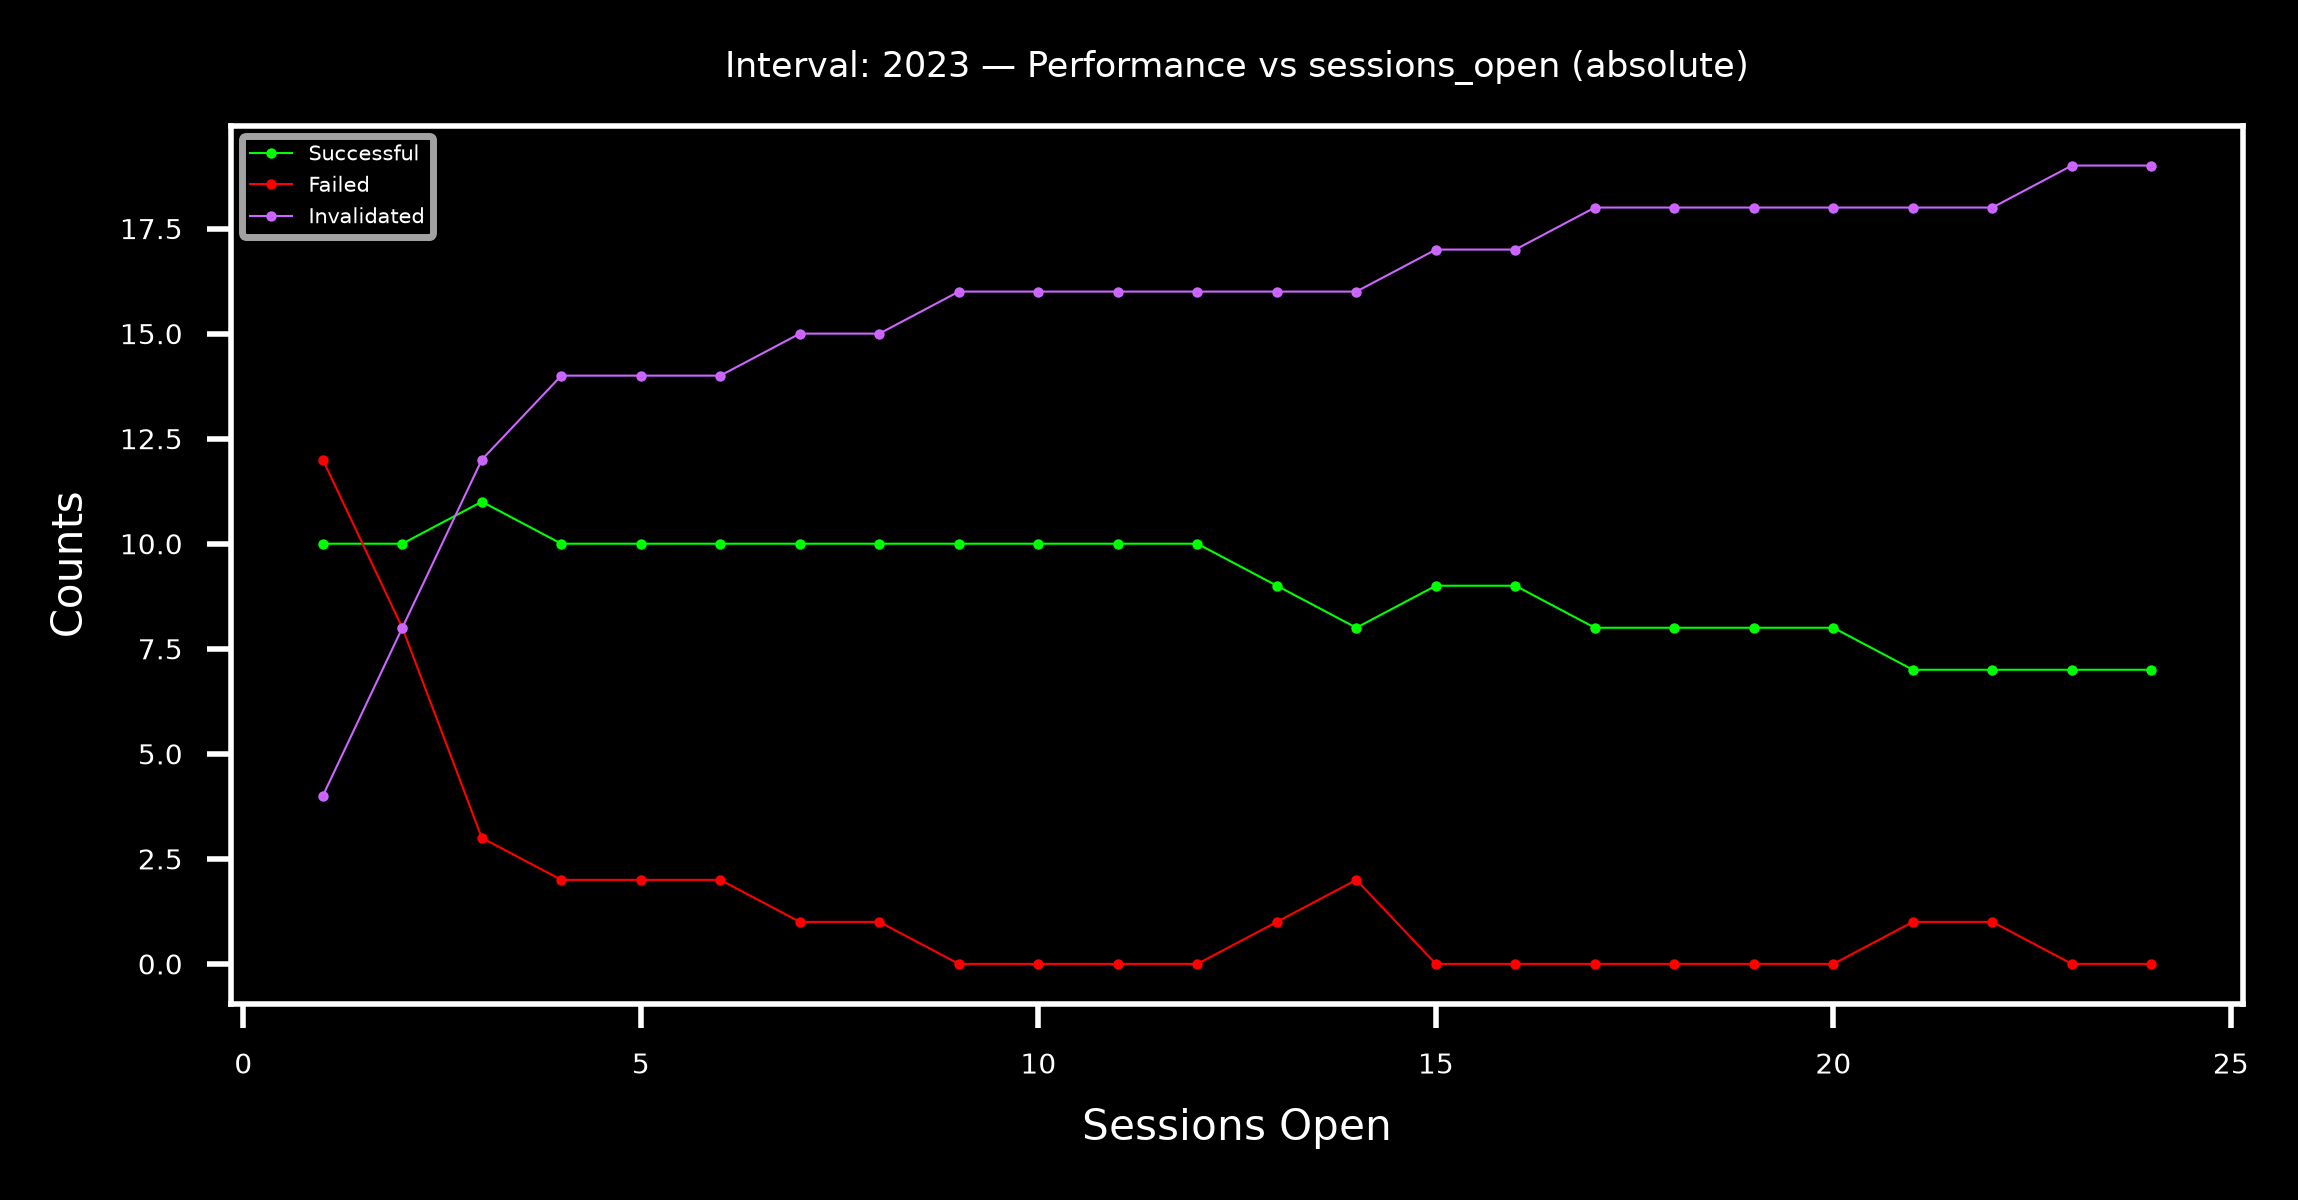

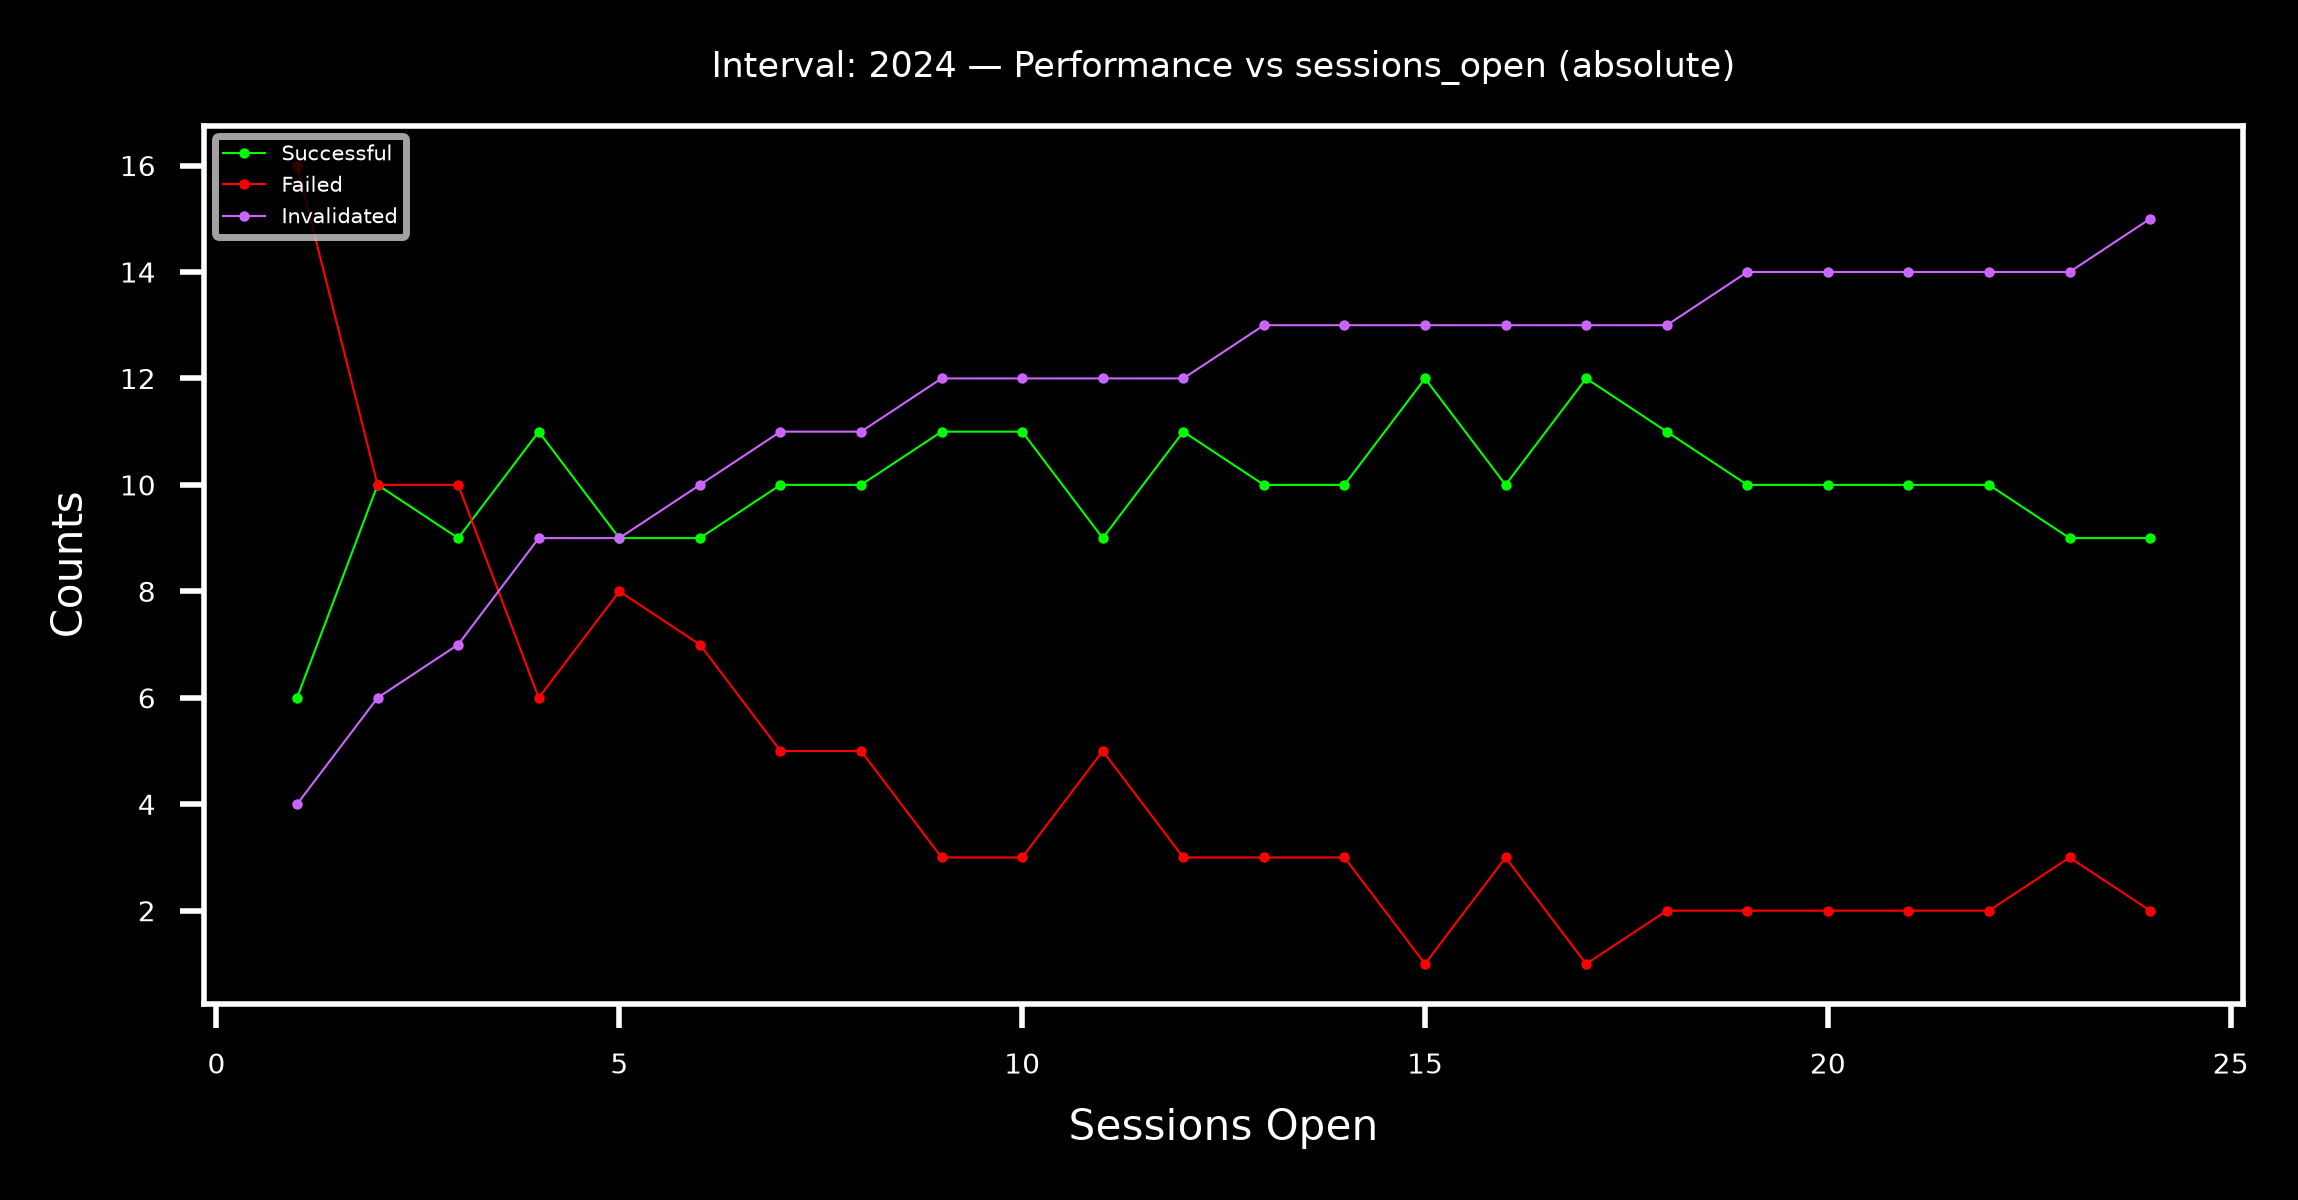

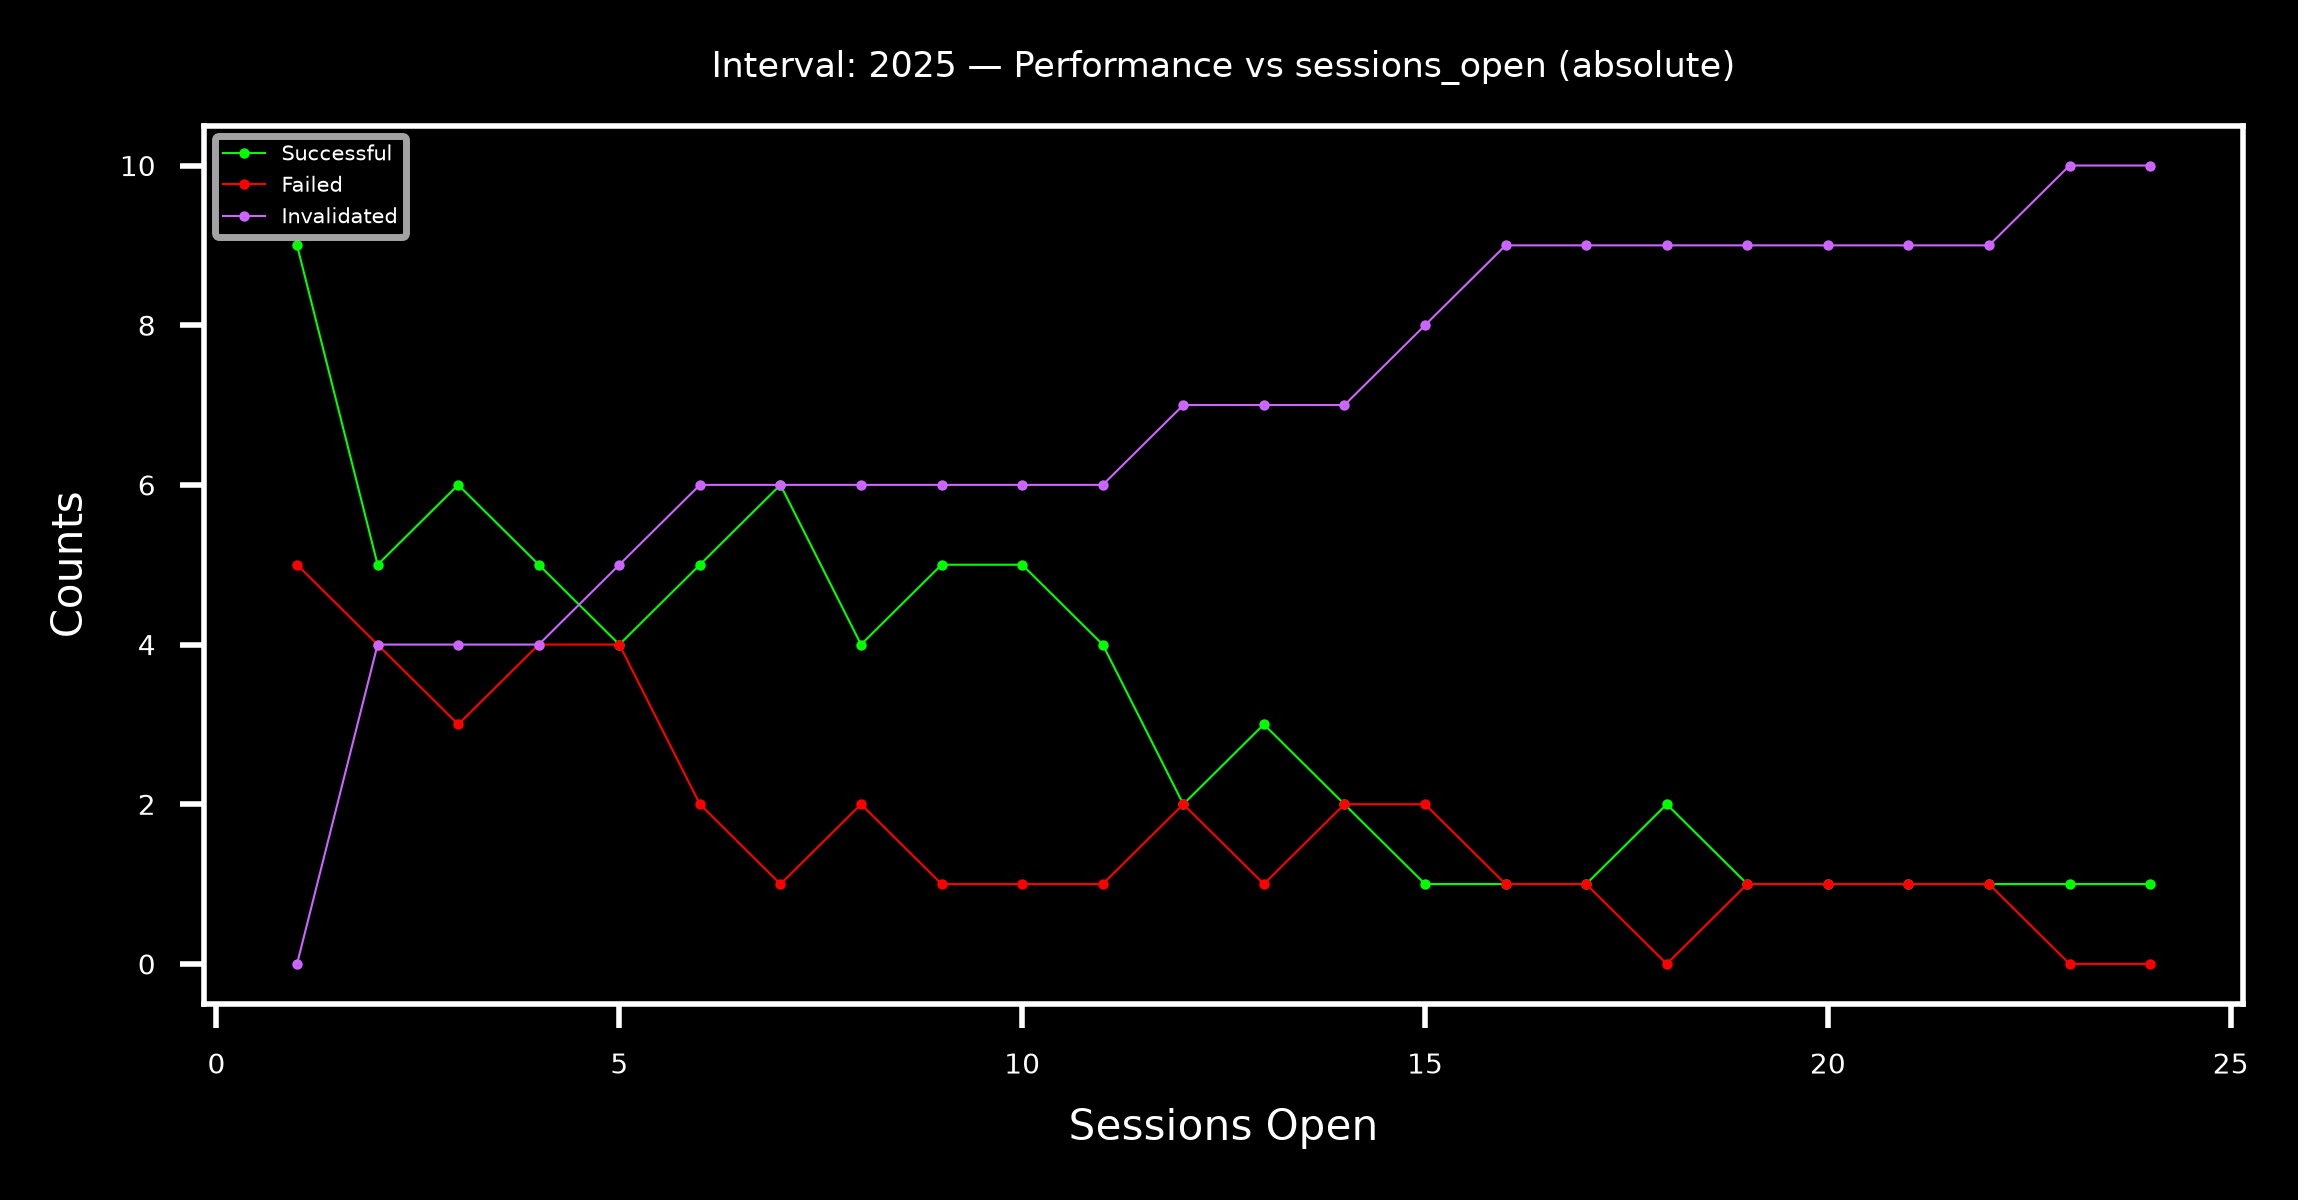

In [10]:
engine.show_stats_progress_in_intervals(mode='absolute')

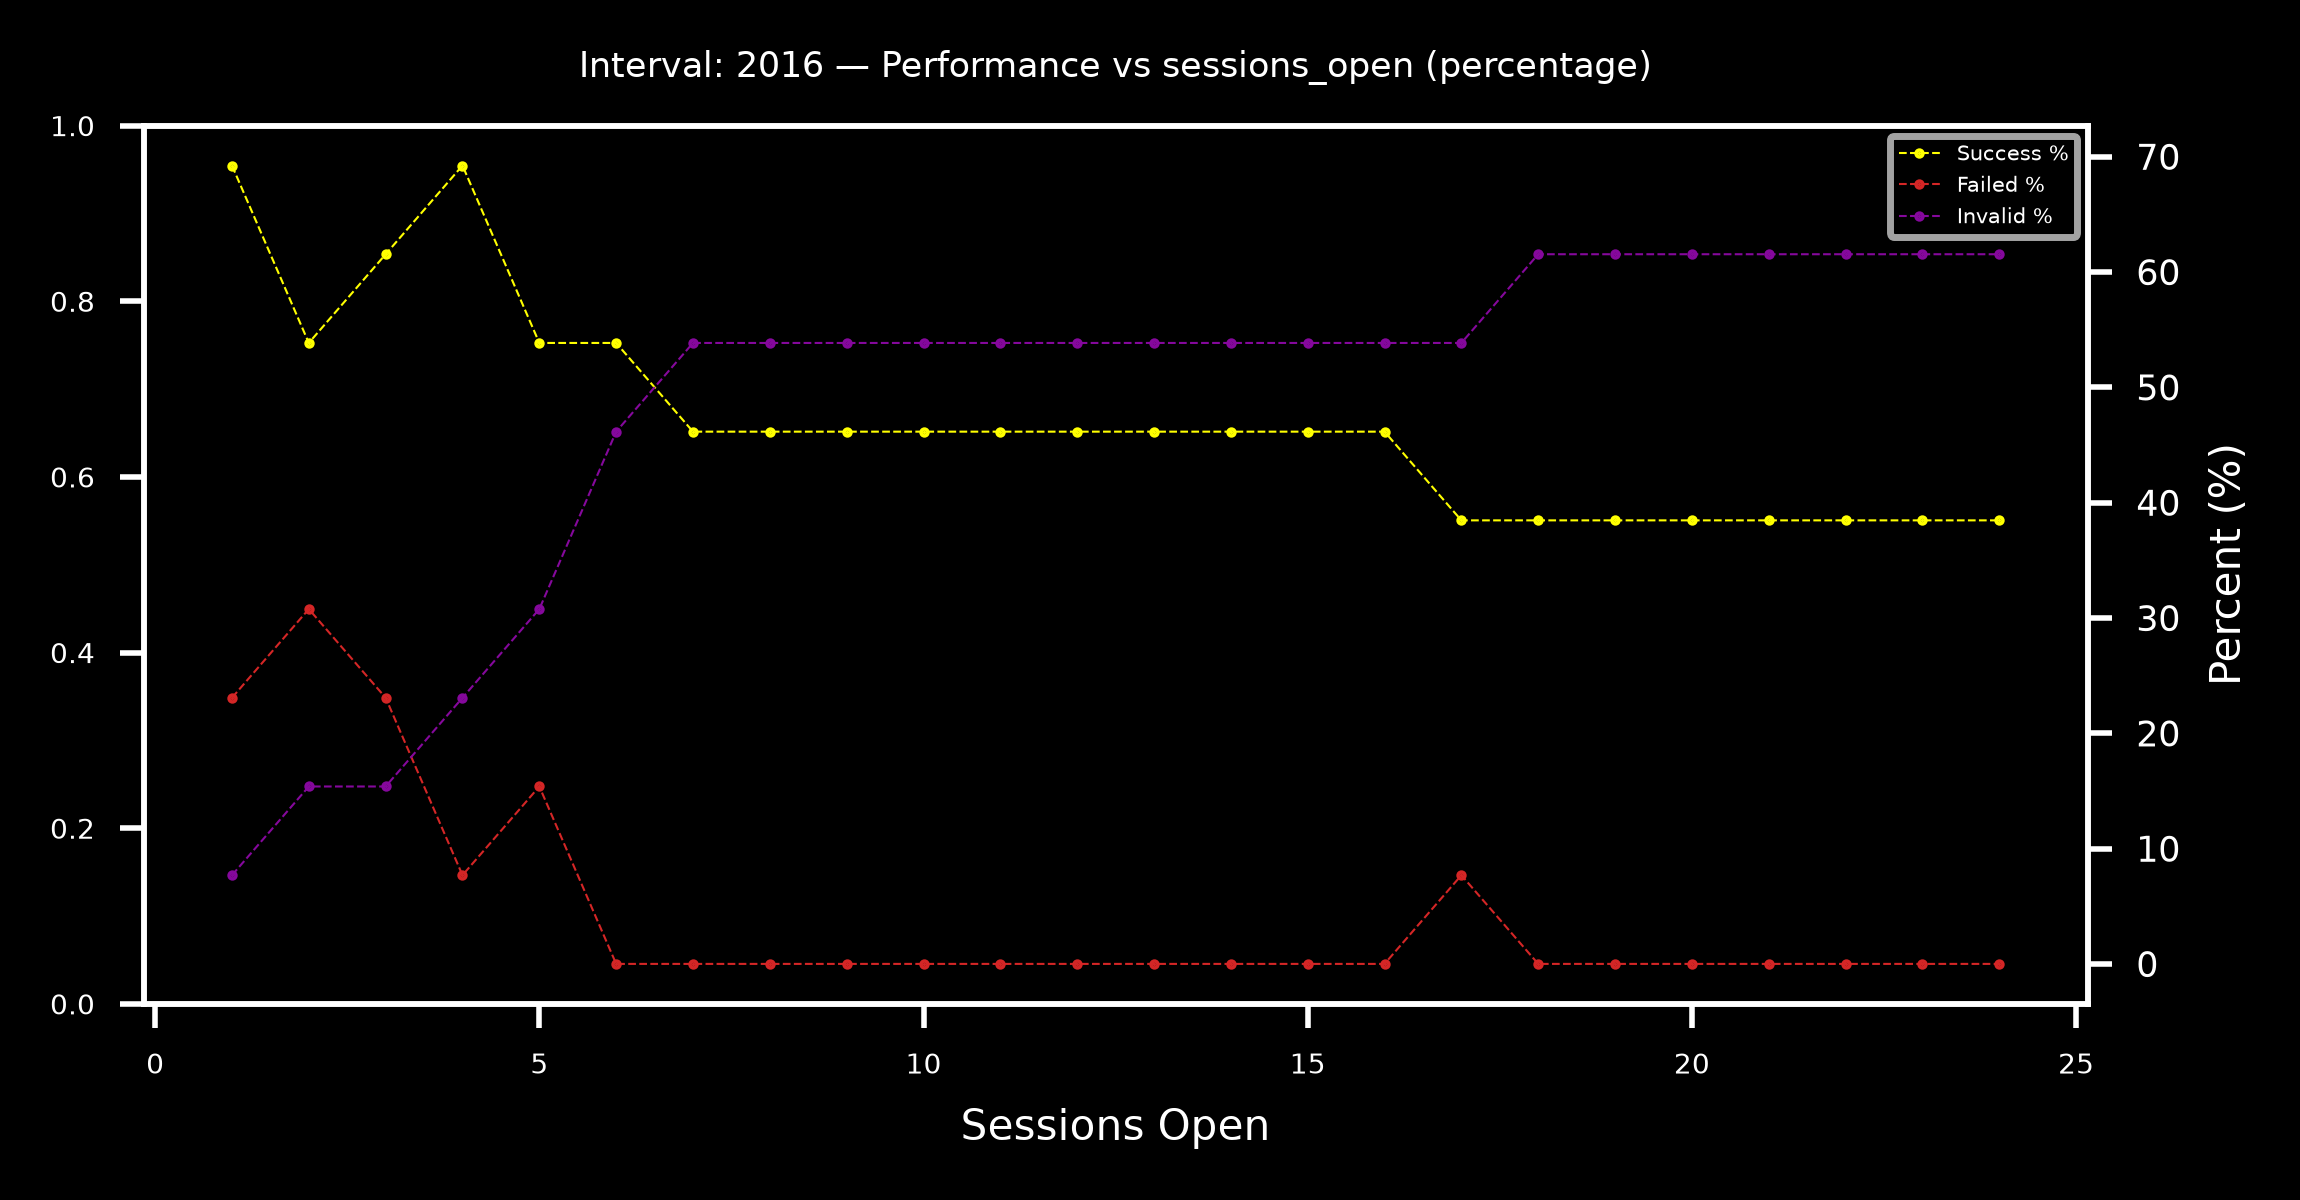

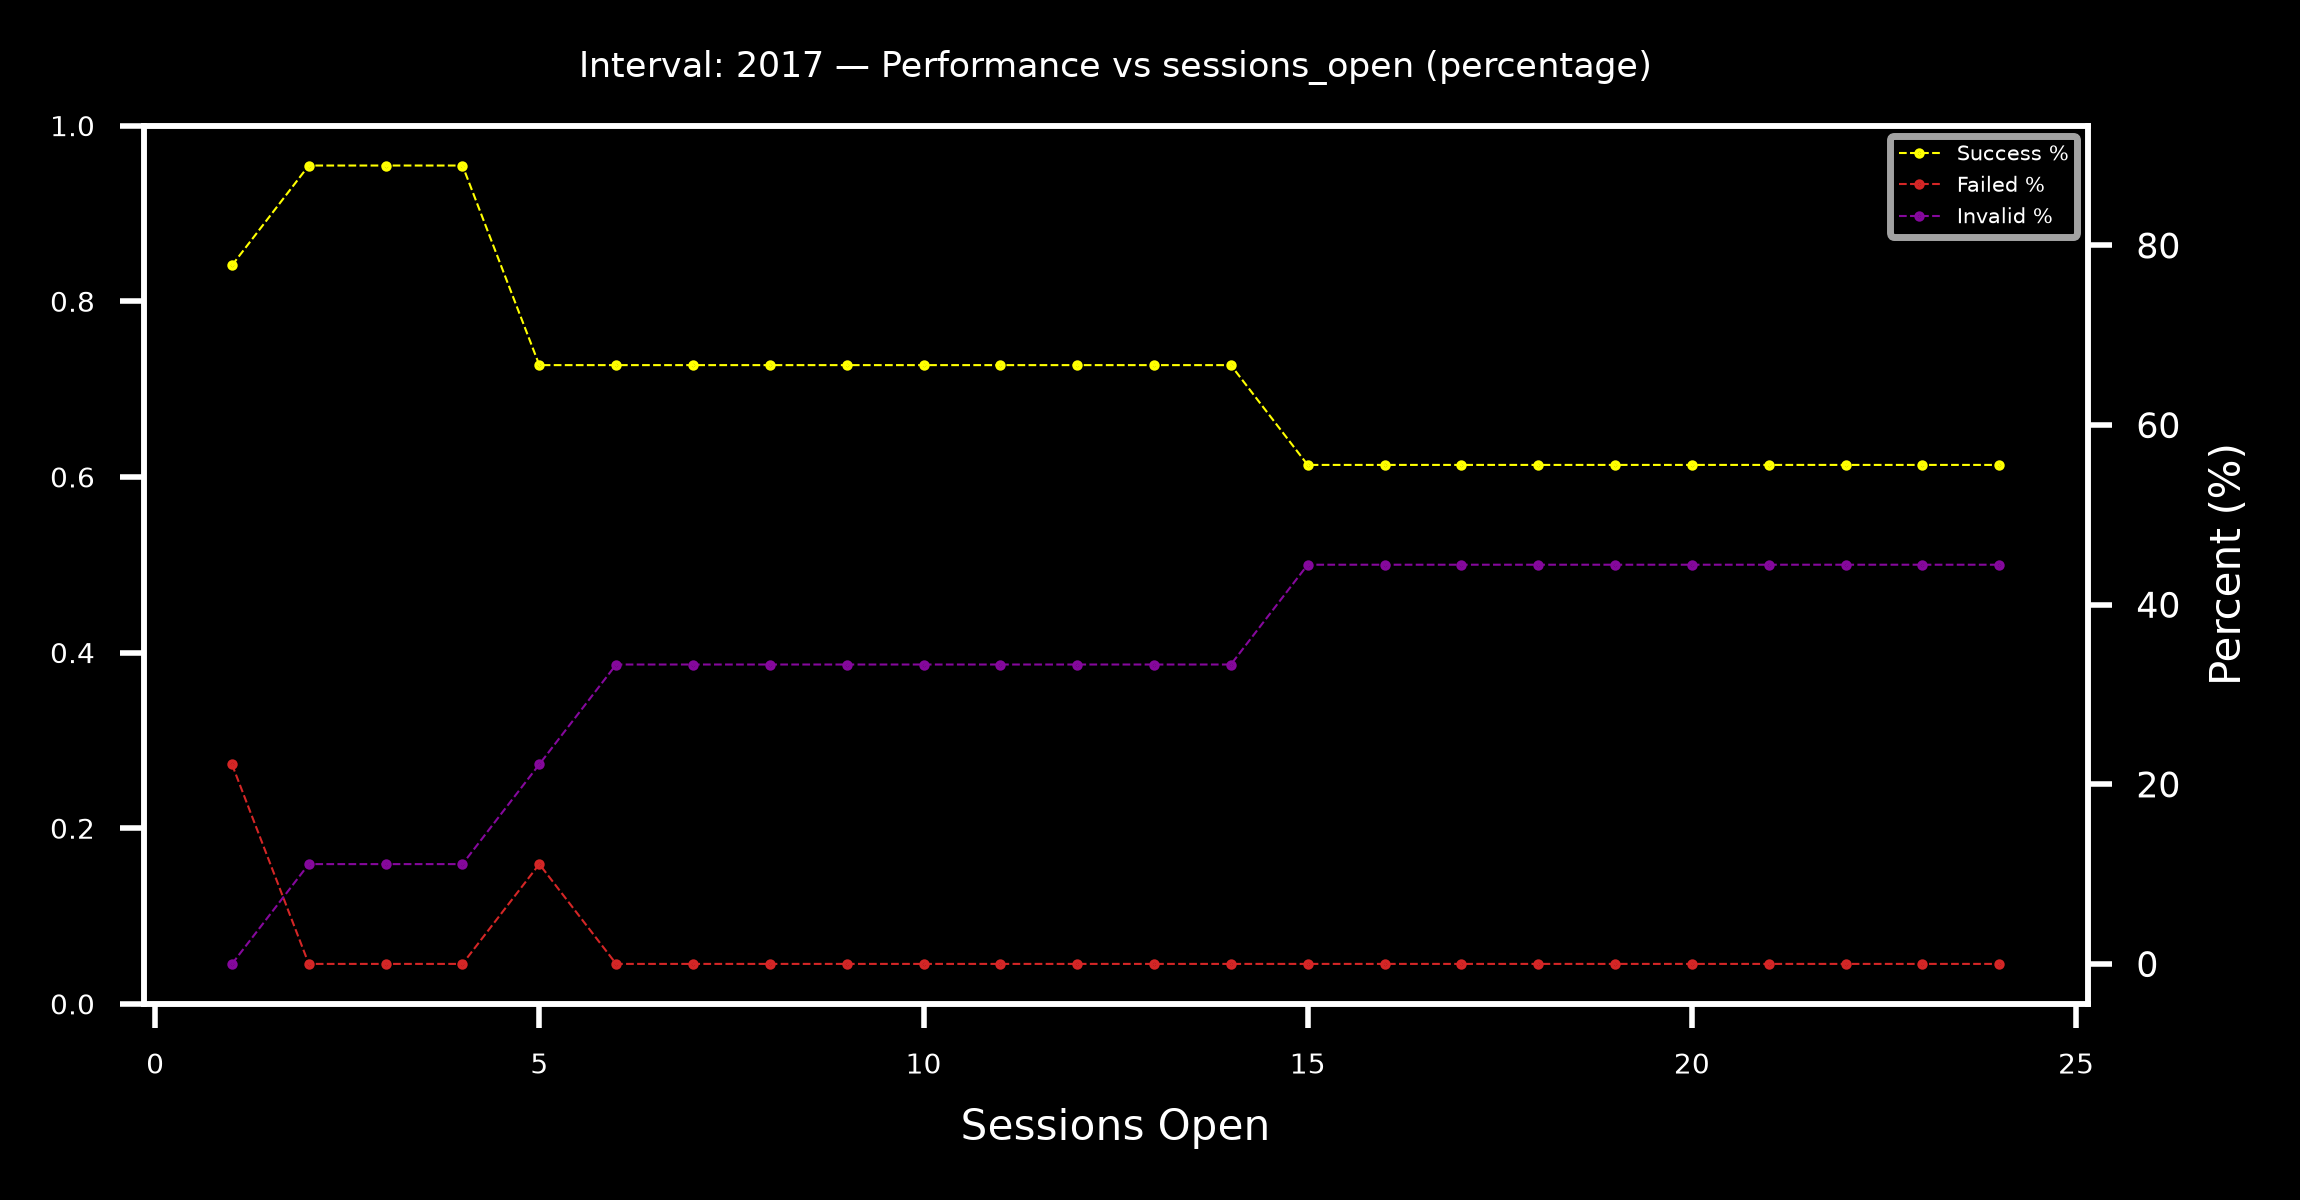

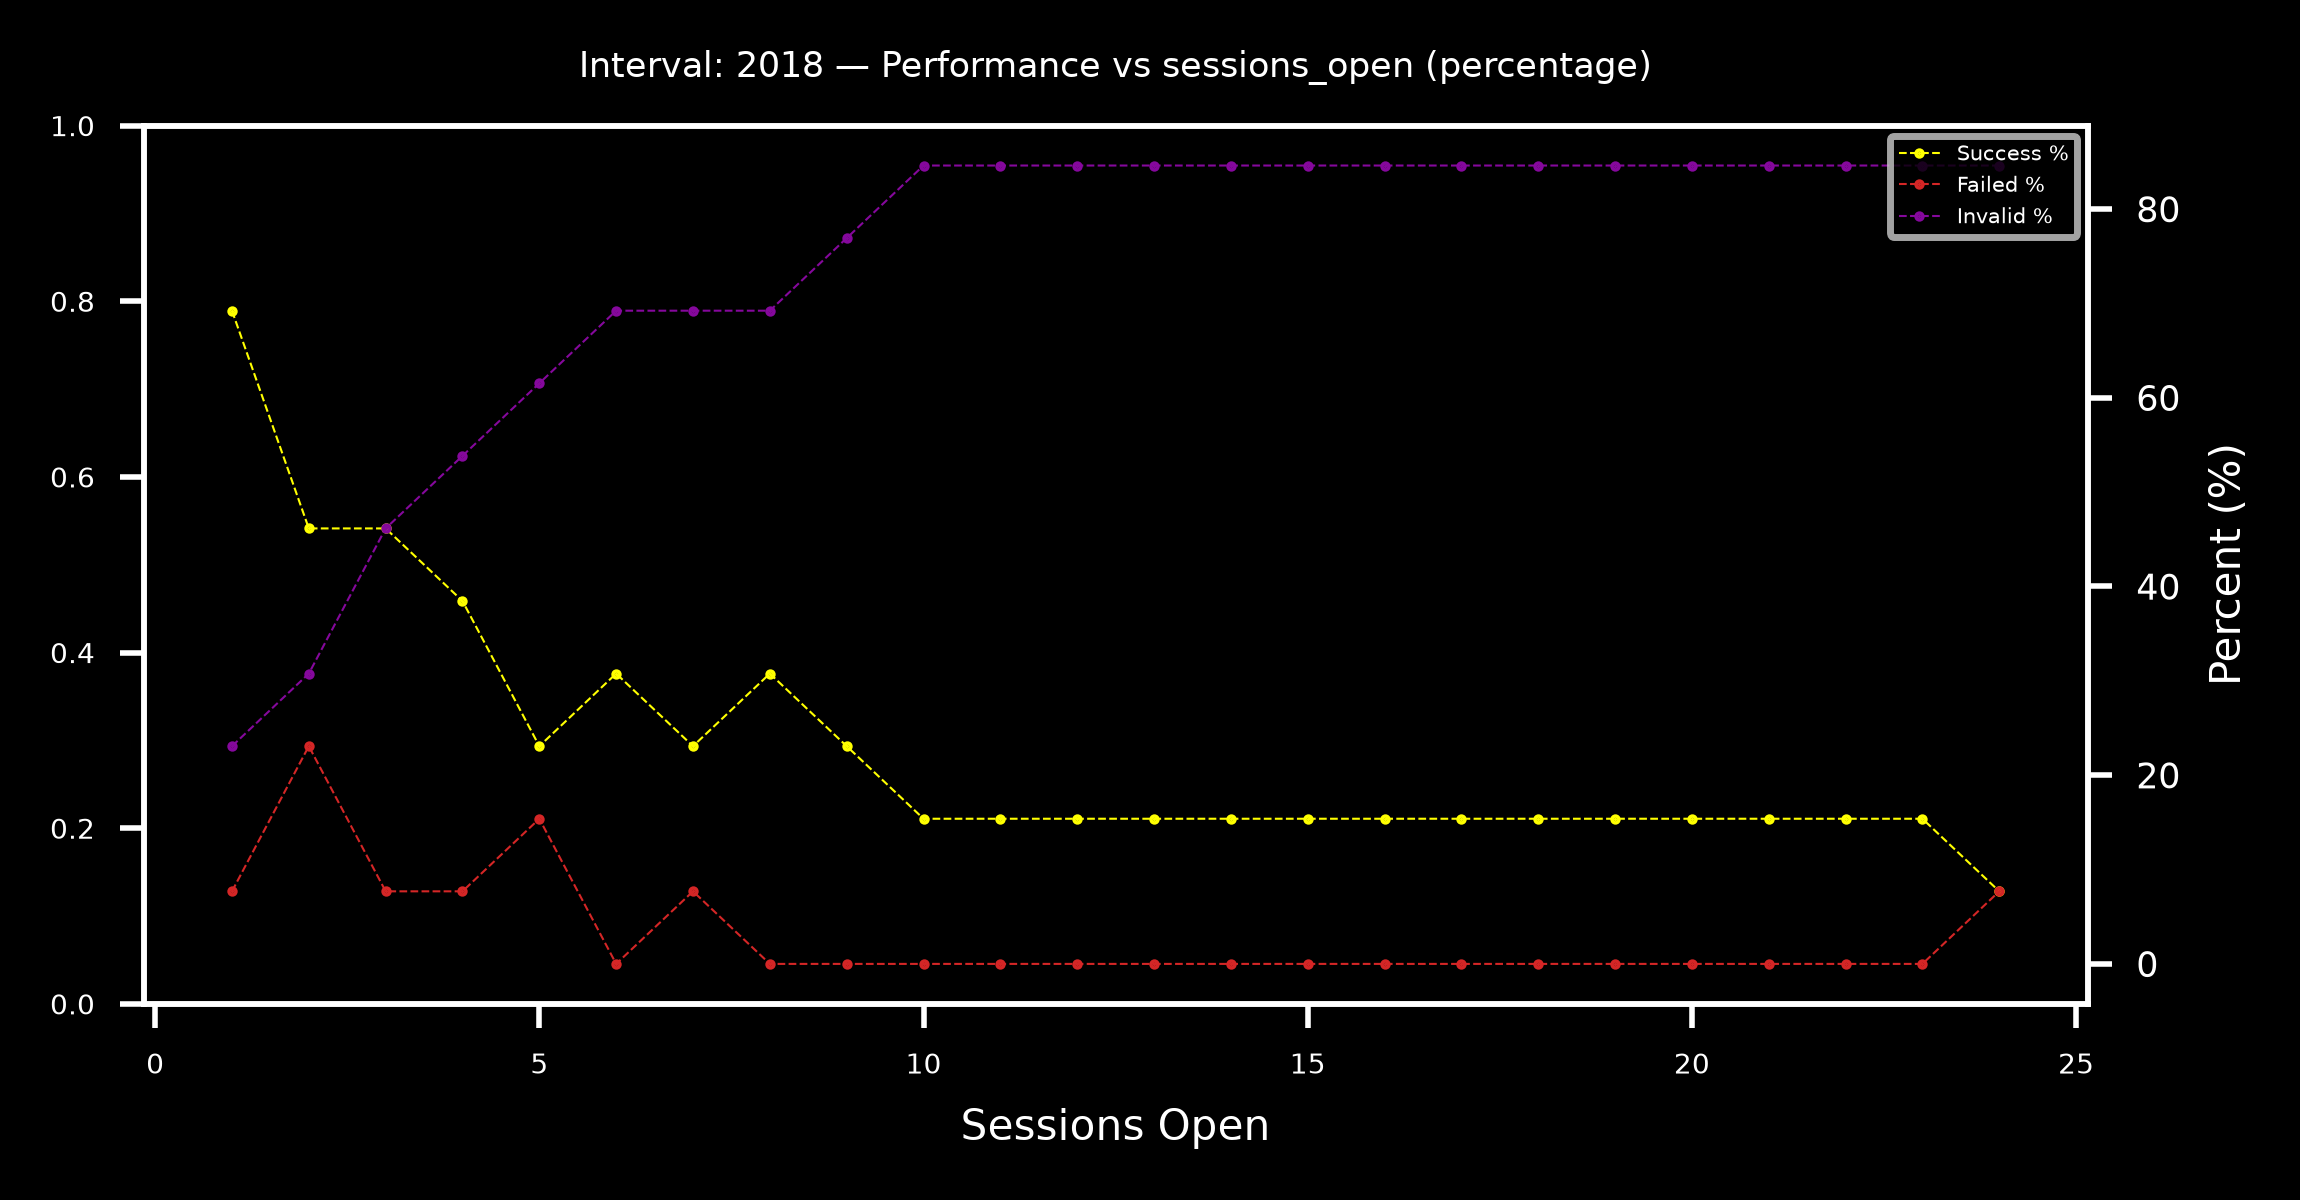

In [ ]:
engine.show_stats_progress_in_intervals(mode='percentage')

In [ ]:
epoch_intervals = [
    (date_to_epoch(f"16/12/2017 00:00:00"), date_to_epoch(f"15/12/2018 00:00:00")),
    (date_to_epoch(f"15/12/2018 00:00:00"), date_to_epoch(f"30/10/2021 00:00:00")),
    (date_to_epoch(f"30/10/2021 00:00:00"), date_to_epoch(f"21/11/2022 00:00:00")),
    (date_to_epoch(f"21/11/2022 00:00:00"), date_to_epoch(f"01/01/2026 00:00:00"))
]
epoch_titles = [
    "Bear 2018",
    "Bull 2019-",
    "Bear 2022",
    "Bull 2023-"
]

sessions_open_list = [i for i in range(1, 50)]

In [ ]:
engine = PatternEngine(
    loader=loader,
    evaluator=evaluator,
    intervals=epoch_intervals,
    interval_labels=epoch_titles,
    sessions_open_list=sessions_open_list
)

In [ ]:
engine.run(show_results=False)

In [ ]:
engine.show_stats_per_session()

In [ ]:
engine.show_stats_progress_in_intervals(mode='absolute')

In [ ]:
engine.show_stats_progress_in_intervals(mode='percentage')